#Question-1


### NumPy Implementation of CNN from Scratch

In this assignment, all major components of a CNN are implemented **from scratch using NumPy only**, without using built-in CNN operations such as:

- convolution layers from deep learning libraries  
- pooling layers  
- padding utilities from frameworks  
- stride-based built-in CNN functions  

---

## The implementation includes:

- convolution function  
- pooling function  
- convolution layer  
- pooling layer  
- flattening layer  
- multilayer perceptron (MLP)  
- full feed-forward CNN architecture for a **32 × 32 × 3** image  

---

Random weights are used for kernels and fully connected layers, as required.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Activation Functions

We verify the convolution and MLP using the following non-linear activation functions:

- Sigmoid
- Tanh
- ReLU
- PReLU

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def prelu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def softmax(x):
    x = x - np.max(x)   # numerical stability
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

### Utility Functions

These helper functions are used for:

- padding
- output size computation
- displaying images and feature maps

In [ ]:
def compute_output_dim(input_size, kernel_size, stride, padding):
    return ((input_size - kernel_size + 2 * padding) // stride) + 1

def pad_input(input_volume, padding):
    """
    input_volume shape: (H, W, C)
    """
    if padding == 0:
        return input_volume
    return np.pad(
        input_volume,
        ((padding, padding), (padding, padding), (0, 0)),
        mode='constant'
    )

def show_single_image(img, title="Image"):
    plt.figure(figsize=(4, 4))
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        # normalize for display if values are outside [0,1]
        img_disp = img.astype(np.float32)
        mn, mx = img_disp.min(), img_disp.max()
        if mx > mn:
            img_disp = (img_disp - mn) / (mx - mn)
        plt.imshow(img_disp)
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_feature_maps(volume, title_prefix="Feature Map"):
    """
    volume shape: (H, W, C)
    """
    C = volume.shape[2]
    cols = min(C, 4)
    rows = int(np.ceil(C / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i in range(C):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(volume[:, :, i], cmap='gray')
        plt.title(f"{title_prefix} {i}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_kernel(kernel, title="Kernel"):
    """
    kernel shape: (kH, kW, C) or (kH, kW)
    """
    plt.figure(figsize=(4, 4))
    if kernel.ndim == 2:
        plt.imshow(kernel, cmap='gray')
    else:
        # show first channel for visualization
        plt.imshow(kernel[:, :, 0], cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

### (i) Convolution Function

This function:

- accepts an image
- accepts a filter kernel
- applies padding
- performs correlation/convolution manually
- uses the given stride
- applies a chosen non-linearity
- supports multi-channel input

In [ ]:
def convolution_function(image, kernel, stride=1, padding=0, activation='relu', alpha=0.1):
    """
    image shape  : (H, W, C)
    kernel shape : (kH, kW, C)
    output       : (out_H, out_W)
    """
    H, W, C = image.shape
    kH, kW, kC = kernel.shape

    assert C == kC, "Number of channels in image and kernel must match."

    padded = pad_input(image, padding)
    out_H = compute_output_dim(H, kH, stride, padding)
    out_W = compute_output_dim(W, kW, stride, padding)

    output = np.zeros((out_H, out_W))

    for i in range(out_H):
        for j in range(out_W):
            h_start = i * stride
            h_end = h_start + kH
            w_start = j * stride
            w_end = w_start + kW

            region = padded[h_start:h_end, w_start:w_end, :]
            output[i, j] = np.sum(region * kernel)

    # apply activation
    if activation == 'sigmoid':
        output = sigmoid(output)
    elif activation == 'tanh':
        output = tanh(output)
    elif activation == 'relu':
        output = relu(output)
    elif activation == 'prelu':
        output = prelu(output, alpha)
    elif activation is None:
        pass
    else:
        raise ValueError("Unsupported activation function.")

    return output

### Verification of Convolution Function

We display:

- input image
- filter kernel
- output activation map

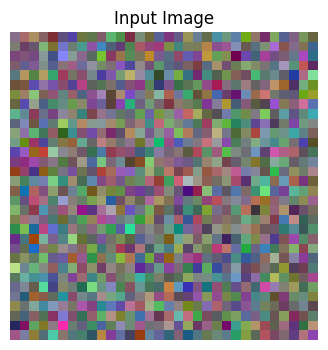

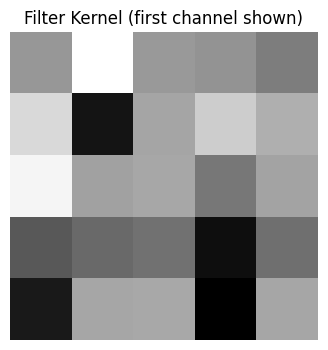

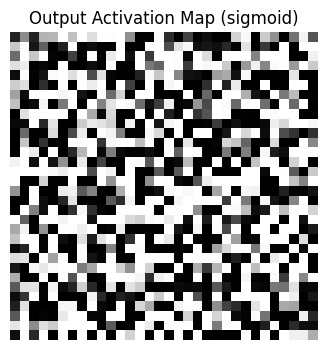

sigmoid output shape: (32, 32)


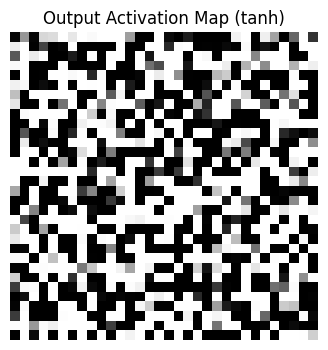

tanh output shape: (32, 32)


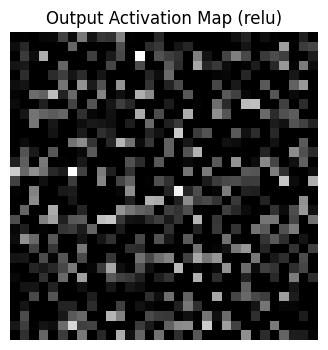

relu output shape: (32, 32)


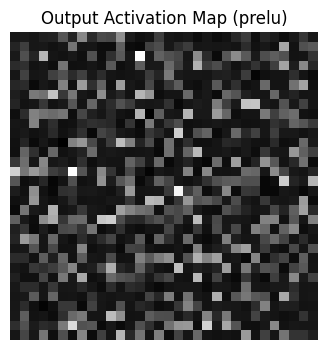

prelu output shape: (32, 32)


In [ ]:
# Example random input image and kernel
np.random.seed(42)

image = np.random.randn(32, 32, 3)
kernel = np.random.randn(5, 5, 3)

show_single_image(image, title="Input Image")
show_kernel(kernel, title="Filter Kernel (first channel shown)")

for act in ['sigmoid', 'tanh', 'relu', 'prelu']:
    out = convolution_function(image, kernel, stride=1, padding=2, activation=act)
    plt.figure(figsize=(4, 4))
    plt.imshow(out, cmap='gray')
    plt.title(f"Output Activation Map ({act})")
    plt.axis('off')
    plt.show()
    print(f"{act} output shape:", out.shape)

###(ii) Pooling Function

This function:


- accepts an activation map
- performs pooling manually
- supports max pooling and average pooling
- uses the provided stride

In [ ]:
def pooling_function(activation_map, pool_size=2, stride=2, mode='max'):
    """
    activation_map shape: (H, W)
    output shape: (out_H, out_W)
    """
    H, W = activation_map.shape

    out_H = ((H - pool_size) // stride) + 1
    out_W = ((W - pool_size) // stride) + 1

    pooled = np.zeros((out_H, out_W))

    for i in range(out_H):
        for j in range(out_W):
            h_start = i * stride
            h_end = h_start + pool_size
            w_start = j * stride
            w_end = w_start + pool_size

            region = activation_map[h_start:h_end, w_start:w_end]

            if mode == 'max':
                pooled[i, j] = np.max(region)
            elif mode == 'avg':
                pooled[i, j] = np.mean(region)
            else:
                raise ValueError("Pooling mode must be 'max' or 'avg'.")

    return pooled

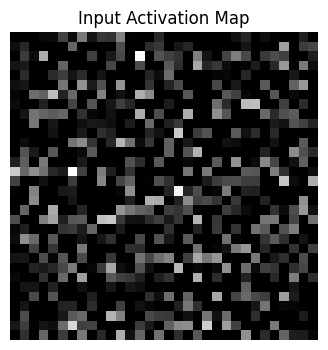

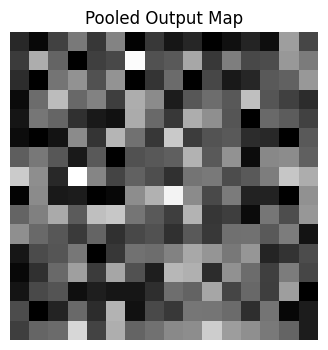

Activation map shape: (32, 32)
Pooled map shape: (16, 16)


In [ ]:
activation_map = convolution_function(image, kernel, stride=1, padding=2, activation='relu')
pooled_map = pooling_function(activation_map, pool_size=2, stride=2, mode='max')

plt.figure(figsize=(4, 4))
plt.imshow(activation_map, cmap='gray')
plt.title("Input Activation Map")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(pooled_map, cmap='gray')
plt.title("Pooled Output Map")
plt.axis('off')
plt.show()

print("Activation map shape:", activation_map.shape)
print("Pooled map shape:", pooled_map.shape)

###(iii) Convolution Layer Function

A convolution layer contains multiple kernels.
Each kernel generates one output activation map.
Stacking these maps produces an output activation volume.


In [ ]:
def convolution_layer(input_volume, kernels, stride=1, padding=0, activation='relu', alpha=0.1):
    """
    input_volume shape: (H, W, C_in)
    kernels shape: (num_kernels, kH, kW, C_in)
    output shape: (out_H, out_W, num_kernels)
    """
    num_kernels, kH, kW, C_in = kernels.shape
    H, W, C = input_volume.shape

    assert C == C_in, "Kernel depth must match input channels."

    out_H = compute_output_dim(H, kH, stride, padding)
    out_W = compute_output_dim(W, kW, stride, padding)

    output_volume = np.zeros((out_H, out_W, num_kernels))

    for k in range(num_kernels):
        kernel = kernels[k]
        feature_map = convolution_function(
            input_volume,
            kernel,
            stride=stride,
            padding=padding,
            activation=activation,
            alpha=alpha
        )
        output_volume[:, :, k] = feature_map

    return output_volume

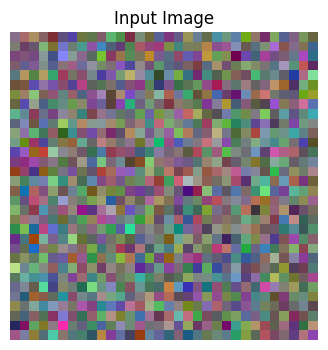

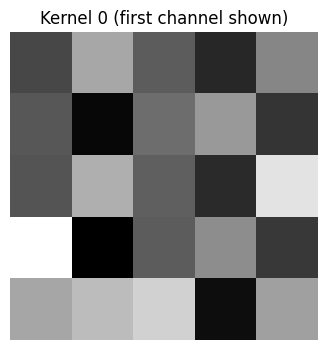

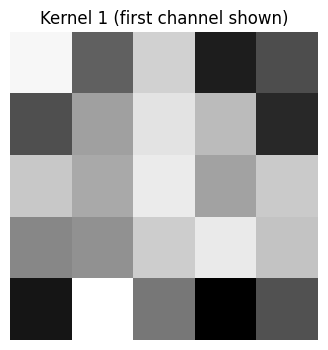

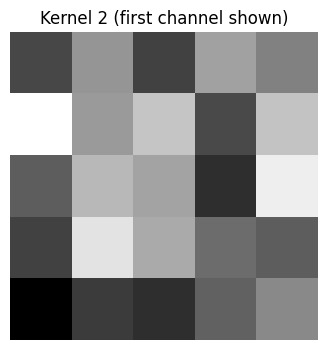

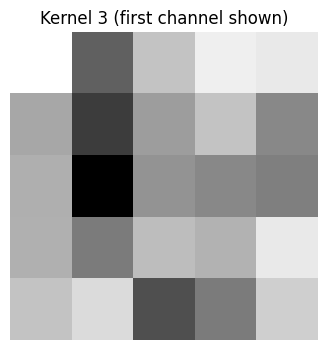

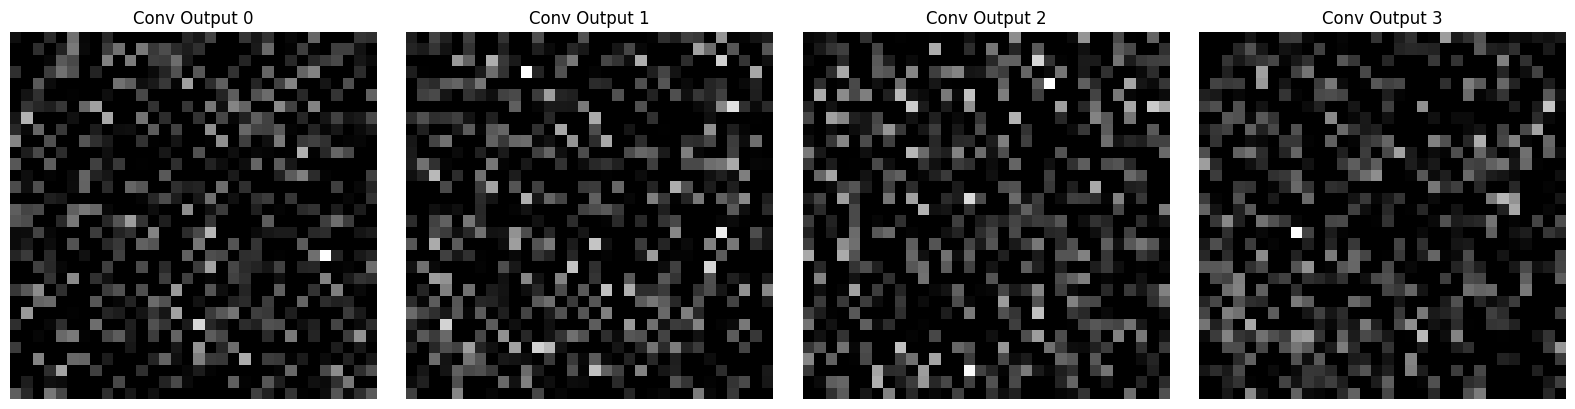

Convolution layer output shape: (32, 32, 4)


In [ ]:
kernels_layer1 = np.random.randn(4, 5, 5, 3)
conv_out = convolution_layer(image, kernels_layer1, stride=1, padding=2, activation='relu')

show_single_image(image, title="Input Image")
for i in range(4):
    show_kernel(kernels_layer1[i], title=f"Kernel {i} (first channel shown)")

show_feature_maps(conv_out, title_prefix="Conv Output")

print("Convolution layer output shape:", conv_out.shape)

###(iv) Pooling Layer Function

The pooling layer applies pooling independently to each channel of the input activation volume.

In [ ]:
def pooling_layer(input_volume, pool_size=2, stride=2, mode='max'):
    """
    input_volume shape: (H, W, C)
    output shape: (out_H, out_W, C)
    """
    H, W, C = input_volume.shape

    out_H = ((H - pool_size) // stride) + 1
    out_W = ((W - pool_size) // stride) + 1

    output_volume = np.zeros((out_H, out_W, C))

    for c in range(C):
        output_volume[:, :, c] = pooling_function(
            input_volume[:, :, c],
            pool_size=pool_size,
            stride=stride,
            mode=mode
        )

    return output_volume

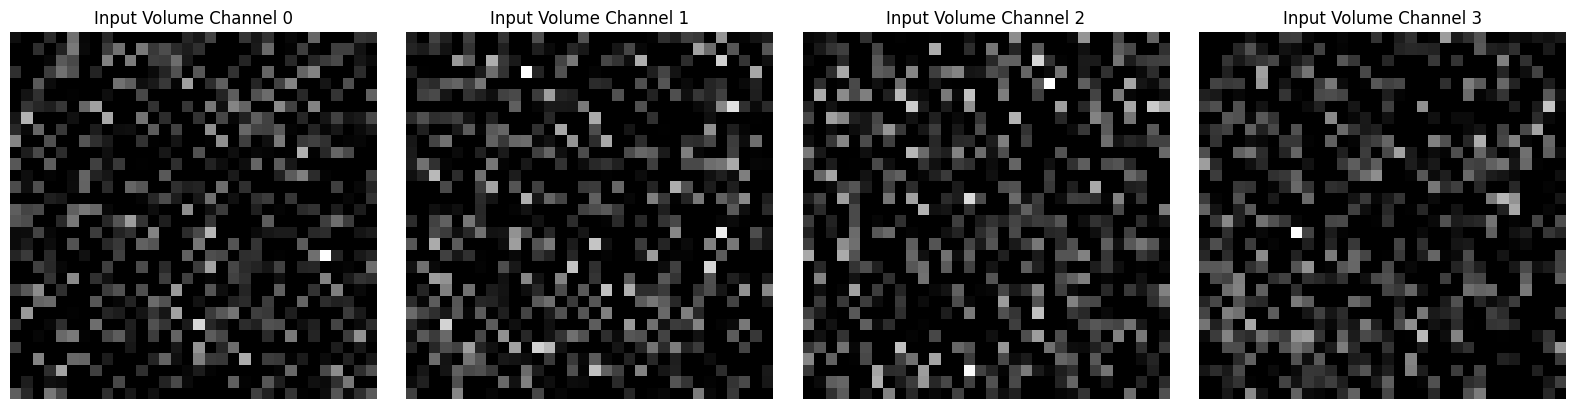

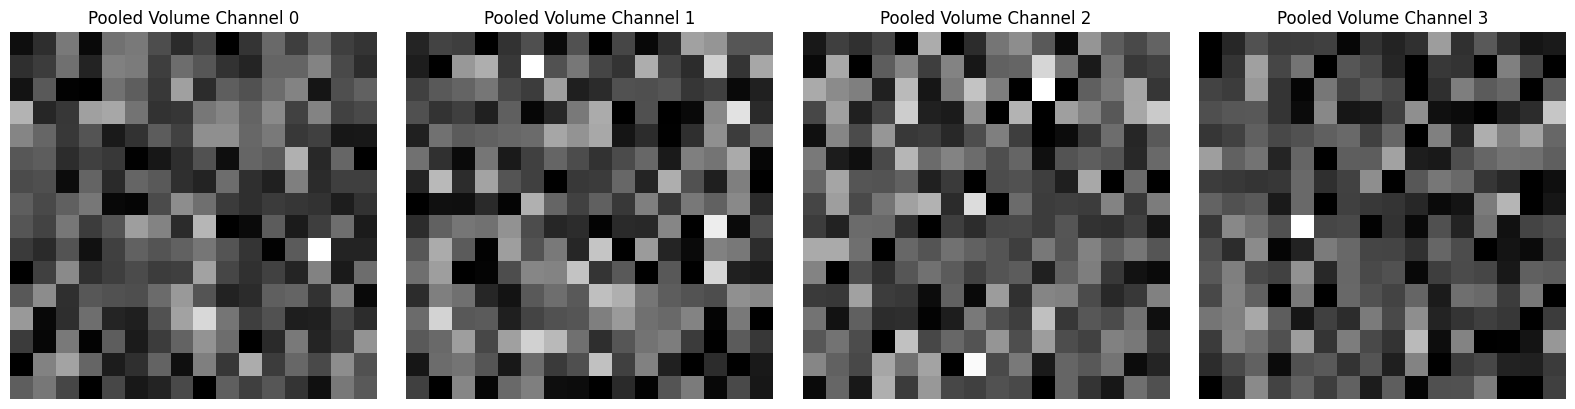

Input volume shape : (32, 32, 4)
Output volume shape: (16, 16, 4)


In [ ]:
pool_out = pooling_layer(conv_out, pool_size=2, stride=2, mode='max')

show_feature_maps(conv_out, title_prefix="Input Volume Channel")
show_feature_maps(pool_out, title_prefix="Pooled Volume Channel")

print("Input volume shape :", conv_out.shape)
print("Output volume shape:", pool_out.shape)

###(v) Flattening Function

This function converts the 3D activation volume into a 1D vector.
As required, the function has an associated weight matrix to map the flattened input to a specified output size.

If output size equals flattened size, the mapping can behave like an identity mapping.

In [ ]:
def flattening_function(input_volume, output_size=None, identity_mapping=False):
    """
    input_volume shape: (H, W, C)
    Returns:
        flat_input: flattened vector
        output_vector: mapped vector
        W_flat: weight matrix
    """
    flat_input = input_volume.reshape(-1)
    input_size = flat_input.shape[0]

    if identity_mapping or output_size is None:
        output_size = input_size

    if identity_mapping and output_size == input_size:
        W_flat = np.eye(input_size)
    else:
        W_flat = np.random.randn(output_size, input_size) * 0.01

    output_vector = W_flat @ flat_input
    return flat_input, output_vector, W_flat

In [ ]:
flat_input, flat_output, W_flat = flattening_function(pool_out, identity_mapping=True)

print("Flattened input size:", flat_input.shape)
print("Flattened output size:", flat_output.shape)
print("Weight matrix shape:", W_flat.shape)

Flattened input size: (1024,)
Flattened output size: (1024,)
Weight matrix shape: (1024, 1024)


###(vi) Multilayer Perceptron (MLP)

This MLP:

- accepts an input vector
- supports any number of hidden layers
- applies a chosen activation in hidden layers
- can produce output with or without softmax

In [ ]:
def apply_activation(x, activation='relu', alpha=0.1):
    if activation == 'sigmoid':
        return sigmoid(x)
    elif activation == 'tanh':
        return tanh(x)
    elif activation == 'relu':
        return relu(x)
    elif activation == 'prelu':
        return prelu(x, alpha)
    elif activation is None:
        return x
    else:
        raise ValueError("Unsupported activation function.")

def mlp(input_vector, num_hidden_layers, hidden_sizes, activation='relu',
        output_size=10, use_softmax=False, alpha=0.1):
    """
    input_vector shape: (D,)
    """
    x = input_vector.copy()
    layer_outputs = []
    weights = []
    biases = []

    prev_size = x.shape[0]

    # hidden layers
    for i in range(num_hidden_layers):
        h_size = hidden_sizes[i]
        W = np.random.randn(h_size, prev_size) * 0.01
        b = np.random.randn(h_size) * 0.01

        x = W @ x + b
        x = apply_activation(x, activation=activation, alpha=alpha)

        weights.append(W)
        biases.append(b)
        layer_outputs.append(x)
        prev_size = h_size

    # output layer
    W_out = np.random.randn(output_size, prev_size) * 0.01
    b_out = np.random.randn(output_size) * 0.01

    output = W_out @ x + b_out
    raw_output = output.copy()

    if use_softmax:
        output = softmax(output)

    weights.append(W_out)
    biases.append(b_out)
    layer_outputs.append(output)

    return raw_output, output, weights, biases, layer_outputs

In [ ]:
test_vector = np.random.randn(100)

raw_out, softmax_out, mlp_weights, mlp_biases, mlp_layers = mlp(
    test_vector,
    num_hidden_layers=1,
    hidden_sizes=[49],
    activation='relu',
    output_size=10,
    use_softmax=True
)

print("Raw output vector shape:", raw_out.shape)
print("Softmax output vector shape:", softmax_out.shape)
print("Softmax sum:", np.sum(softmax_out))
print("Softmax output:", softmax_out)

Raw output vector shape: (10,)
Softmax output vector shape: (10,)
Softmax sum: 1.0000000000000002
Softmax output: [0.09995087 0.09896633 0.10108345 0.09915073 0.10091286 0.10239146
 0.09911655 0.09765296 0.09951798 0.1012568 ]


###(vii) Feed-forward CNN Architecture

Required architecture:

- Input image of size 32 × 32 × 3
- Convolution layer with 4 kernels of size 5 × 5, ReLU, stride 1, same padding
- Max pooling layer 2 × 2, stride 2
- Convolution layer with 4 kernels of size 5 × 5 × 4, ReLU, stride 1, same padding
- Max pooling layer 2 × 2, stride 2
- Flattening layer (identity mapping)
- MLP with one hidden layer of 49 nodes
- Output layer of 10 nodes
 - ReLU hidden activation and softmax output

Expected dimensions:

- Input: (32, 32, 3)
- After Conv1: (32, 32, 4)
- After Pool1: (16, 16, 4)
- After Conv2: (16, 16, 4)
- After Pool2: (8, 8, 4)
- Flattened: 8 × 8 × 4 = 256
- Hidden layer: 49
- Output layer: 10

In [ ]:
def cnn_feedforward(input_image):
    """
    Full CNN architecture as specified in the assignment.
    """
    assert input_image.shape == (32, 32, 3), "Input must be of shape (32, 32, 3)"

    # ----------------------------
    # Layer 1: Conv
    # 4 kernels of size 5x5x3
    # stride = 1, same padding => padding = 2
    # ----------------------------
    kernels1 = np.random.randn(4, 5, 5, 3) * 0.01
    conv1 = convolution_layer(
        input_image,
        kernels1,
        stride=1,
        padding=2,
        activation='relu'
    )

    # ----------------------------
    # Layer 2: Max Pool
    # 2x2, stride 2
    # ----------------------------
    pool1 = pooling_layer(
        conv1,
        pool_size=2,
        stride=2,
        mode='max'
    )

    # ----------------------------
    # Layer 3: Conv
    # 4 kernels of size 5x5x4
    # stride = 1, same padding => padding = 2
    # ----------------------------
    kernels2 = np.random.randn(4, 5, 5, 4) * 0.01
    conv2 = convolution_layer(
        pool1,
        kernels2,
        stride=1,
        padding=2,
        activation='relu'
    )

    # ----------------------------
    # Layer 4: Max Pool
    # 2x2, stride 2
    # ----------------------------
    pool2 = pooling_layer(
        conv2,
        pool_size=2,
        stride=2,
        mode='max'
    )

    # ----------------------------
    # Layer 5: Flatten (identity mapping)
    # ----------------------------
    flat_input, flat_output, W_flat = flattening_function(
        pool2,
        identity_mapping=True
    )

    # ----------------------------
    # Layer 6: MLP
    # one hidden layer of 49 nodes
    # output = 10 nodes
    # ReLU + softmax
    # ----------------------------
    raw_output, softmax_output, mlp_weights, mlp_biases, mlp_layers = mlp(
        flat_output,
        num_hidden_layers=1,
        hidden_sizes=[49],
        activation='relu',
        output_size=10,
        use_softmax=True
    )

    return {
        "conv1": conv1,
        "pool1": pool1,
        "conv2": conv2,
        "pool2": pool2,
        "flat_input": flat_input,
        "flat_output": flat_output,
        "raw_output": raw_output,
        "softmax_output": softmax_output,
        "kernels1": kernels1,
        "kernels2": kernels2,
        "W_flat": W_flat,
        "mlp_weights": mlp_weights,
        "mlp_biases": mlp_biases
    }

In [ ]:
# Test with a random CIFAR-10 sized image
np.random.seed(123)
input_image = np.random.randn(32, 32, 3)

result = cnn_feedforward(input_image)

print("Input image shape      :", input_image.shape)
print("After Conv1            :", result["conv1"].shape)
print("After Pool1            :", result["pool1"].shape)
print("After Conv2            :", result["conv2"].shape)
print("After Pool2            :", result["pool2"].shape)
print("Flattened vector shape :", result["flat_output"].shape)
print("Raw output shape       :", result["raw_output"].shape)
print("Softmax output shape   :", result["softmax_output"].shape)
print("Softmax output sum     :", np.sum(result["softmax_output"]))
print("Final output vector    :\n", result["softmax_output"])

Input image shape      : (32, 32, 3)
After Conv1            : (32, 32, 4)
After Pool1            : (16, 16, 4)
After Conv2            : (16, 16, 4)
After Pool2            : (8, 8, 4)
Flattened vector shape : (256,)
Raw output shape       : (10,)
Softmax output shape   : (10,)
Softmax output sum     : 1.0
Final output vector    :
 [0.09983671 0.09987957 0.09898963 0.1002176  0.10015854 0.10057367
 0.09892993 0.10028454 0.10052241 0.1006074 ]


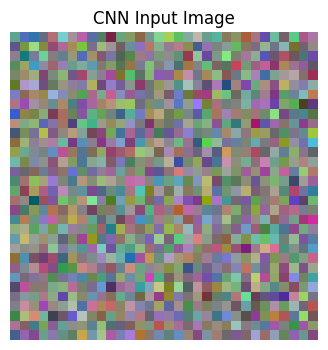

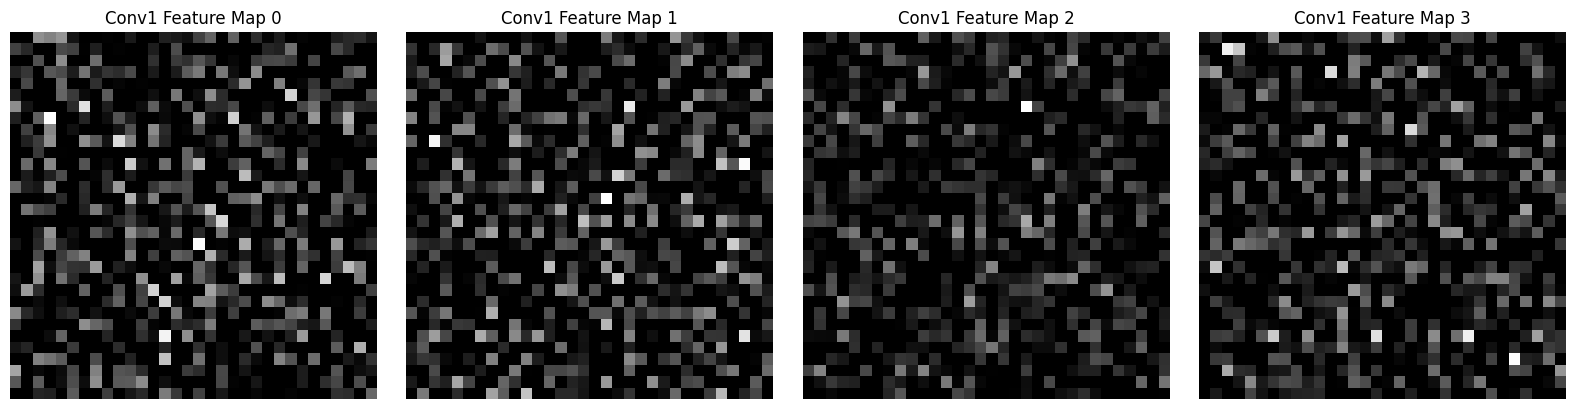

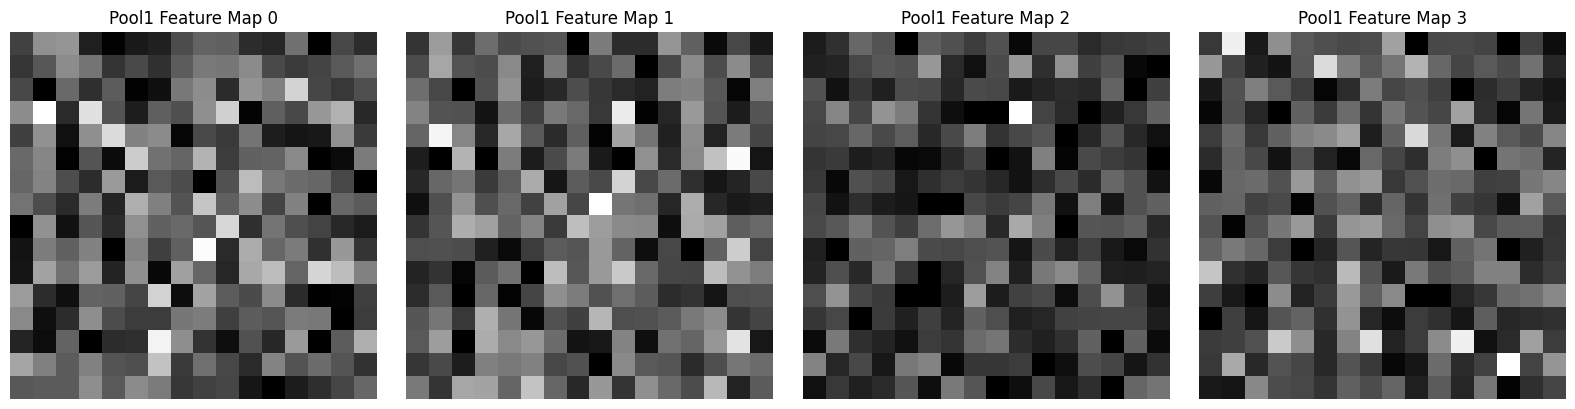

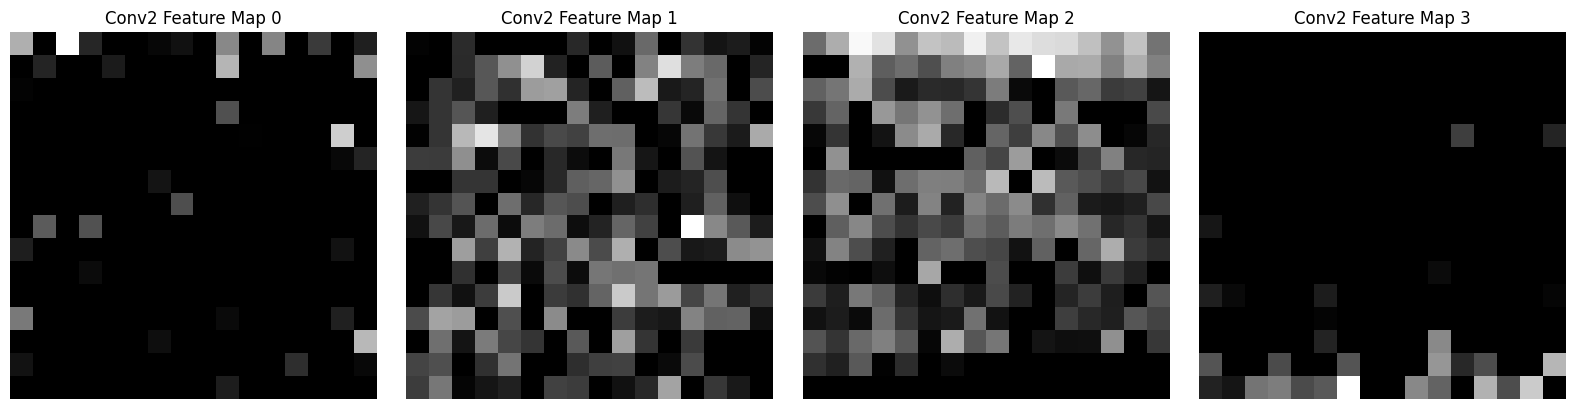

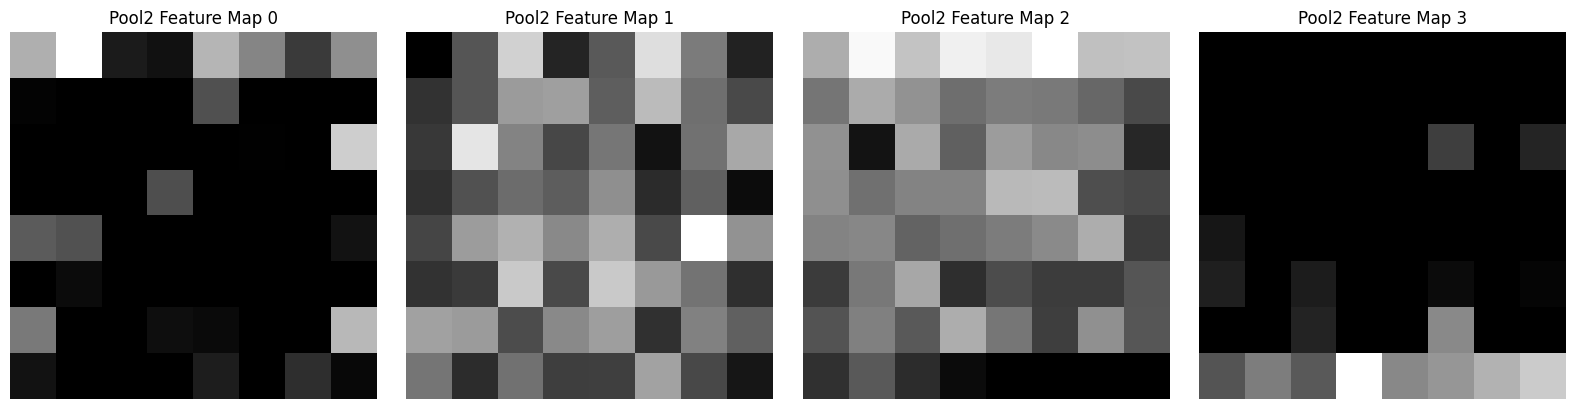

In [ ]:
# Optional visualization
show_single_image(input_image, title="CNN Input Image")
show_feature_maps(result["conv1"], title_prefix="Conv1 Feature Map")
show_feature_maps(result["pool1"], title_prefix="Pool1 Feature Map")
show_feature_maps(result["conv2"], title_prefix="Conv2 Feature Map")
show_feature_maps(result["pool2"], title_prefix="Pool2 Feature Map")

A complete feed-forward CNN was implemented from scratch using **NumPy only**.  
All required components were manually built:

- convolution
- pooling
- convolution layer
- pooling layer
- flattening
- MLP
- full CNN architecture

The implementation was verified using a `32 × 32 × 3` input image and successfully produced a final output vector of size `10`, satisfying the assignment requirement.

### For part (i)

The convolution function takes an image, kernel, stride, padding, and activation function as input.  
It manually performs correlation between the padded image and the kernel and then applies the chosen non-linearity.  
The implementation supports multi-channel input and corresponding kernel volume.  
The output activation map is displayed and verified using **sigmoid**, **tanh**, **ReLU**, and **PReLU**.

---

### For part (ii)

The pooling function takes the activation map from the convolution function and performs either **max pooling** or **average pooling** with the specified stride.  
The input activation map and pooled output are displayed.

---

### For part (iii)

The convolution layer function applies multiple kernels on the input volume.  
Each kernel generates one activation map, and all such maps together form the output activation volume.  
The output size is verified to be correct.

---

### For part (iv)

The pooling layer function applies pooling independently on each channel of the activation volume and produces a pooled output volume.

---

### For part (v)

The flattening function reshapes the activation volume into a **1D vector**.  
A weight matrix is associated with this layer so that the flattened vector can be mapped to a desired output size.

---

### For part (vi)

The **MLP** takes a vector input, supports a specified number of hidden layers and hidden nodes, and produces an output vector.  
The output is shown both before and after applying **softmax**.

---

### For part (vii)

The feed-forward **CNN architecture** was implemented exactly as specified.  
It accepts a `32 × 32 × 3` image and produces a final output vector of dimension `10`.

#Question-2

## PyTorch Implementation of CNN

In this part, the CNN architecture implemented manually in Question 1 is now trained using PyTorch for image classification on the CIFAR-10 dataset.

 The required architecture is:

- **Input:** `32 × 32 × 3`
- **Convolution layer:** 4 kernels of size `5 × 5`, stride 1, same padding, ReLU
- **Max pooling:** `2 × 2`, stride 2
- **Convolution layer:** 4 kernels of size `5 × 5 × 4`, stride 1, same padding, ReLU
- **Max pooling:** `2 × 2`, stride 2
- **Flatten**
- **MLP** with one hidden layer of **49 nodes**
- **Output layer** of **10 nodes**
- **Softmax output**

### Training is performed using:

1. Vanilla SGD  
2. Momentum  
3. RMSProp  

### Further experiments include:

- **t-SNE visualization** of bottleneck features  
- **Dropout** at hidden layer  
- **Batch normalization** at hidden layer



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


###Data Preparation

We select:

- 100 images per class from CIFAR-10 training set → total 1000
- 10 images per class from CIFAR-10 test set → total 100

Labels are also converted to one-hot vectors of size 10, since the question explicitly mentions one-hot encoded labels.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset_full = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

classes = train_dataset_full.classes
print(classes)

100%|██████████| 170M/170M [00:03<00:00, 55.1MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
def select_n_per_class(dataset, n_per_class):
    class_counts = {i: 0 for i in range(10)}
    selected_indices = []

    for idx, (_, label) in enumerate(dataset):
        if class_counts[label] < n_per_class:
            selected_indices.append(idx)
            class_counts[label] += 1

        if all(class_counts[c] == n_per_class for c in range(10)):
            break

    return selected_indices

train_indices = select_n_per_class(train_dataset_full, 100)   # 1000 images
test_indices = select_n_per_class(test_dataset_full, 10)      # 100 images

train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

print("Train subset size:", len(train_dataset))
print("Test subset size :", len(test_dataset))

Train subset size: 1000
Test subset size : 100


In [ ]:
def one_hot_encode(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()

CNN Architecture

This model exactly matches the architecture from Question 1(vii):

- Conv1: 3 → 4, kernel 5×5, padding 2
- MaxPool 2×2
- Conv2: 4 → 4, kernel 5×5, padding 2
- MaxPool 2×2
- Flatten
- FC1: 256 → 49
- FC2: 49 → 10

Optional features:

- dropout at hidden layer
- batch normalization before activation

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, dropout_p=0.0, use_bn=False):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(in_channels=4, out_channels=4, kernel_size=5, stride=1, padding=2)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(8 * 8 * 4, 49)
        self.fc2 = nn.Linear(49, 10)

        self.use_bn = use_bn
        if use_bn:
            self.bn1 = nn.BatchNorm1d(49)

        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x, return_activations=False, return_bottleneck=False):
        # Conv layer 1
        a1 = F.relu(self.conv1(x))     # [B,4,32,32]
        p1 = self.pool(a1)             # [B,4,16,16]

        # Conv layer 2
        a2 = F.relu(self.conv2(p1))    # [B,4,16,16]
        p2 = self.pool(a2)             # [B,4,8,8]

        # Flatten
        x = p2.view(p2.size(0), -1)    # [B,256]

        # Hidden layer
        hidden = self.fc1(x)           # [B,49]
        if self.use_bn:
            hidden = self.bn1(hidden)  # BN before activation

        hidden = F.relu(hidden)
        hidden_after_dropout = self.dropout(hidden)

        logits = self.fc2(hidden_after_dropout)

        if return_activations:
            return logits, a1, a2

        if return_bottleneck:
            return logits, hidden

        return logits

## Cross-Entropy Loss for One-Hot Labels

PyTorch’s `CrossEntropyLoss` expects class indices, not one-hot vectors.

Since the assignment says the true labels are one-hot encoded, we compute the cross-entropy manually using:

$$
L = - \sum_i y_i \log(\hat{p}_i)
$$

where:

- $y_i$ is the one-hot target  
- $\hat{p}_i$ is the softmax output

In [ ]:
def cross_entropy_one_hot(logits, one_hot_targets):
    log_probs = F.log_softmax(logits, dim=1)
    loss = -(one_hot_targets * log_probs).sum(dim=1).mean()
    return loss

In [ ]:
def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

DataLoaders

We experiment with different mini-batch sizes.
Below, you can change batch_size to values such as:

- 8
- 16
- 32
- 64

In [ ]:
def get_dataloaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

##Evaluation and Activation Map Visualization

After each epoch we compute:

- training error
- test error
- training accuracy
- test accuracy

We also visualize representative slices from activation maps of both convolution layers

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            one_hot_labels = one_hot_encode(labels).to(device)

            logits = model(images)
            loss = cross_entropy_one_hot(logits, one_hot_labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (torch.argmax(logits, dim=1) == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

In [ ]:
def visualize_activation_maps(model, loader, epoch, title_prefix="Model"):
    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        logits, a1, a2 = model(images, return_activations=True)

    # take first image in batch
    a1_img = a1[0].cpu().numpy()   # shape [4,32,32]
    a2_img = a2[0].cpu().numpy()   # shape [4,16,16]
    input_img = images[0].cpu().permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(np.transpose(input_img, (0, 1, 2)))
    plt.title(f"{title_prefix} - Epoch {epoch} - Input Image")
    plt.axis("off")
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(4):
        axes[i].imshow(a1_img[i], cmap="viridis")
        axes[i].set_title(f"Conv1 Map {i}")
        axes[i].axis("off")
    plt.suptitle(f"{title_prefix} - Epoch {epoch} - Conv1 Activation Maps")
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(4):
        axes[i].imshow(a2_img[i], cmap="viridis")
        axes[i].set_title(f"Conv2 Map {i}")
        axes[i].axis("off")
    plt.suptitle(f"{title_prefix} - Epoch {epoch} - Conv2 Activation Maps")
    plt.show()

##t-SNE Visualization of Bottleneck Features

We use the hidden layer representation of size 49 as the bottleneck feature.
We visualize these features:

- after epoch 1
- after epoch 15

using the same 100 test images.

In [ ]:
def extract_bottleneck_features(model, loader):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits, hidden = model(images, return_bottleneck=True)
            all_features.append(hidden.cpu().numpy())
            all_labels.append(labels.numpy())

    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return features, labels

In [ ]:
def plot_tsne(features, labels, title):
    tsne = TSNE(n_components=2, random_state=42, perplexity=20)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    for c in range(10):
        idx = labels == c
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=str(c), alpha=0.7)
    plt.legend()
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

Training Function

This function trains the model for a given optimizer and stores:

- training loss per epoch
- test loss per epoch
- training accuracy per epoch
- test accuracy per epoch
- epoch 1 bottleneck features
- epoch 15 bottleneck features

In [ ]:
def train_model(model, train_loader, test_loader, optimizer, epochs=15, model_name="Model"):
    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
        "epoch1_features": None,
        "epoch1_labels": None,
        "epoch_last_features": None,
        "epoch_last_labels": None
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            one_hot_labels = one_hot_encode(labels).to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = cross_entropy_one_hot(logits, one_hot_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (torch.argmax(logits, dim=1) == labels).sum().item()
            total_samples += images.size(0)

        train_loss = running_loss / total_samples
        train_acc = running_correct / total_samples

        test_loss, test_acc = evaluate_model(model, test_loader)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(f"Epoch [{epoch}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

        # activation map visualization after each epoch
        visualize_activation_maps(model, test_loader, epoch, title_prefix=model_name)

        # save t-SNE features at epoch 1 and last epoch
        if epoch == 1:
            features, labels_arr = extract_bottleneck_features(model, test_loader)
            history["epoch1_features"] = features
            history["epoch1_labels"] = labels_arr

        if epoch == epochs:
            features, labels_arr = extract_bottleneck_features(model, test_loader)
            history["epoch_last_features"] = features
            history["epoch_last_labels"] = labels_arr

    return history

In [ ]:
# def plot_accuracy_curves(history, title="Accuracy Curves"):
#     epochs = range(1, len(history["train_acc"]) + 1)

#     plt.figure(figsize=(8, 5))
#     plt.plot(epochs, history["train_acc"], marker='o', label="Training Accuracy")
#     plt.plot(epochs, history["test_acc"], marker='s', label="Test Accuracy")
#     plt.xlabel("Epoch")
#     plt.ylabel("Accuracy")
#     plt.title(title)
#     plt.legend()
#     plt.grid(True)
#     plt.show()

In [ ]:
def plot_loss_curves(history, title="Loss Curves"):
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

(a), (b), (c): Training with SGD, Momentum, RMSProp

We now train the CNN using:

- Vanilla SGD with learning rate 0.001
- Momentum with learning rate 0.001 and α = 0.9
- RMSProp with learning rate 0.001 and ρ = 0.9

In [ ]:
batch_size = 32   # try 8, 16, 32, 64 for experiments
train_loader, test_loader = get_dataloaders(batch_size=batch_size)


Epoch [1/15] | Train Loss: 2.3052 | Test Loss: 2.3052 | Train Acc: 0.1000 | Test Acc: 0.1000


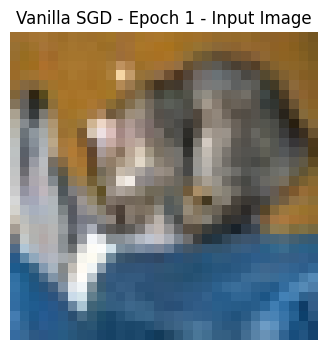

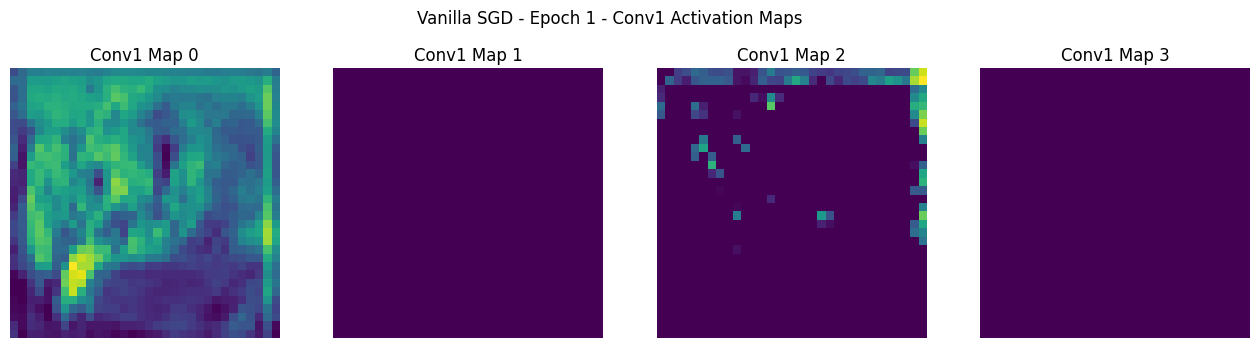

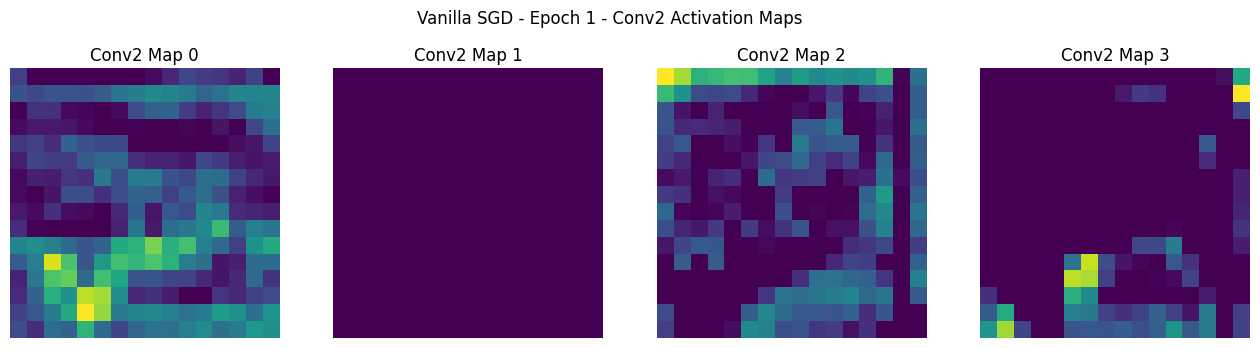

Epoch [2/15] | Train Loss: 2.3052 | Test Loss: 2.3052 | Train Acc: 0.1000 | Test Acc: 0.1000


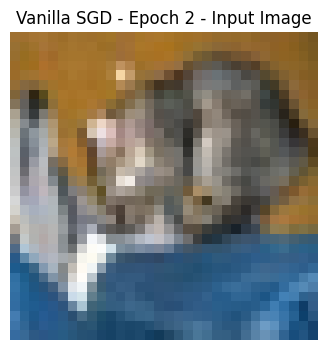

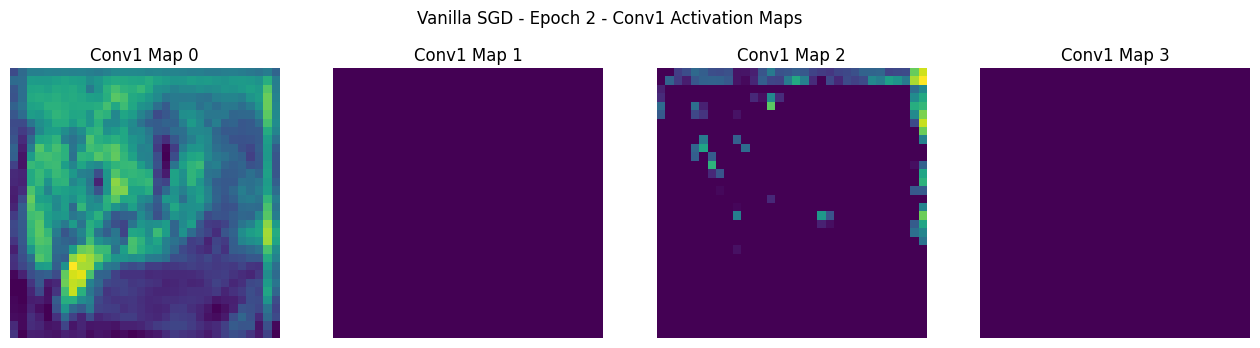

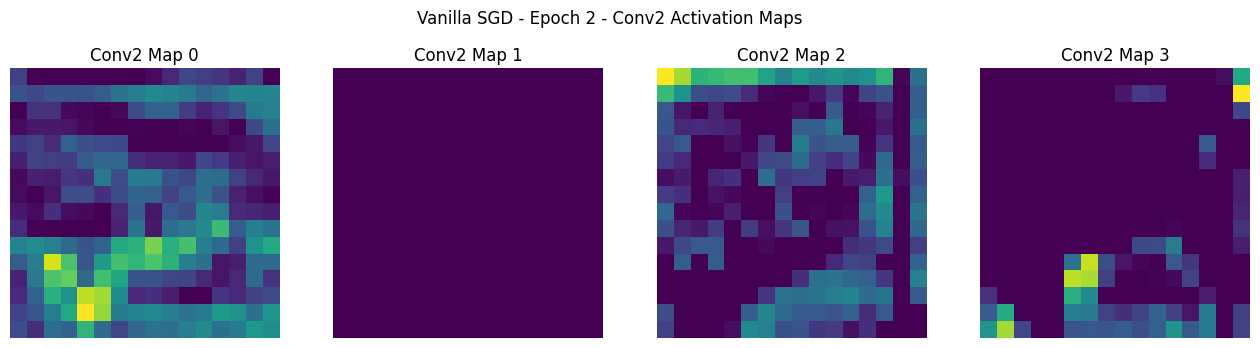

Epoch [3/15] | Train Loss: 2.3052 | Test Loss: 2.3052 | Train Acc: 0.1010 | Test Acc: 0.1000


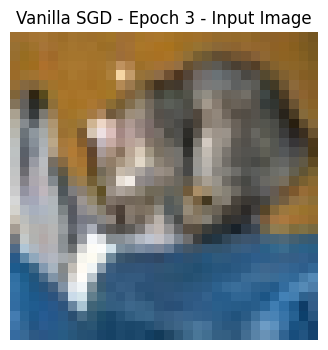

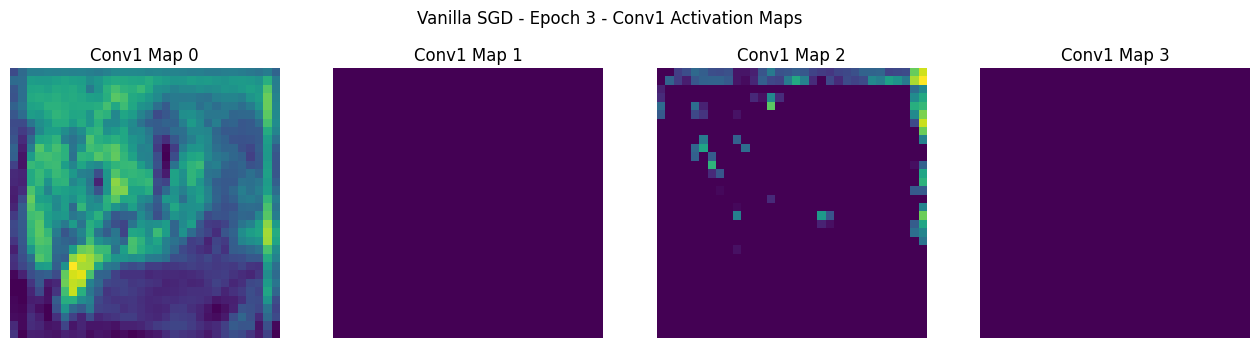

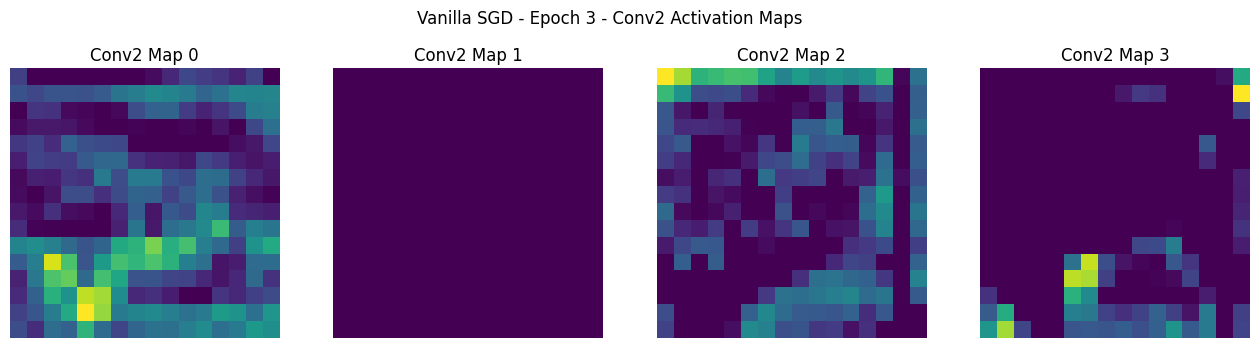

Epoch [4/15] | Train Loss: 2.3051 | Test Loss: 2.3052 | Train Acc: 0.1000 | Test Acc: 0.1000


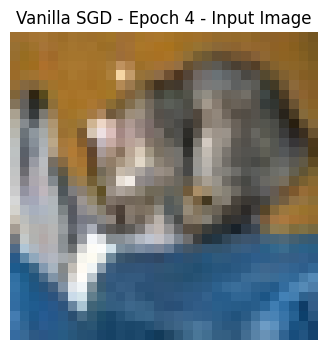

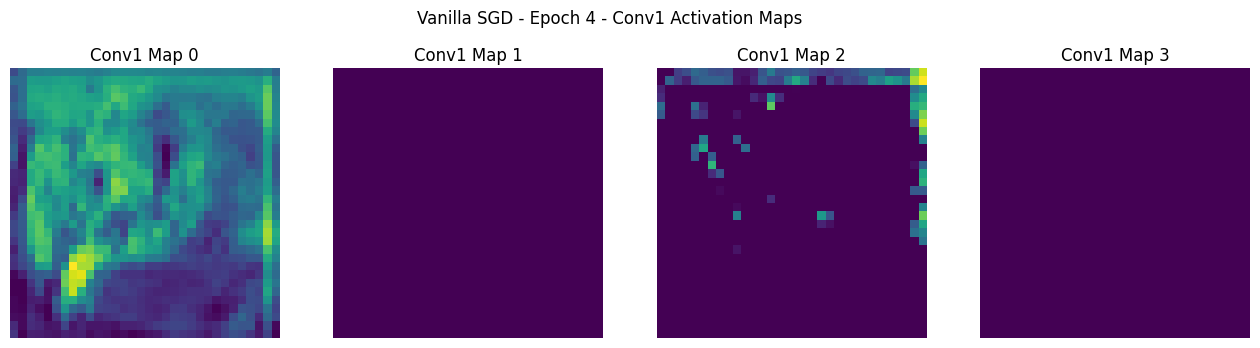

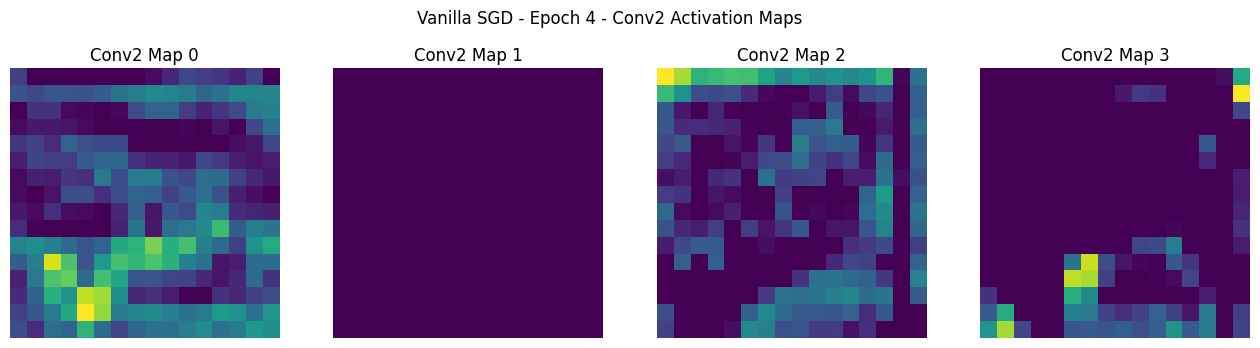

Epoch [5/15] | Train Loss: 2.3051 | Test Loss: 2.3052 | Train Acc: 0.1010 | Test Acc: 0.1000


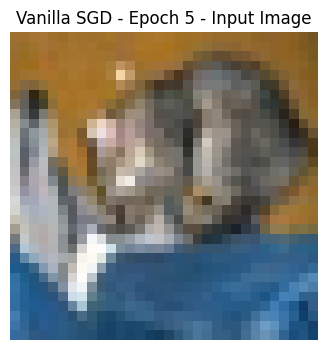

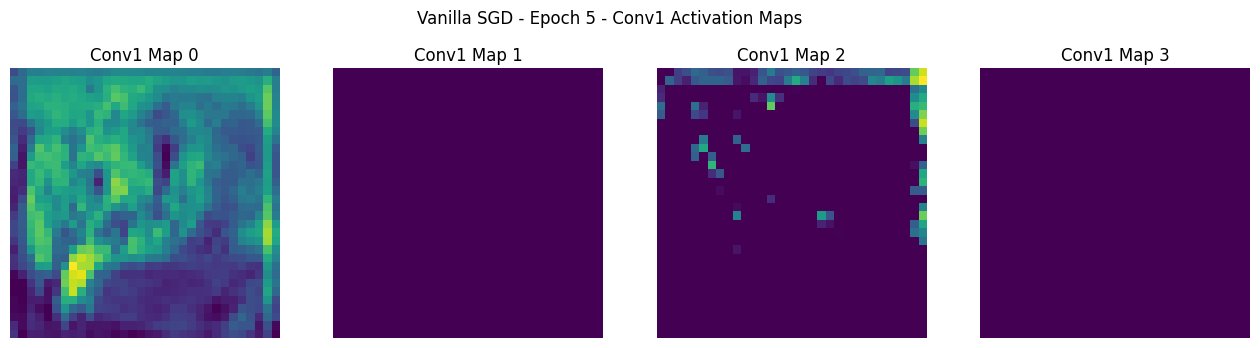

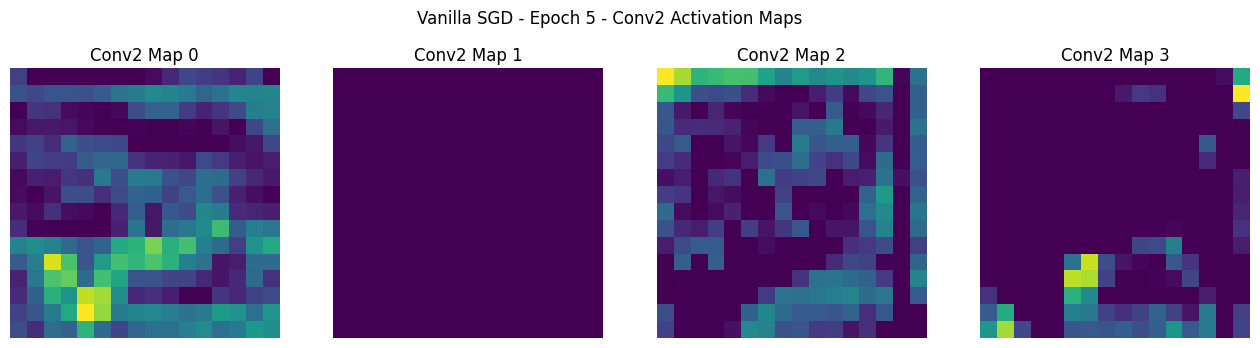

Epoch [6/15] | Train Loss: 2.3051 | Test Loss: 2.3051 | Train Acc: 0.1010 | Test Acc: 0.1000


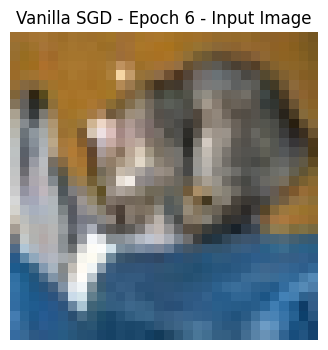

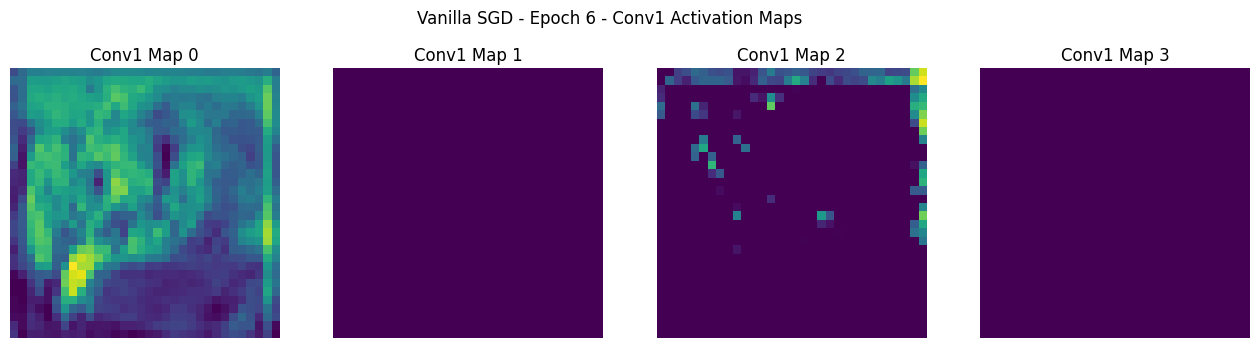

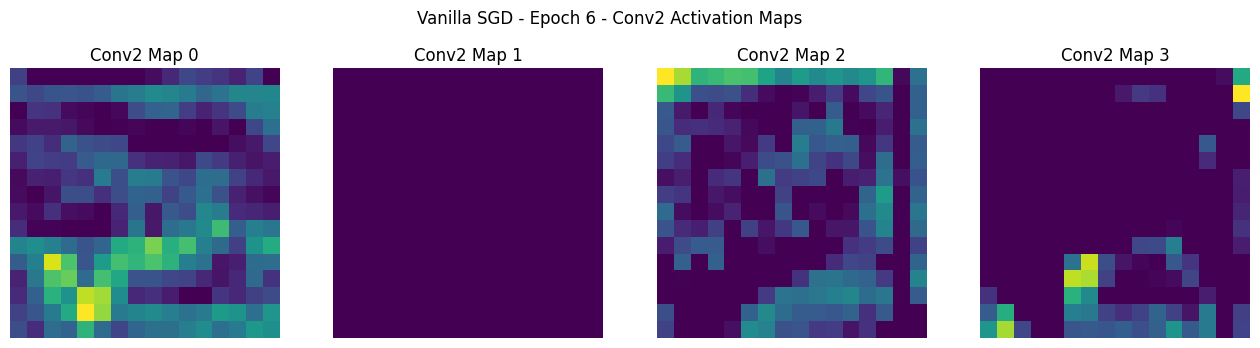

Epoch [7/15] | Train Loss: 2.3051 | Test Loss: 2.3051 | Train Acc: 0.1010 | Test Acc: 0.1000


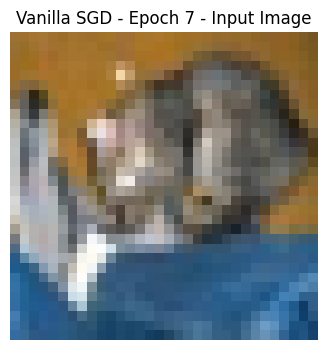

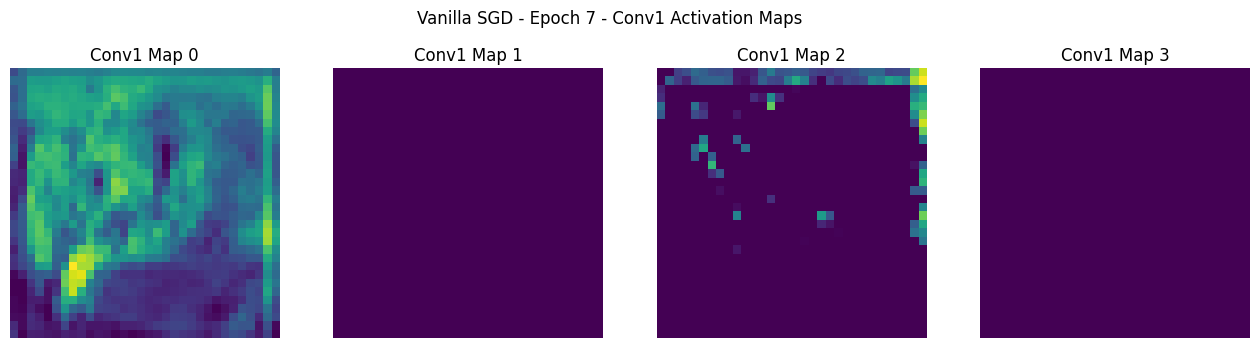

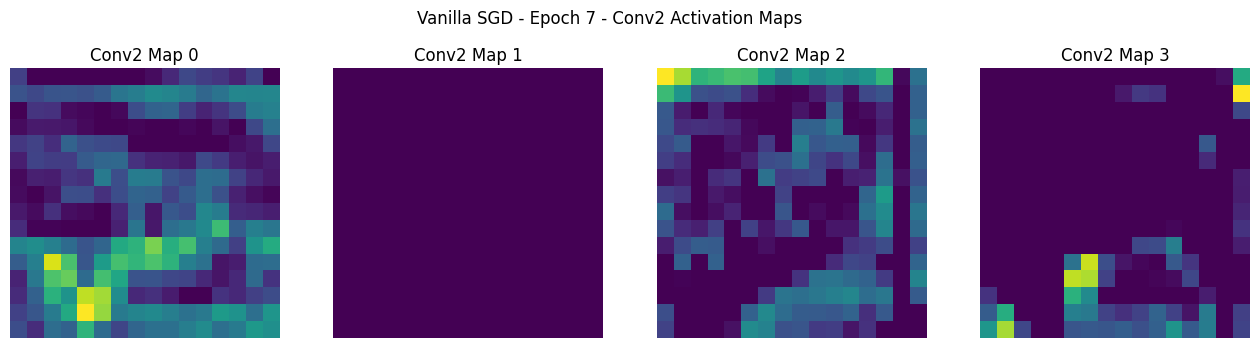

Epoch [8/15] | Train Loss: 2.3050 | Test Loss: 2.3051 | Train Acc: 0.1010 | Test Acc: 0.1000


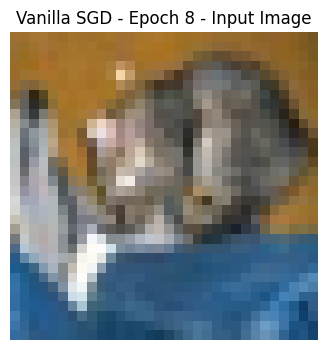

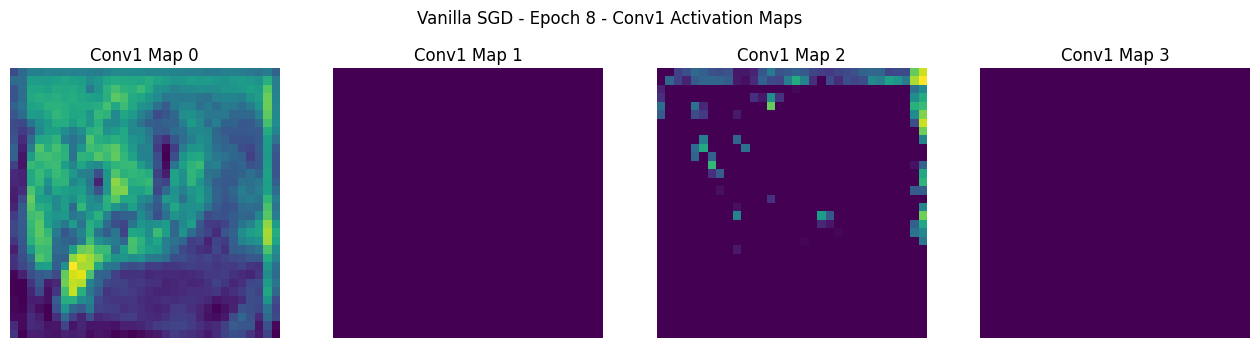

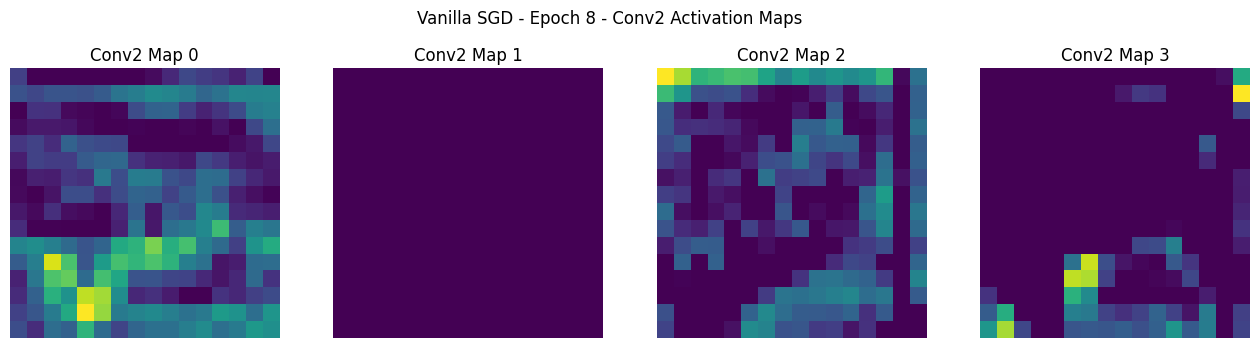

Epoch [9/15] | Train Loss: 2.3050 | Test Loss: 2.3051 | Train Acc: 0.1000 | Test Acc: 0.1000


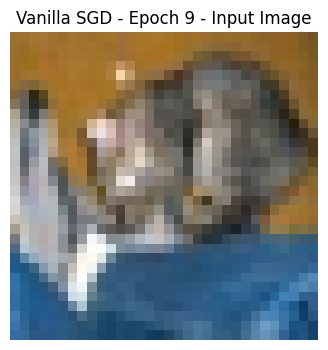

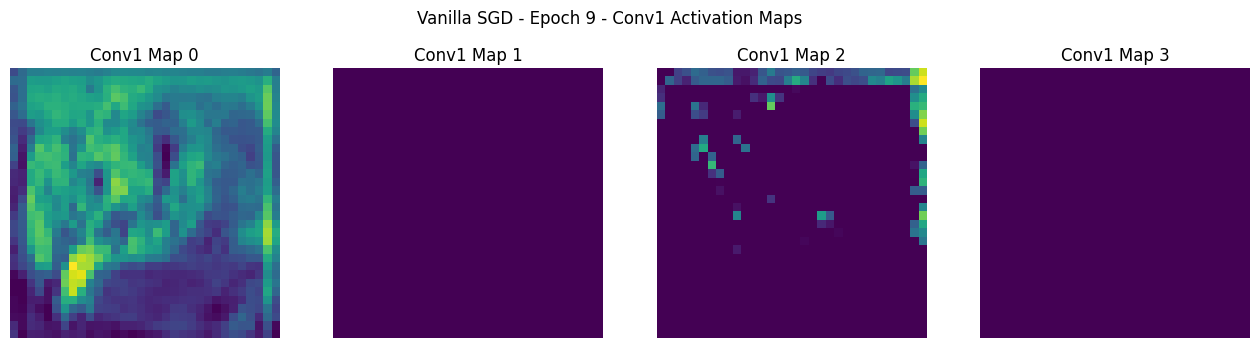

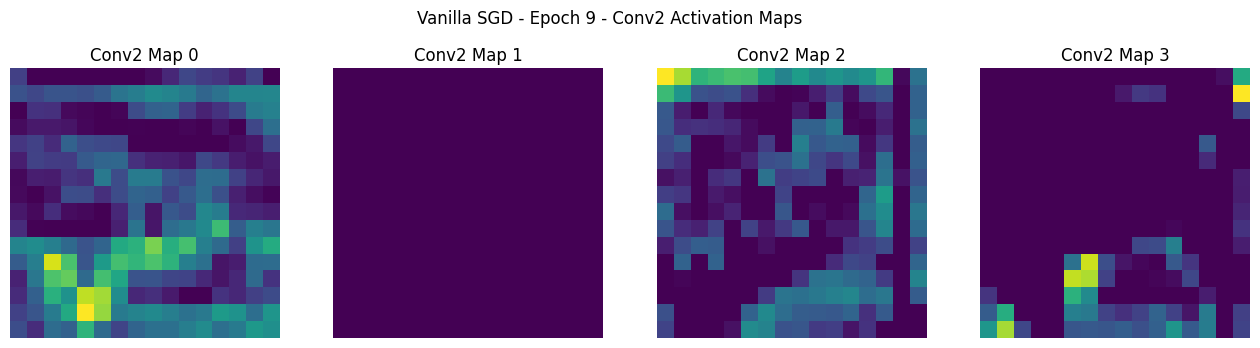

Epoch [10/15] | Train Loss: 2.3050 | Test Loss: 2.3050 | Train Acc: 0.1010 | Test Acc: 0.1000


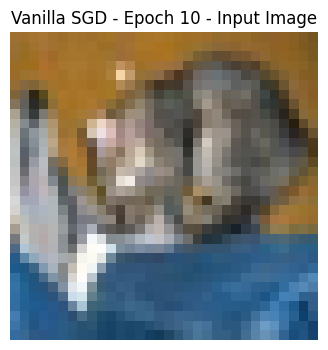

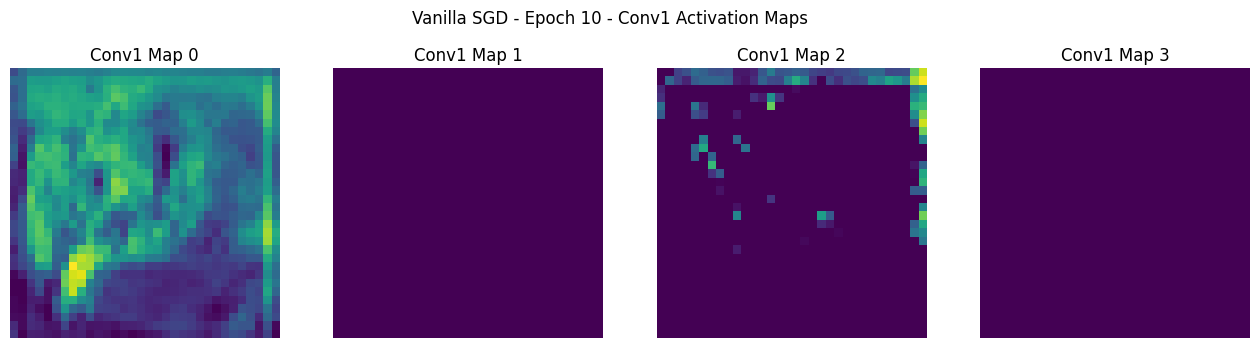

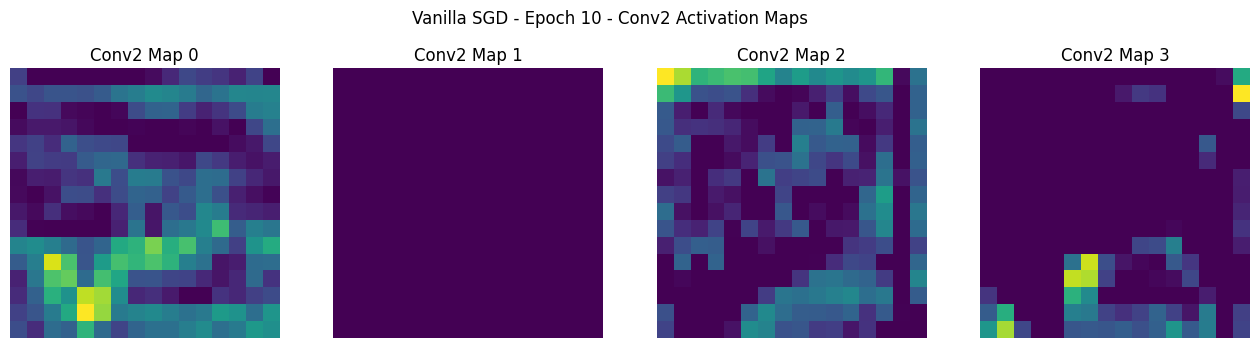

Epoch [11/15] | Train Loss: 2.3050 | Test Loss: 2.3050 | Train Acc: 0.1020 | Test Acc: 0.1000


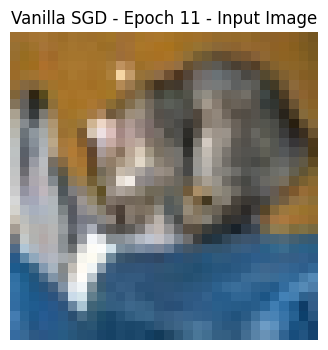

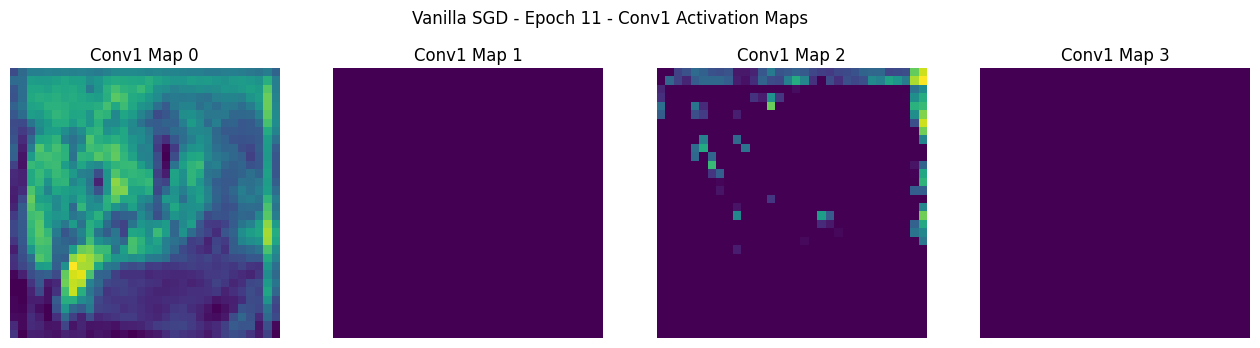

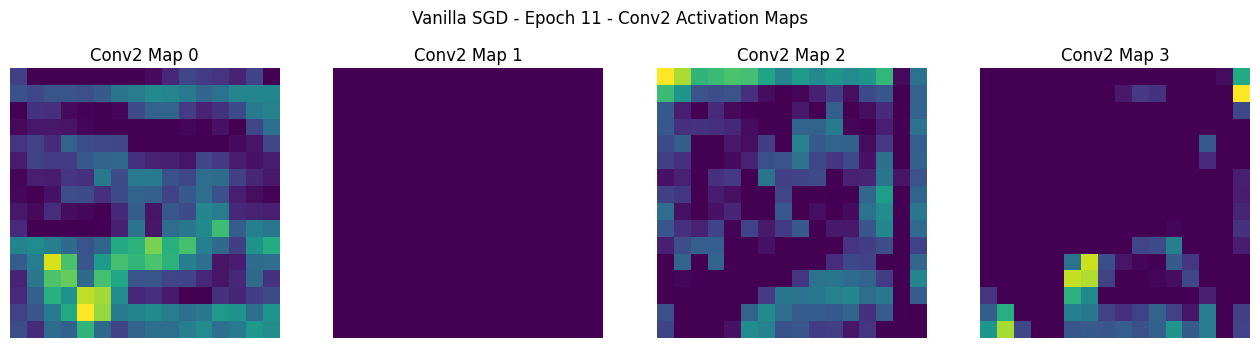

Epoch [12/15] | Train Loss: 2.3049 | Test Loss: 2.3050 | Train Acc: 0.1020 | Test Acc: 0.1000


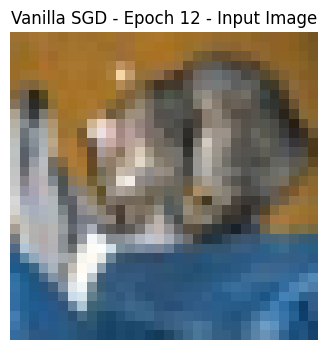

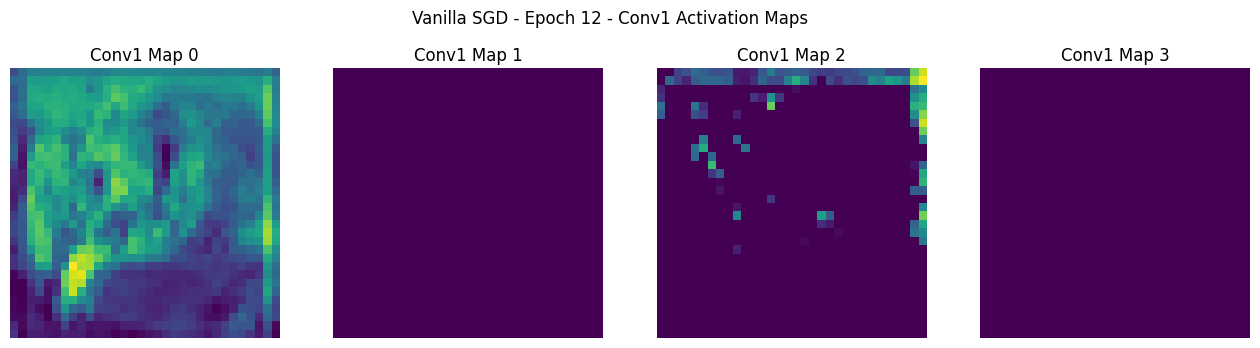

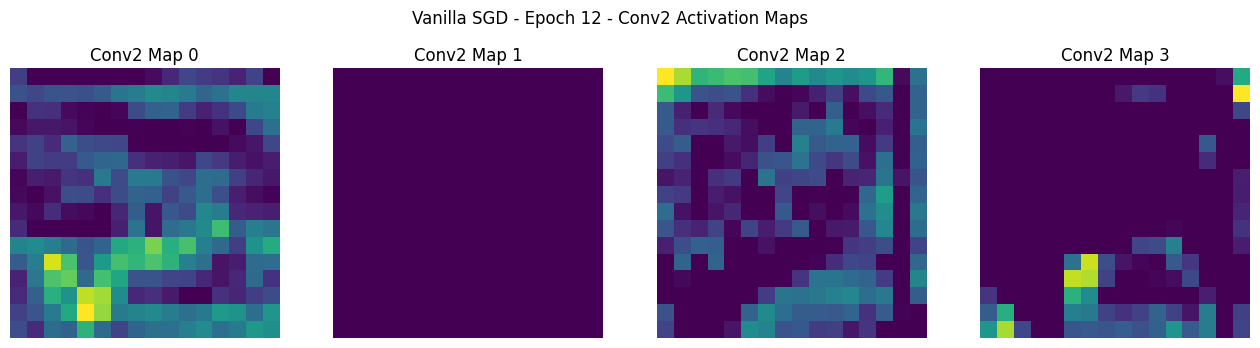

Epoch [13/15] | Train Loss: 2.3049 | Test Loss: 2.3050 | Train Acc: 0.1020 | Test Acc: 0.1000


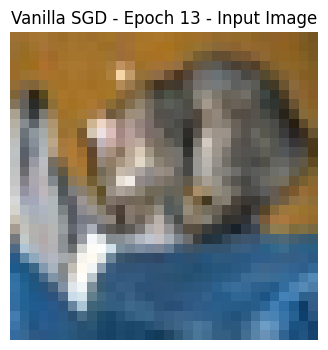

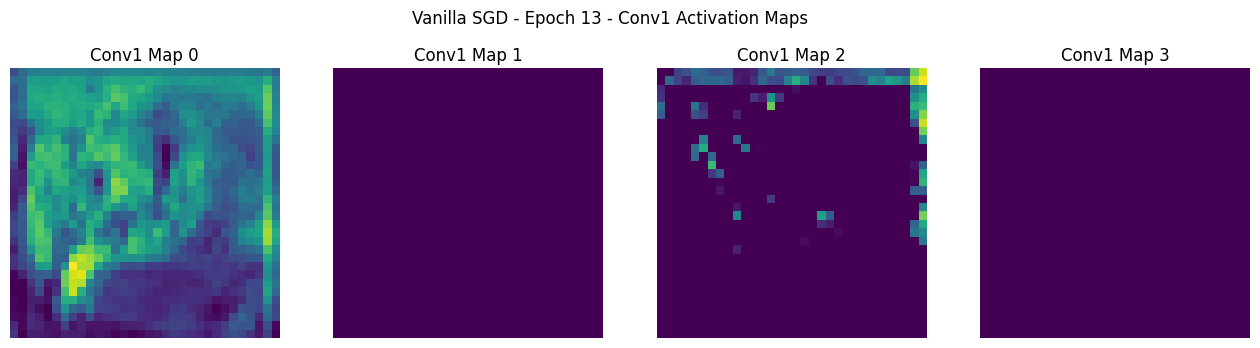

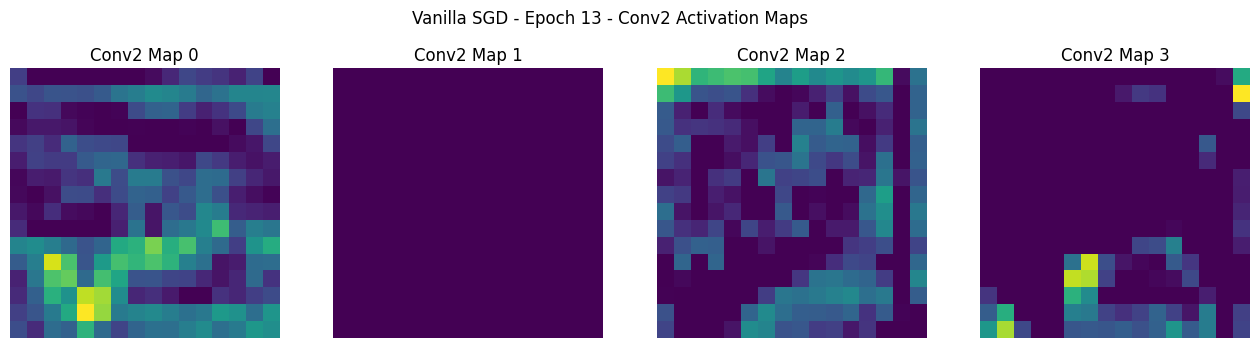

Epoch [14/15] | Train Loss: 2.3049 | Test Loss: 2.3050 | Train Acc: 0.1020 | Test Acc: 0.1000


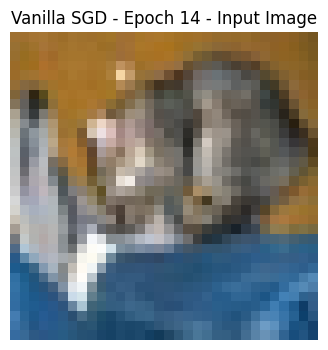

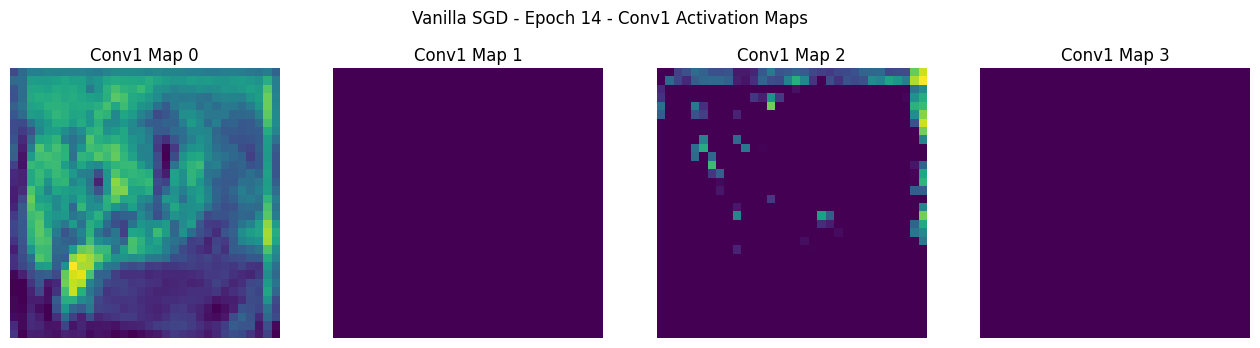

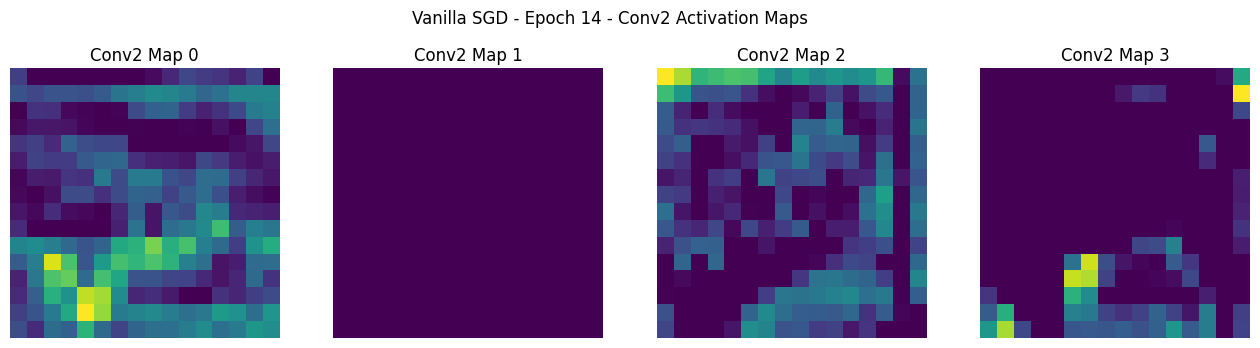

Epoch [15/15] | Train Loss: 2.3049 | Test Loss: 2.3049 | Train Acc: 0.1020 | Test Acc: 0.1000


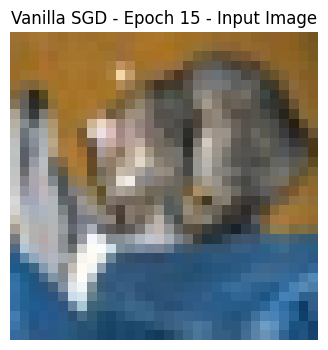

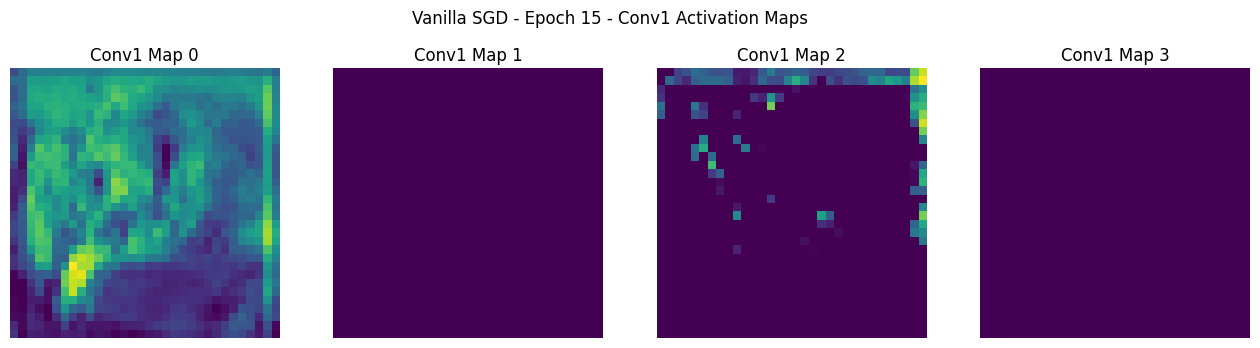

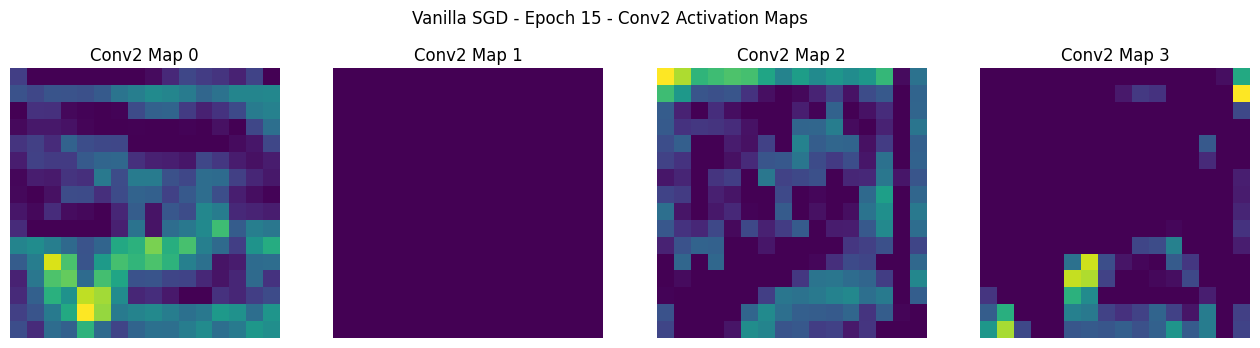

In [ ]:
# 1) Vanilla SGD
torch.manual_seed(42)
model_sgd = SimpleCNN(dropout_p=0.0, use_bn=False).to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.001)

history_sgd = train_model(
    model_sgd,
    train_loader,
    test_loader,
    optimizer_sgd,
    epochs=15,
    model_name="Vanilla SGD"
)

In [ ]:
if "train_losses" not in history_sgd and "train_loss" in history_sgd:
    history_sgd["train_losses"] = history_sgd["train_loss"]

if "test_losses" not in history_sgd and "test_loss" in history_sgd:
    history_sgd["test_losses"] = history_sgd["test_loss"]

if "train_accuracies" not in history_sgd and "train_acc" in history_sgd:
    history_sgd["train_accuracies"] = history_sgd["train_acc"]

if "test_accuracies" not in history_sgd and "test_acc" in history_sgd:
    history_sgd["test_accuracies"] = history_sgd["test_acc"]

In [ ]:
import matplotlib.pyplot as plt

def plot_accuracy_curves(history, title="Accuracy Curves"):
    epochs = range(1, len(history["train_acc"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], marker='o', label="Training Accuracy")
    plt.plot(epochs, history["test_acc"], marker='s', label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

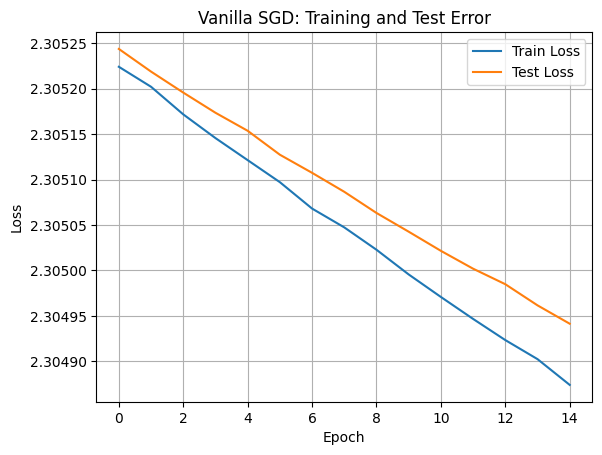

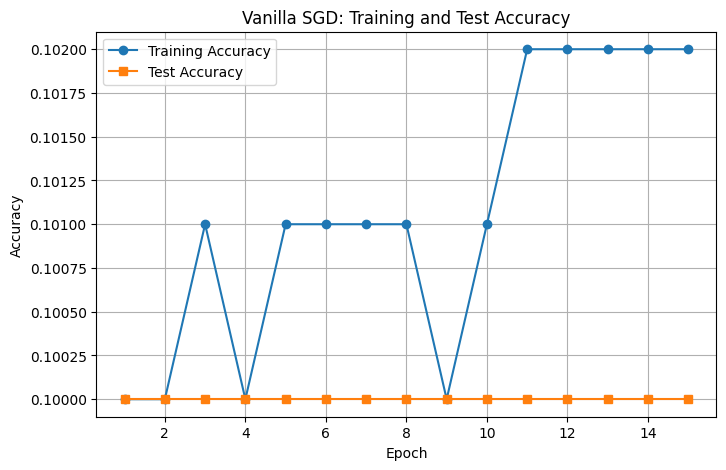

In [ ]:
plot_loss_curves(history_sgd, title="Vanilla SGD: Training and Test Error")
plot_accuracy_curves(history_sgd, title="Vanilla SGD: Training and Test Accuracy")

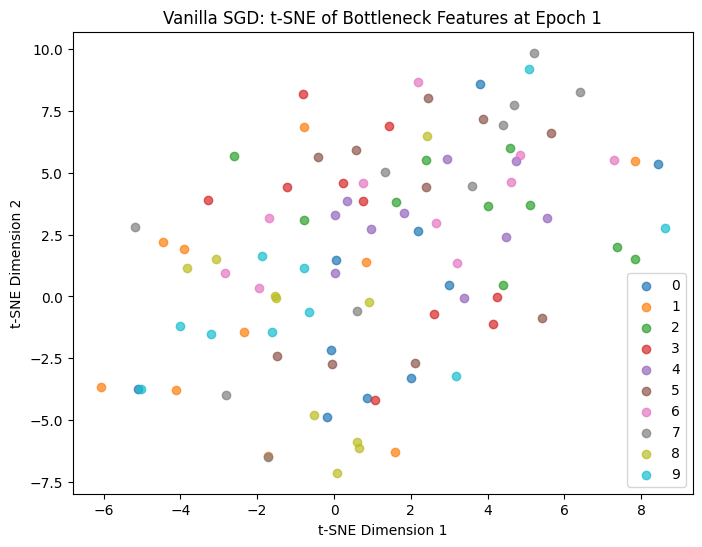

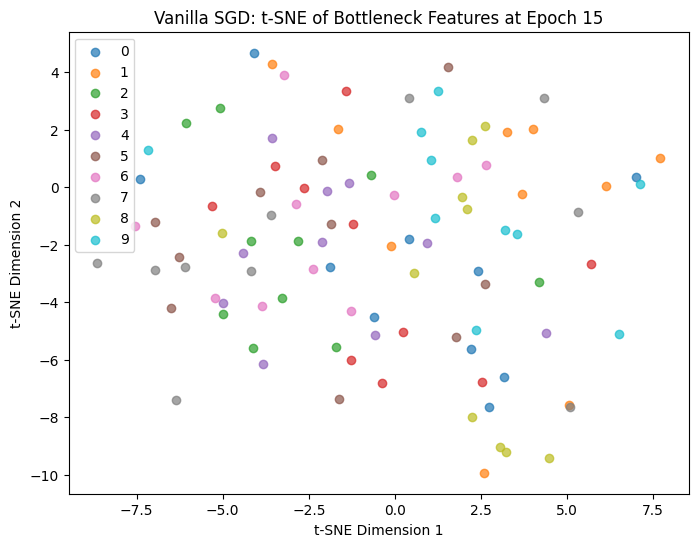

In [ ]:
plot_tsne(history_sgd["epoch1_features"], history_sgd["epoch1_labels"],
          title="Vanilla SGD: t-SNE of Bottleneck Features at Epoch 1")

plot_tsne(history_sgd["epoch_last_features"], history_sgd["epoch_last_labels"],
          title="Vanilla SGD: t-SNE of Bottleneck Features at Epoch 15")

Epoch [1/15] | Train Loss: 2.3052 | Test Loss: 2.3051 | Train Acc: 0.1010 | Test Acc: 0.1000


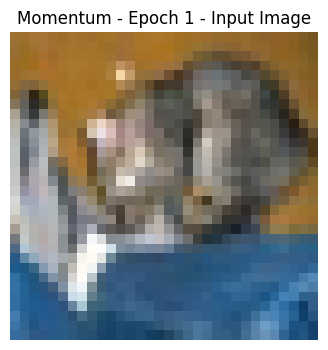

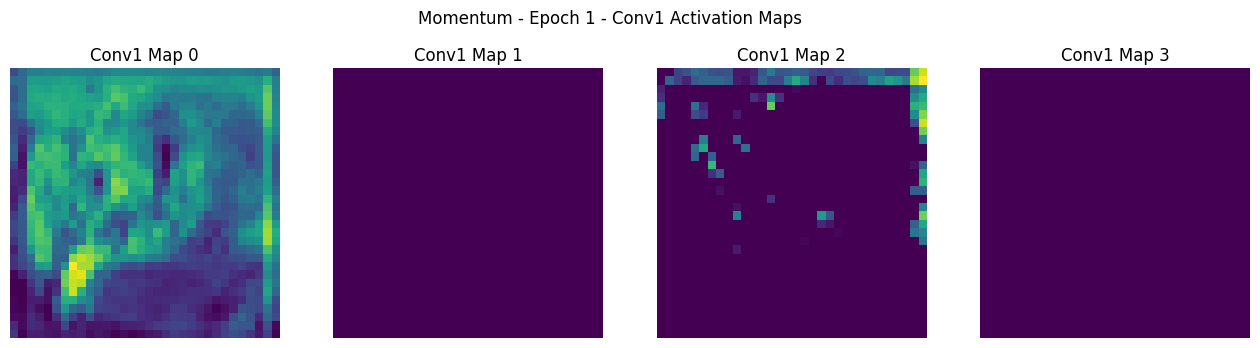

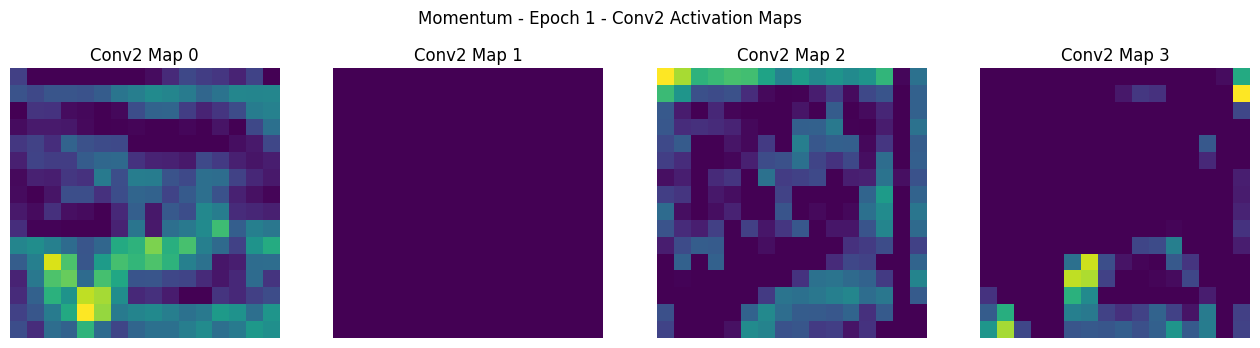

Epoch [2/15] | Train Loss: 2.3051 | Test Loss: 2.3048 | Train Acc: 0.1000 | Test Acc: 0.1000


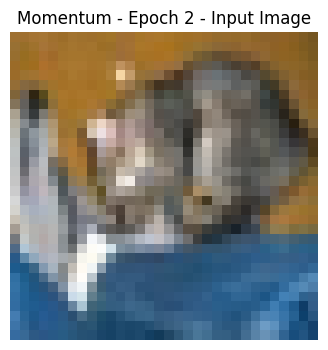

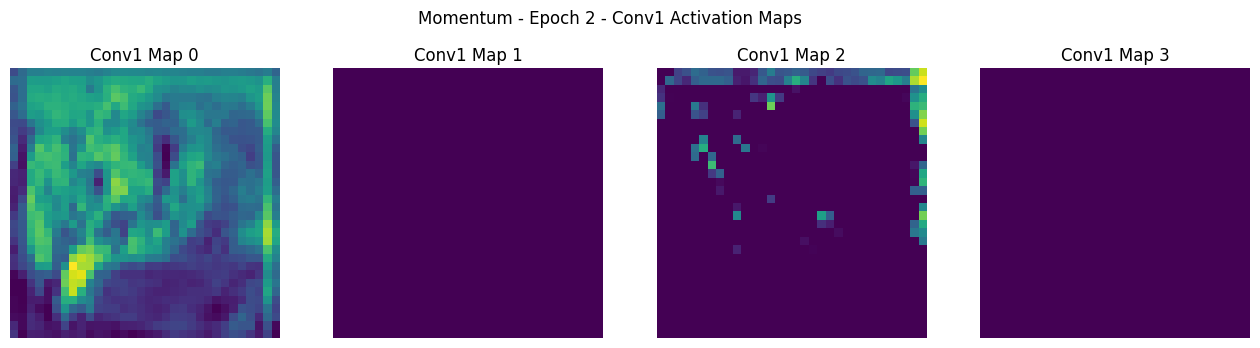

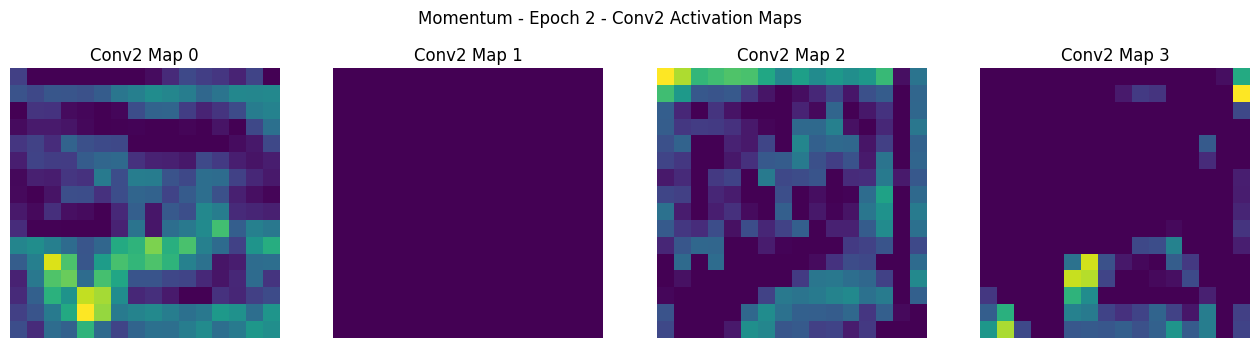

Epoch [3/15] | Train Loss: 2.3048 | Test Loss: 2.3046 | Train Acc: 0.1020 | Test Acc: 0.0900


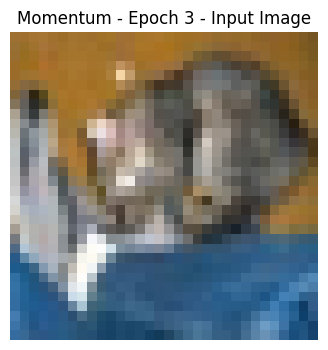

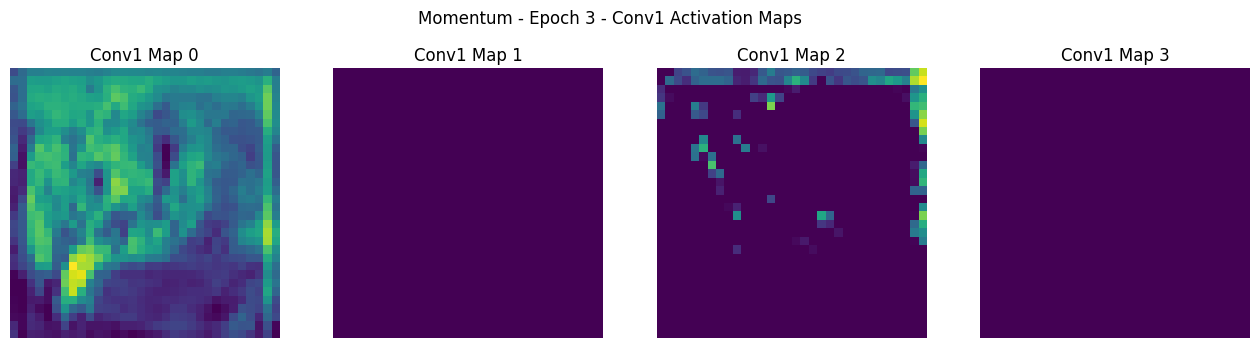

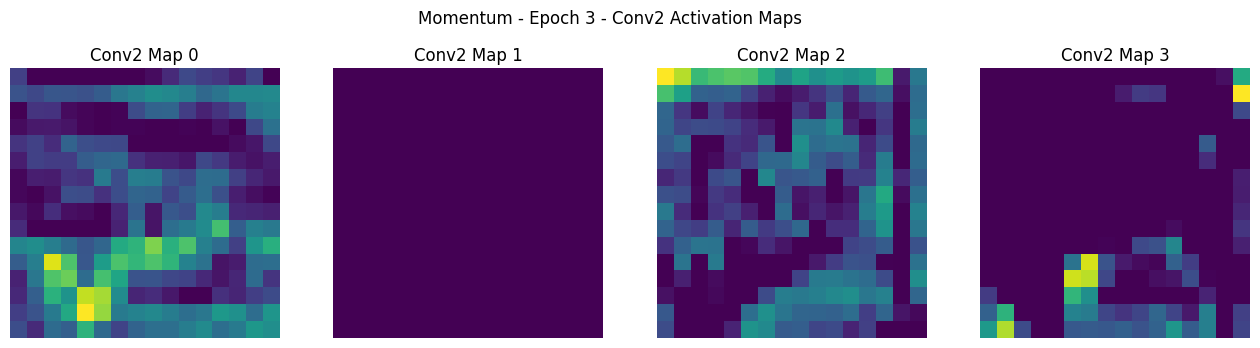

Epoch [4/15] | Train Loss: 2.3045 | Test Loss: 2.3043 | Train Acc: 0.0980 | Test Acc: 0.1000


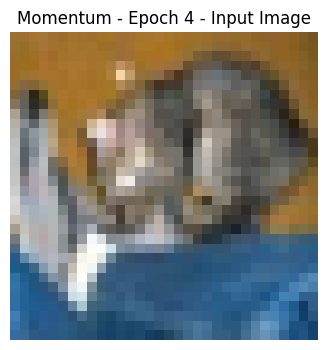

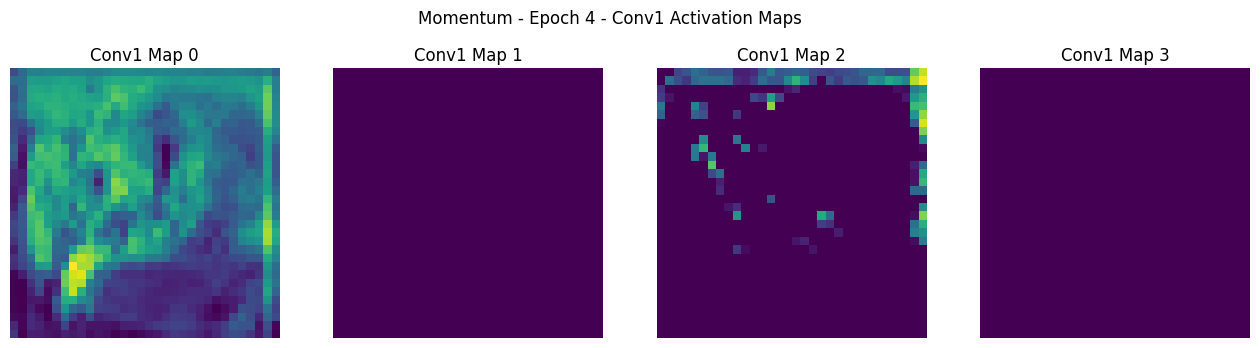

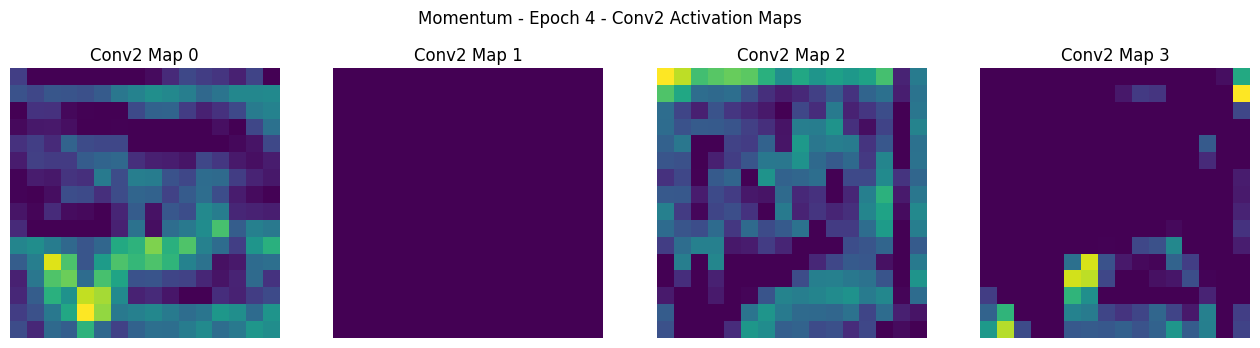

Epoch [5/15] | Train Loss: 2.3043 | Test Loss: 2.3042 | Train Acc: 0.0950 | Test Acc: 0.1000


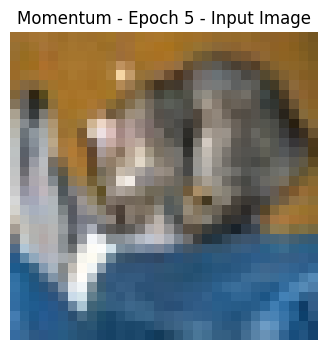

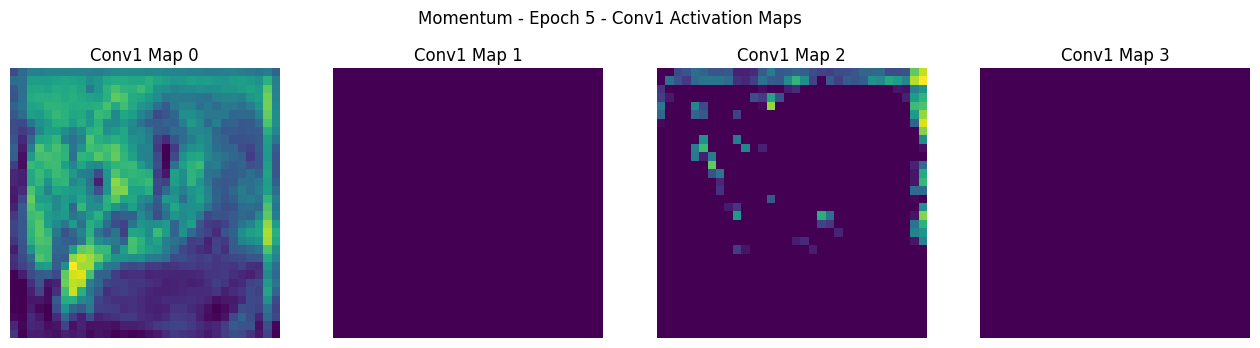

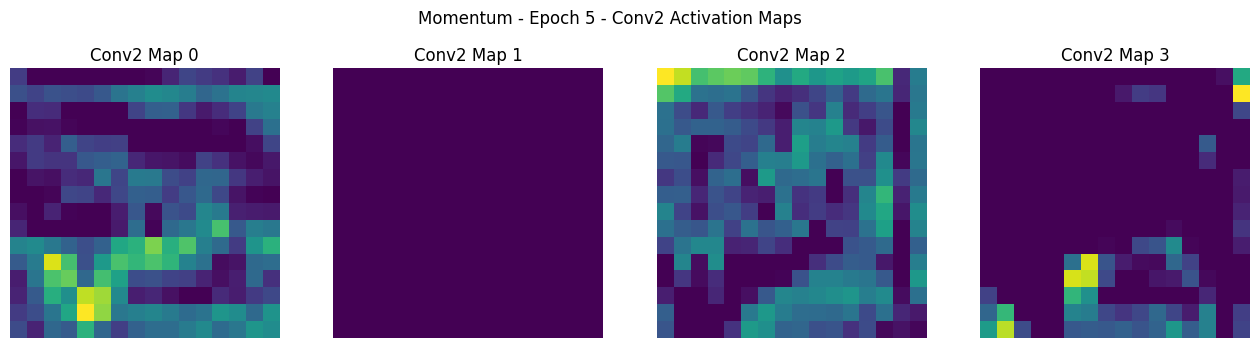

Epoch [6/15] | Train Loss: 2.3041 | Test Loss: 2.3040 | Train Acc: 0.0970 | Test Acc: 0.0900


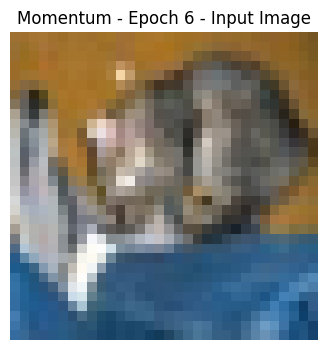

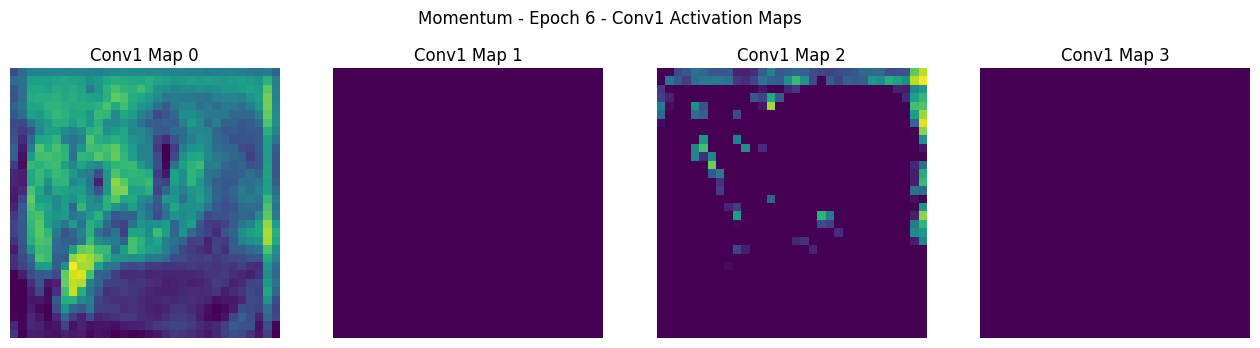

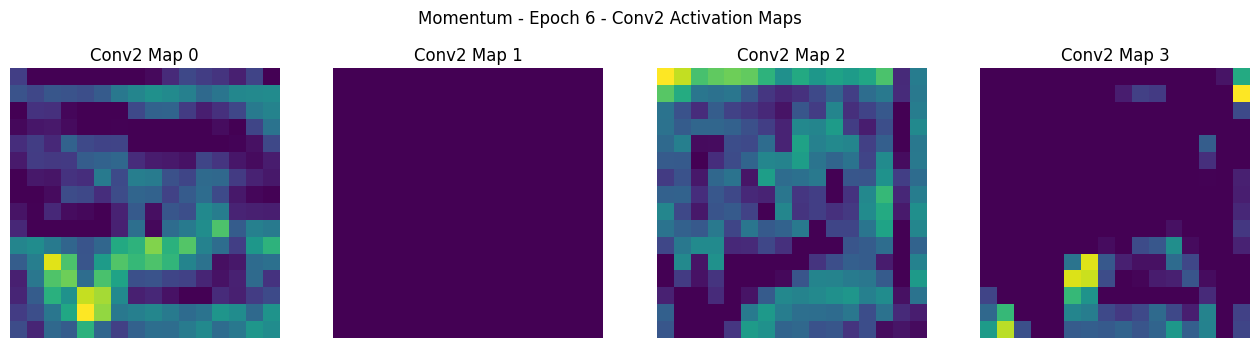

Epoch [7/15] | Train Loss: 2.3038 | Test Loss: 2.3037 | Train Acc: 0.0970 | Test Acc: 0.0900


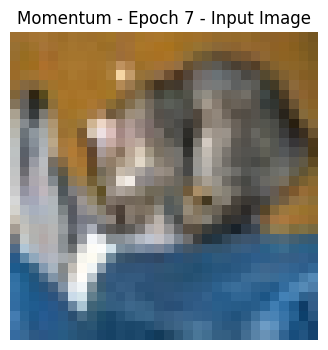

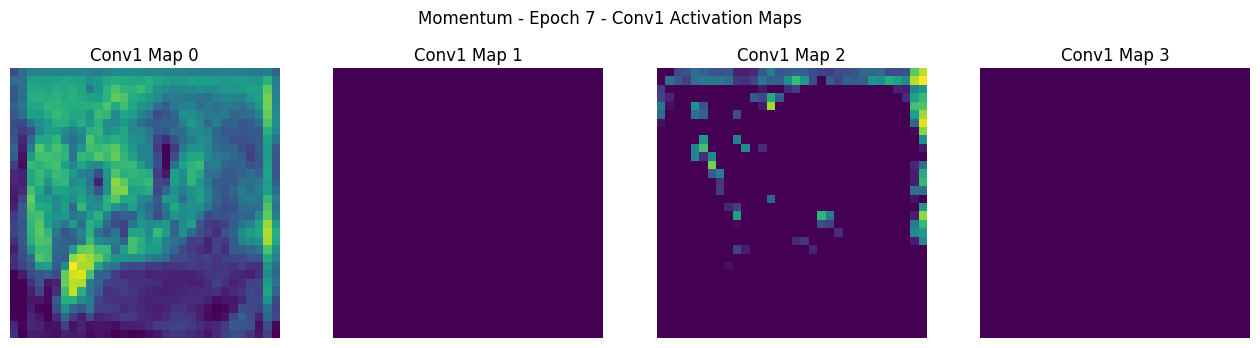

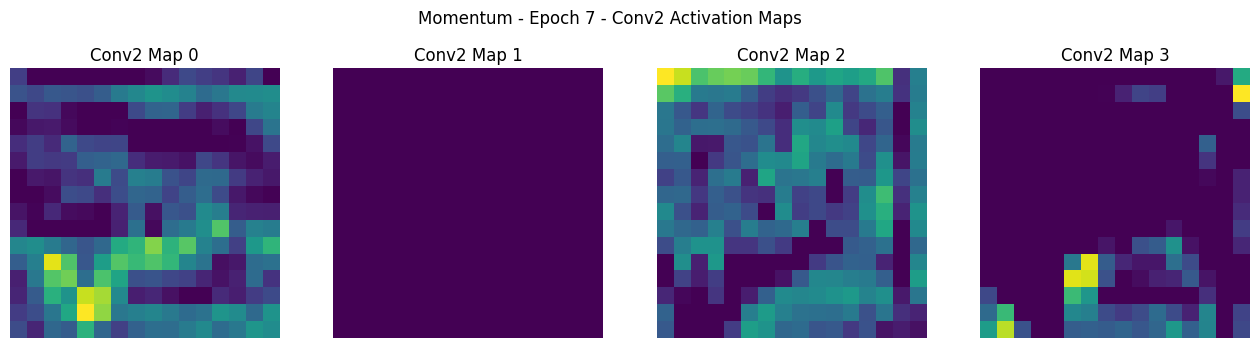

Epoch [8/15] | Train Loss: 2.3037 | Test Loss: 2.3036 | Train Acc: 0.1000 | Test Acc: 0.1100


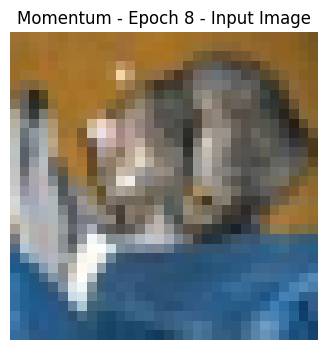

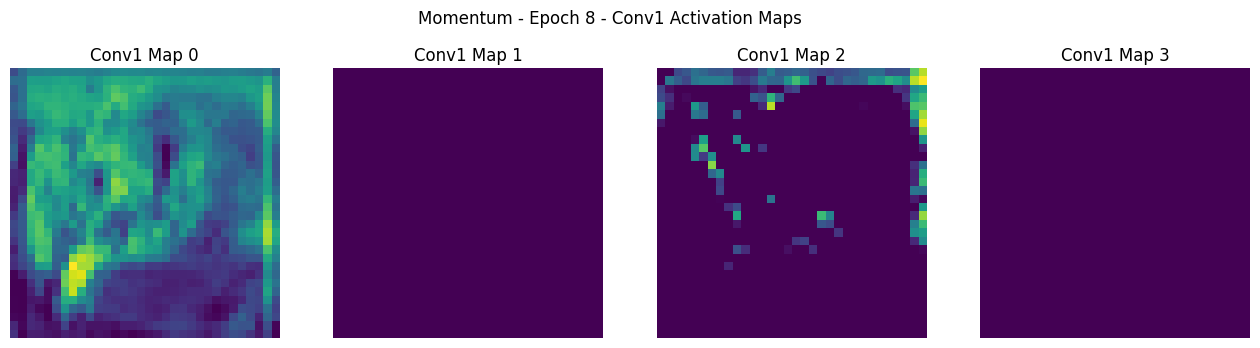

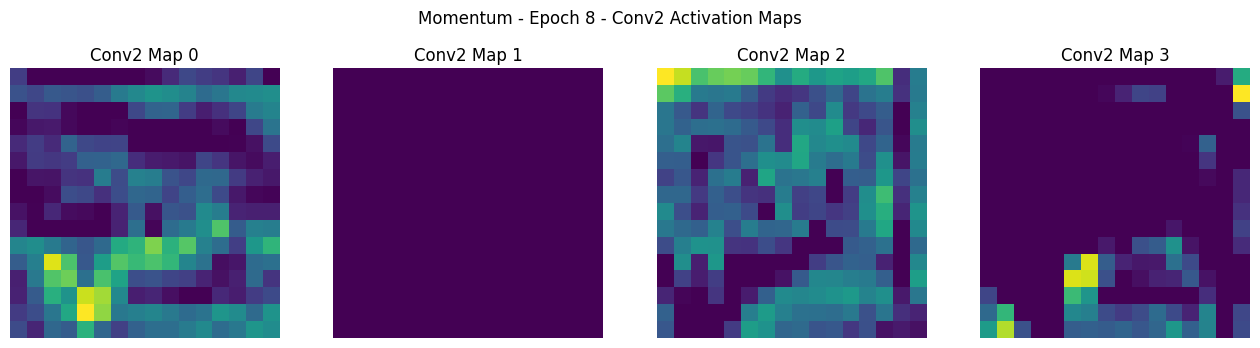

Epoch [9/15] | Train Loss: 2.3035 | Test Loss: 2.3034 | Train Acc: 0.1030 | Test Acc: 0.0900


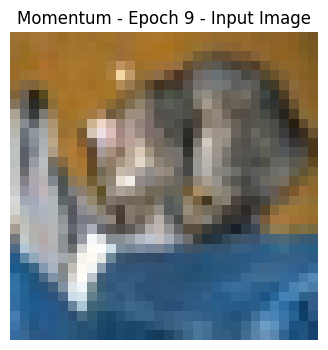

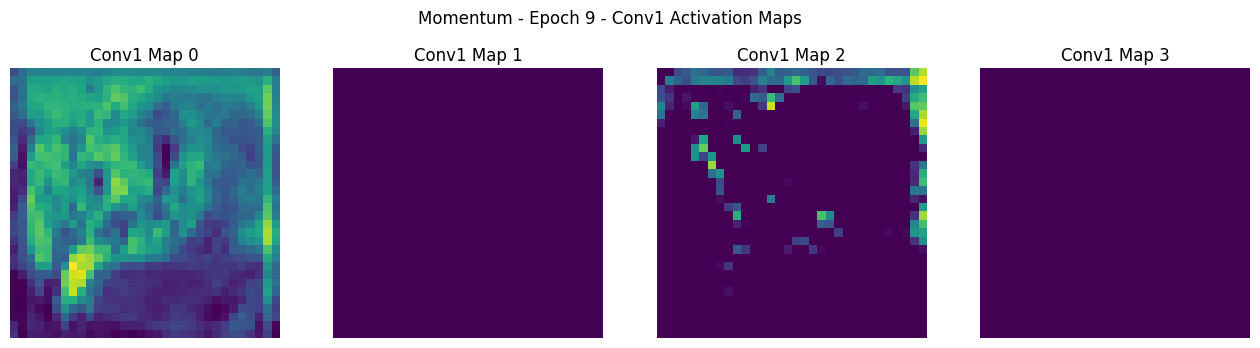

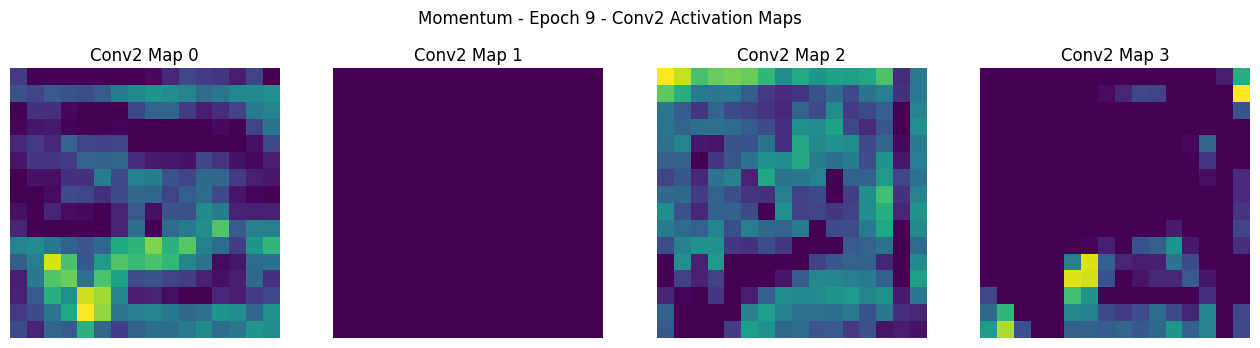

Epoch [10/15] | Train Loss: 2.3034 | Test Loss: 2.3032 | Train Acc: 0.0970 | Test Acc: 0.1100


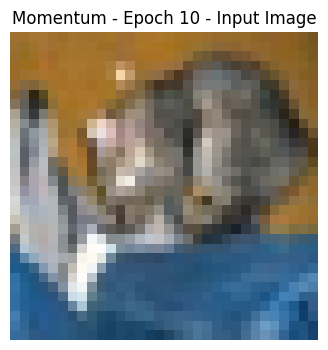

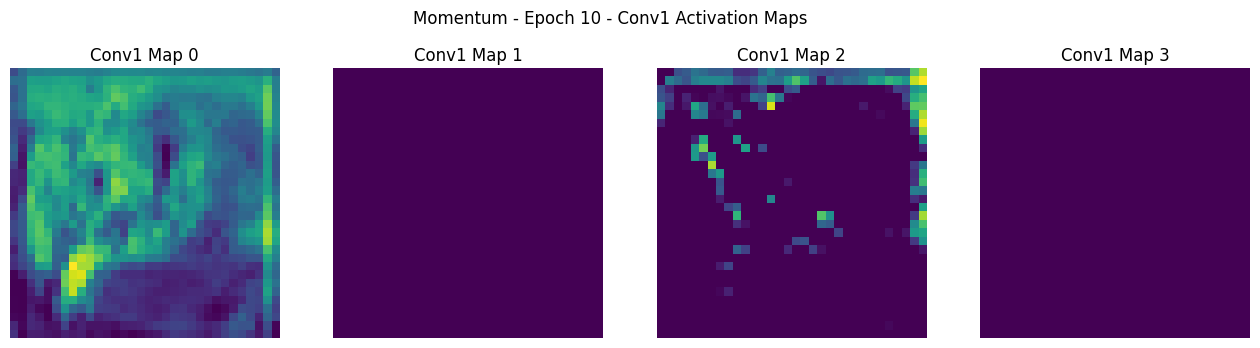

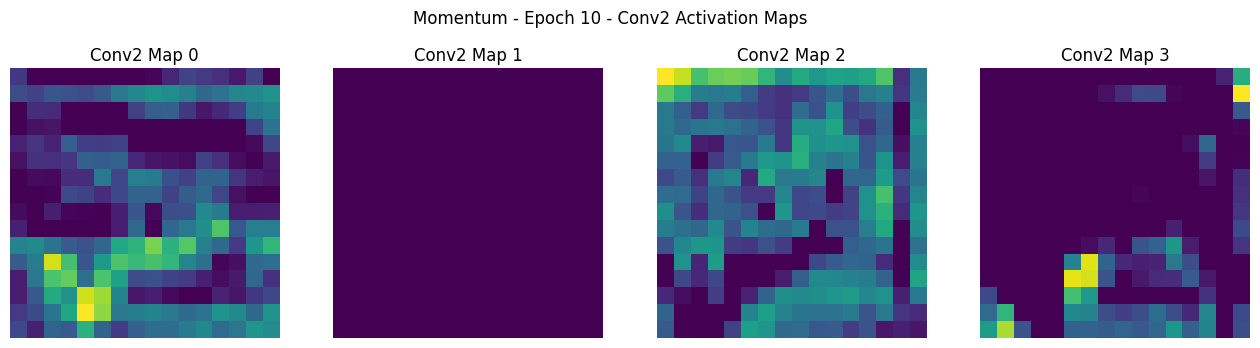

Epoch [11/15] | Train Loss: 2.3032 | Test Loss: 2.3031 | Train Acc: 0.1050 | Test Acc: 0.1200


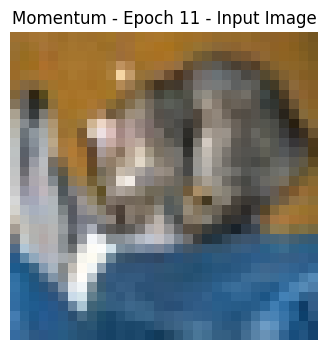

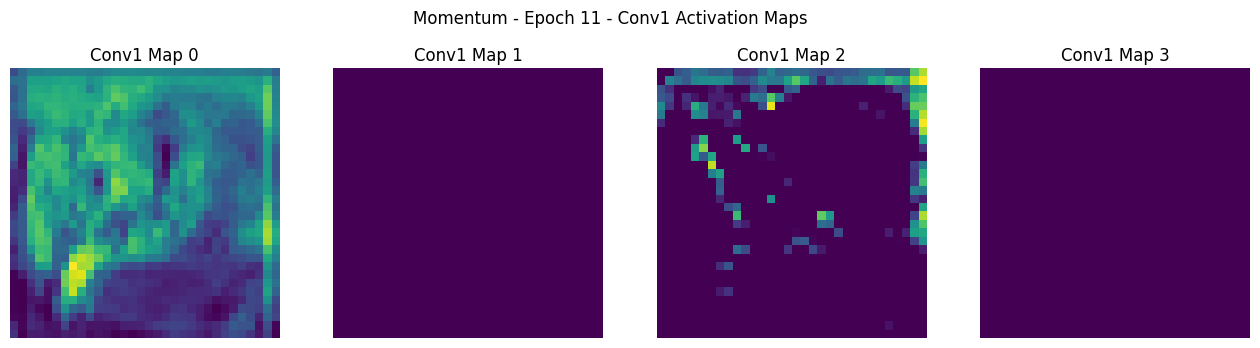

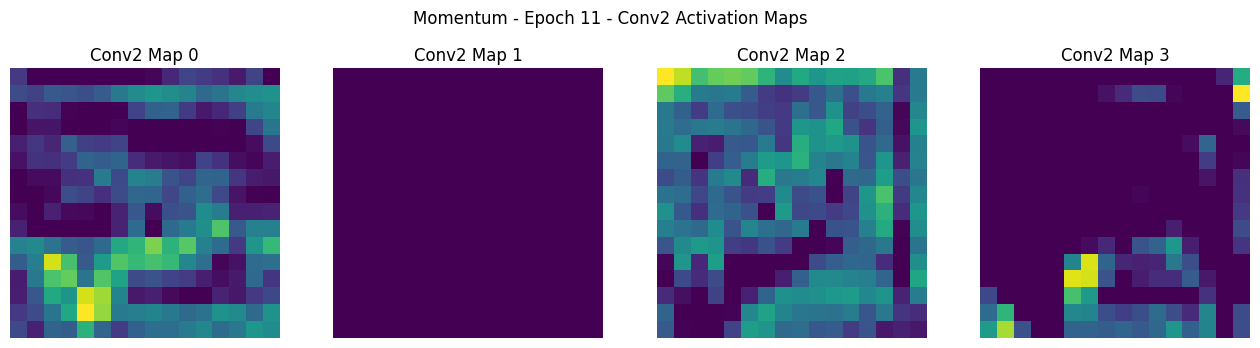

Epoch [12/15] | Train Loss: 2.3031 | Test Loss: 2.3029 | Train Acc: 0.0900 | Test Acc: 0.1400


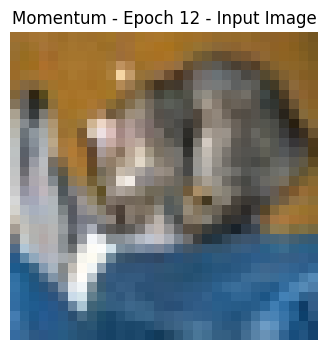

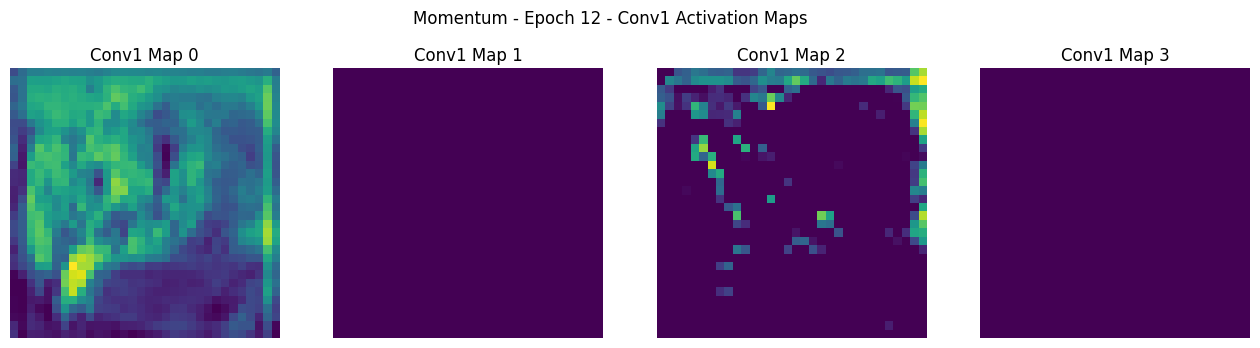

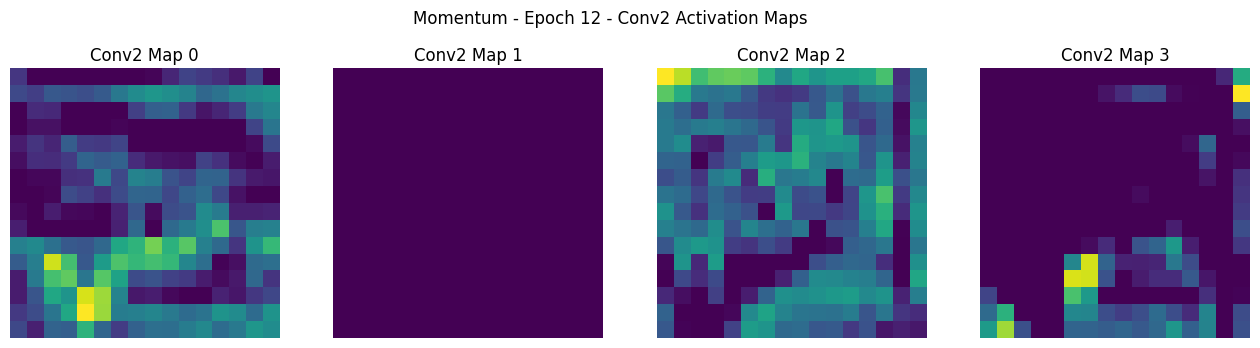

Epoch [13/15] | Train Loss: 2.3029 | Test Loss: 2.3028 | Train Acc: 0.1020 | Test Acc: 0.1100


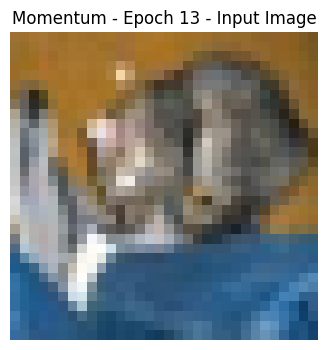

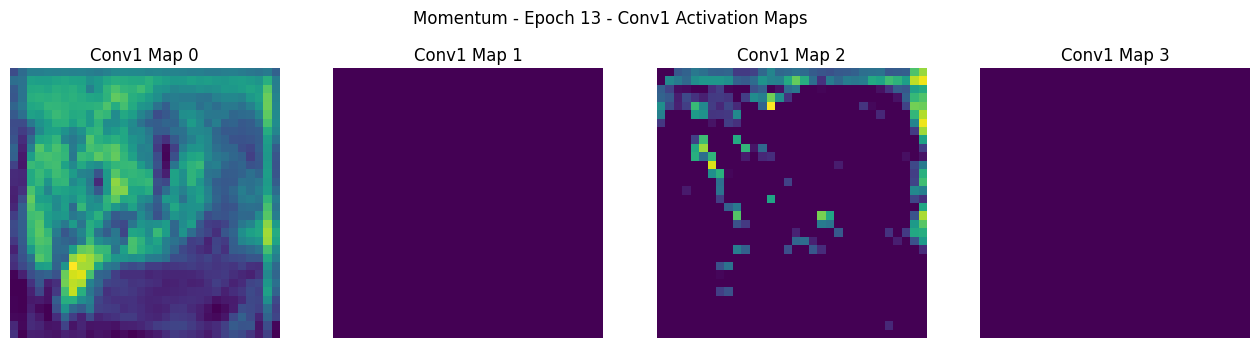

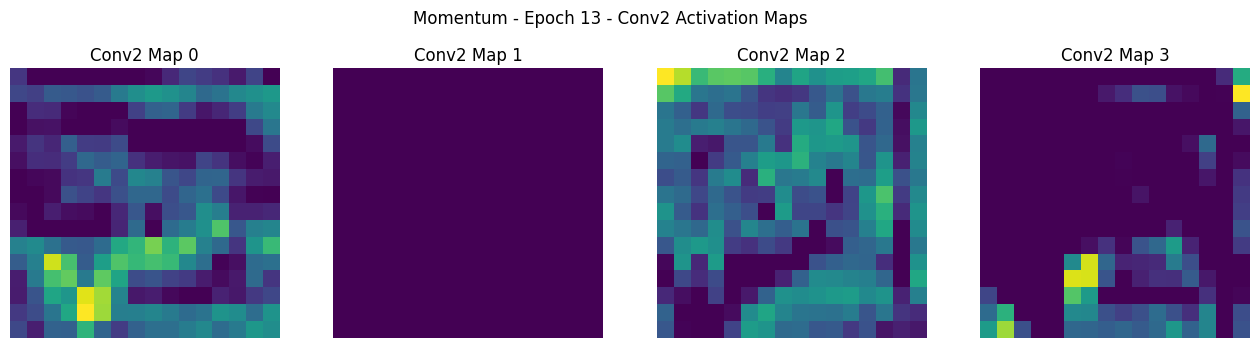

Epoch [14/15] | Train Loss: 2.3028 | Test Loss: 2.3027 | Train Acc: 0.1030 | Test Acc: 0.1300


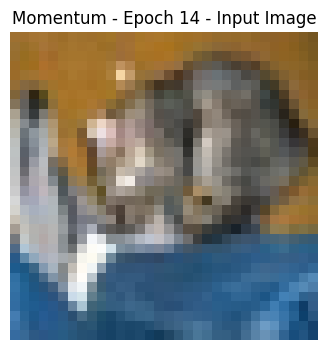

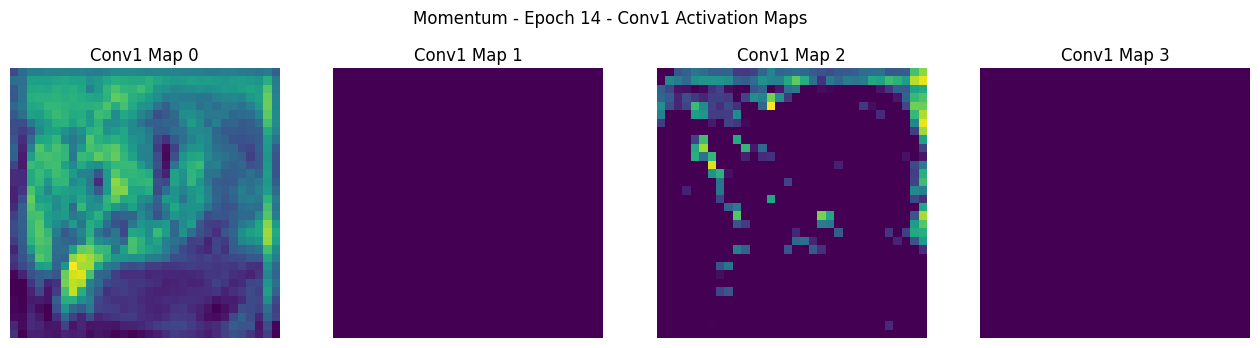

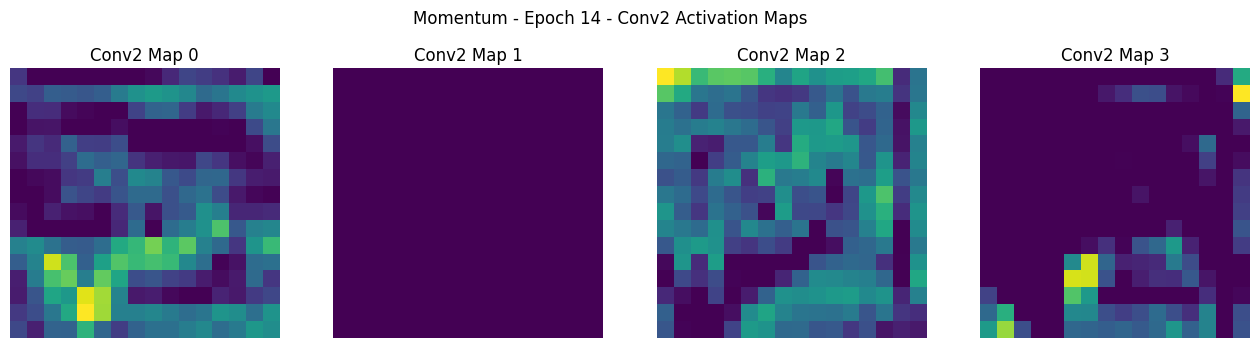

Epoch [15/15] | Train Loss: 2.3026 | Test Loss: 2.3025 | Train Acc: 0.1000 | Test Acc: 0.1300


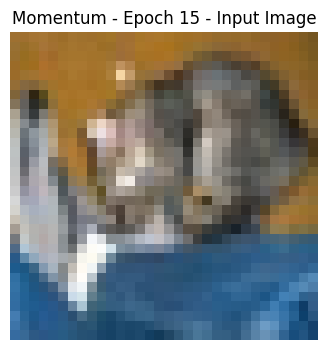

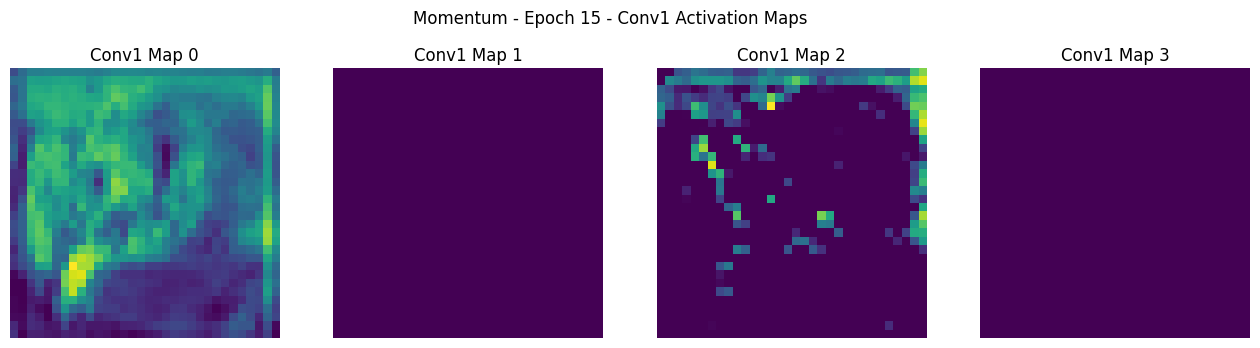

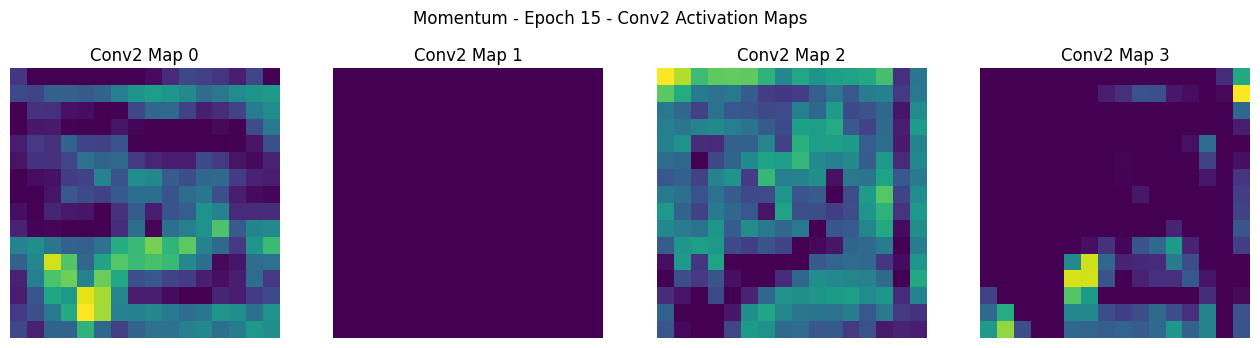

In [ ]:
# 2) Momentum
torch.manual_seed(42)
model_momentum = SimpleCNN(dropout_p=0.0, use_bn=False).to(device)
optimizer_momentum = optim.SGD(model_momentum.parameters(), lr=0.001, momentum=0.9)

history_momentum = train_model(
    model_momentum,
    train_loader,
    test_loader,
    optimizer_momentum,
    epochs=15,
    model_name="Momentum"
)

In [ ]:
def patch_history_keys(history):
    new_history = {}

    if "train_losses" in history:
        new_history["train_losses"] = history["train_losses"]
    elif "train_loss" in history:
        new_history["train_losses"] = history["train_loss"]

    if "test_losses" in history:
        new_history["test_losses"] = history["test_losses"]
    elif "test_loss" in history:
        new_history["test_losses"] = history["test_loss"]

    if "train_accuracies" in history:
        new_history["train_accuracies"] = history["train_accuracies"]
    elif "train_acc" in history:
        new_history["train_accuracies"] = history["train_acc"]

    if "test_accuracies" in history:
        new_history["test_accuracies"] = history["test_accuracies"]
    elif "test_acc" in history:
        new_history["test_accuracies"] = history["test_acc"]

    return new_history

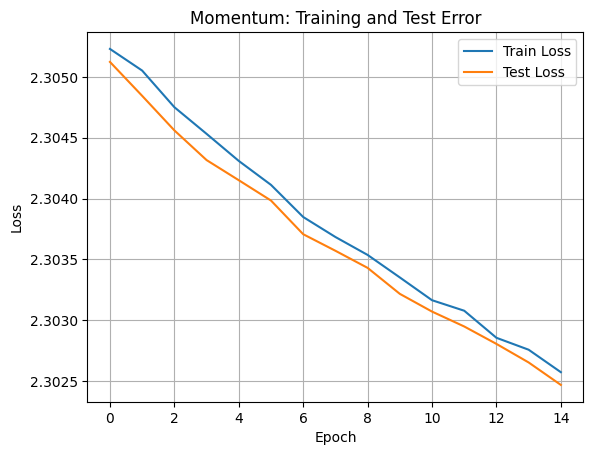

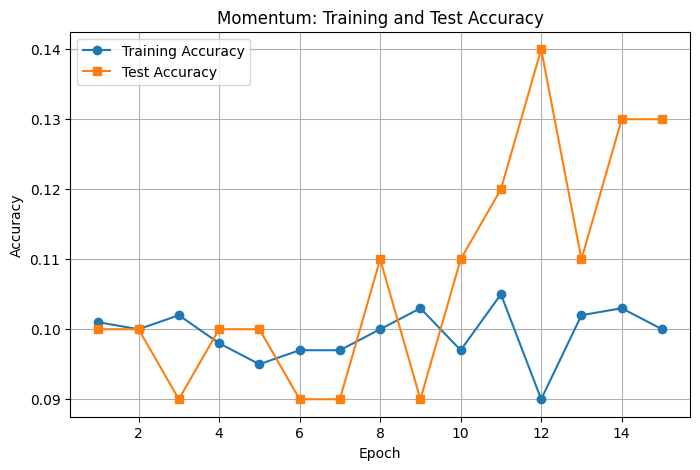

In [ ]:
plot_loss_curves(history_momentum, title="Momentum: Training and Test Error")
plot_accuracy_curves(history_momentum, title="Momentum: Training and Test Accuracy")

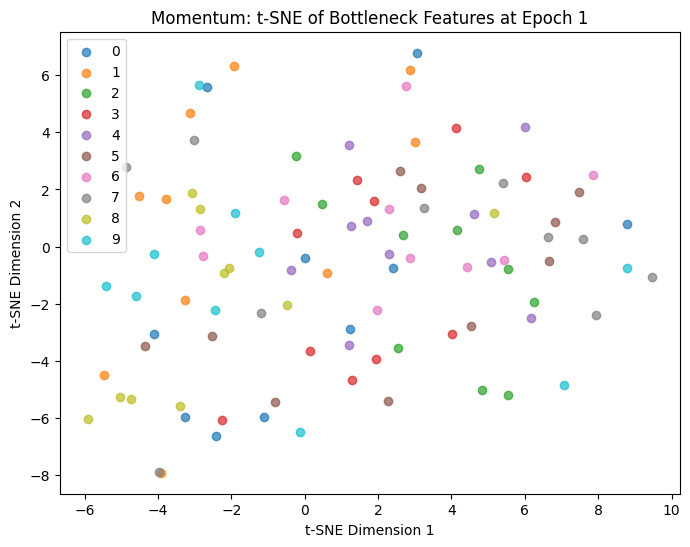

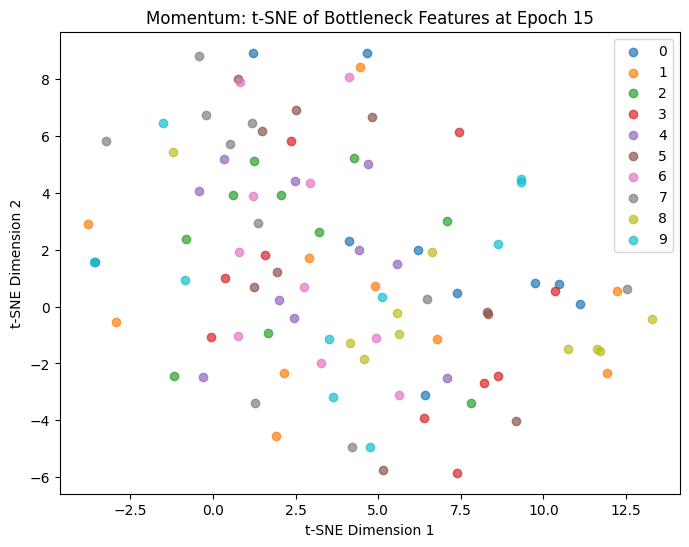

In [ ]:
plot_tsne(history_momentum["epoch1_features"], history_momentum["epoch1_labels"],
          title="Momentum: t-SNE of Bottleneck Features at Epoch 1")

plot_tsne(history_momentum["epoch_last_features"], history_momentum["epoch_last_labels"],
          title="Momentum: t-SNE of Bottleneck Features at Epoch 15")

Epoch [1/15] | Train Loss: 2.3035 | Test Loss: 2.2928 | Train Acc: 0.0970 | Test Acc: 0.1300


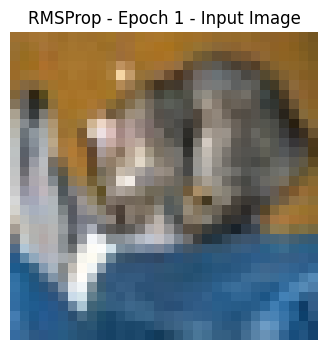

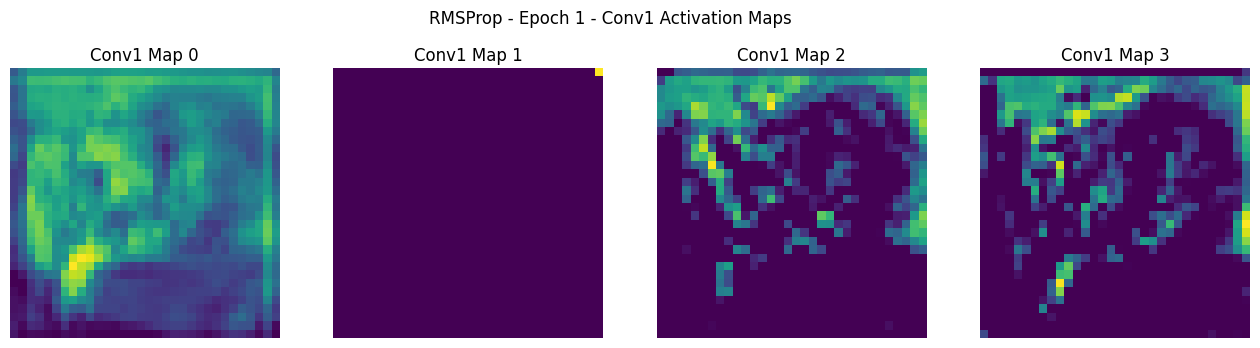

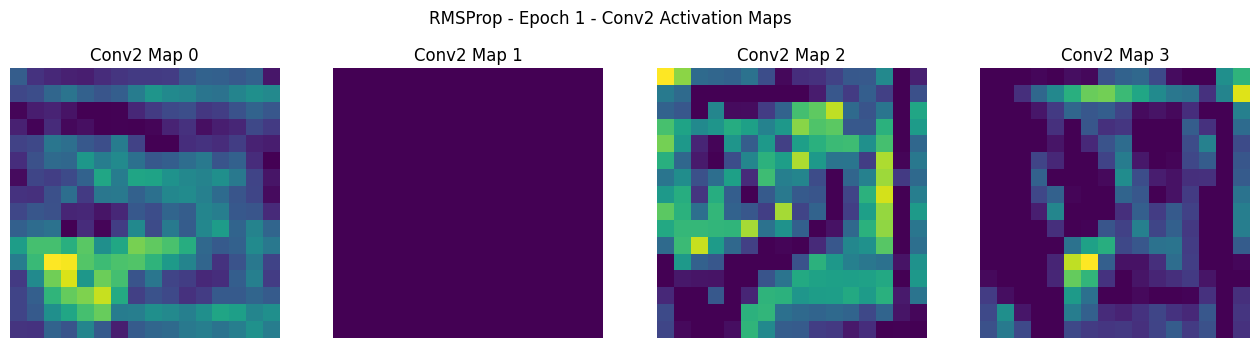

Epoch [2/15] | Train Loss: 2.2704 | Test Loss: 2.2438 | Train Acc: 0.1440 | Test Acc: 0.1800


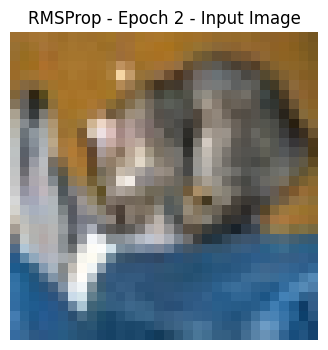

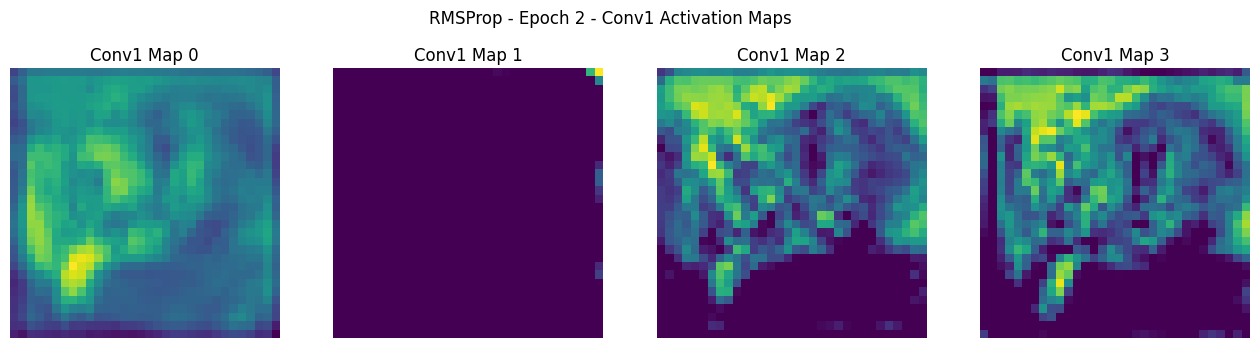

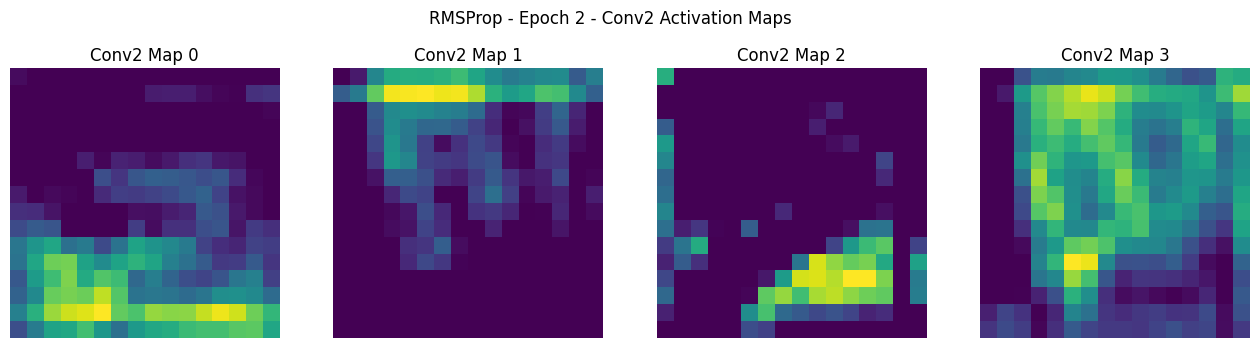

Epoch [3/15] | Train Loss: 2.1770 | Test Loss: 2.1665 | Train Acc: 0.2080 | Test Acc: 0.2300


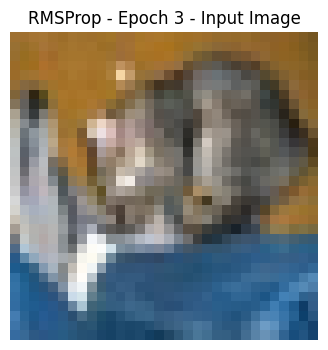

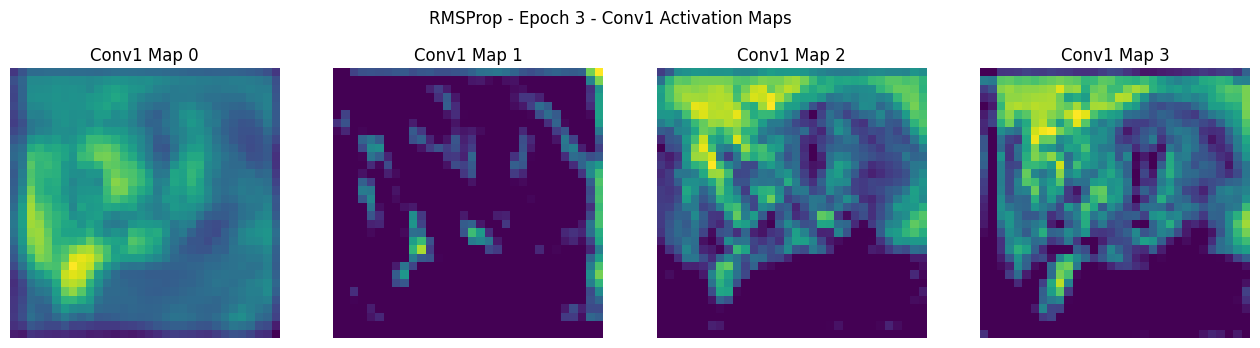

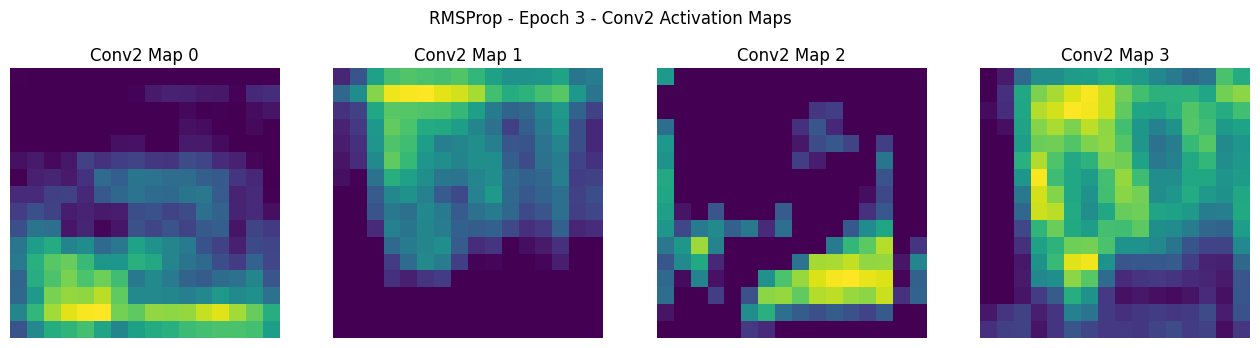

Epoch [4/15] | Train Loss: 2.0890 | Test Loss: 2.0543 | Train Acc: 0.2440 | Test Acc: 0.2600


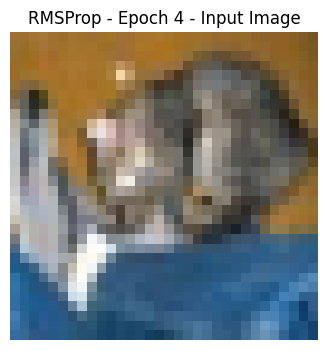

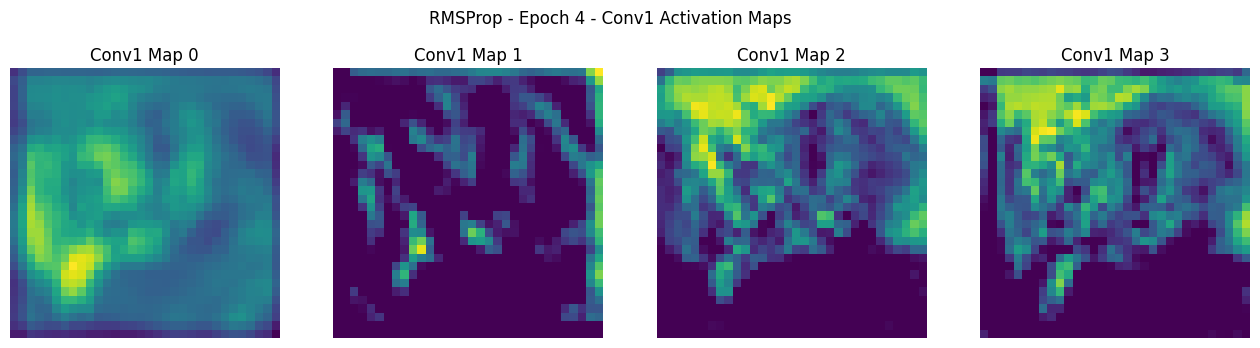

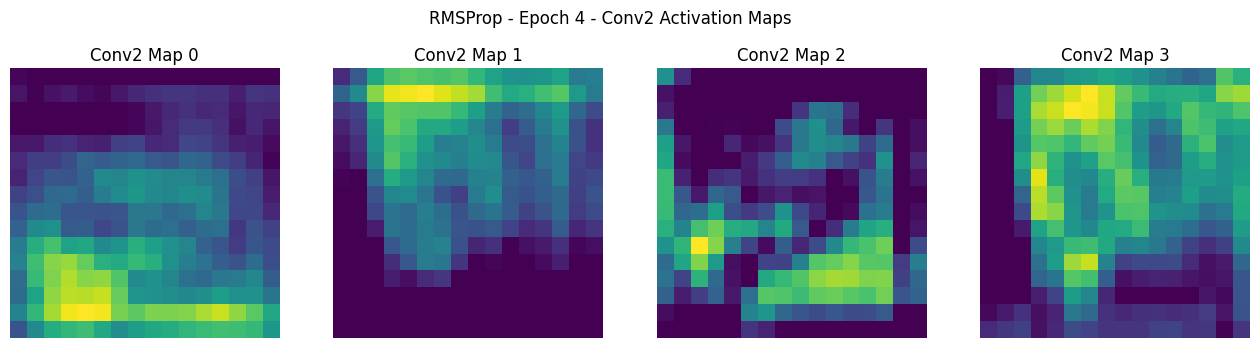

Epoch [5/15] | Train Loss: 2.0239 | Test Loss: 2.1037 | Train Acc: 0.2810 | Test Acc: 0.2200


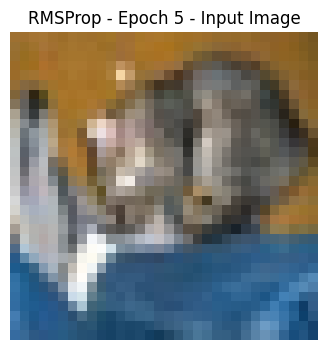

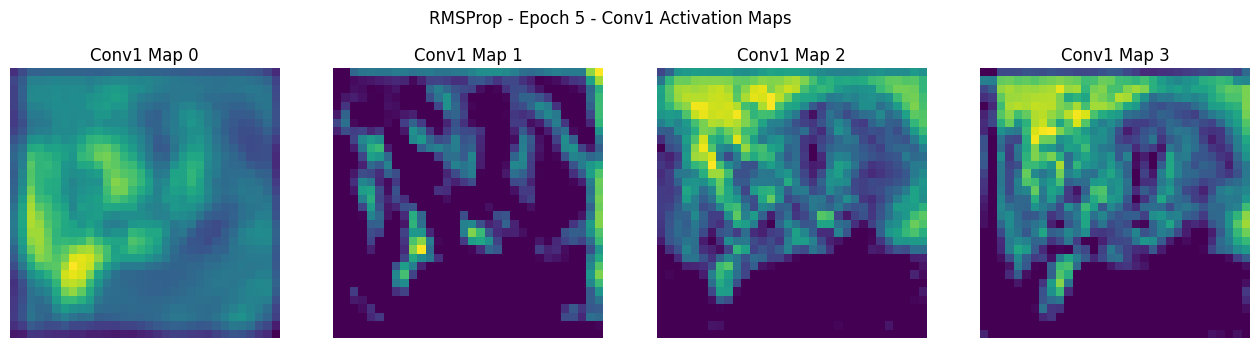

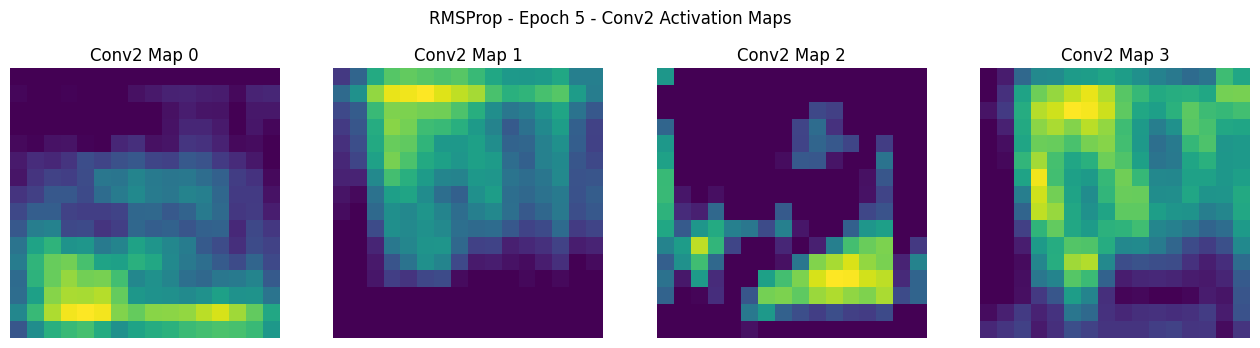

Epoch [6/15] | Train Loss: 1.9682 | Test Loss: 2.5778 | Train Acc: 0.2950 | Test Acc: 0.1500


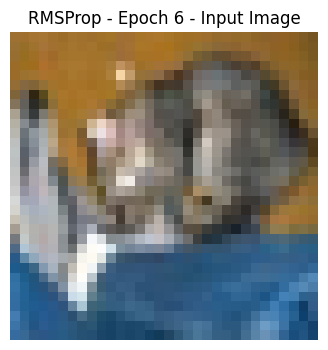

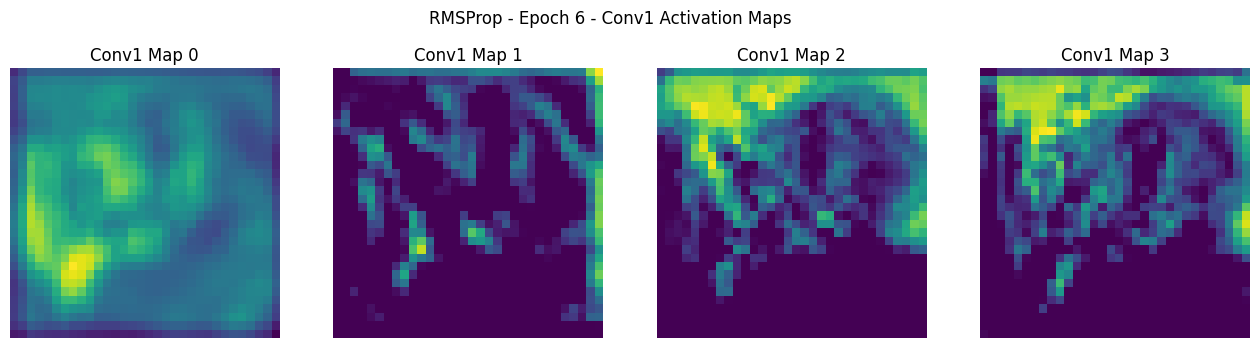

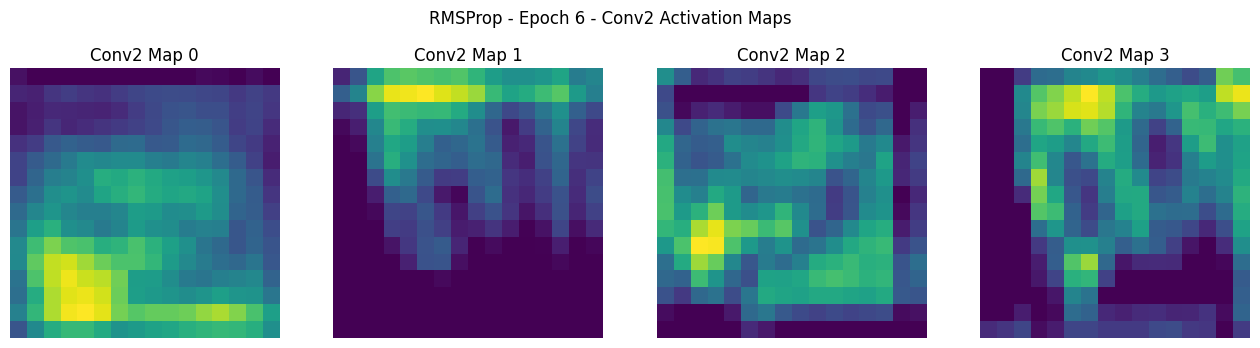

Epoch [7/15] | Train Loss: 1.9529 | Test Loss: 2.2394 | Train Acc: 0.3100 | Test Acc: 0.1900


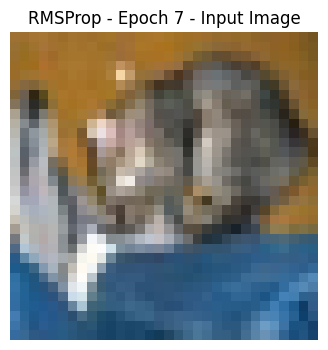

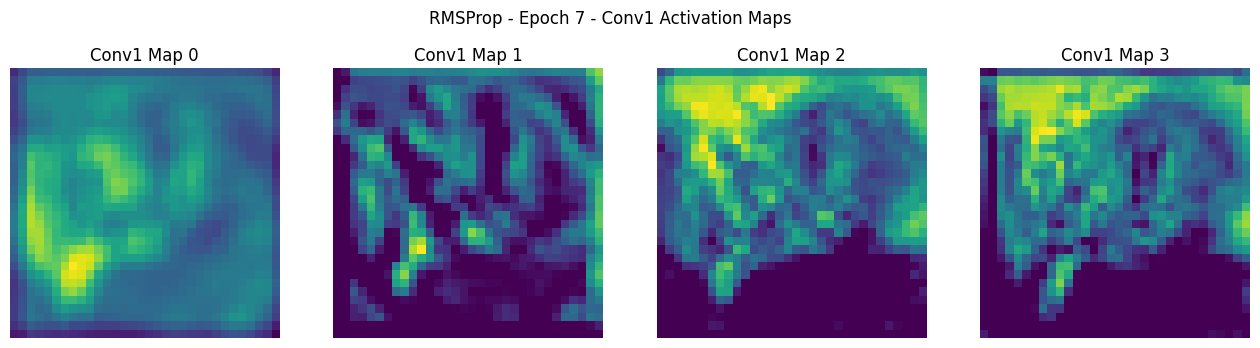

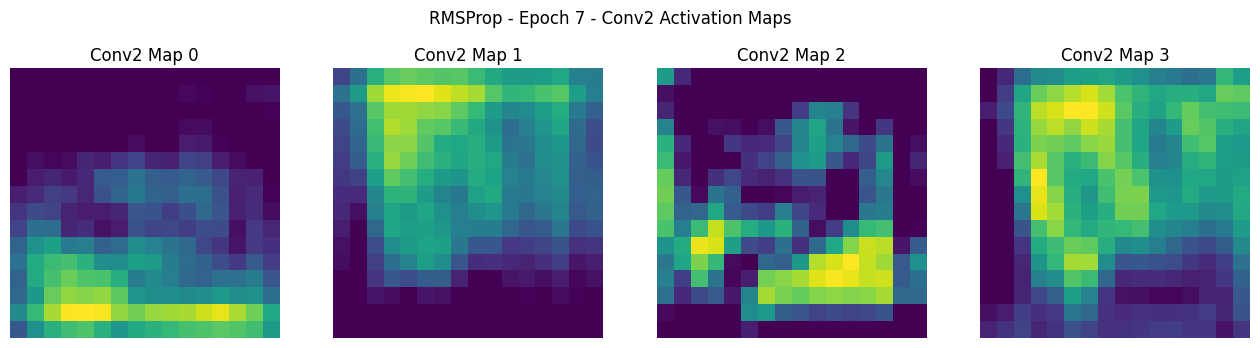

Epoch [8/15] | Train Loss: 1.9145 | Test Loss: 2.2634 | Train Acc: 0.3310 | Test Acc: 0.2200


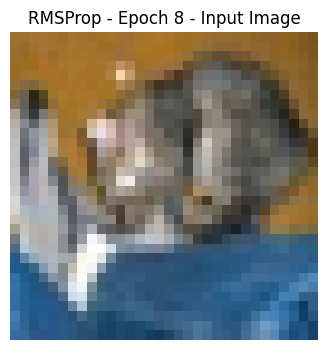

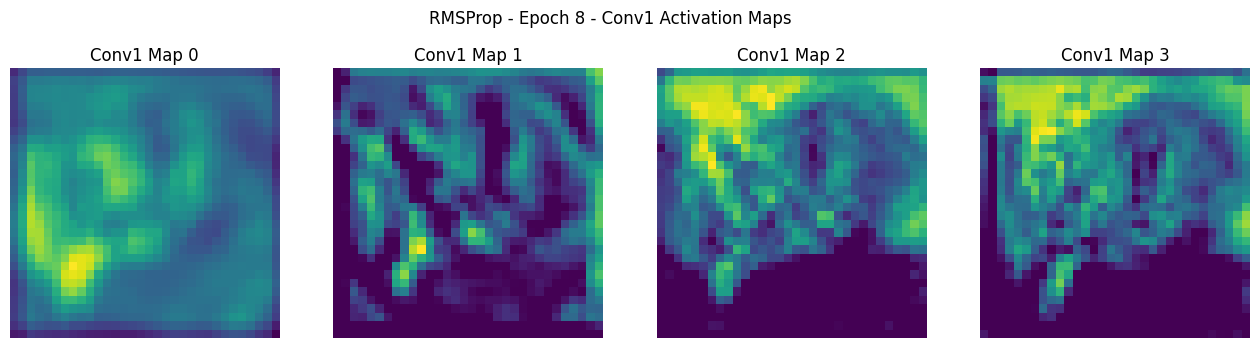

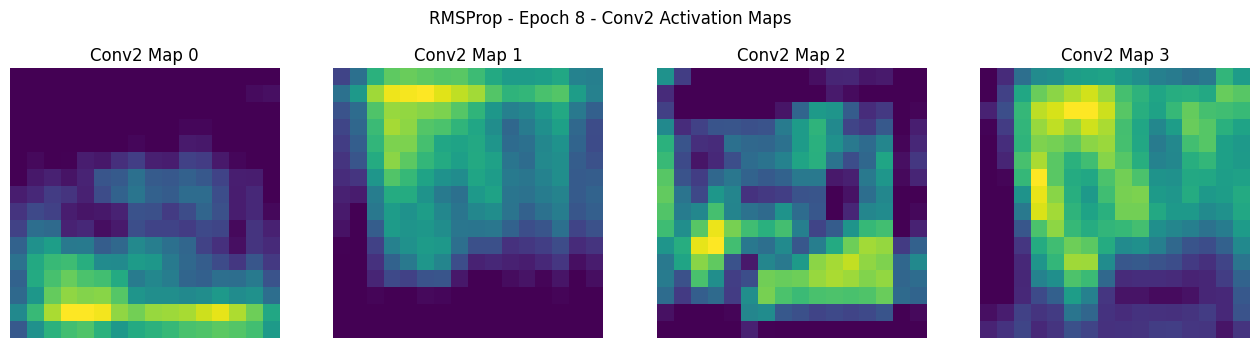

Epoch [9/15] | Train Loss: 1.8584 | Test Loss: 1.9562 | Train Acc: 0.3350 | Test Acc: 0.3100


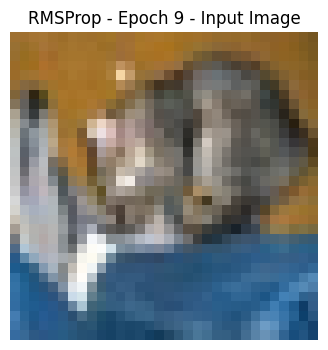

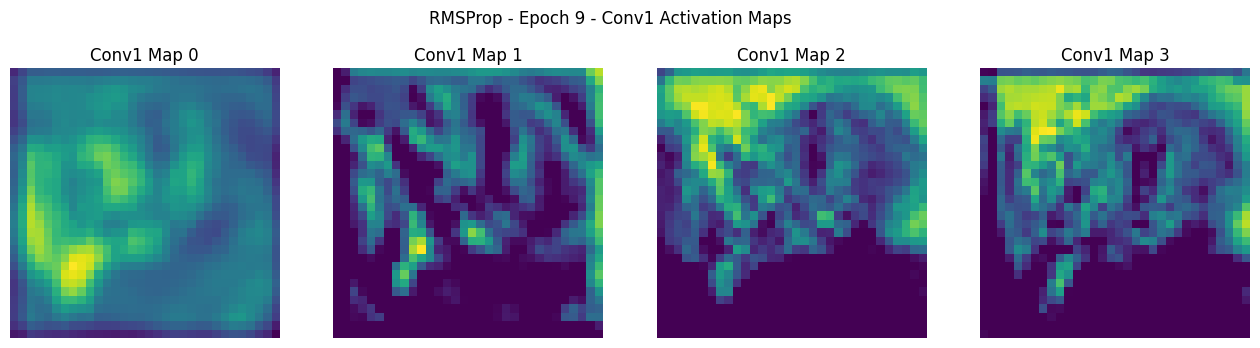

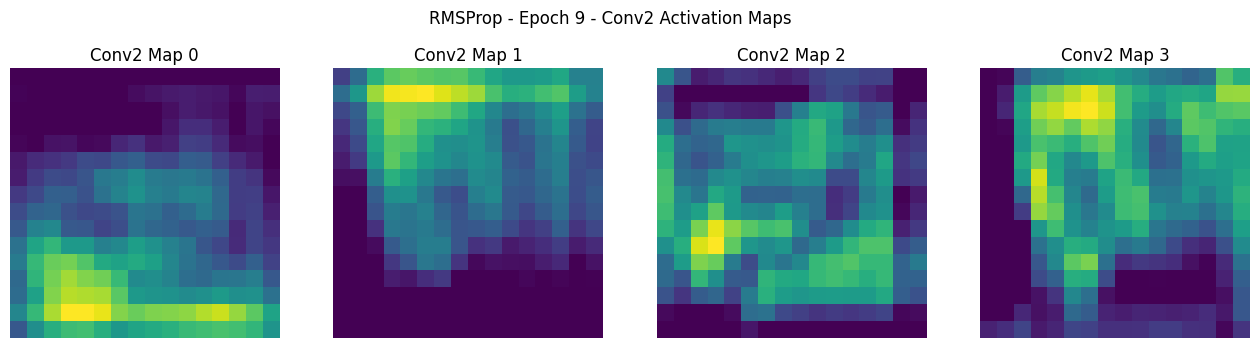

Epoch [10/15] | Train Loss: 1.8535 | Test Loss: 2.0238 | Train Acc: 0.3260 | Test Acc: 0.2800


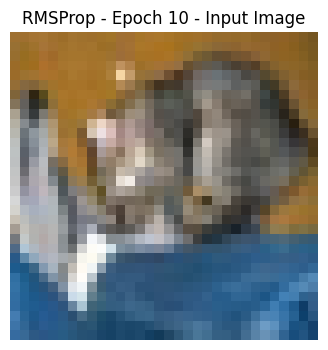

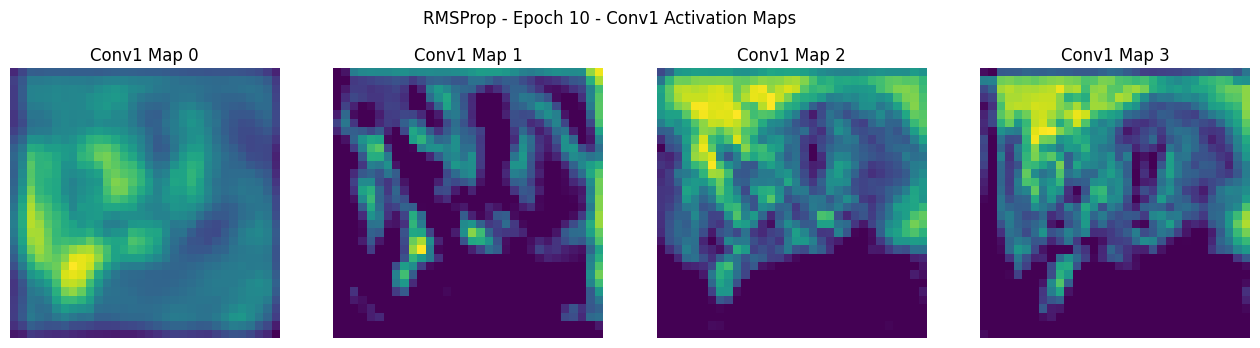

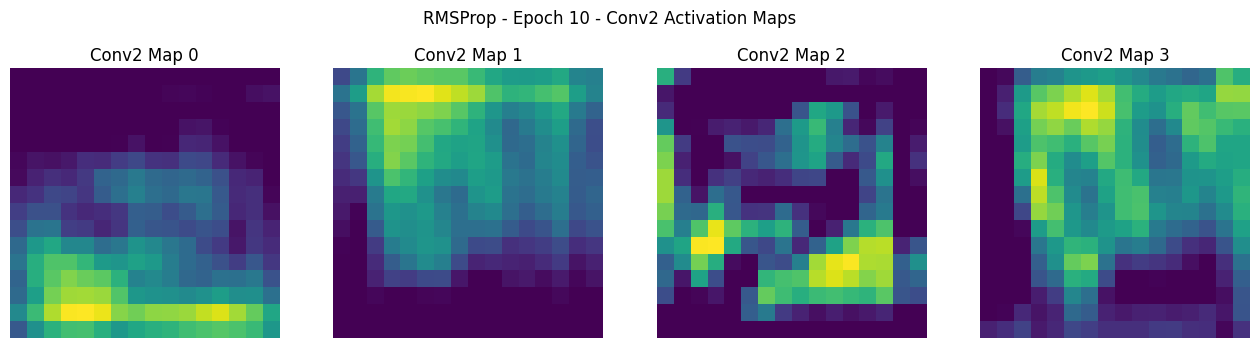

Epoch [11/15] | Train Loss: 1.8073 | Test Loss: 2.4303 | Train Acc: 0.3540 | Test Acc: 0.1900


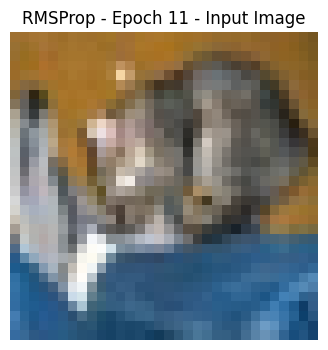

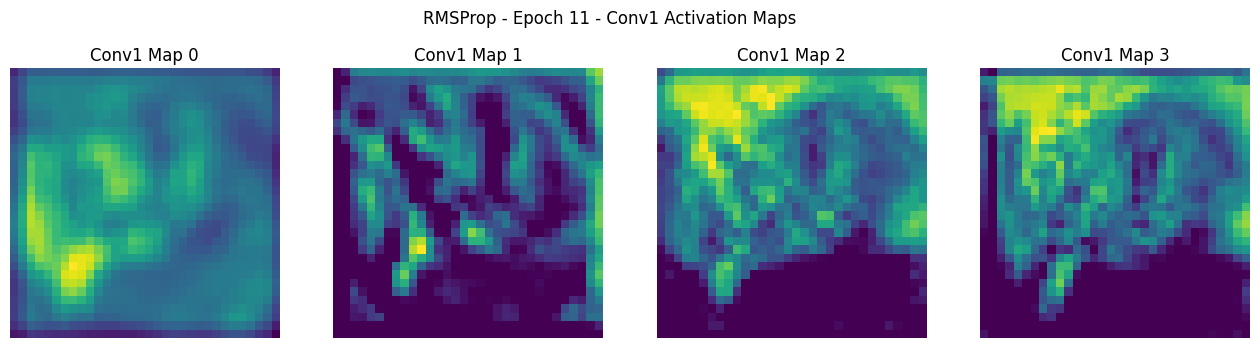

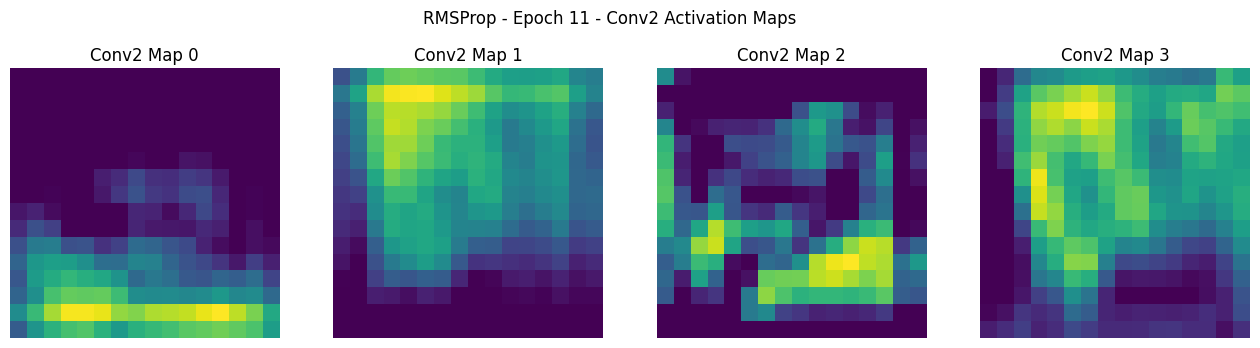

Epoch [12/15] | Train Loss: 1.8148 | Test Loss: 1.9578 | Train Acc: 0.3640 | Test Acc: 0.2900


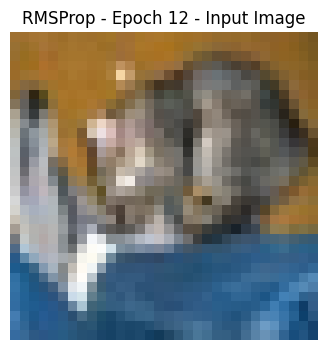

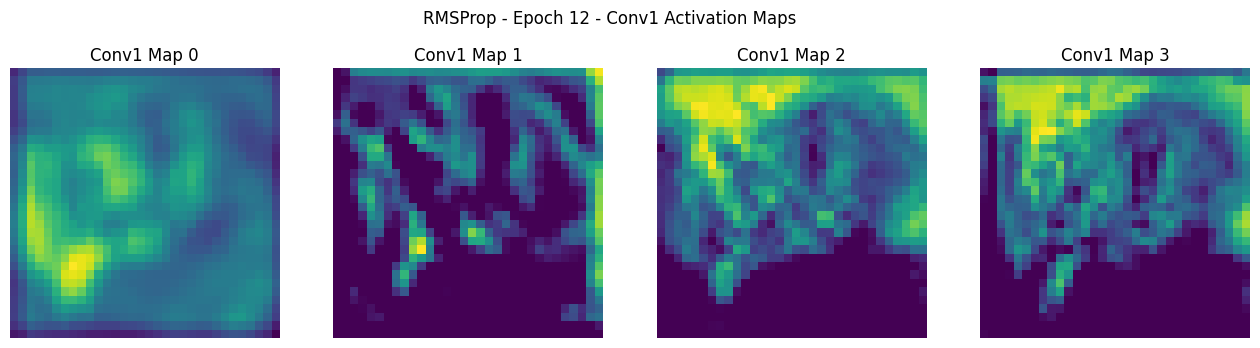

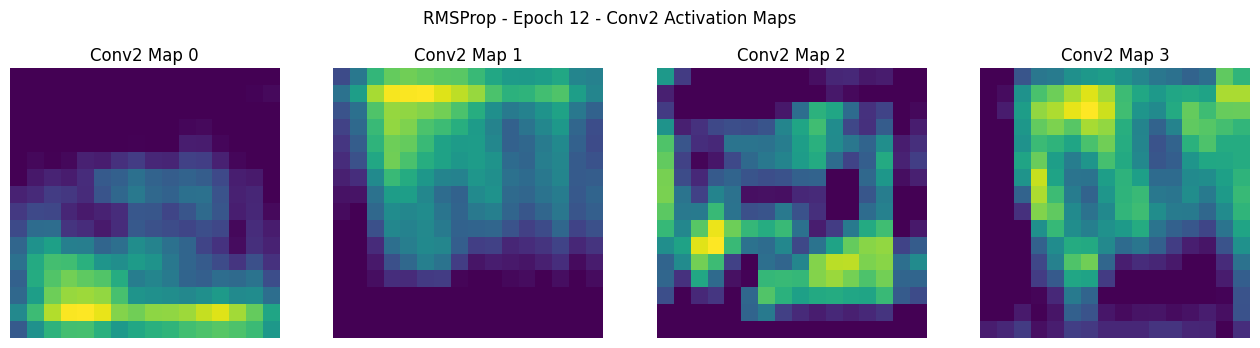

Epoch [13/15] | Train Loss: 1.7694 | Test Loss: 1.8950 | Train Acc: 0.3660 | Test Acc: 0.3200


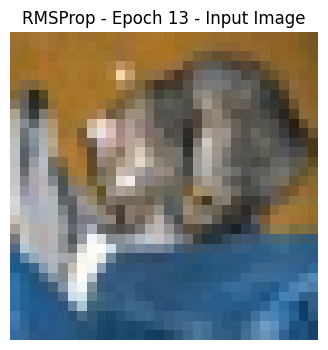

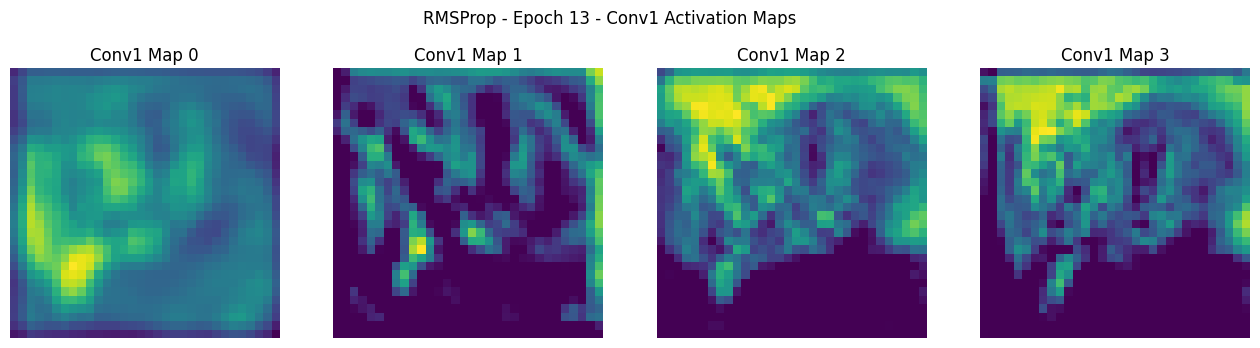

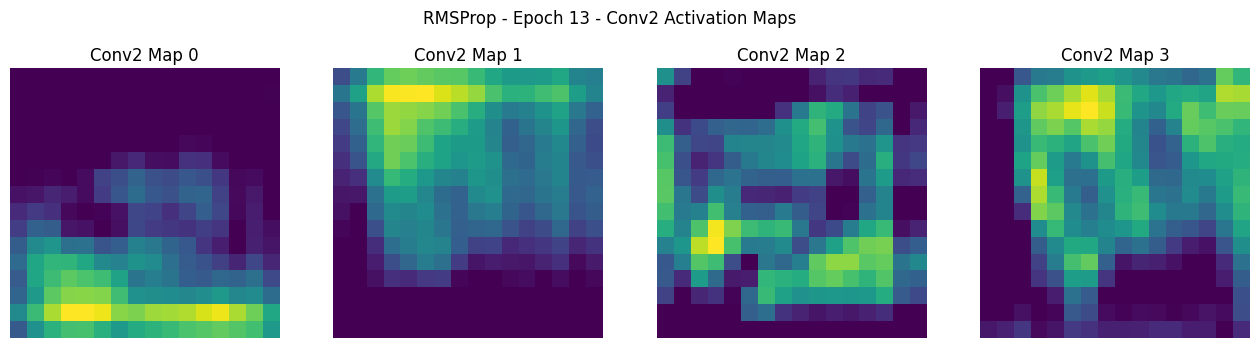

Epoch [14/15] | Train Loss: 1.7582 | Test Loss: 1.9715 | Train Acc: 0.3800 | Test Acc: 0.3300


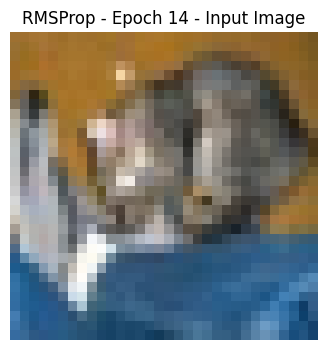

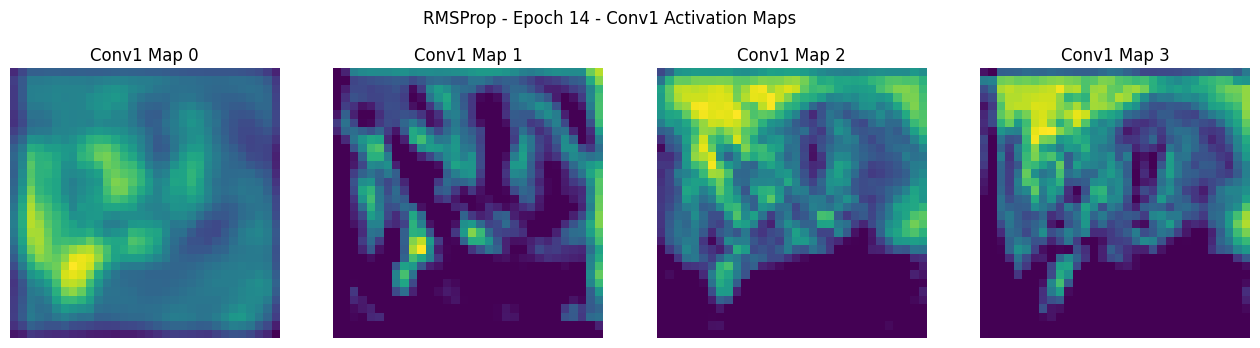

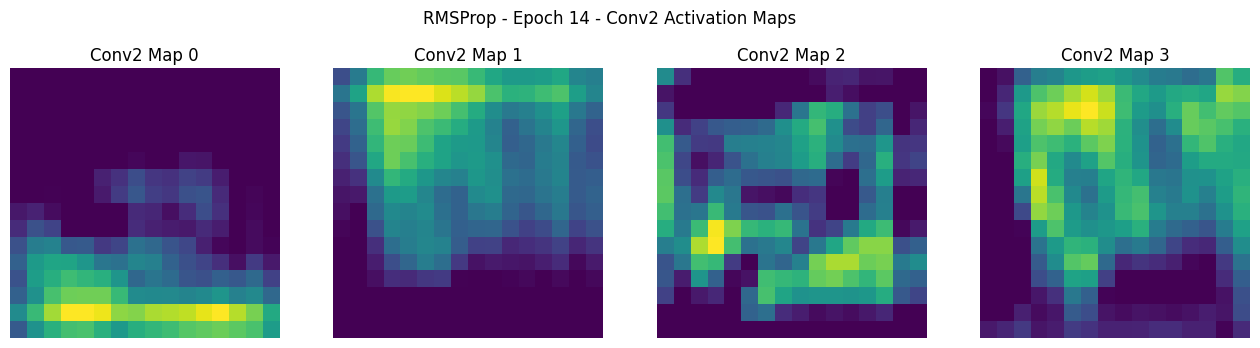

Epoch [15/15] | Train Loss: 1.7100 | Test Loss: 2.1156 | Train Acc: 0.3960 | Test Acc: 0.3500


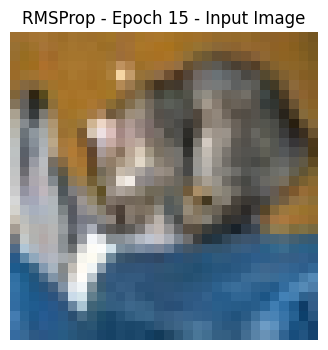

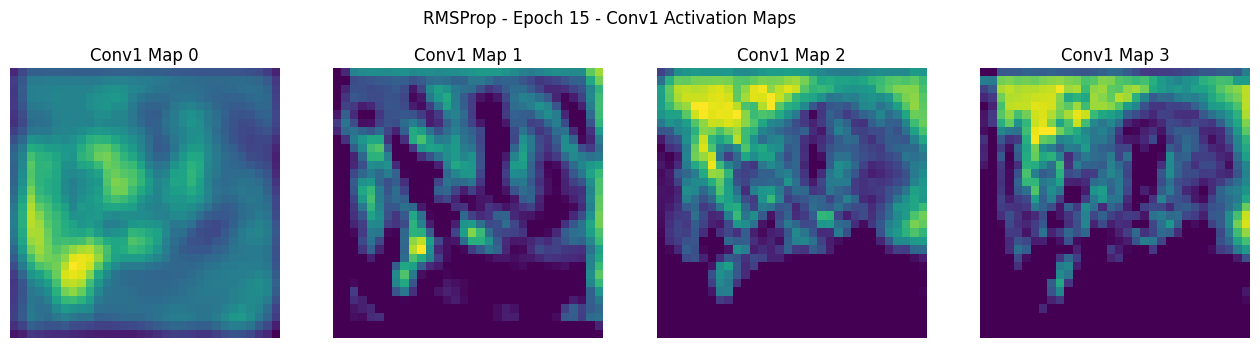

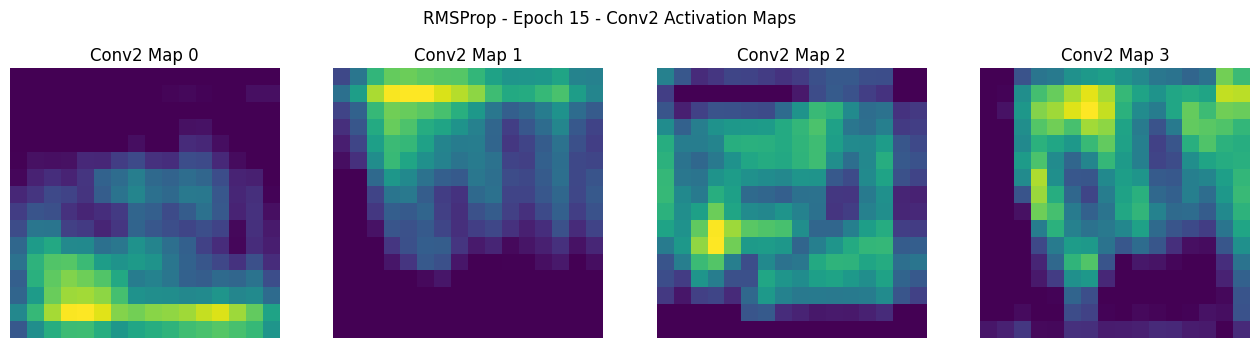

In [ ]:
# 3) RMSProp
torch.manual_seed(42)
model_rmsprop = SimpleCNN(dropout_p=0.0, use_bn=False).to(device)
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=0.001, alpha=0.9)

history_rmsprop = train_model(
    model_rmsprop,
    train_loader,
    test_loader,
    optimizer_rmsprop,
    epochs=15,
    model_name="RMSProp"
)

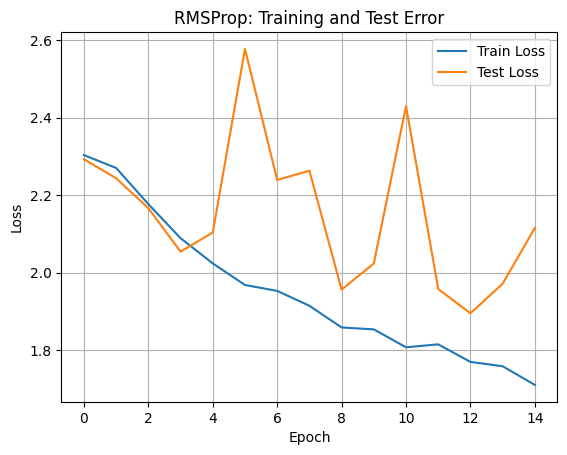

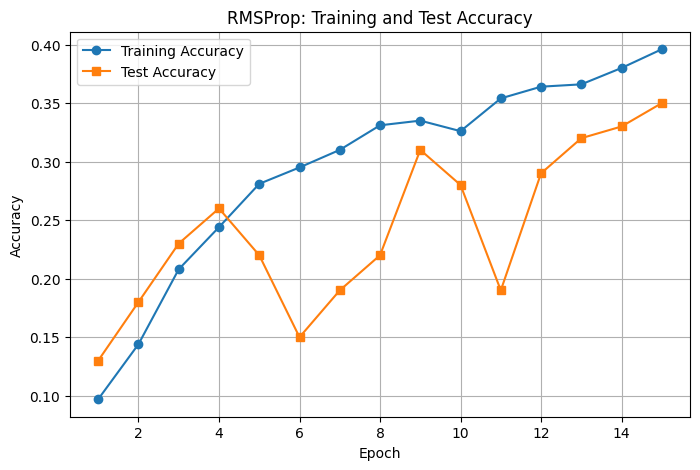

In [ ]:
plot_loss_curves(history_rmsprop, title="RMSProp: Training and Test Error")
plot_accuracy_curves(history_rmsprop, title="RMSProp: Training and Test Accuracy")

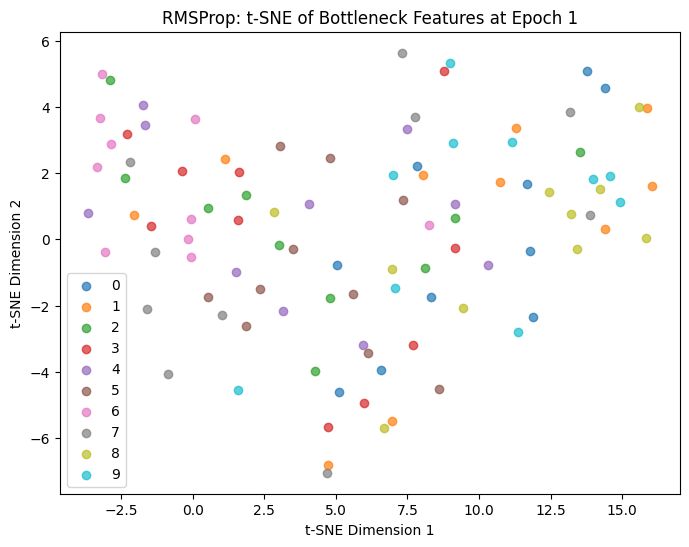

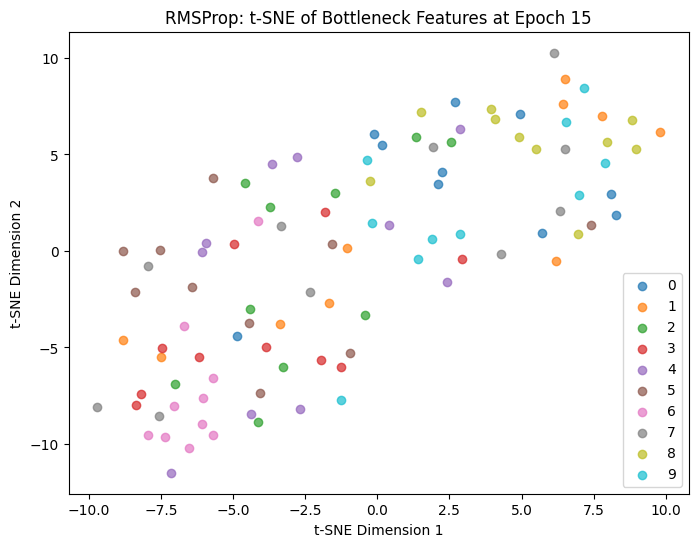

In [ ]:
plot_tsne(history_rmsprop["epoch1_features"], history_rmsprop["epoch1_labels"],
          title="RMSProp: t-SNE of Bottleneck Features at Epoch 1")

plot_tsne(history_rmsprop["epoch_last_features"], history_rmsprop["epoch_last_labels"],
          title="RMSProp: t-SNE of Bottleneck Features at Epoch 15")

### (e) Dropout Regularization

Dropout is applied to the hidden layer of the MLP.

Three dropout rates are tested:

- $p = 0.2$
- $p = 0.5$
- $p = 0.8$

The model is trained using **RMSProp optimizer**.

The performance with dropout is compared with the baseline model without dropout.


Training RMSProp with Dropout p = 0.2

Epoch [1/15] | Train Loss: 2.3034 | Test Loss: 2.2988 | Train Acc: 0.0920 | Test Acc: 0.1600


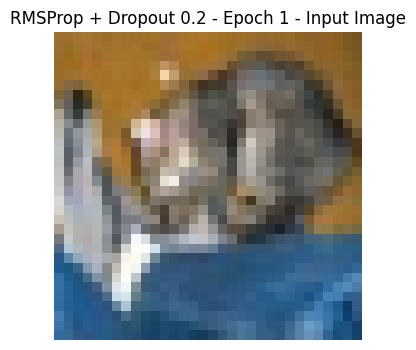

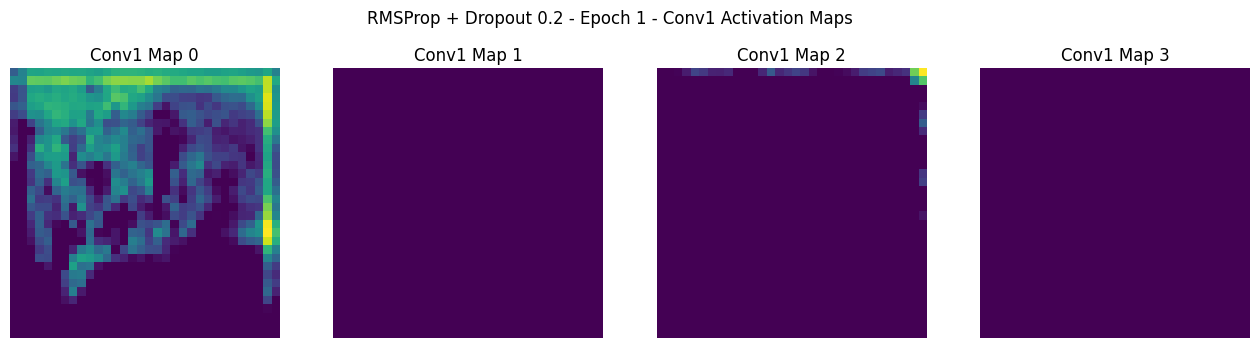

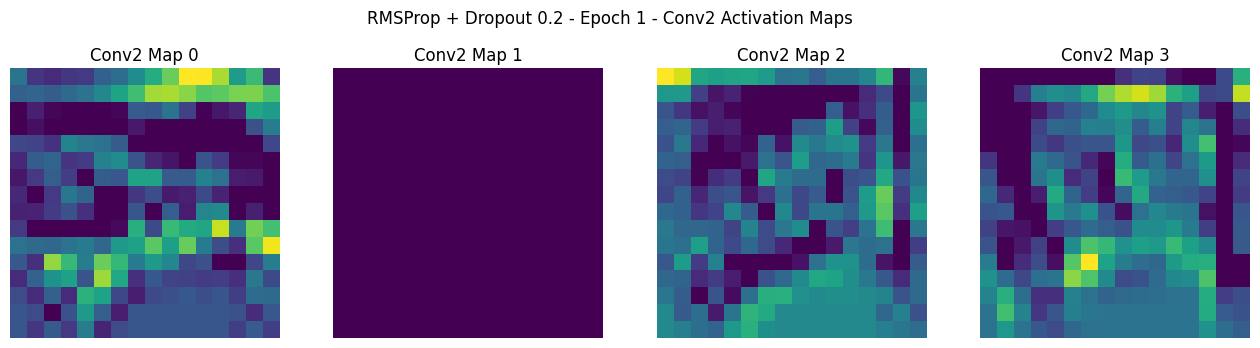

Epoch [2/15] | Train Loss: 2.2919 | Test Loss: 2.2830 | Train Acc: 0.1440 | Test Acc: 0.1400


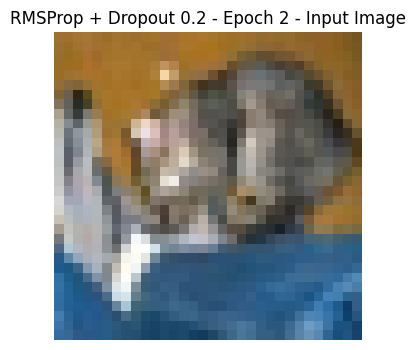

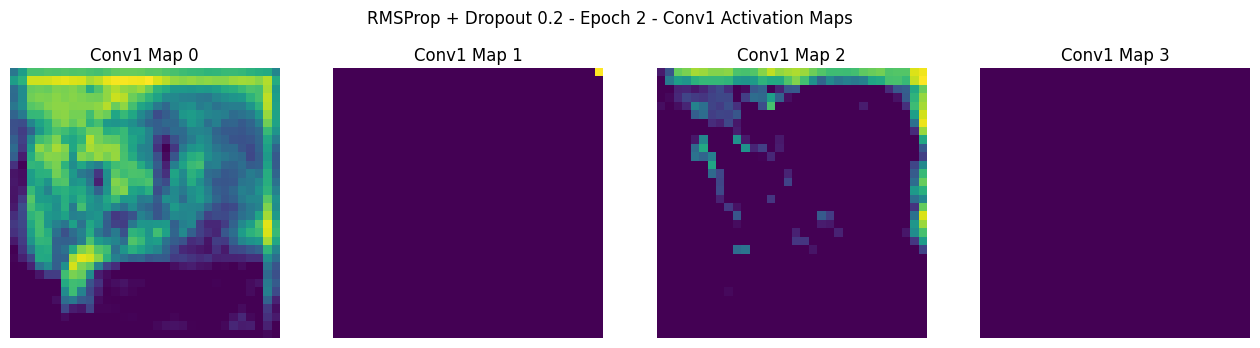

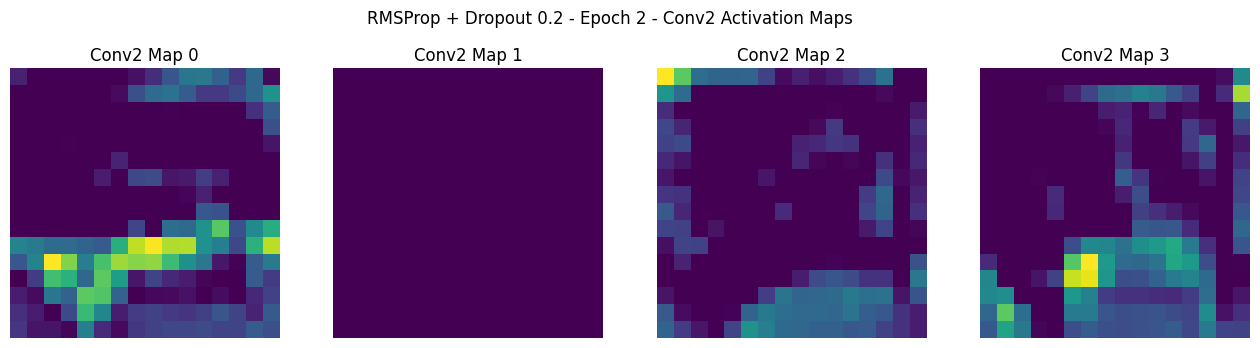

Epoch [3/15] | Train Loss: 2.2726 | Test Loss: 2.2498 | Train Acc: 0.1530 | Test Acc: 0.1800


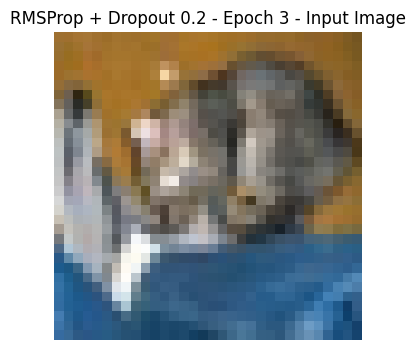

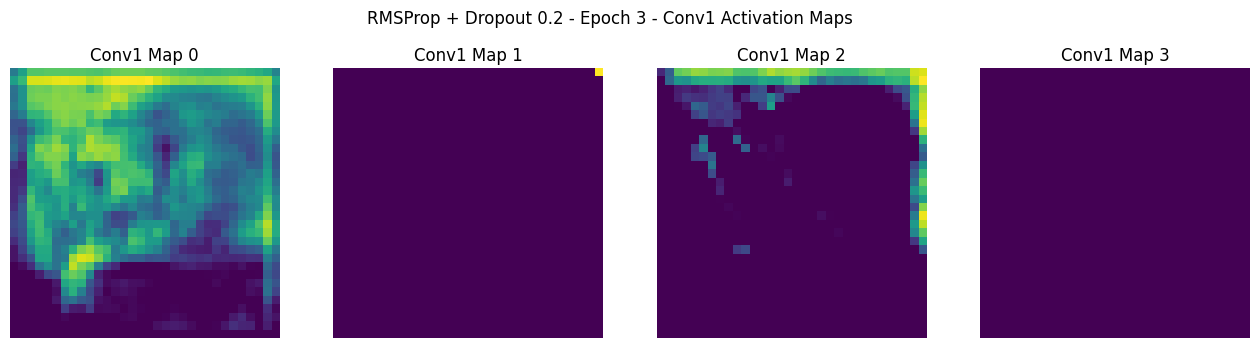

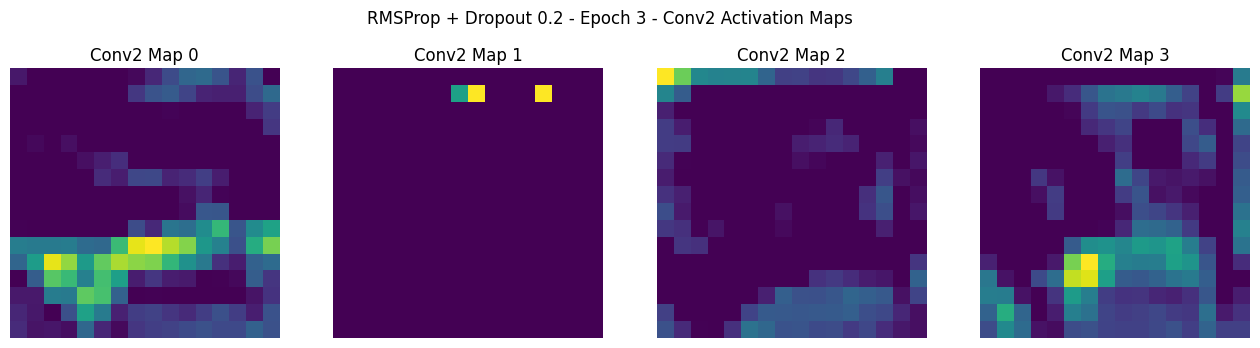

Epoch [4/15] | Train Loss: 2.2330 | Test Loss: 2.1890 | Train Acc: 0.1960 | Test Acc: 0.1500


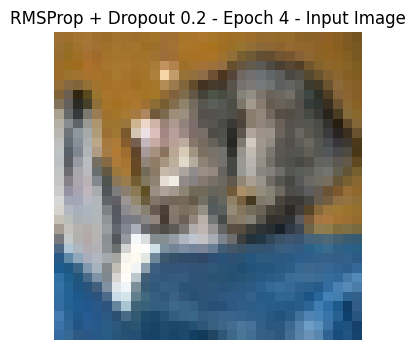

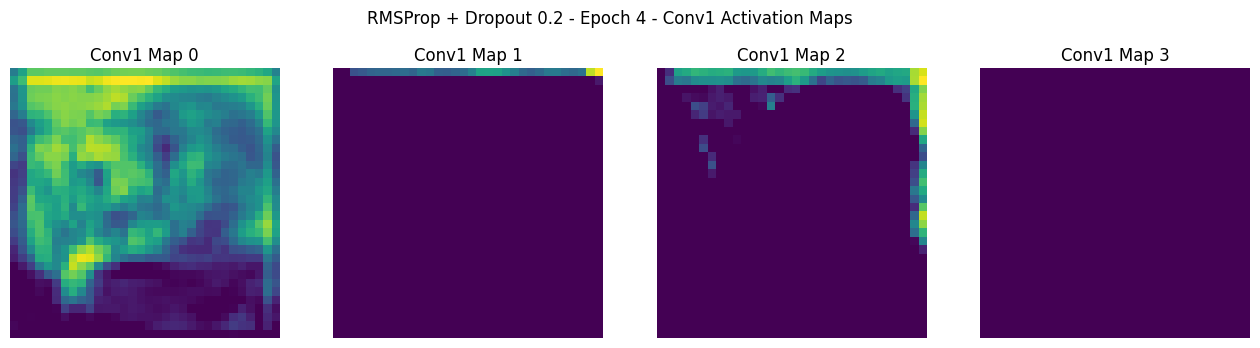

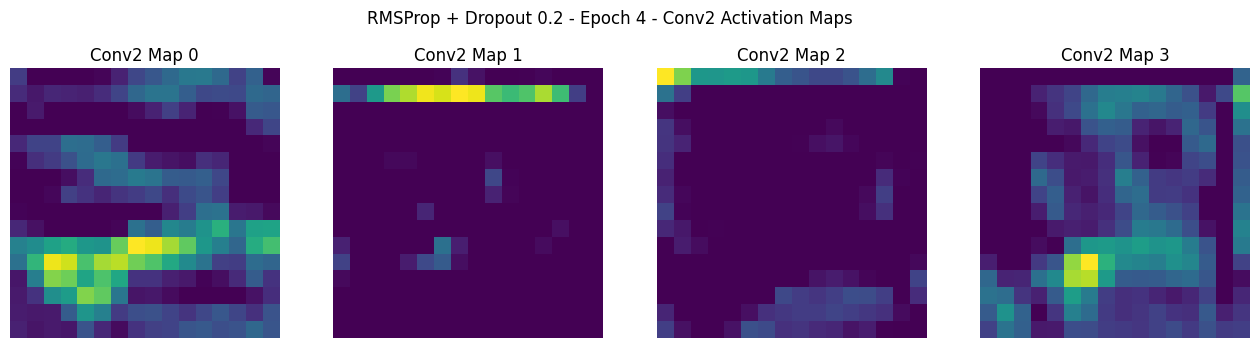

Epoch [5/15] | Train Loss: 2.1581 | Test Loss: 2.0813 | Train Acc: 0.2100 | Test Acc: 0.2800


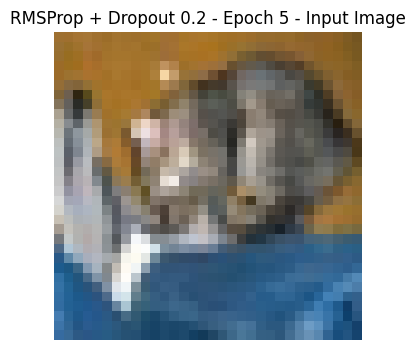

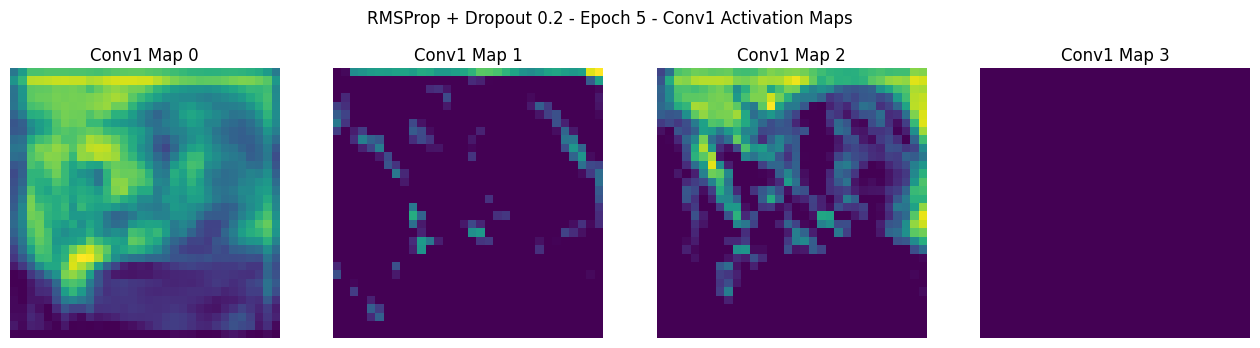

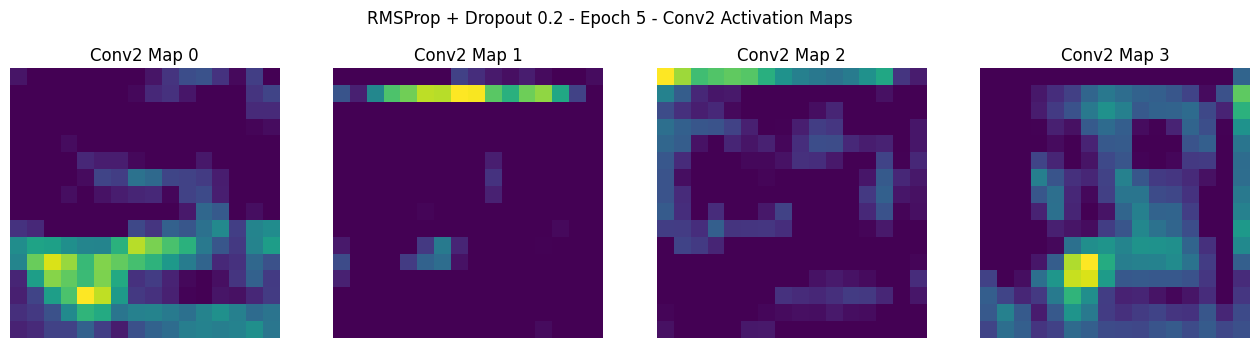

Epoch [6/15] | Train Loss: 2.0606 | Test Loss: 2.0388 | Train Acc: 0.2610 | Test Acc: 0.2300


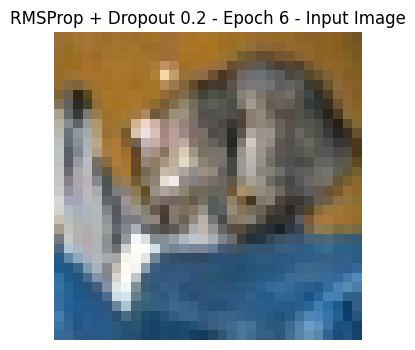

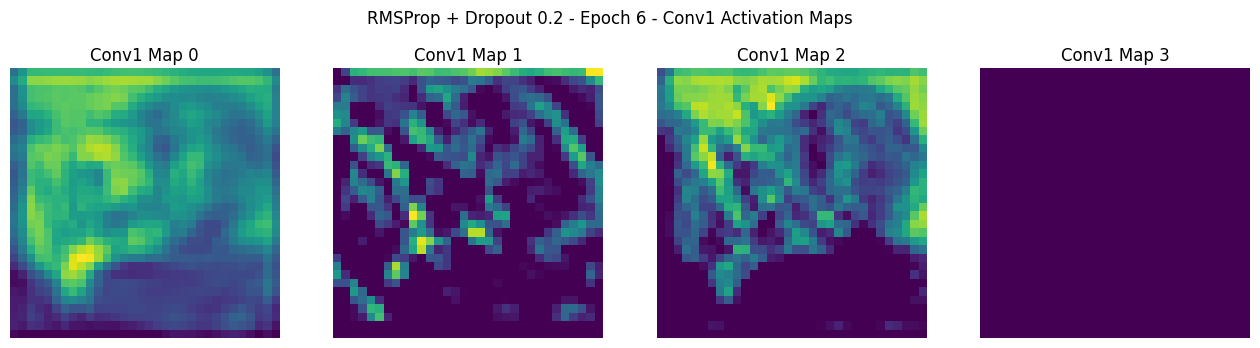

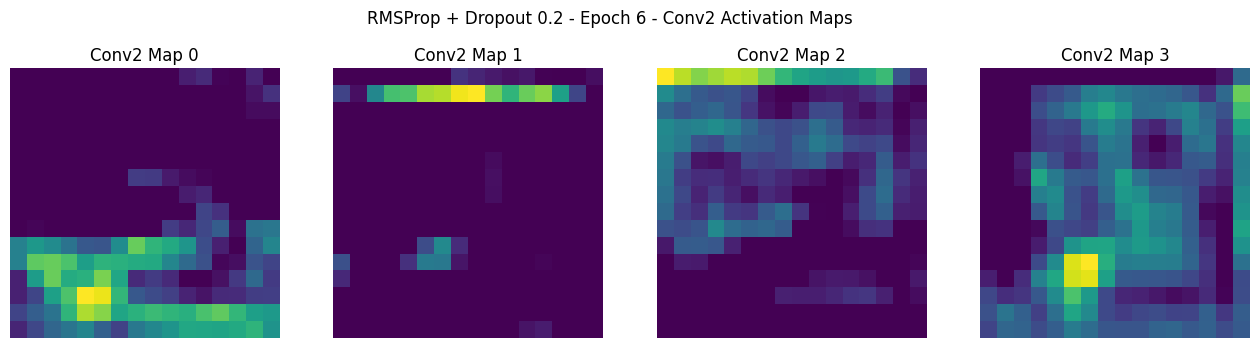

Epoch [7/15] | Train Loss: 1.9949 | Test Loss: 1.9268 | Train Acc: 0.2780 | Test Acc: 0.3700


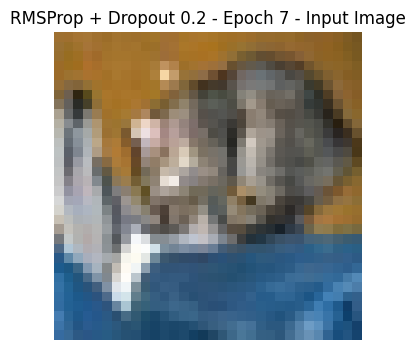

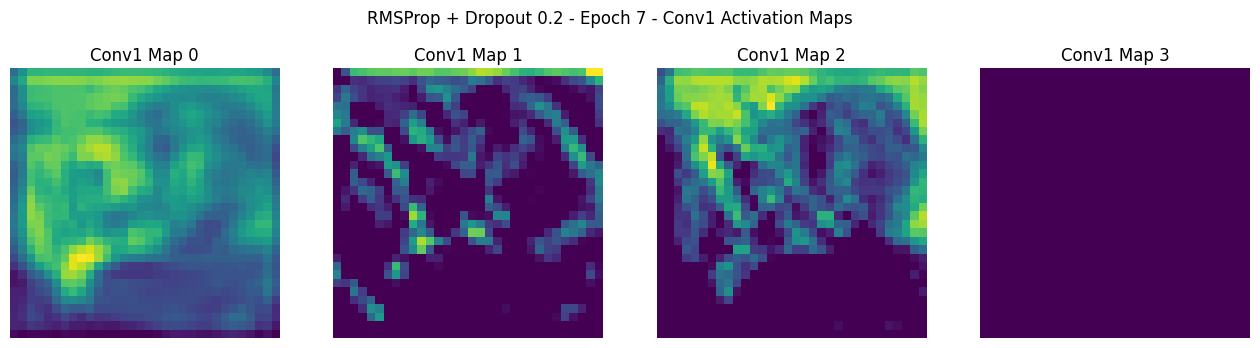

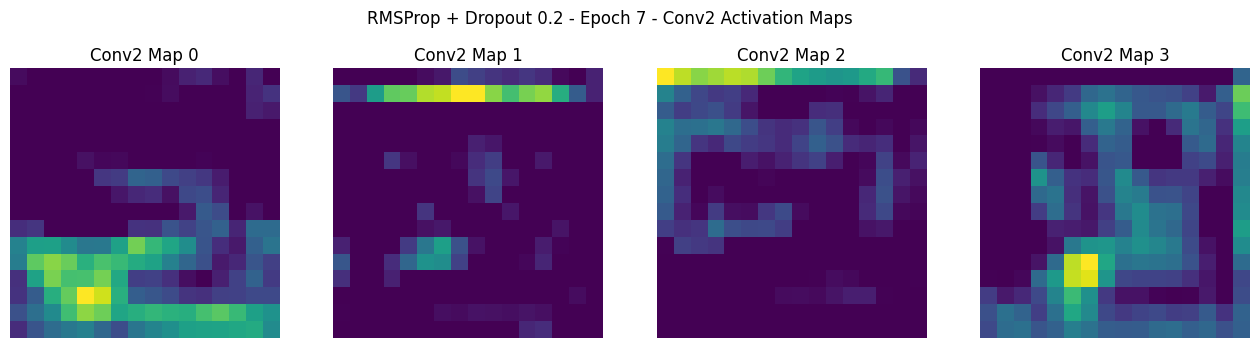

Epoch [8/15] | Train Loss: 1.9255 | Test Loss: 1.9957 | Train Acc: 0.3110 | Test Acc: 0.3000


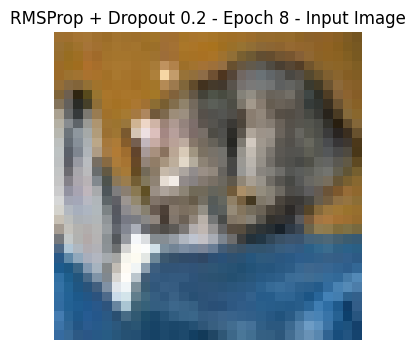

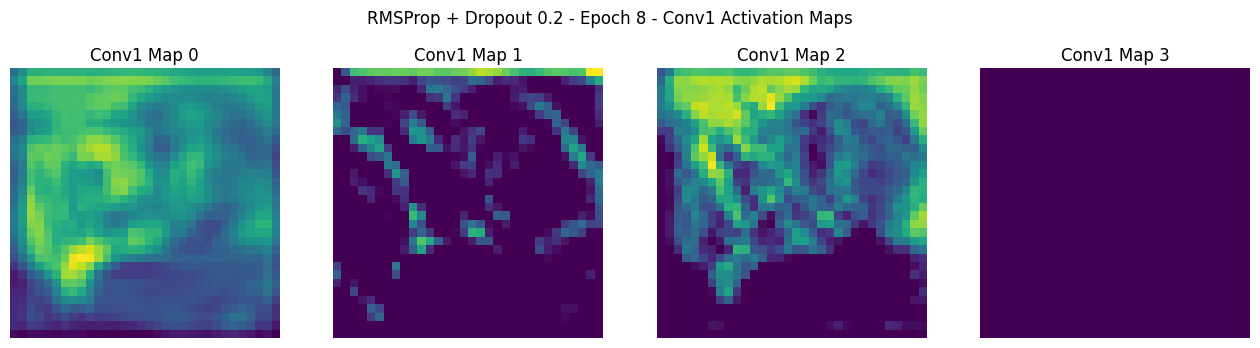

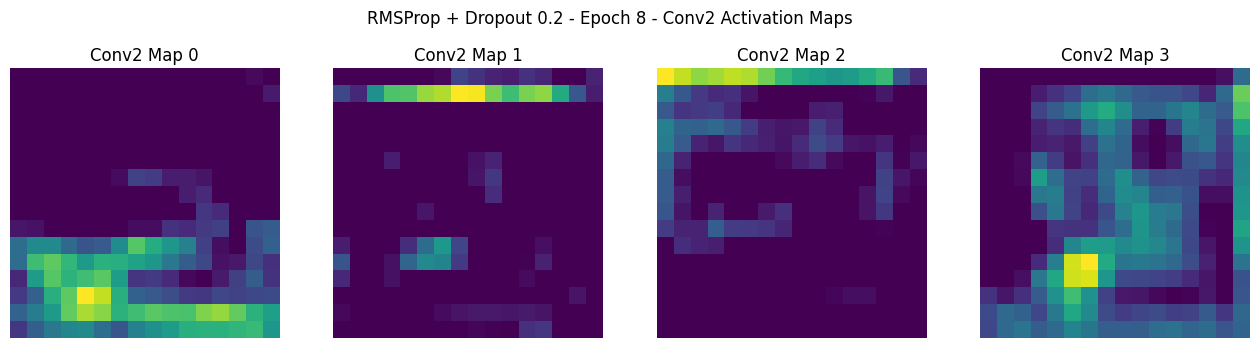

Epoch [9/15] | Train Loss: 1.8673 | Test Loss: 1.9482 | Train Acc: 0.3300 | Test Acc: 0.3100


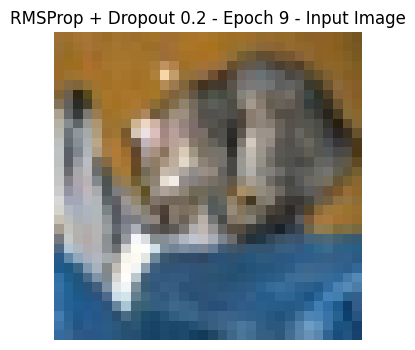

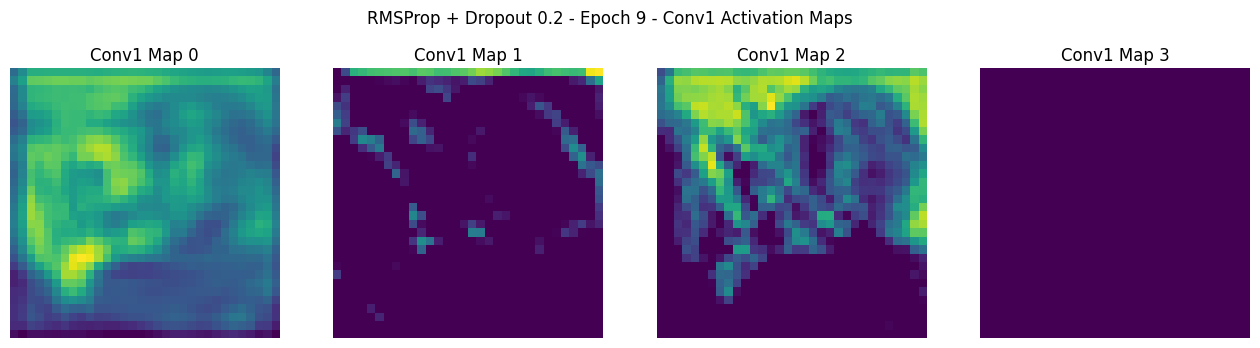

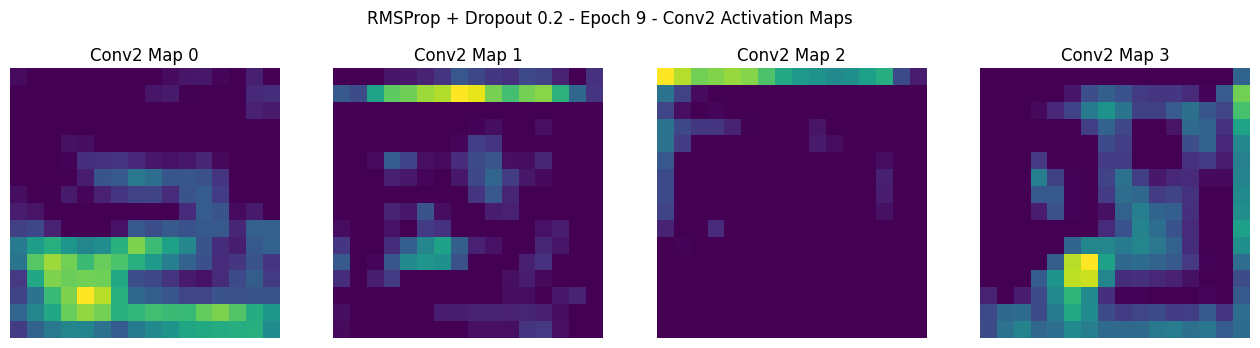

Epoch [10/15] | Train Loss: 1.8706 | Test Loss: 1.9601 | Train Acc: 0.3460 | Test Acc: 0.3200


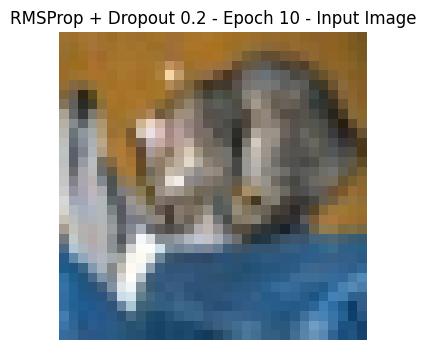

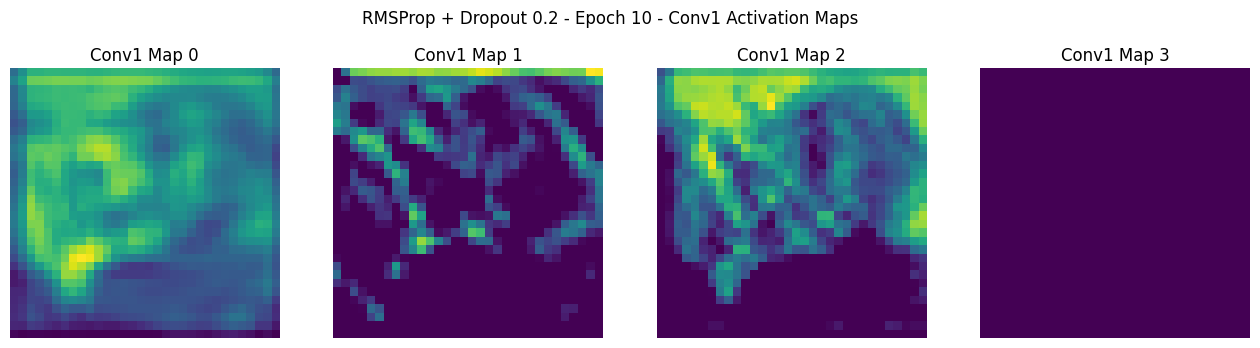

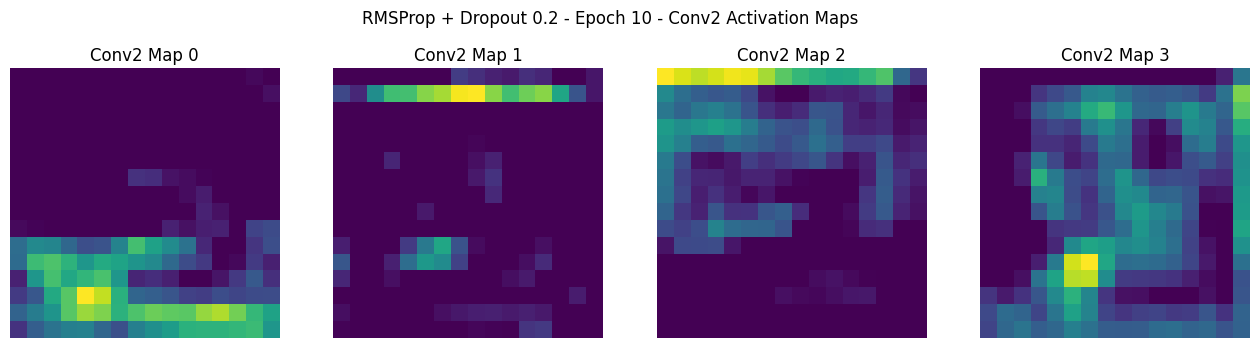

Epoch [11/15] | Train Loss: 1.8049 | Test Loss: 1.8345 | Train Acc: 0.3630 | Test Acc: 0.3800


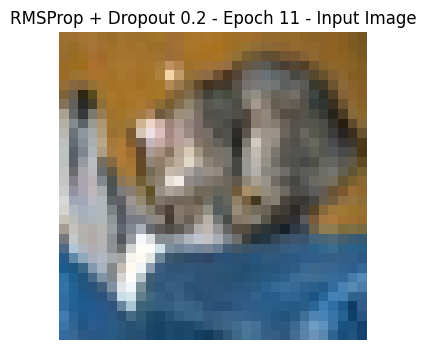

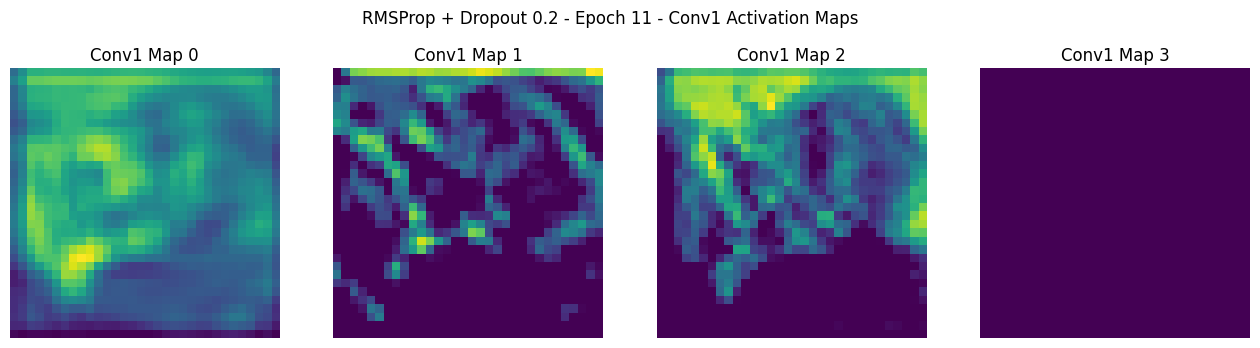

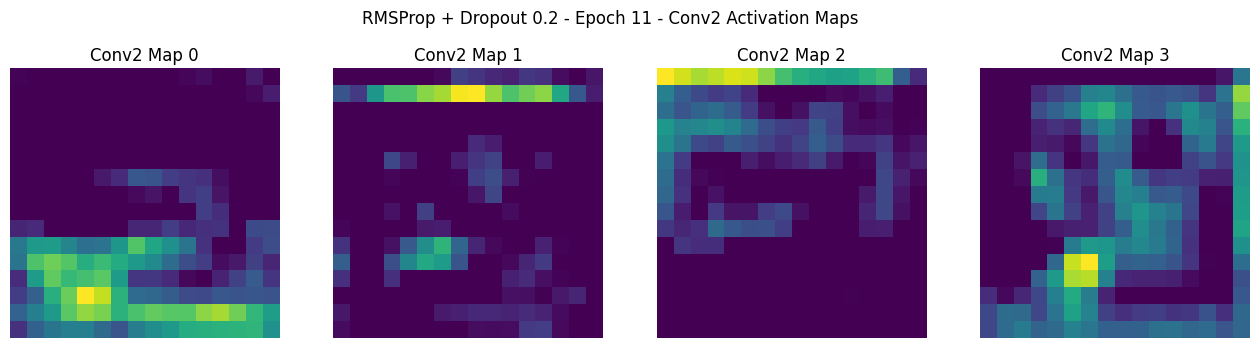

Epoch [12/15] | Train Loss: 1.8095 | Test Loss: 1.8955 | Train Acc: 0.3740 | Test Acc: 0.3300


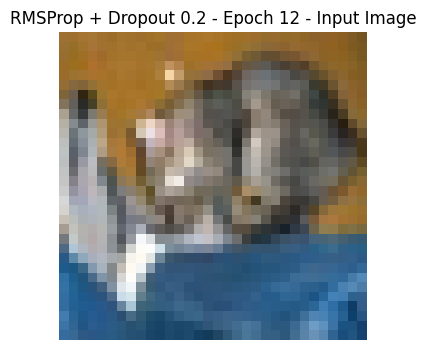

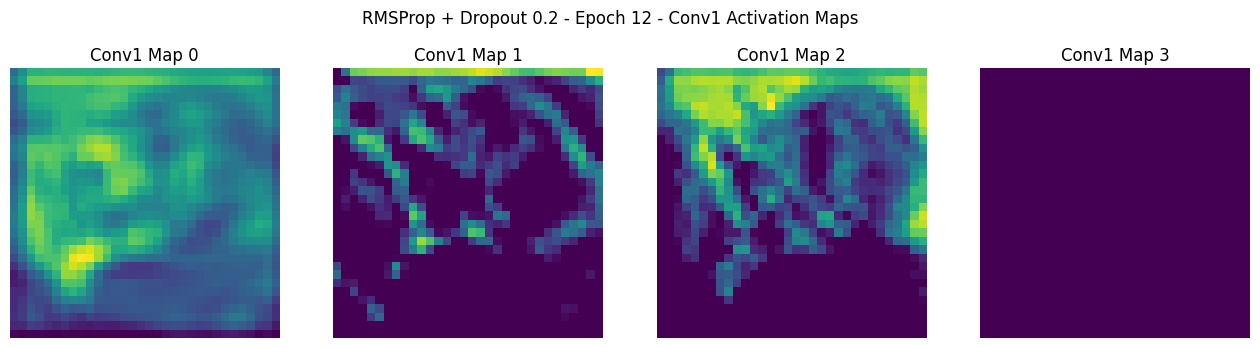

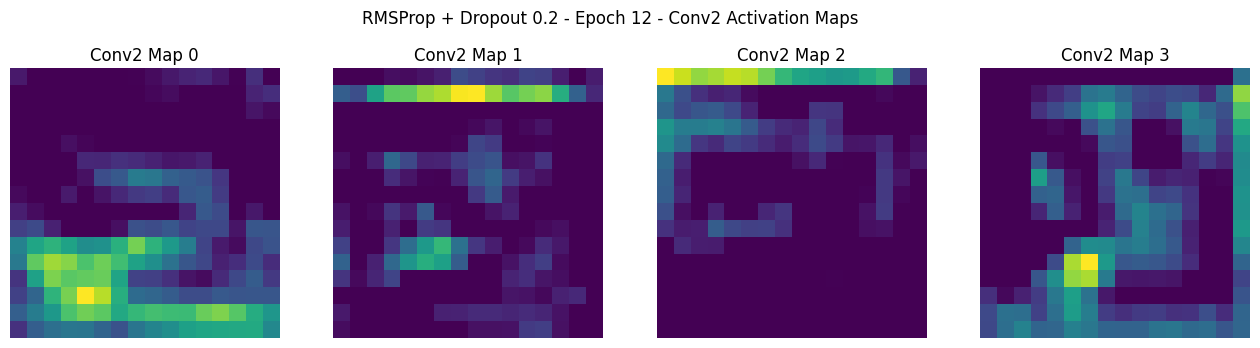

Epoch [13/15] | Train Loss: 1.7402 | Test Loss: 1.9635 | Train Acc: 0.3800 | Test Acc: 0.2800


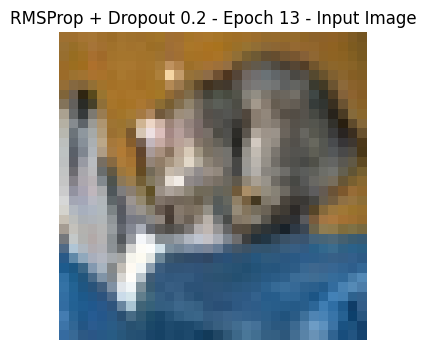

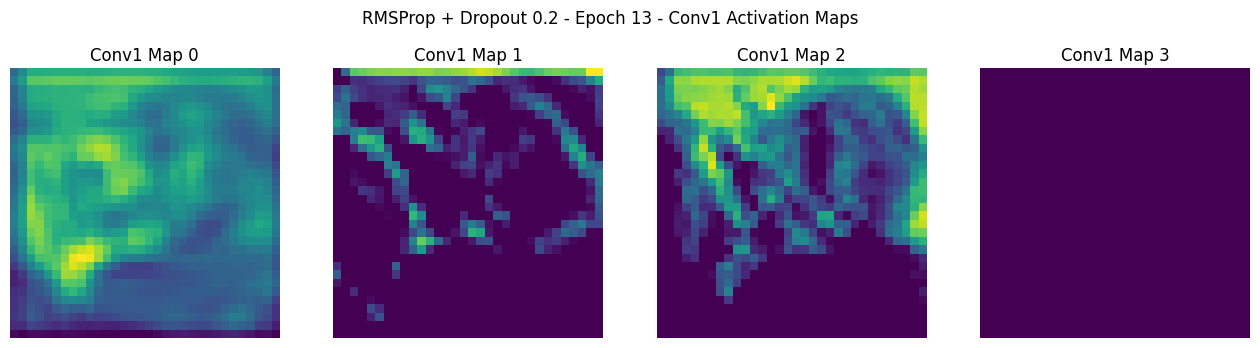

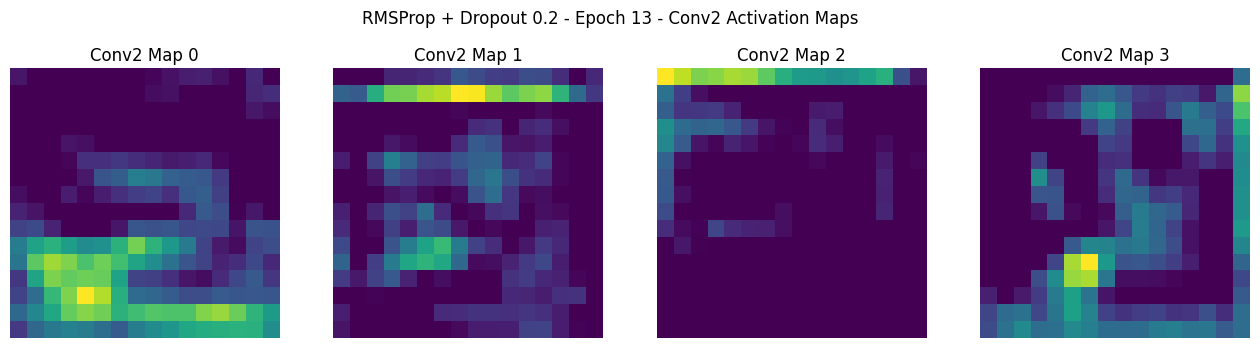

Epoch [14/15] | Train Loss: 1.7538 | Test Loss: 1.9198 | Train Acc: 0.3800 | Test Acc: 0.3200


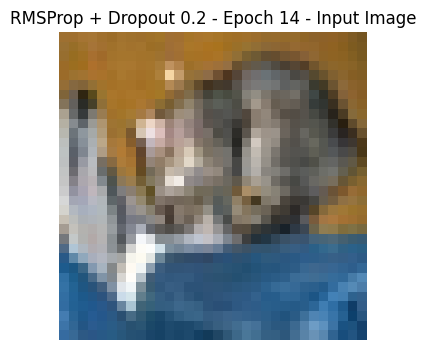

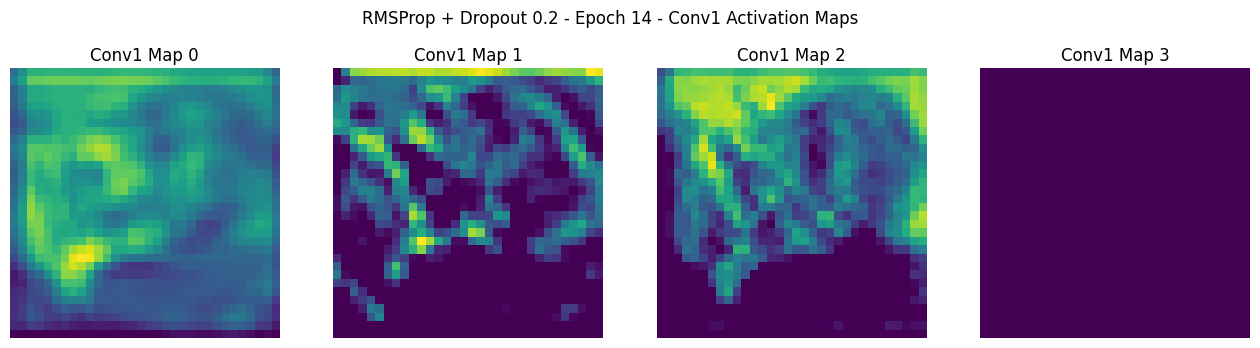

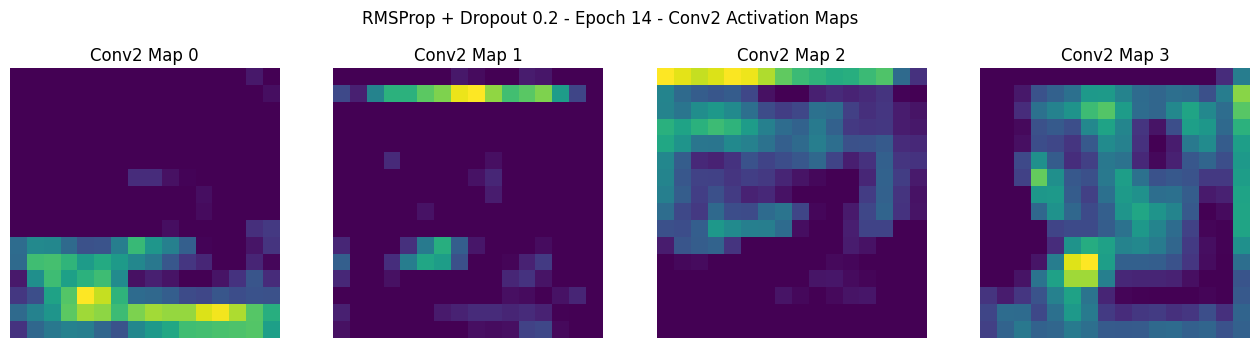

Epoch [15/15] | Train Loss: 1.7110 | Test Loss: 2.0144 | Train Acc: 0.4100 | Test Acc: 0.3100


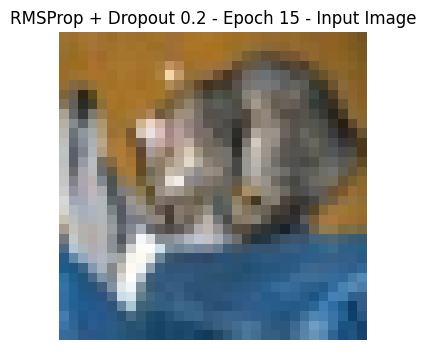

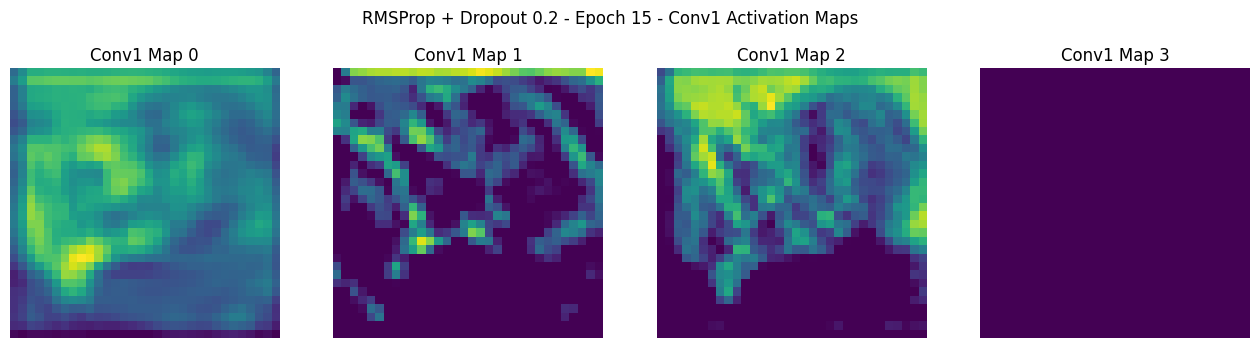

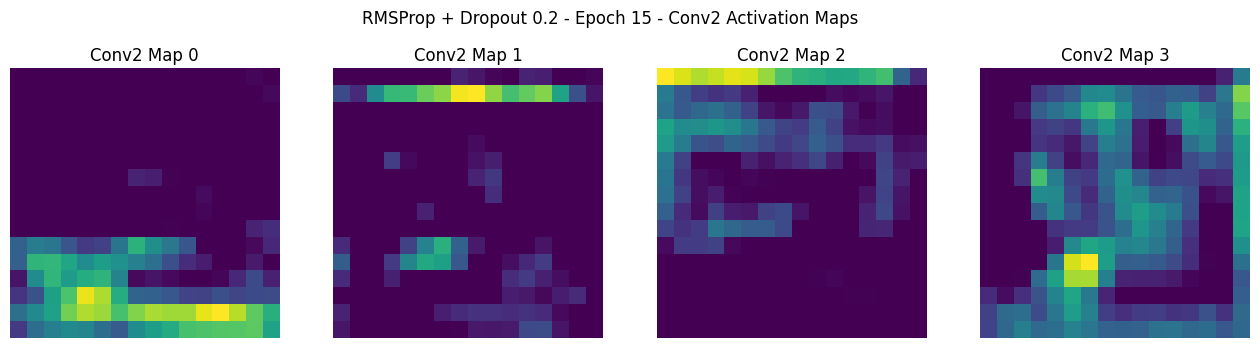


Training RMSProp with Dropout p = 0.5

Epoch [1/15] | Train Loss: 2.3045 | Test Loss: 2.3007 | Train Acc: 0.0960 | Test Acc: 0.1000


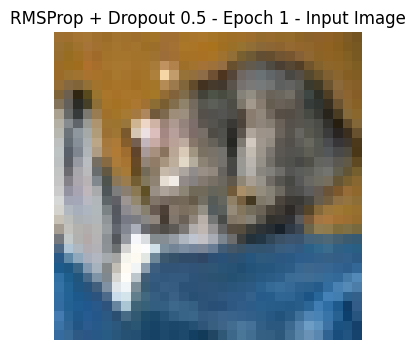

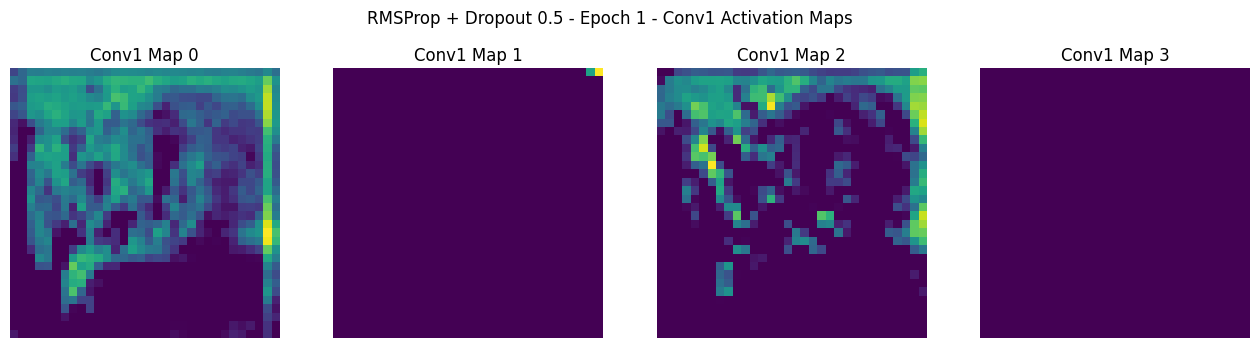

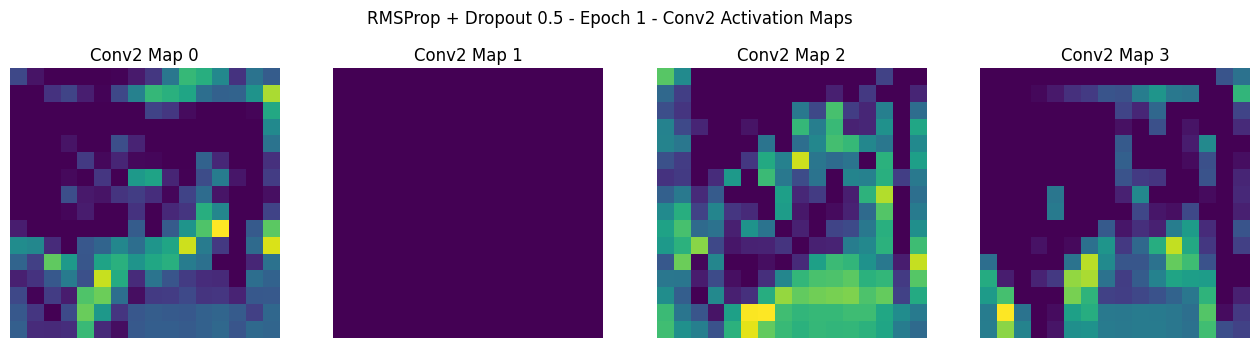

Epoch [2/15] | Train Loss: 2.2955 | Test Loss: 2.2891 | Train Acc: 0.1150 | Test Acc: 0.1400


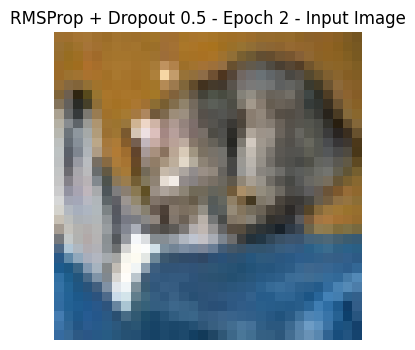

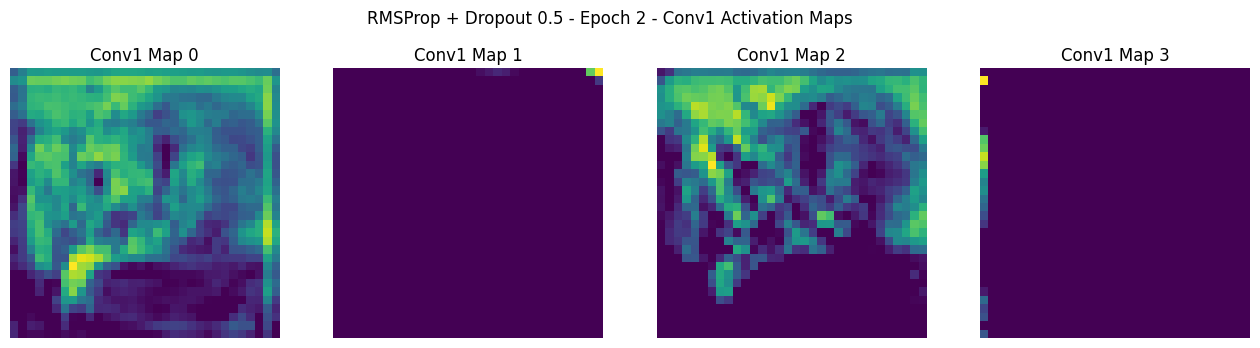

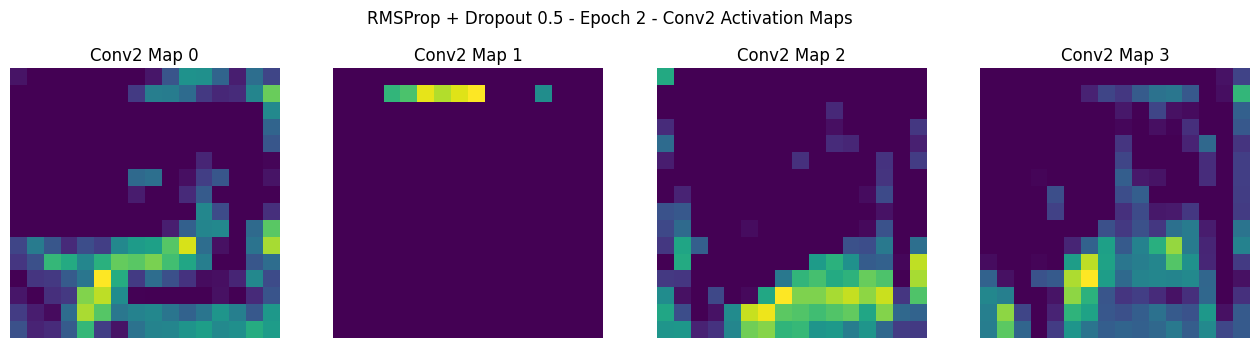

Epoch [3/15] | Train Loss: 2.2812 | Test Loss: 2.2796 | Train Acc: 0.1430 | Test Acc: 0.1400


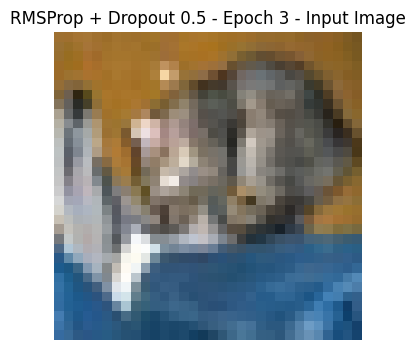

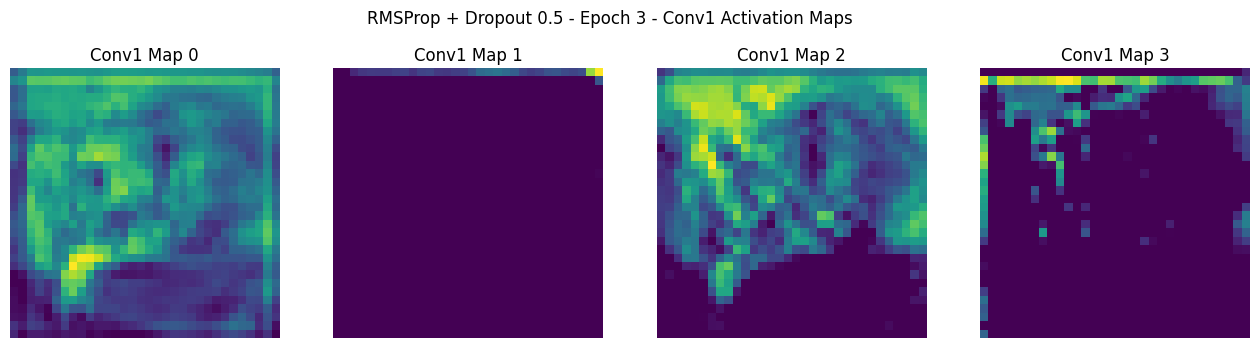

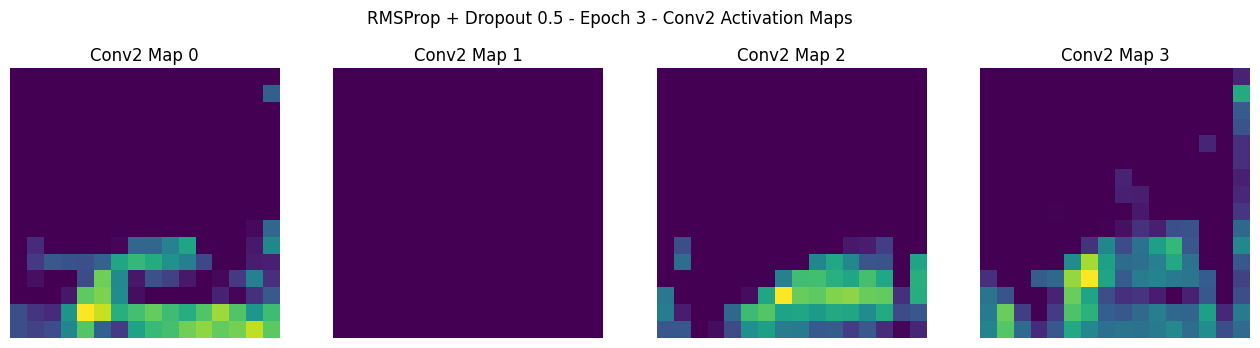

Epoch [4/15] | Train Loss: 2.2451 | Test Loss: 2.2352 | Train Acc: 0.1470 | Test Acc: 0.1700


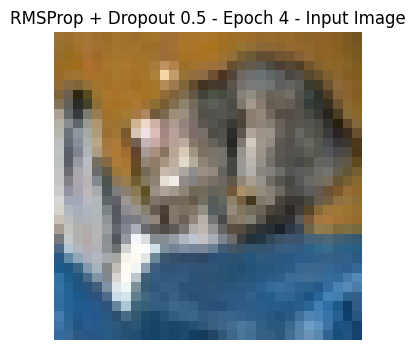

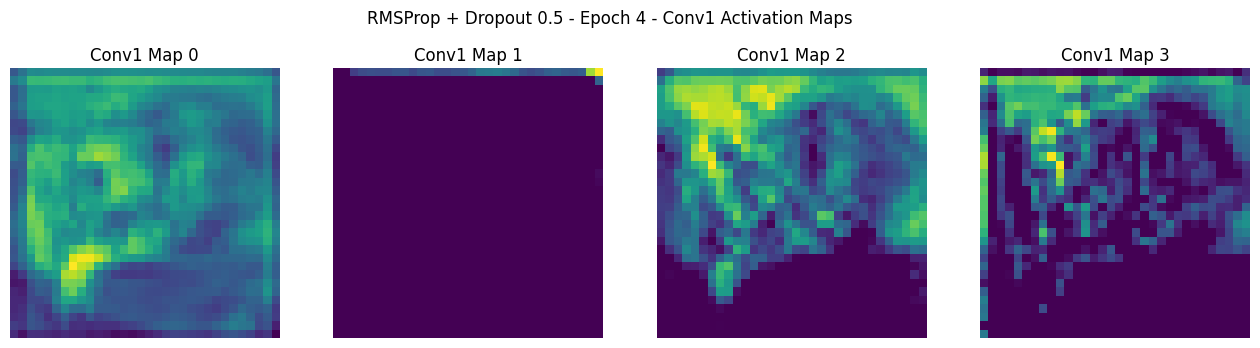

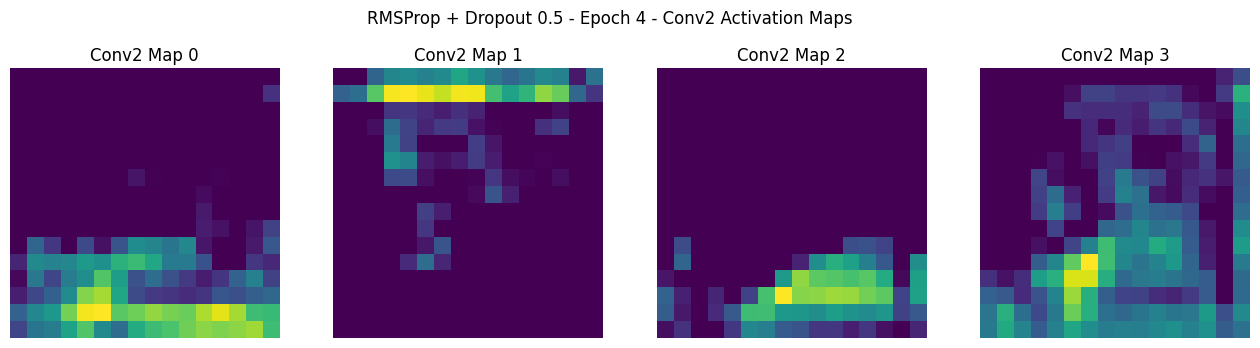

Epoch [5/15] | Train Loss: 2.1890 | Test Loss: 2.1476 | Train Acc: 0.1820 | Test Acc: 0.2500


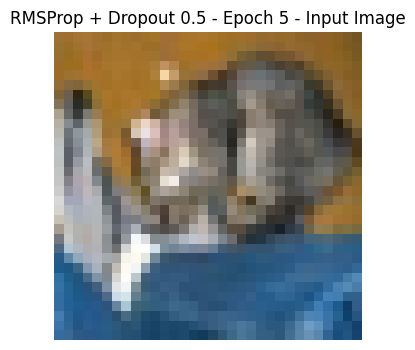

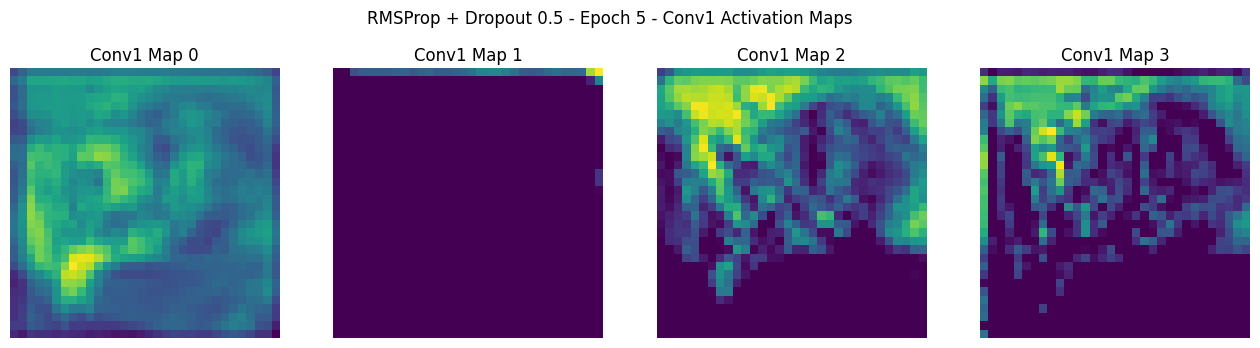

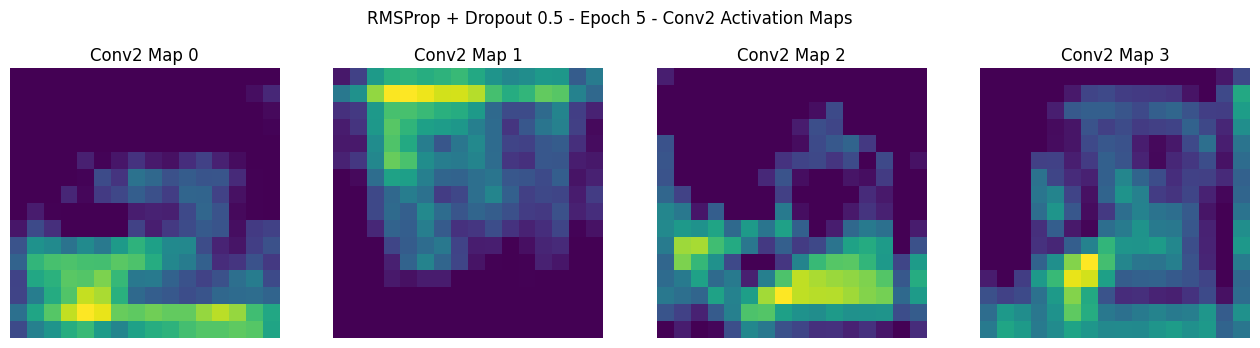

Epoch [6/15] | Train Loss: 2.1506 | Test Loss: 2.1159 | Train Acc: 0.2060 | Test Acc: 0.2700


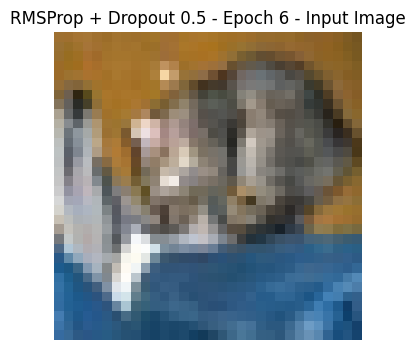

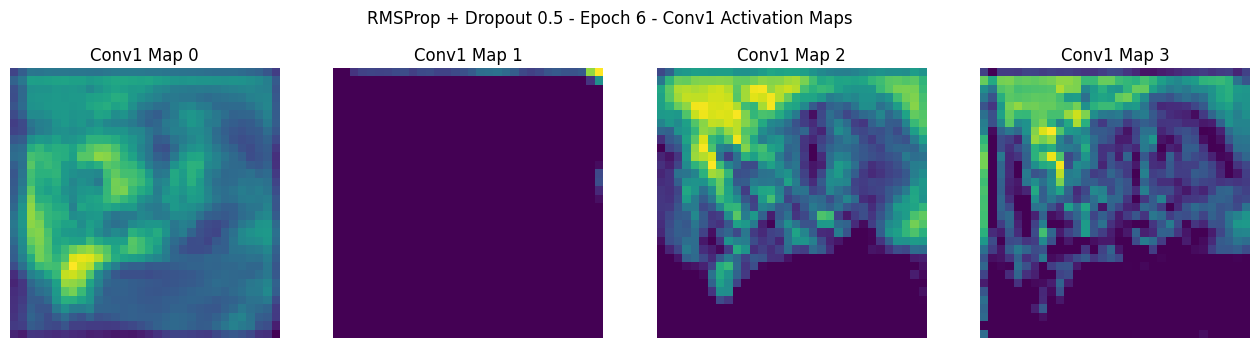

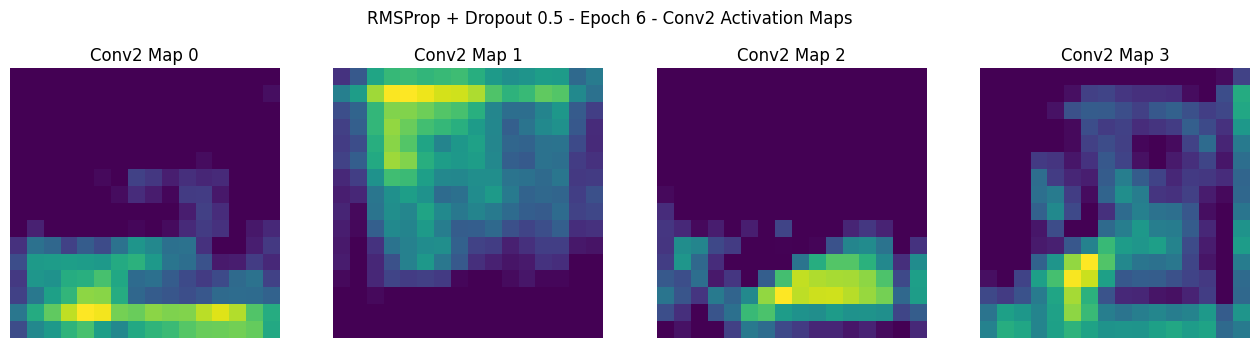

Epoch [7/15] | Train Loss: 2.1061 | Test Loss: 2.1625 | Train Acc: 0.2390 | Test Acc: 0.2400


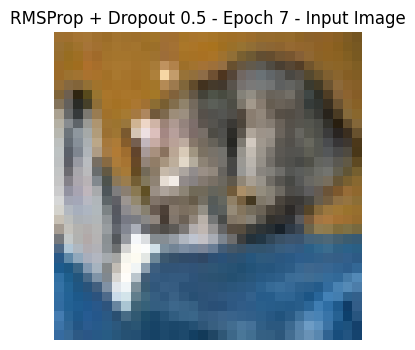

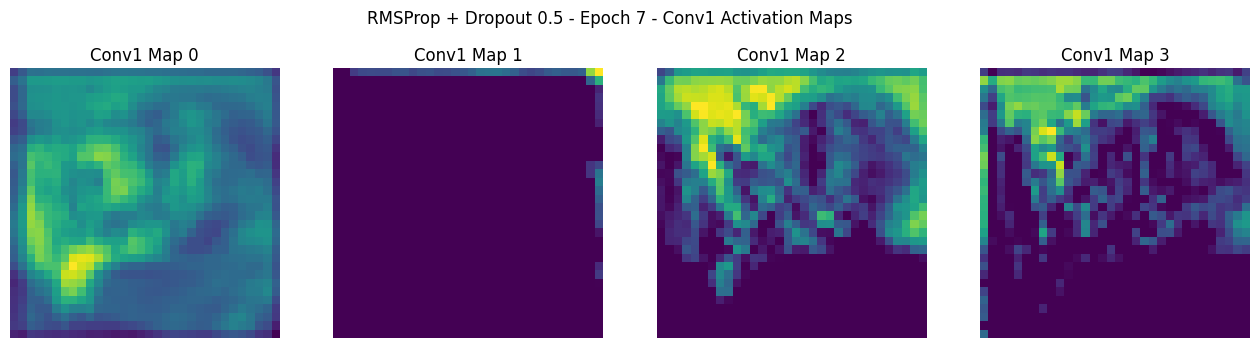

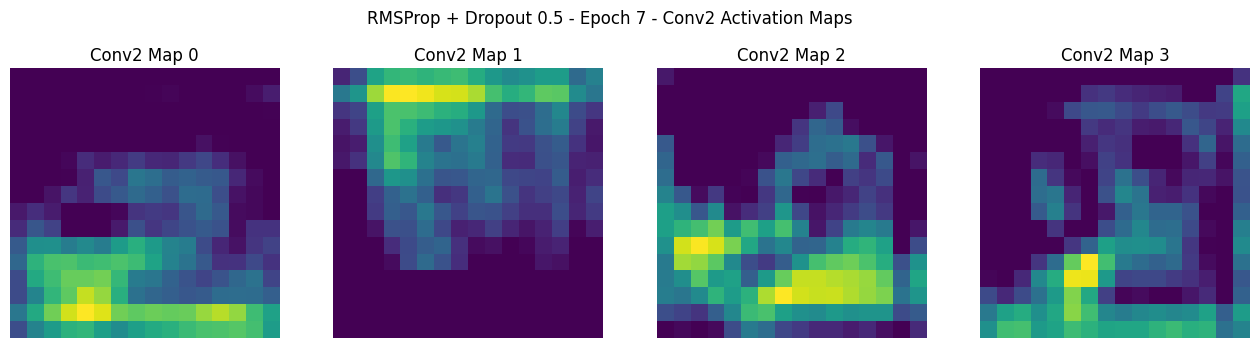

Epoch [8/15] | Train Loss: 2.0774 | Test Loss: 2.1009 | Train Acc: 0.2360 | Test Acc: 0.2500


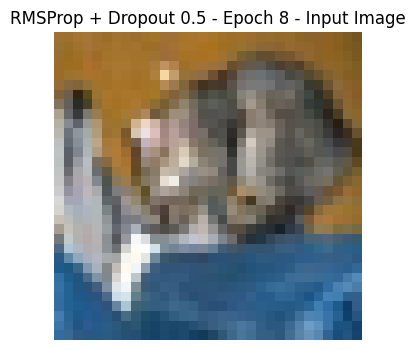

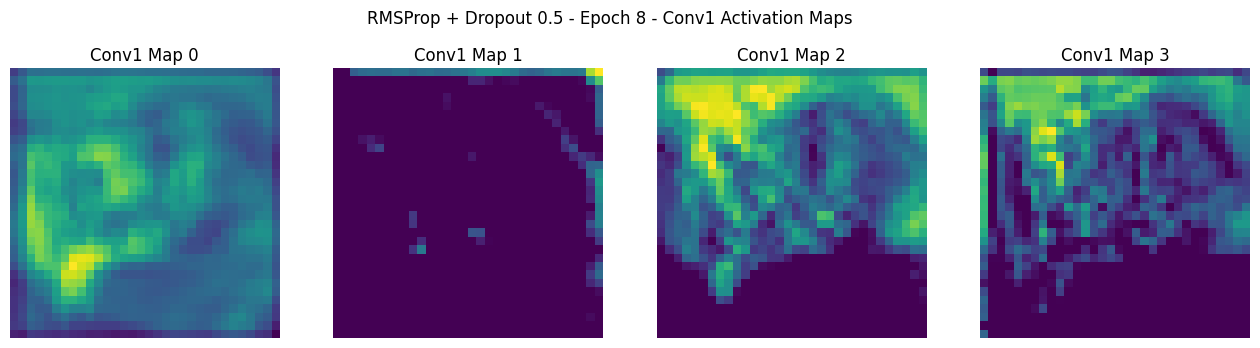

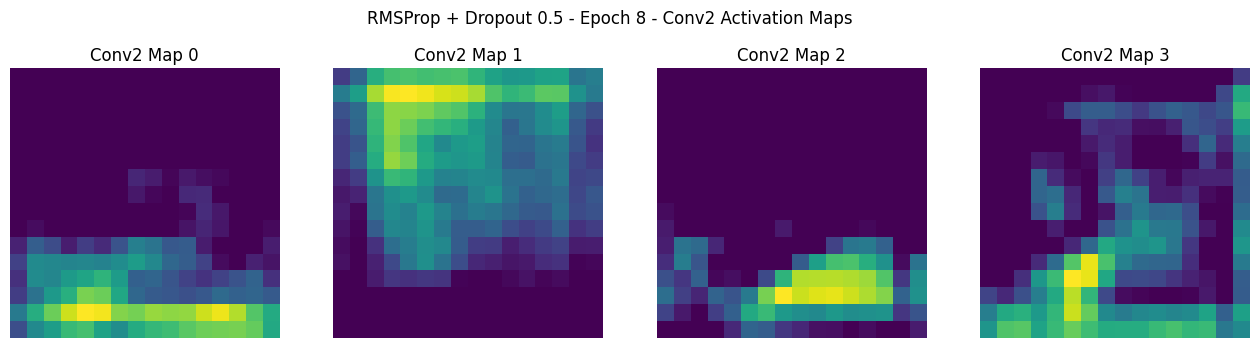

Epoch [9/15] | Train Loss: 2.0215 | Test Loss: 2.0803 | Train Acc: 0.2570 | Test Acc: 0.2700


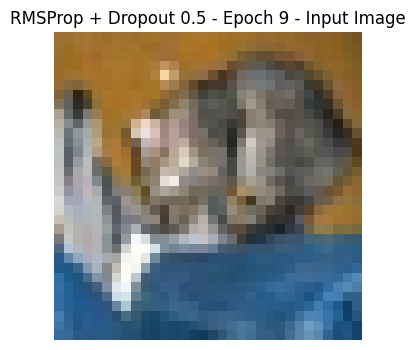

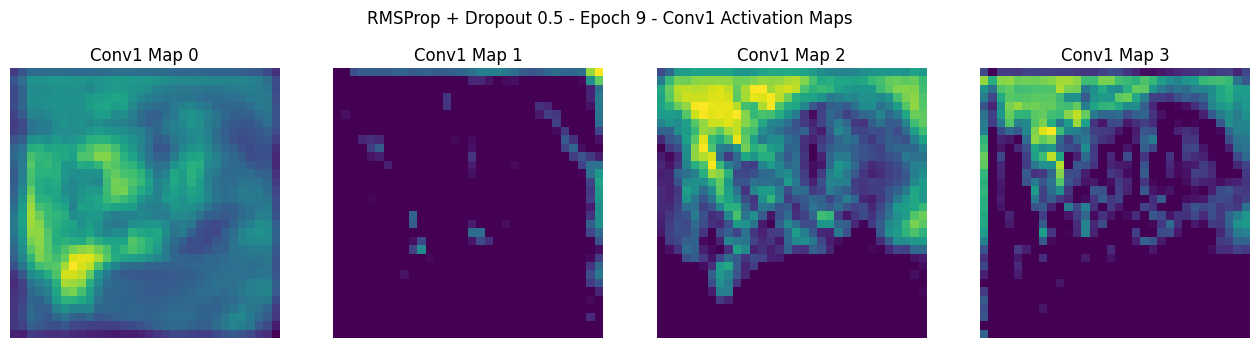

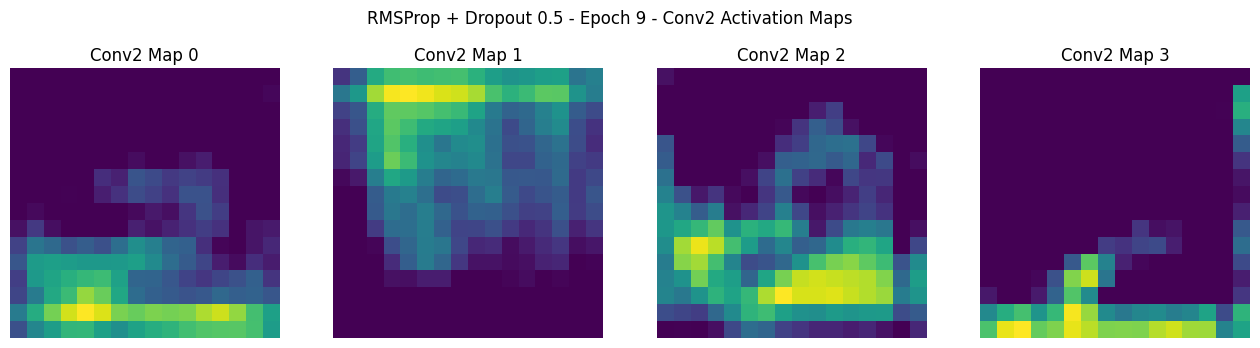

Epoch [10/15] | Train Loss: 2.0411 | Test Loss: 2.1393 | Train Acc: 0.2470 | Test Acc: 0.2200


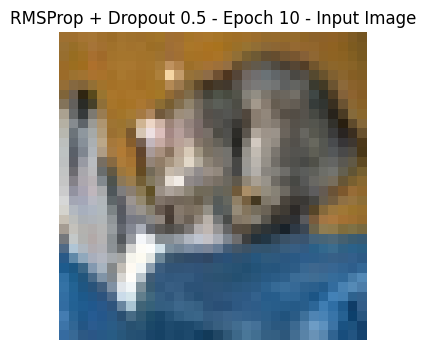

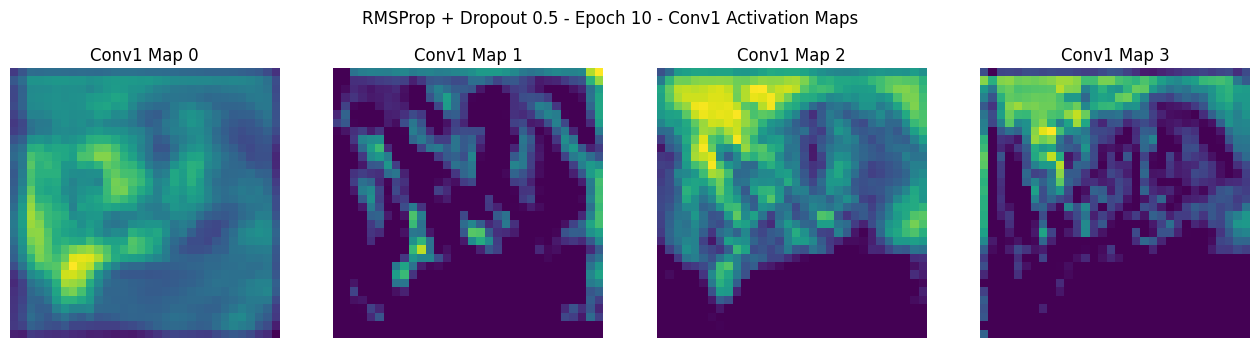

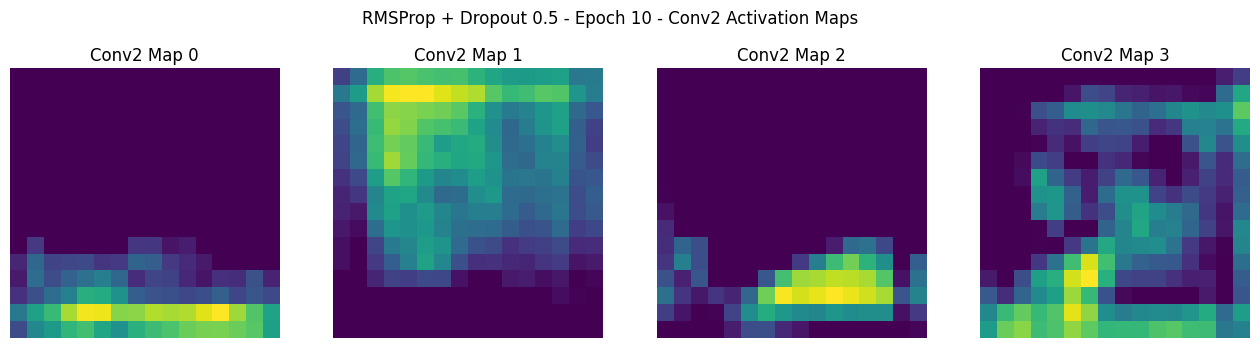

Epoch [11/15] | Train Loss: 1.9803 | Test Loss: 1.9481 | Train Acc: 0.2880 | Test Acc: 0.3000


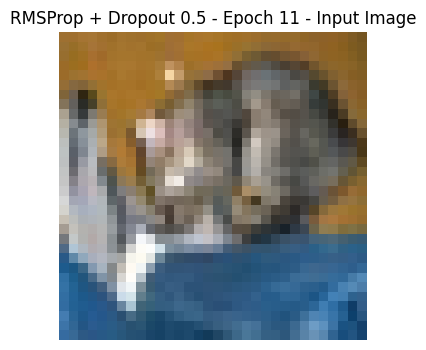

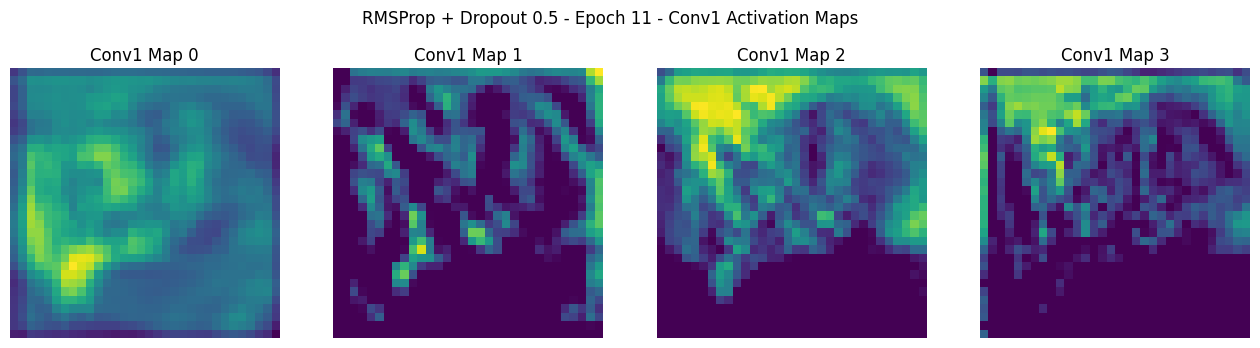

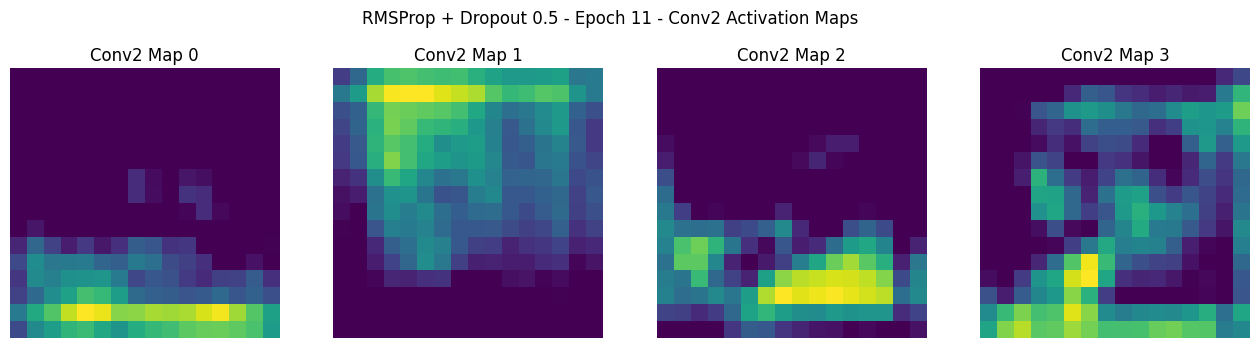

Epoch [12/15] | Train Loss: 1.9926 | Test Loss: 2.1201 | Train Acc: 0.2840 | Test Acc: 0.2400


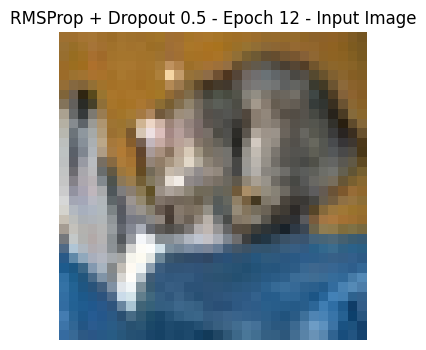

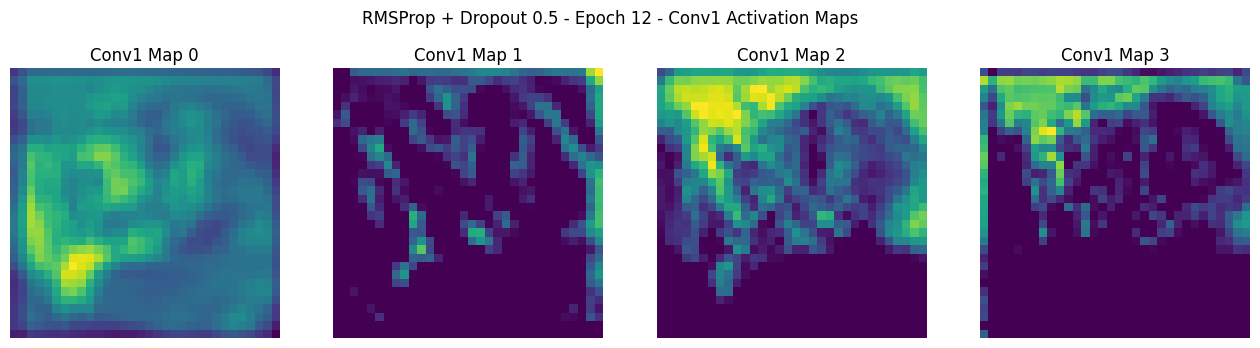

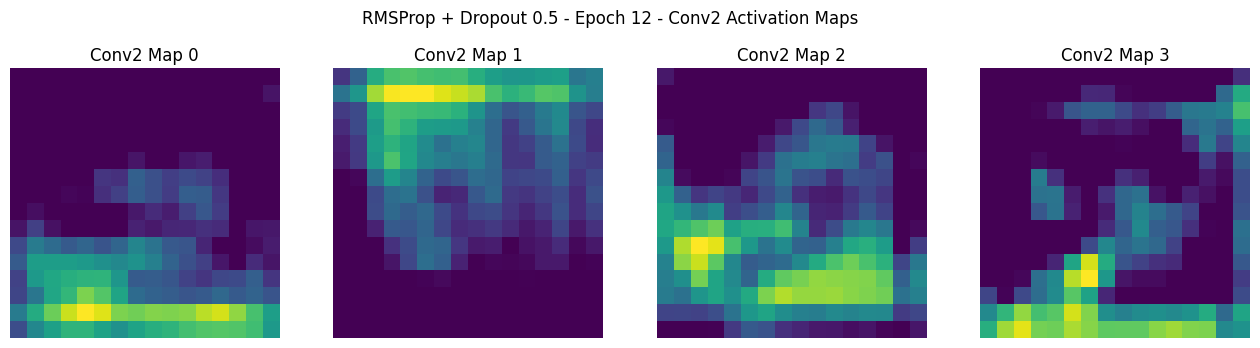

Epoch [13/15] | Train Loss: 1.9339 | Test Loss: 1.9631 | Train Acc: 0.2920 | Test Acc: 0.3100


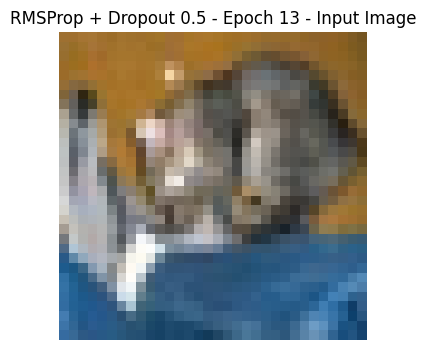

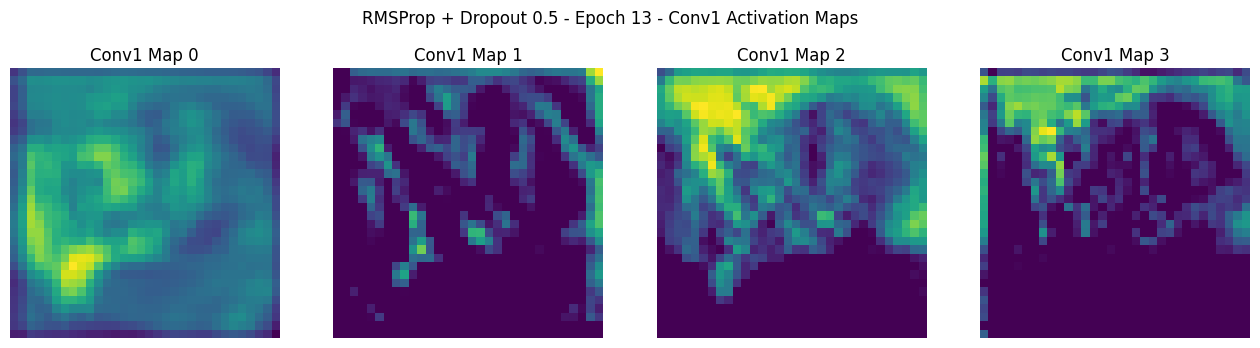

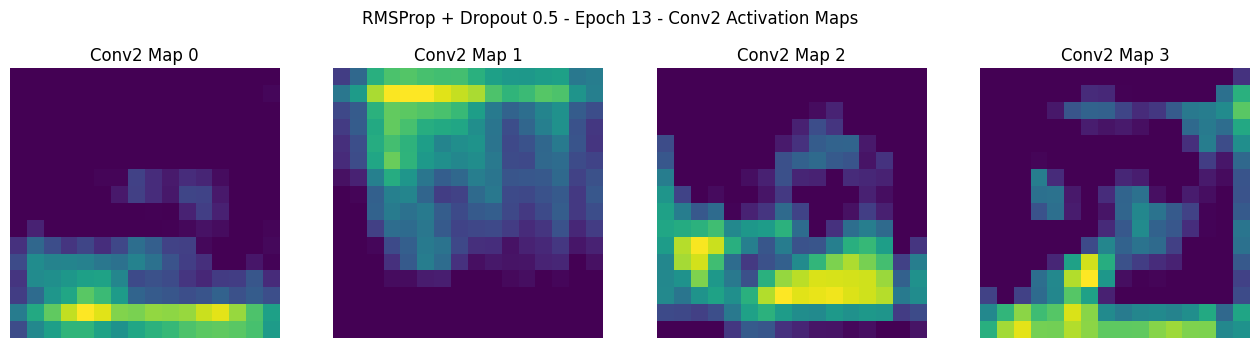

Epoch [14/15] | Train Loss: 1.9247 | Test Loss: 2.0537 | Train Acc: 0.3070 | Test Acc: 0.2800


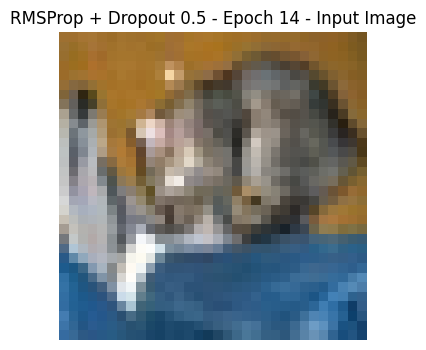

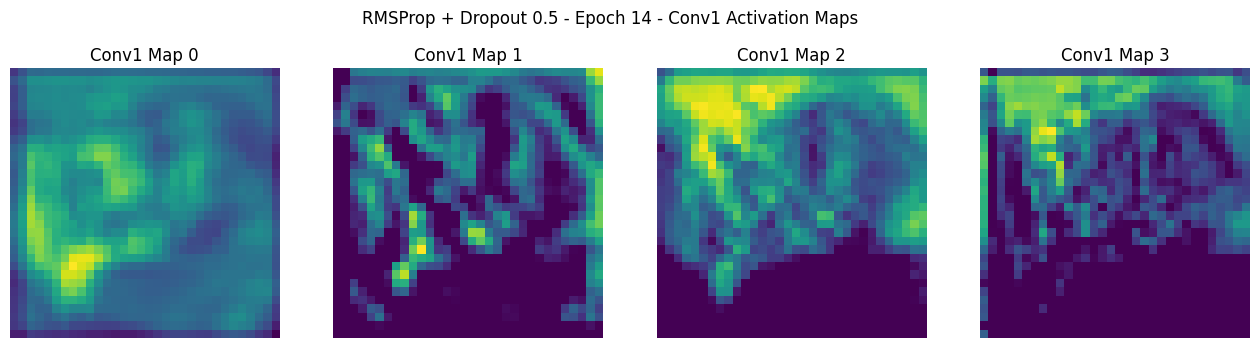

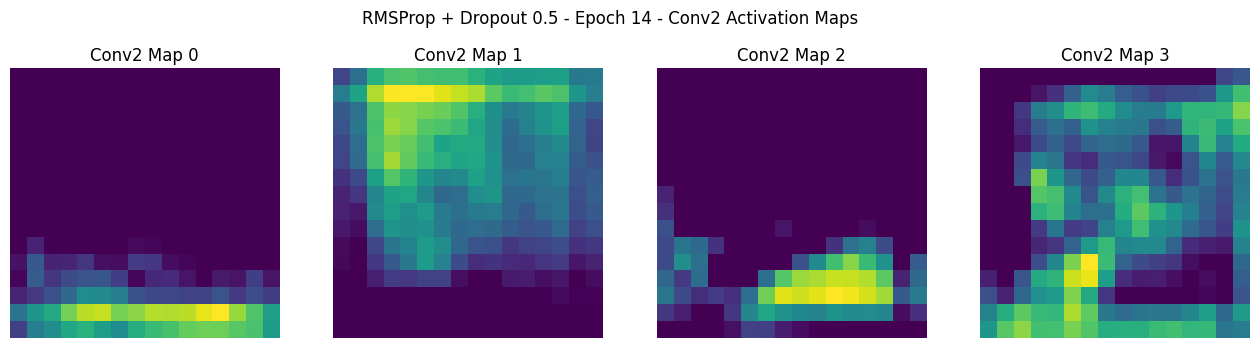

Epoch [15/15] | Train Loss: 1.9058 | Test Loss: 2.0135 | Train Acc: 0.3090 | Test Acc: 0.2800


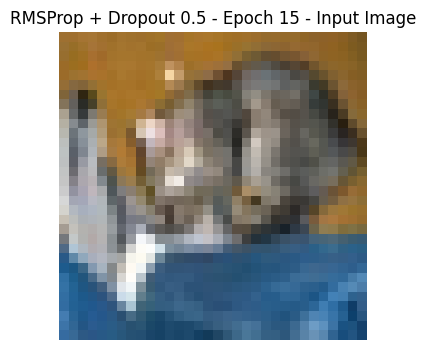

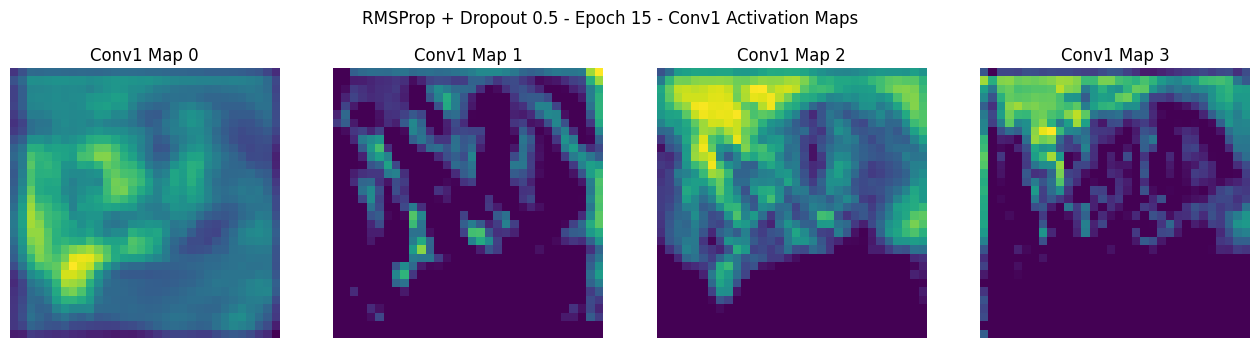

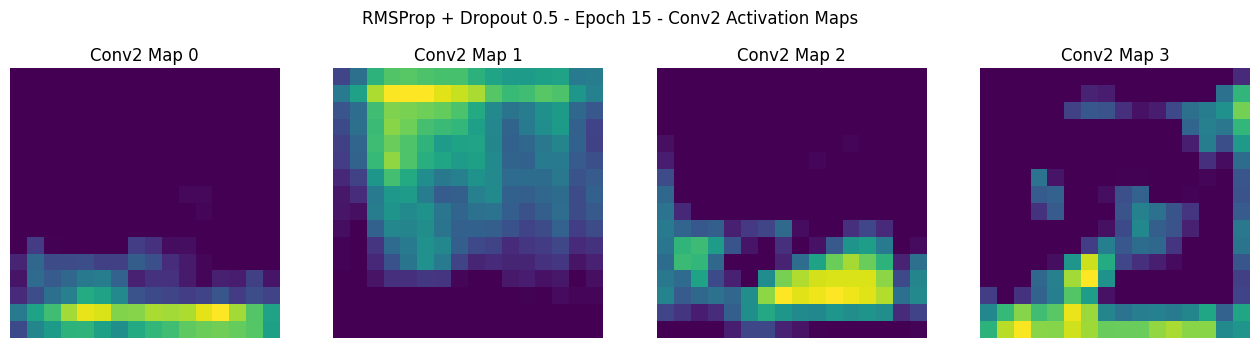


Training RMSProp with Dropout p = 0.8

Epoch [1/15] | Train Loss: 2.3057 | Test Loss: 2.3041 | Train Acc: 0.0830 | Test Acc: 0.1000


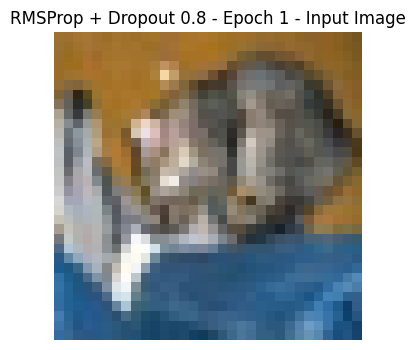

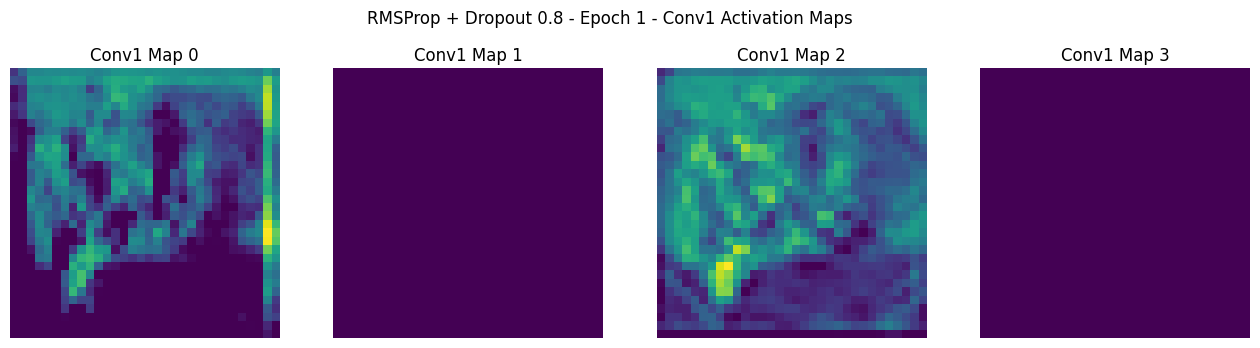

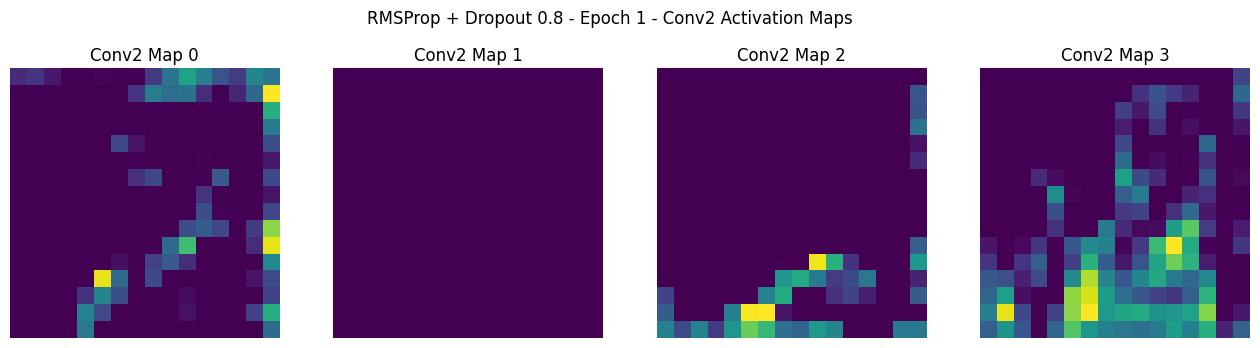

Epoch [2/15] | Train Loss: 2.3035 | Test Loss: 2.3023 | Train Acc: 0.1010 | Test Acc: 0.0800


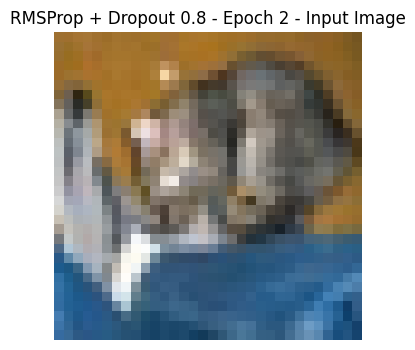

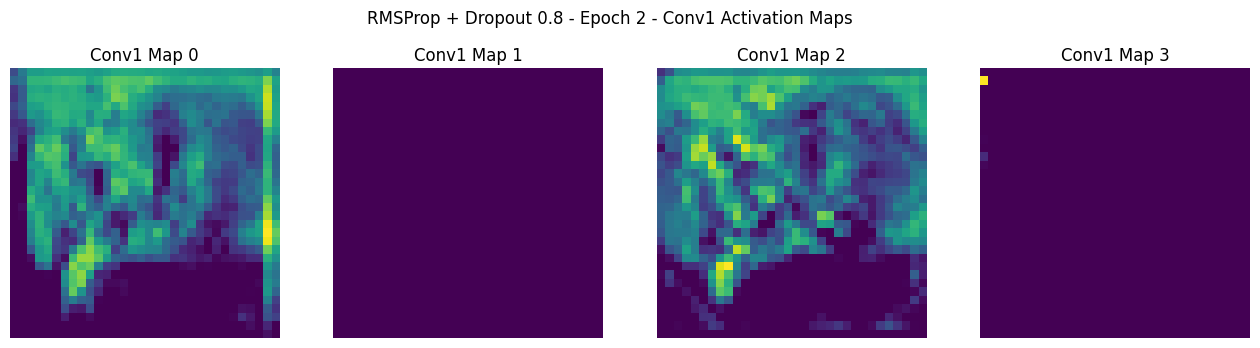

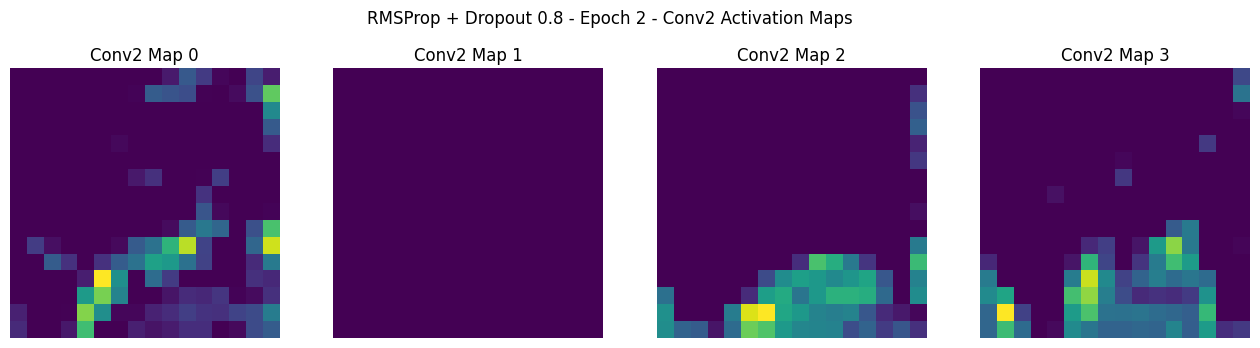

Epoch [3/15] | Train Loss: 2.3000 | Test Loss: 2.2978 | Train Acc: 0.1120 | Test Acc: 0.0900


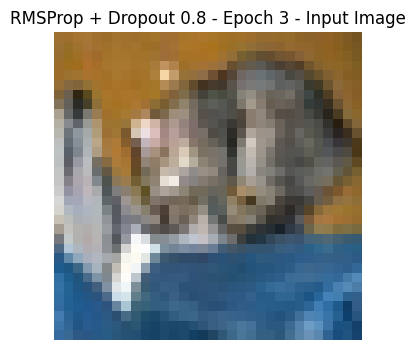

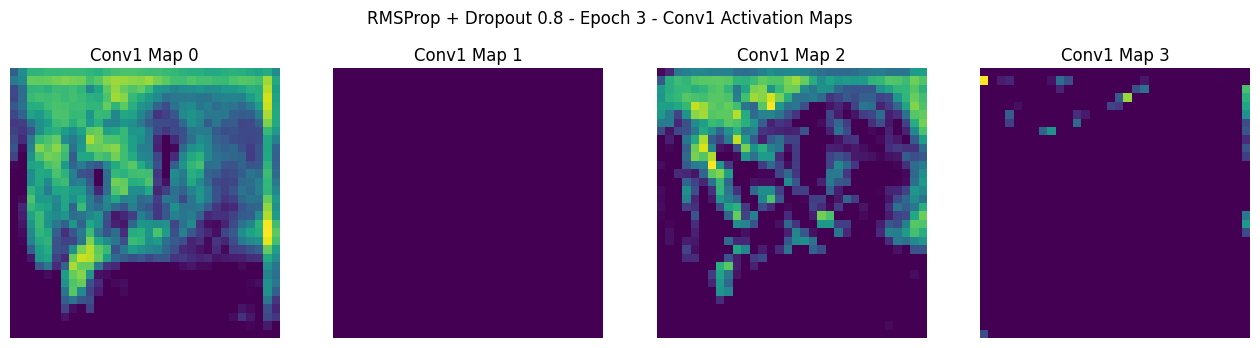

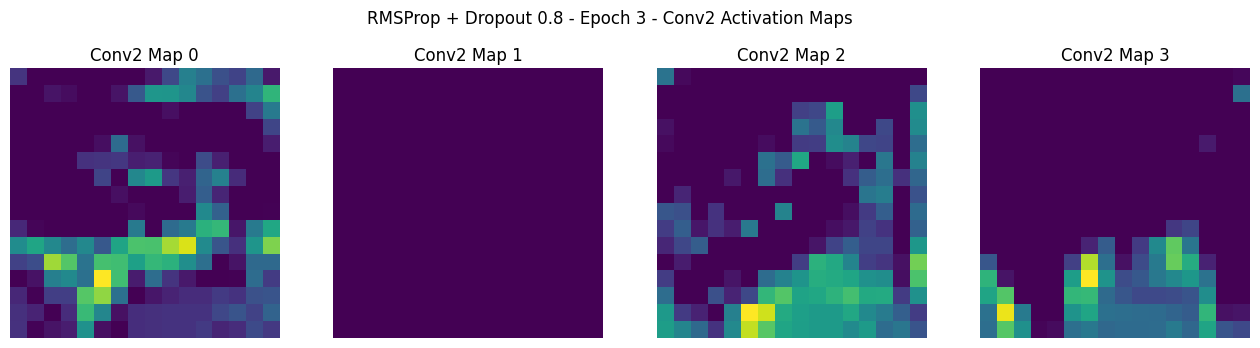

Epoch [4/15] | Train Loss: 2.2985 | Test Loss: 2.2947 | Train Acc: 0.1140 | Test Acc: 0.1100


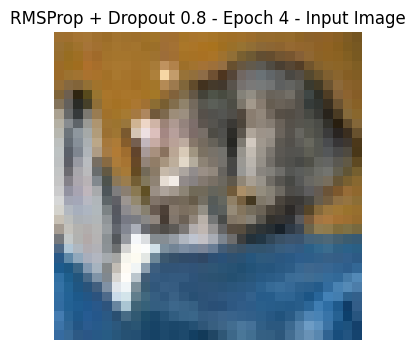

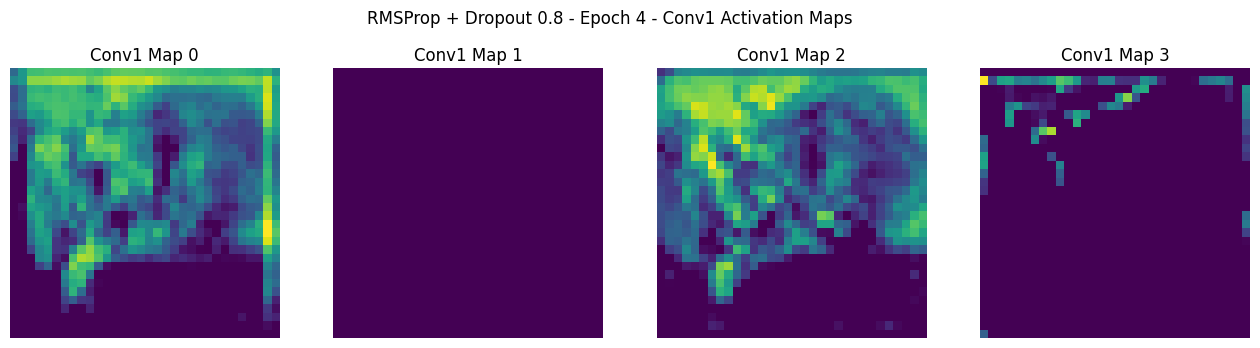

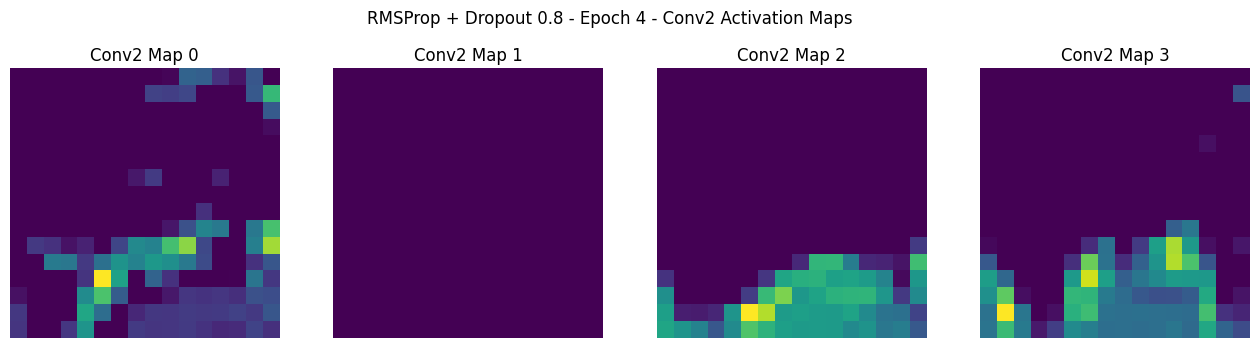

Epoch [5/15] | Train Loss: 2.2859 | Test Loss: 2.2739 | Train Acc: 0.1240 | Test Acc: 0.2000


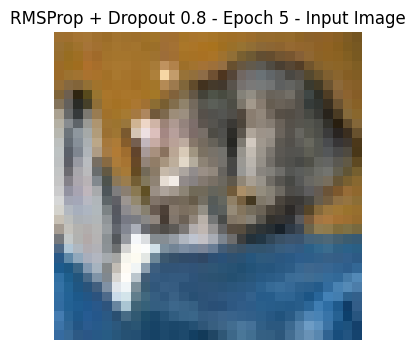

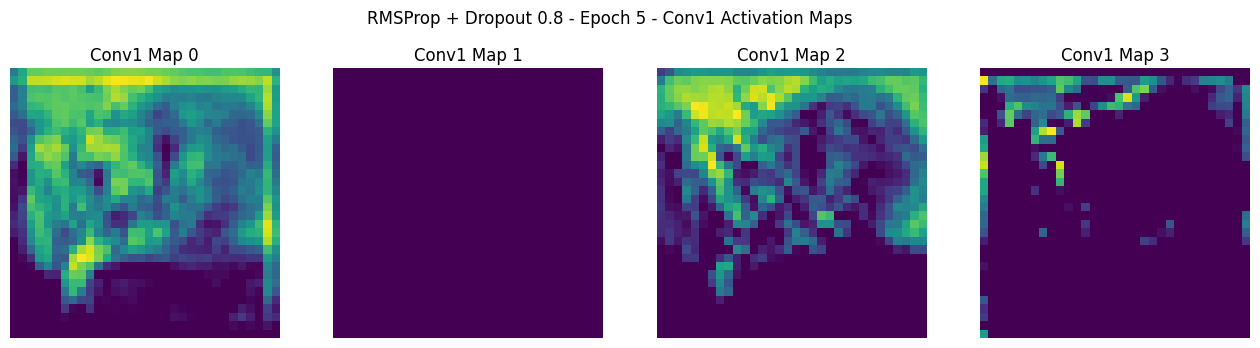

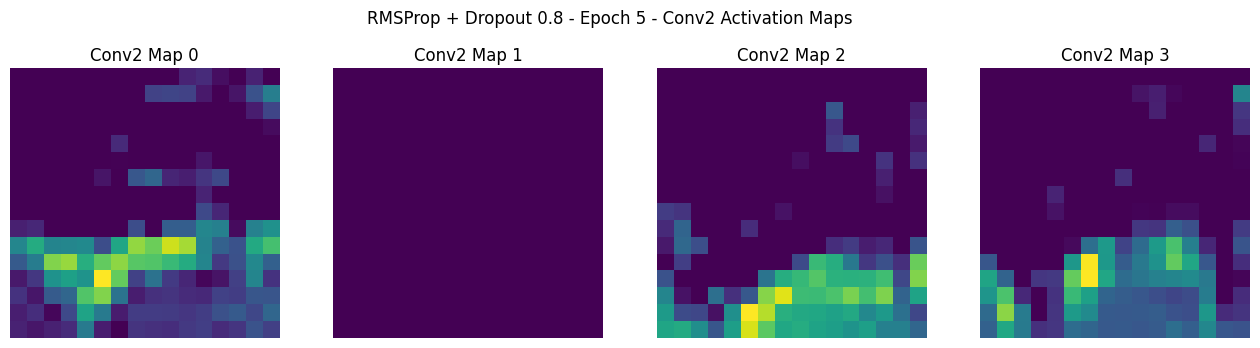

Epoch [6/15] | Train Loss: 2.2740 | Test Loss: 2.2478 | Train Acc: 0.1370 | Test Acc: 0.1700


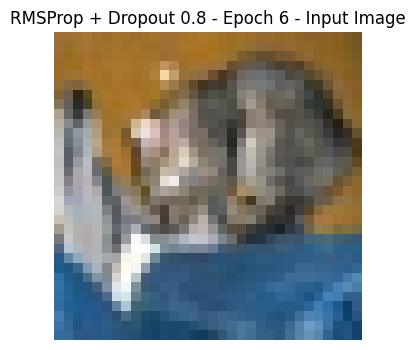

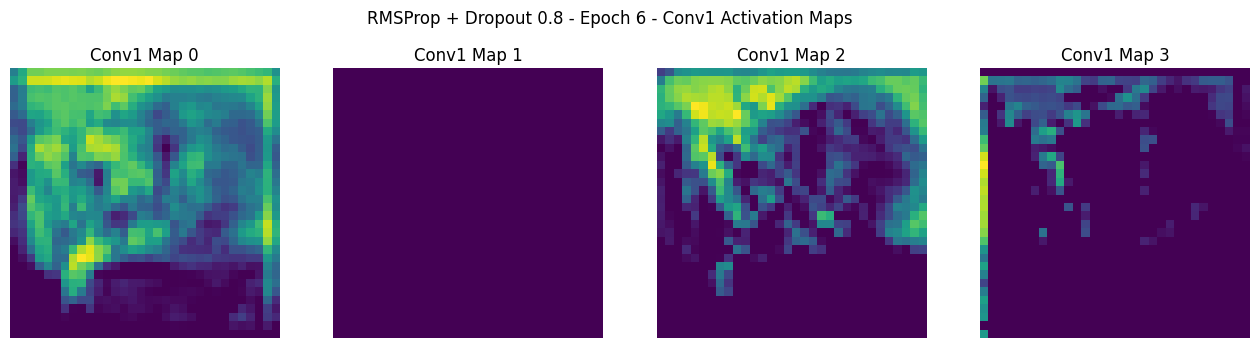

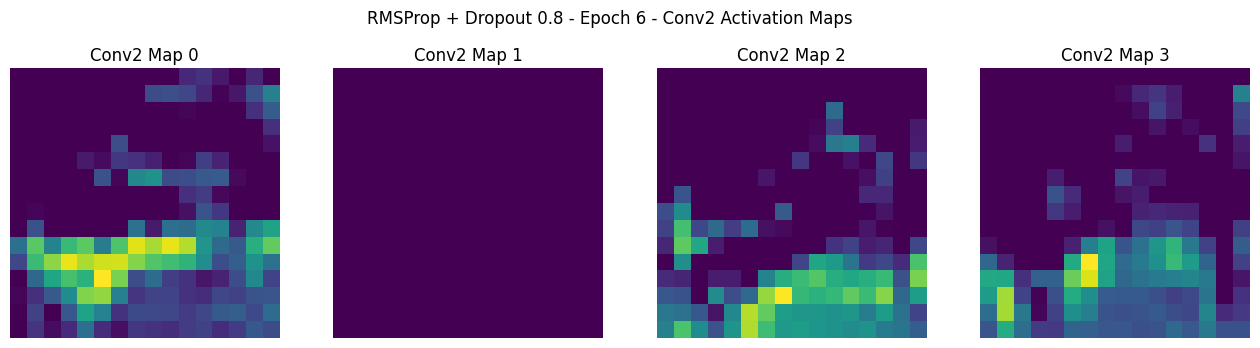

Epoch [7/15] | Train Loss: 2.2580 | Test Loss: 2.2423 | Train Acc: 0.1420 | Test Acc: 0.1600


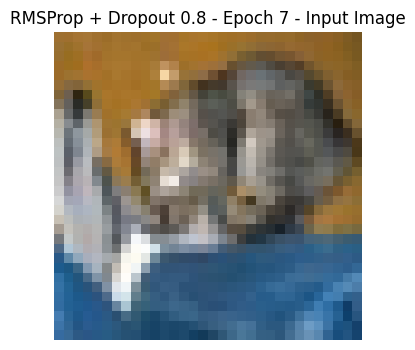

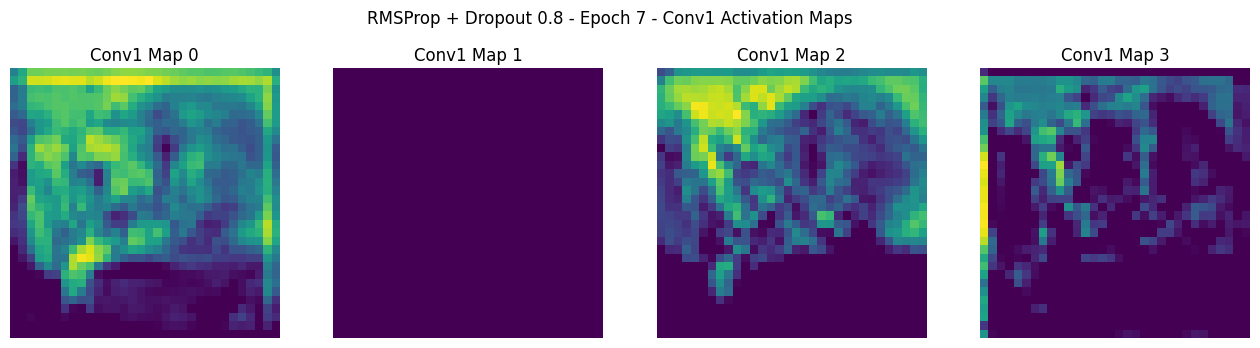

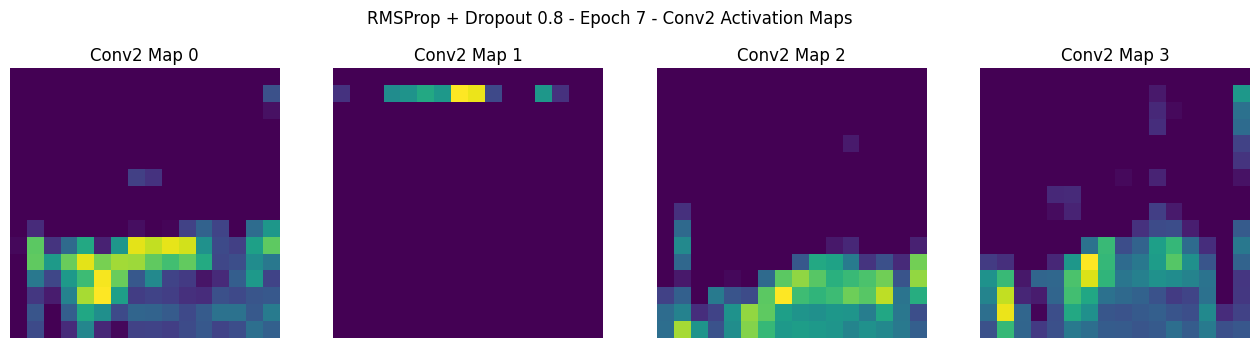

Epoch [8/15] | Train Loss: 2.2288 | Test Loss: 2.1939 | Train Acc: 0.1350 | Test Acc: 0.2400


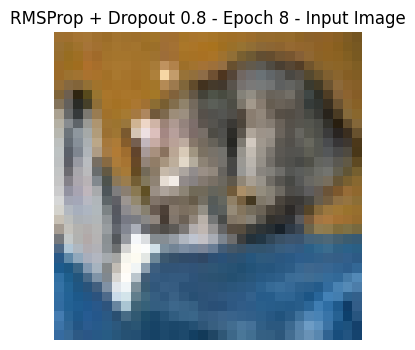

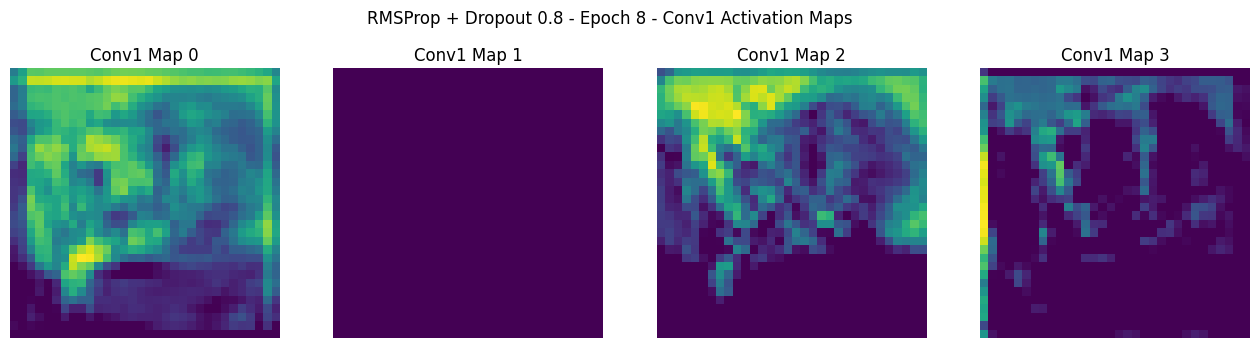

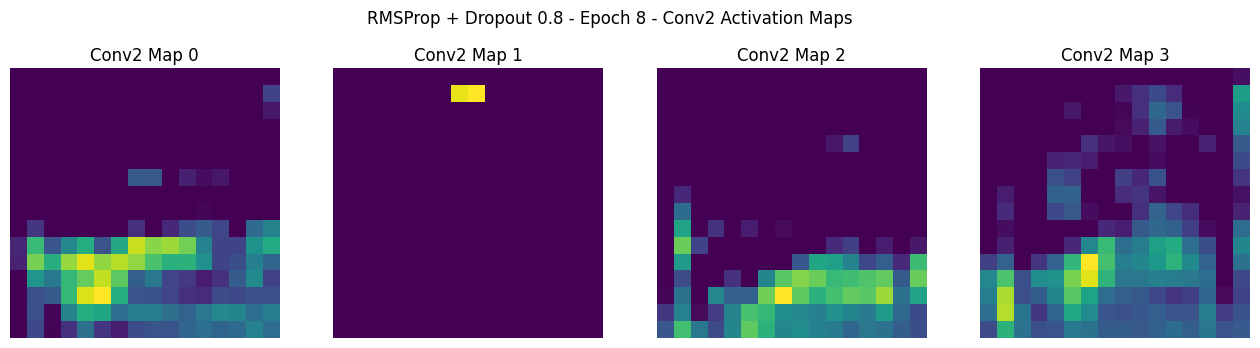

Epoch [9/15] | Train Loss: 2.1959 | Test Loss: 2.1797 | Train Acc: 0.1620 | Test Acc: 0.2300


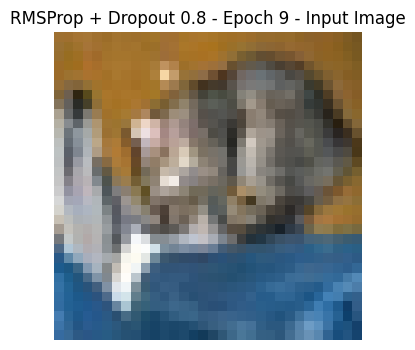

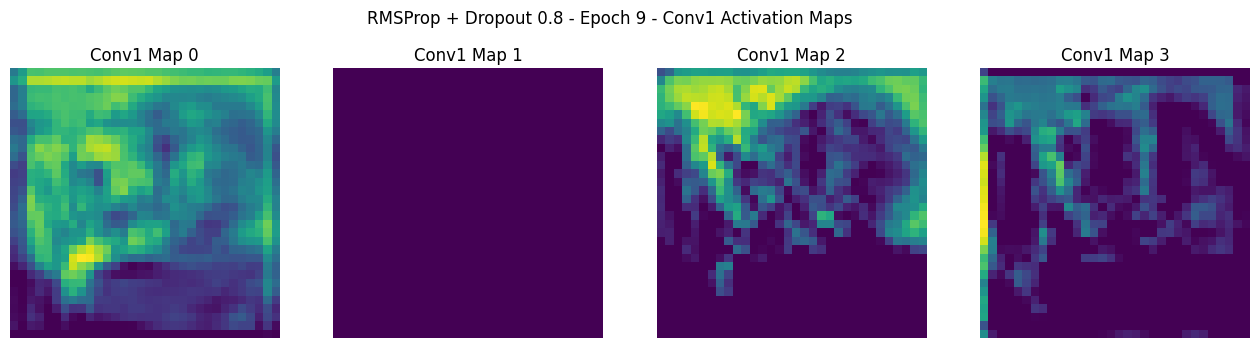

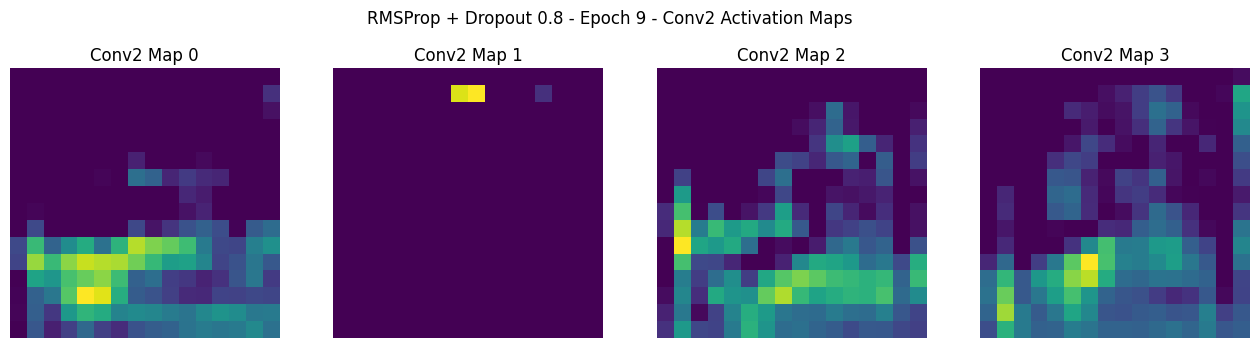

Epoch [10/15] | Train Loss: 2.1873 | Test Loss: 2.2335 | Train Acc: 0.1890 | Test Acc: 0.1900


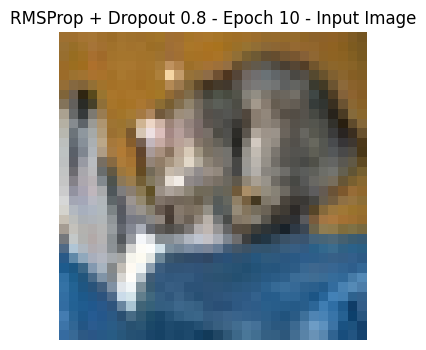

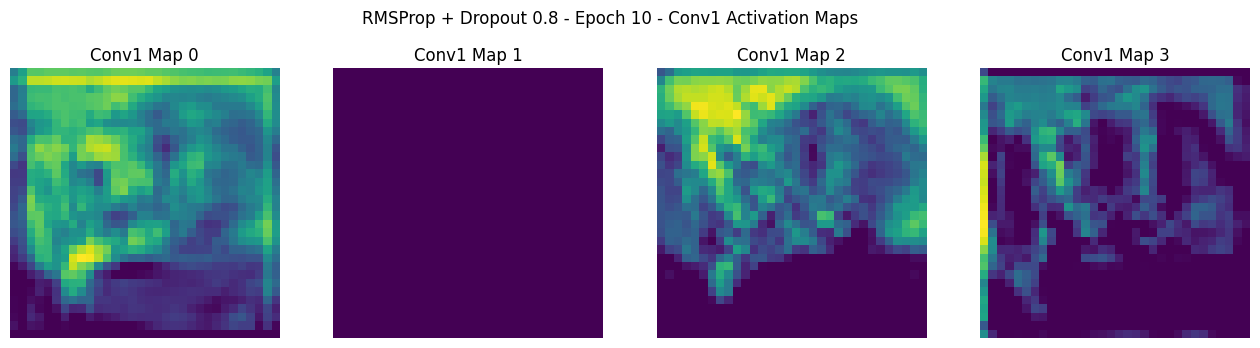

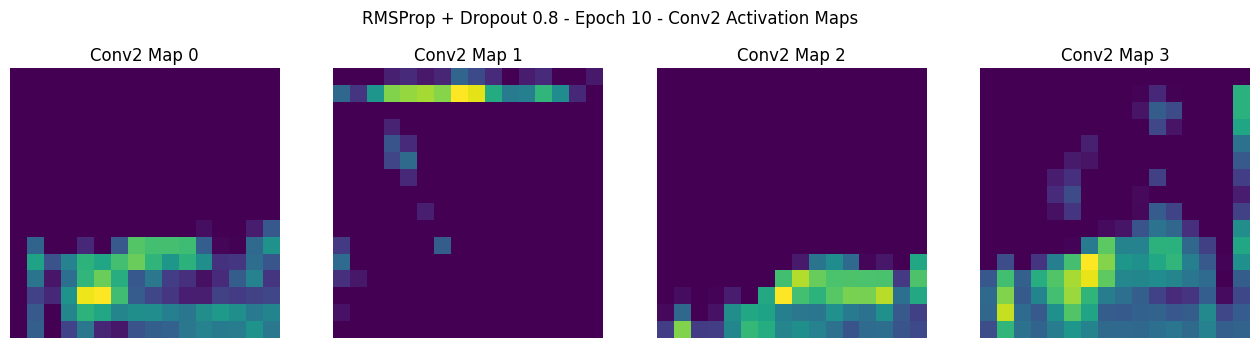

Epoch [11/15] | Train Loss: 2.1791 | Test Loss: 2.1301 | Train Acc: 0.1540 | Test Acc: 0.2800


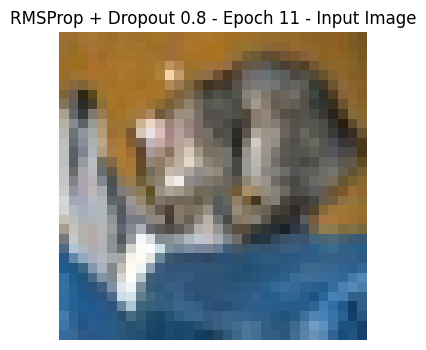

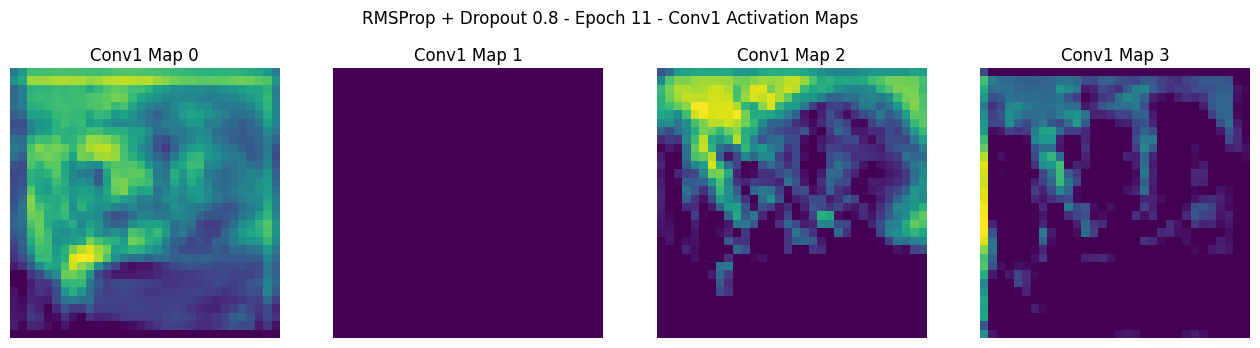

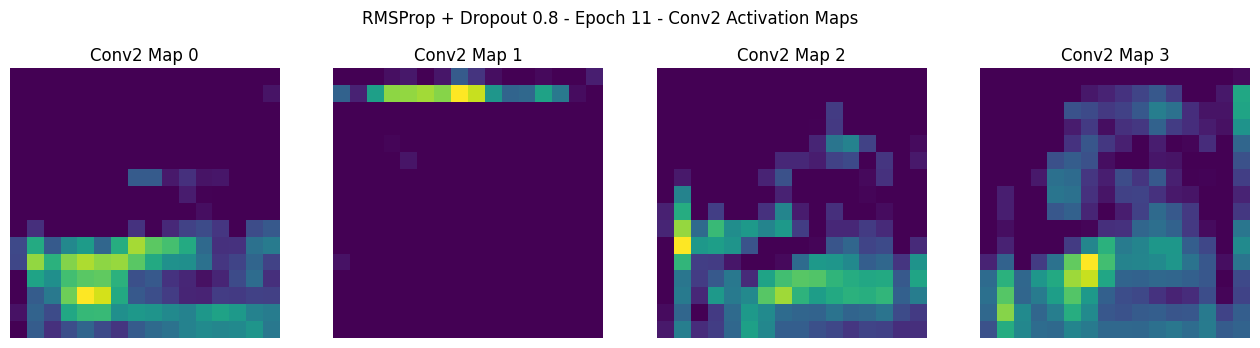

Epoch [12/15] | Train Loss: 2.1604 | Test Loss: 2.1970 | Train Acc: 0.1880 | Test Acc: 0.2100


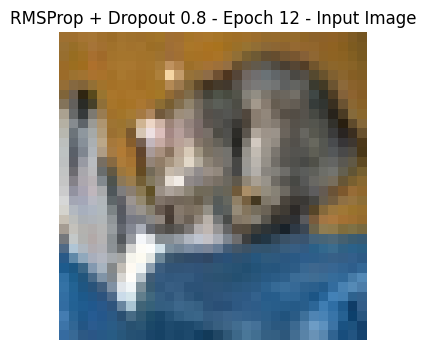

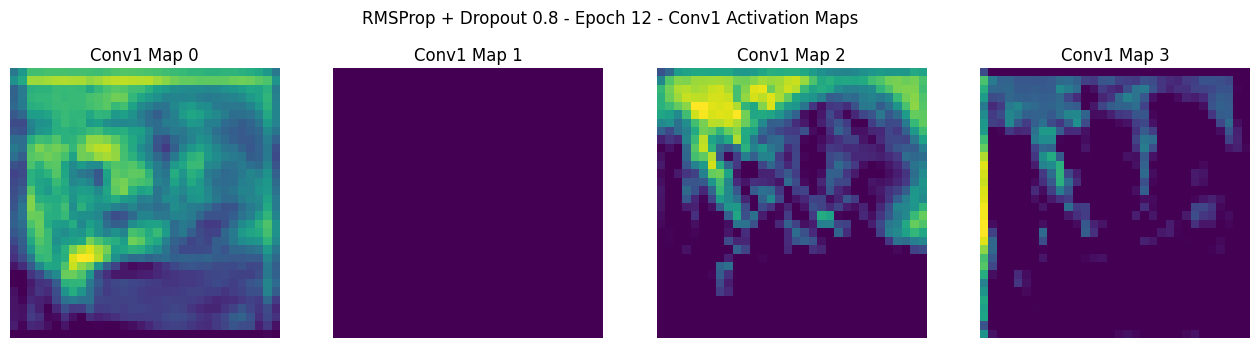

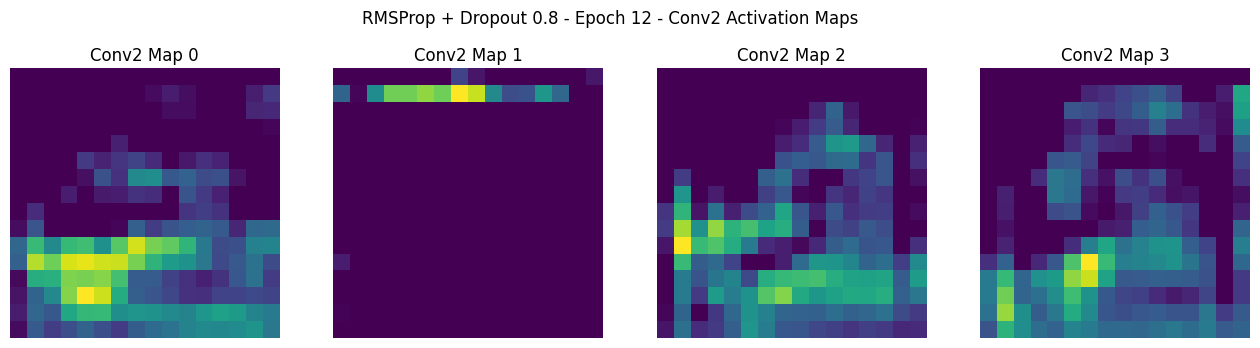

Epoch [13/15] | Train Loss: 2.1122 | Test Loss: 2.0890 | Train Acc: 0.2180 | Test Acc: 0.2800


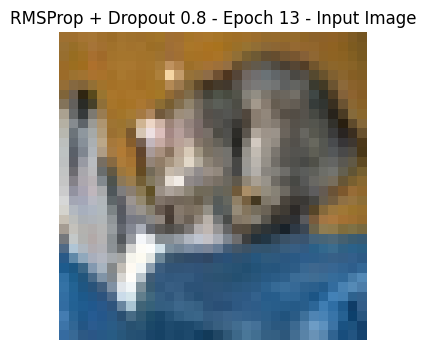

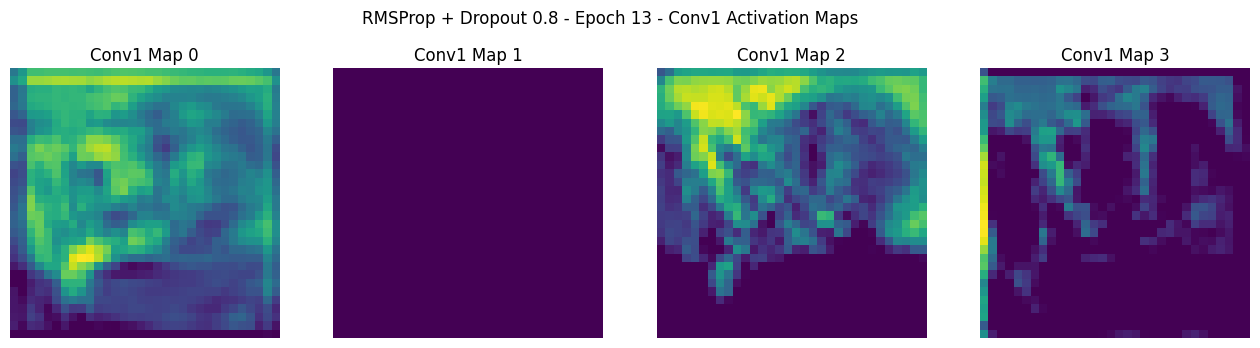

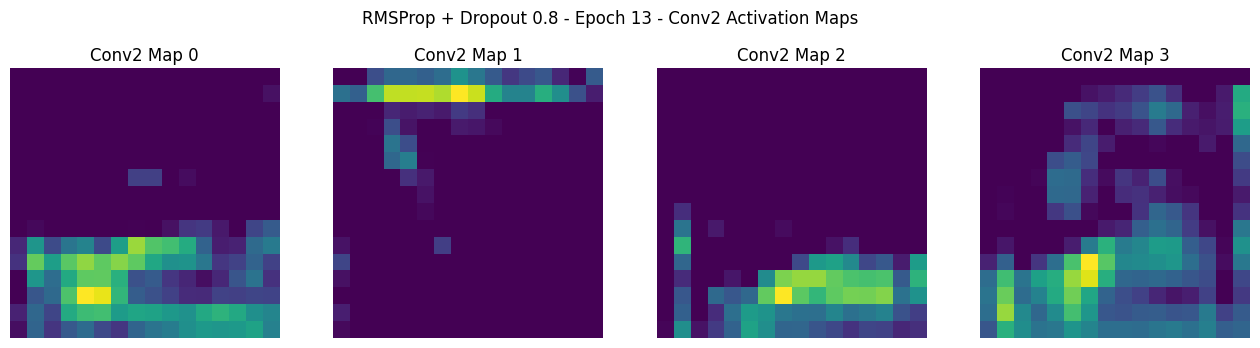

Epoch [14/15] | Train Loss: 2.1406 | Test Loss: 2.1428 | Train Acc: 0.1750 | Test Acc: 0.2700


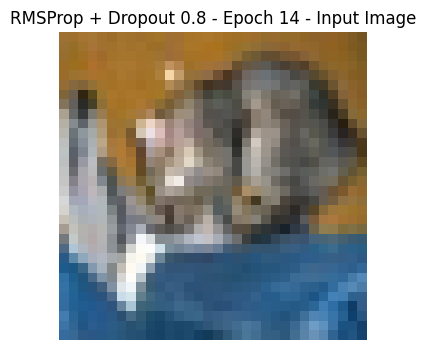

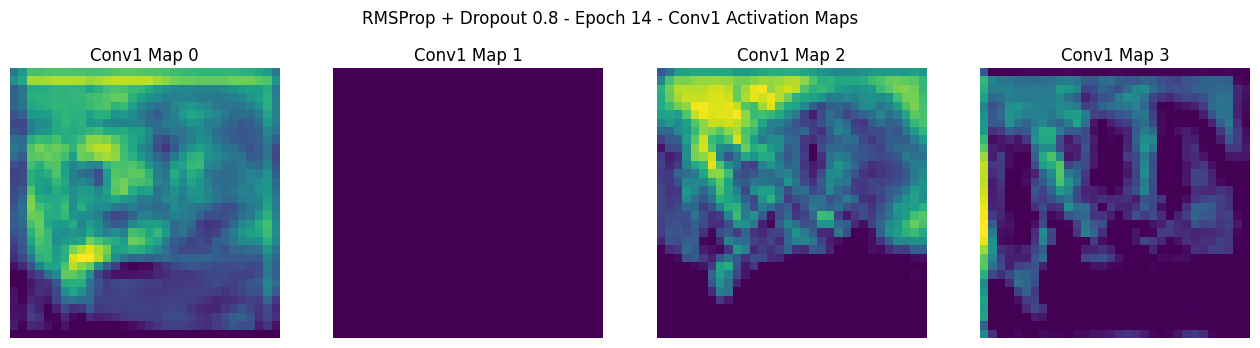

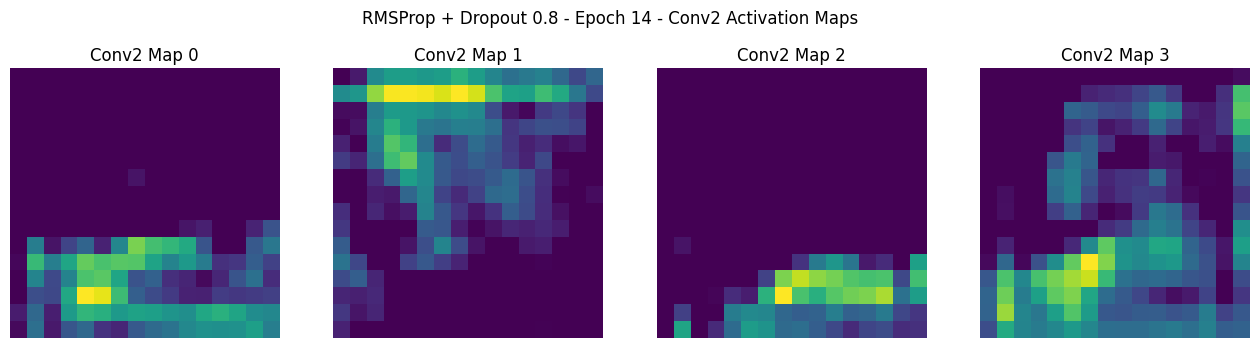

Epoch [15/15] | Train Loss: 2.1330 | Test Loss: 2.1718 | Train Acc: 0.2010 | Test Acc: 0.2400


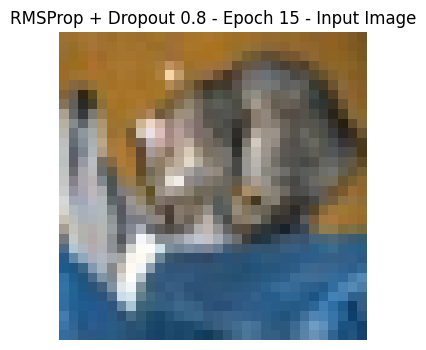

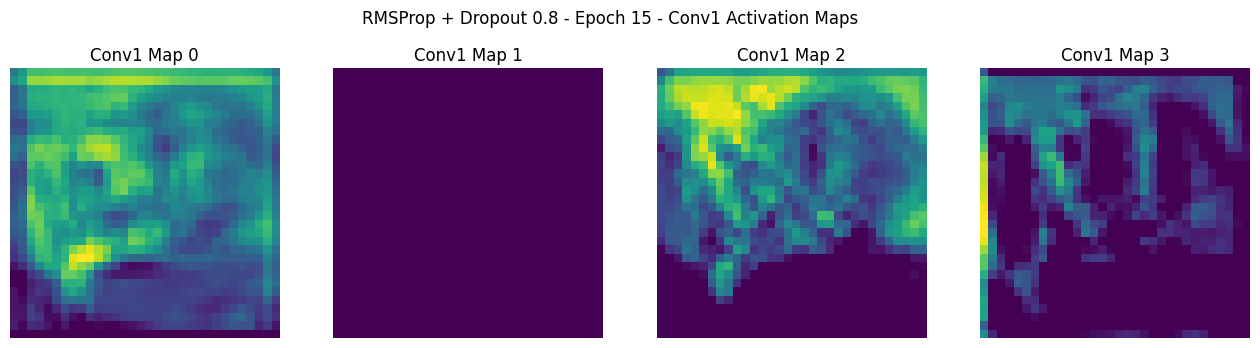

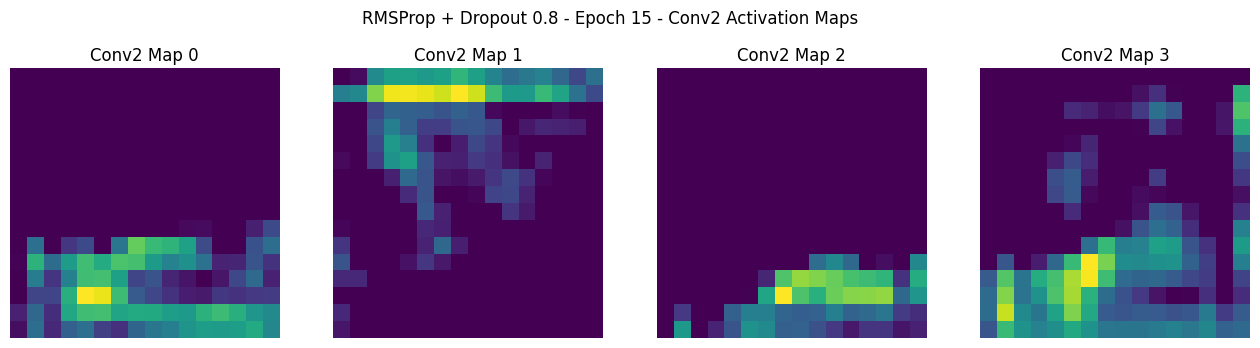

In [ ]:
dropout_rates = [0.2, 0.5, 0.8]
dropout_histories = {}

for p in dropout_rates:
    print(f"\nTraining RMSProp with Dropout p = {p}\n")
    torch.manual_seed(42)
    model_dropout = SimpleCNN(dropout_p=p, use_bn=False).to(device)
    optimizer_dropout = optim.RMSprop(model_dropout.parameters(), lr=0.001, alpha=0.9)

    history_dropout = train_model(
        model_dropout,
        train_loader,
        test_loader,
        optimizer_dropout,
        epochs=15,
        model_name=f"RMSProp + Dropout {p}"
    )

    dropout_histories[p] = history_dropout

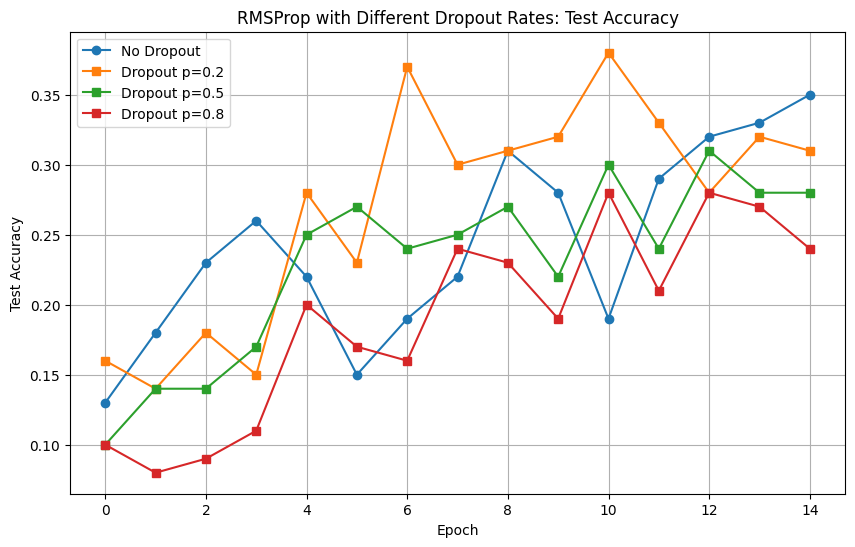

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_rmsprop["test_acc"], marker='o', label="No Dropout")
for p in dropout_rates:
    plt.plot(dropout_histories[p]["test_acc"], marker='s', label=f"Dropout p={p}")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("RMSProp with Different Dropout Rates: Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

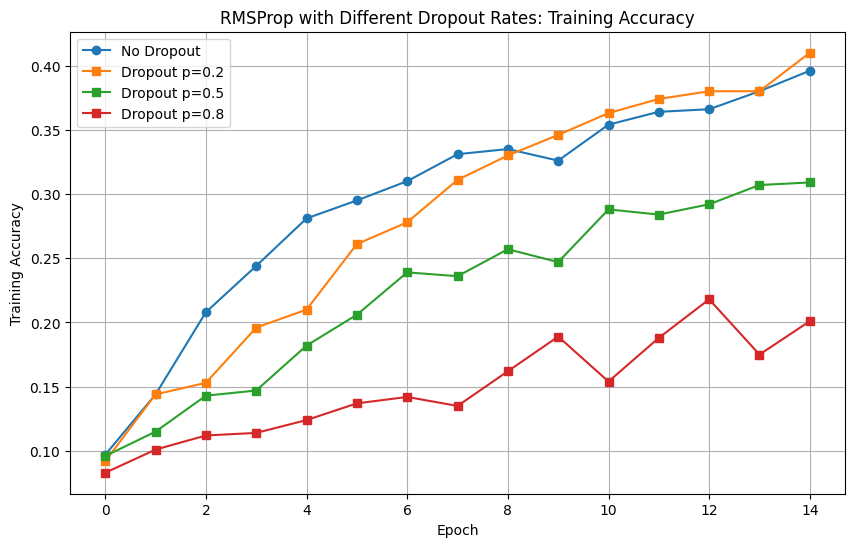

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_rmsprop["train_acc"], marker='o', label="No Dropout")
for p in dropout_rates:
    plt.plot(dropout_histories[p]["train_acc"], marker='s', label=f"Dropout p={p}")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("RMSProp with Different Dropout Rates: Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### (f) Batch Normalization

Batch normalization is applied to the hidden layer of the MLP.

The normalization is applied **before the activation function**.

The model is trained with:

- Batch Normalization
- Dropout ($p = 0.2$)

The results are compared with:

- the vanilla CNN
- CNN with dropout only

This analysis helps understand the effect of normalization on training stability and generalization performance.

Epoch [1/15] | Train Loss: 2.2361 | Test Loss: 2.2823 | Train Acc: 0.1780 | Test Acc: 0.1700


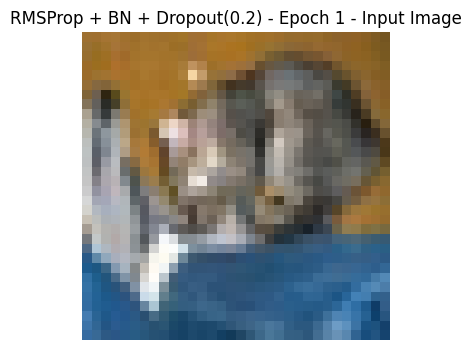

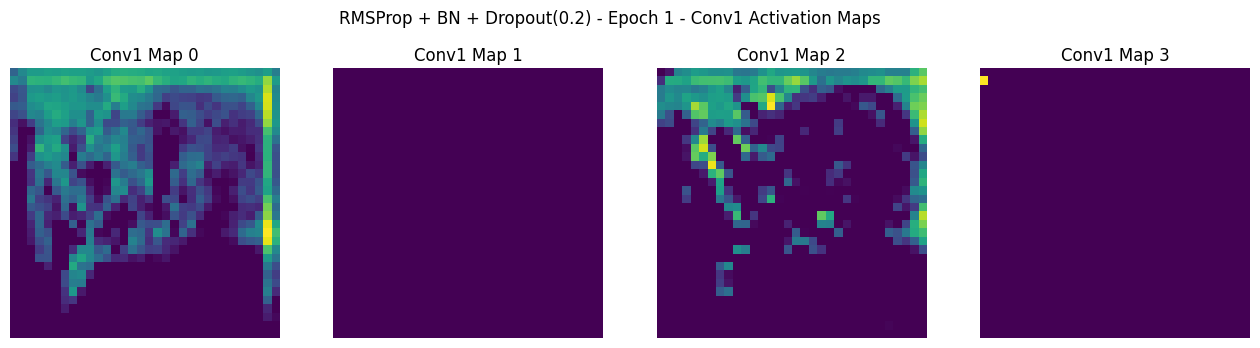

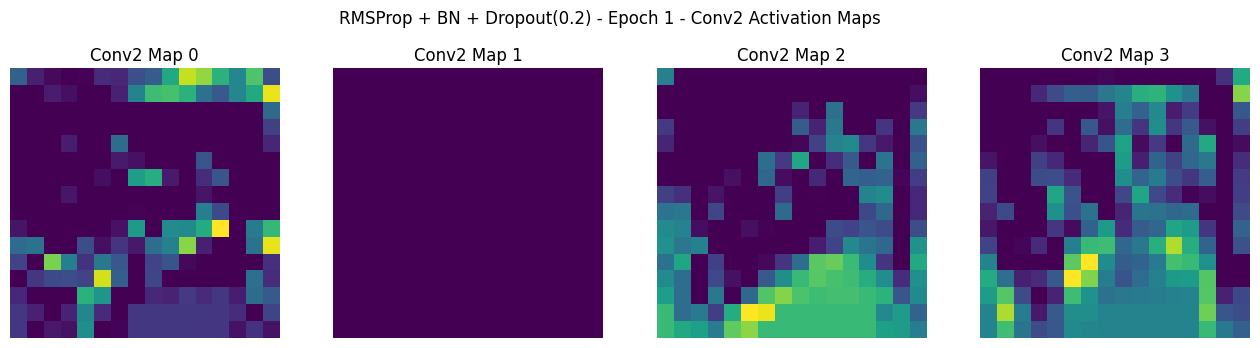

Epoch [2/15] | Train Loss: 2.0168 | Test Loss: 2.1747 | Train Acc: 0.3020 | Test Acc: 0.3200


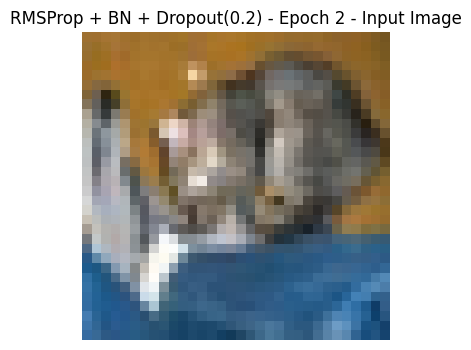

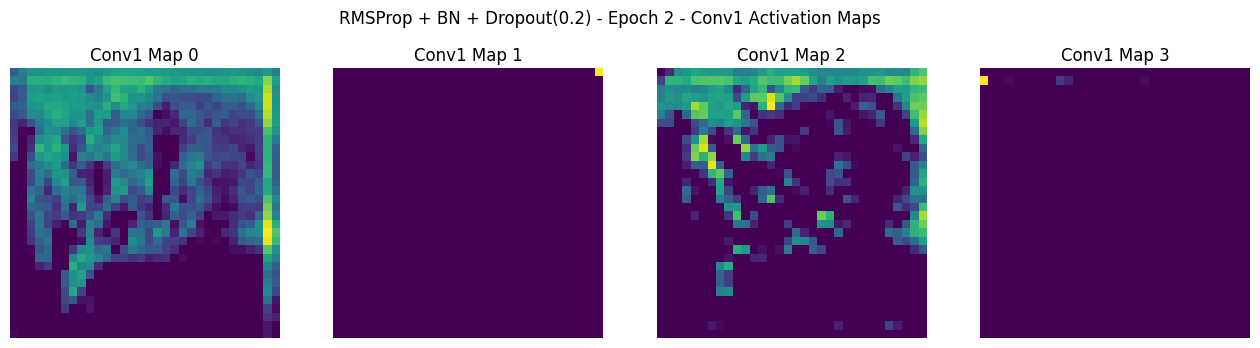

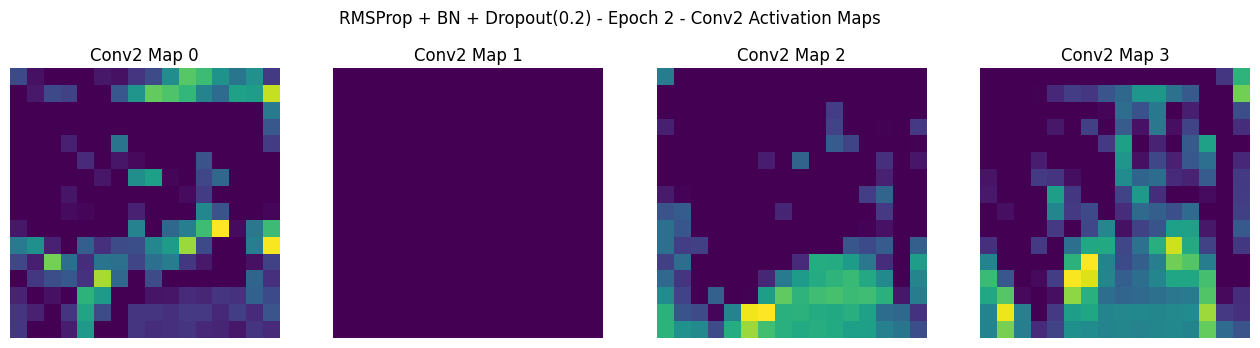

Epoch [3/15] | Train Loss: 1.9089 | Test Loss: 1.9577 | Train Acc: 0.3420 | Test Acc: 0.3000


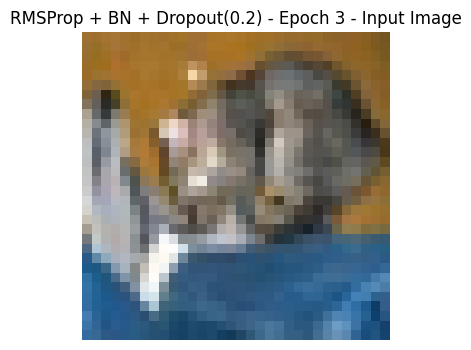

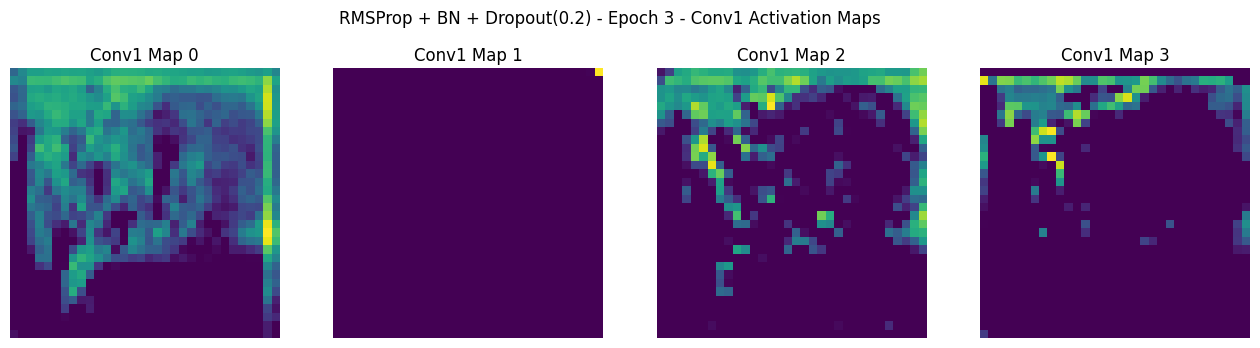

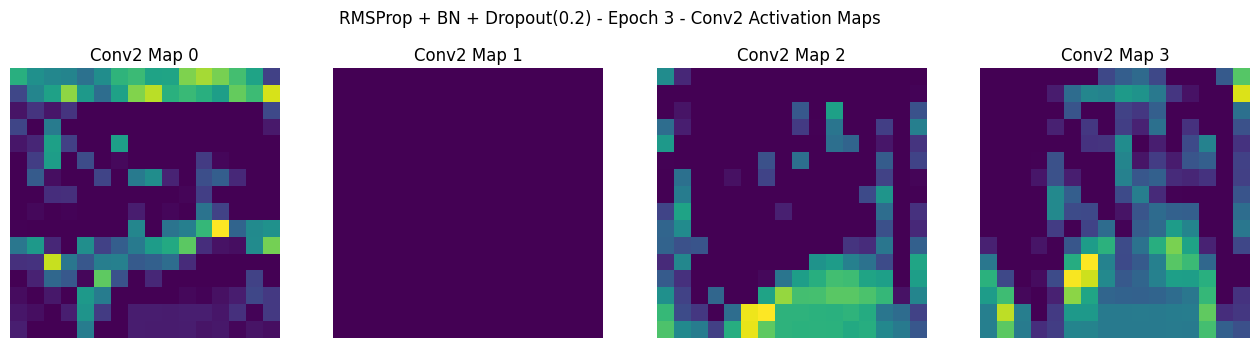

Epoch [4/15] | Train Loss: 1.7908 | Test Loss: 1.9095 | Train Acc: 0.4100 | Test Acc: 0.3300


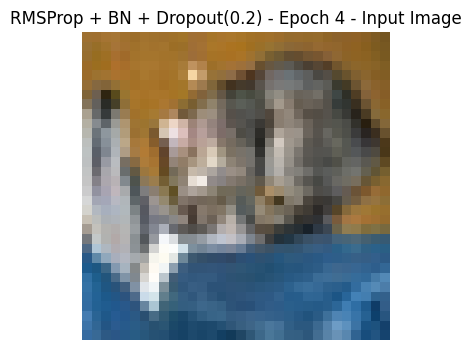

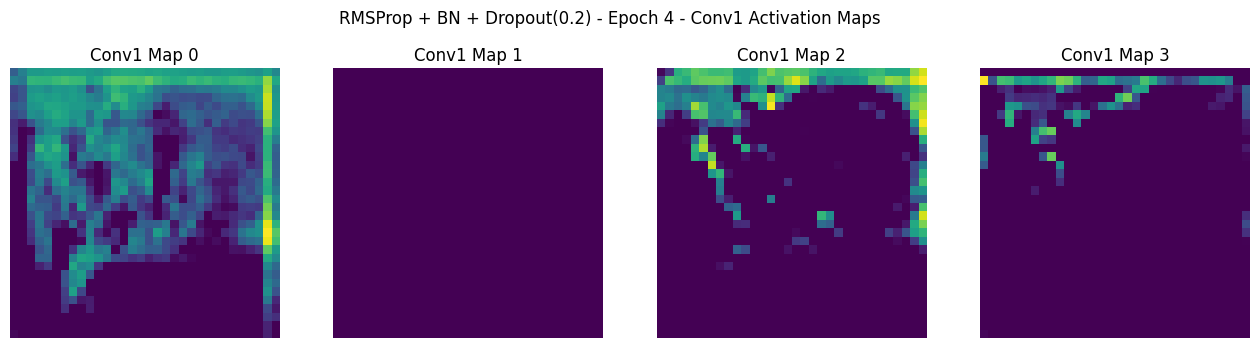

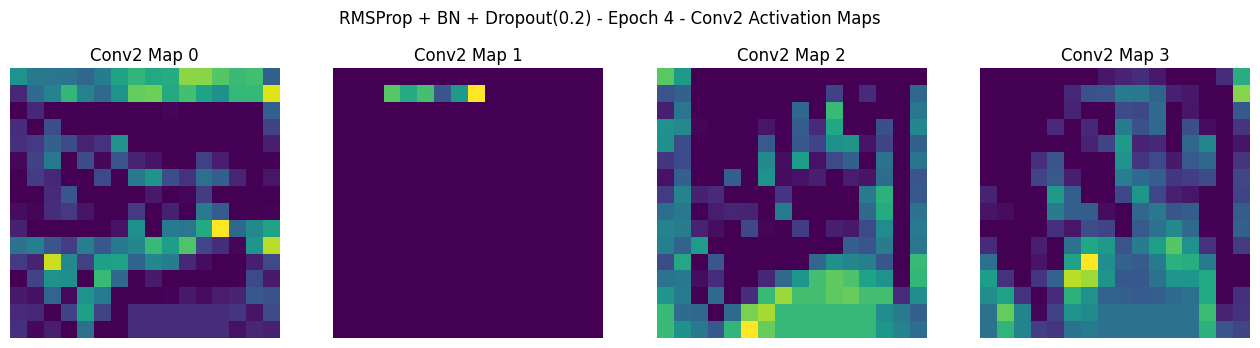

Epoch [5/15] | Train Loss: 1.6880 | Test Loss: 1.9412 | Train Acc: 0.4600 | Test Acc: 0.3300


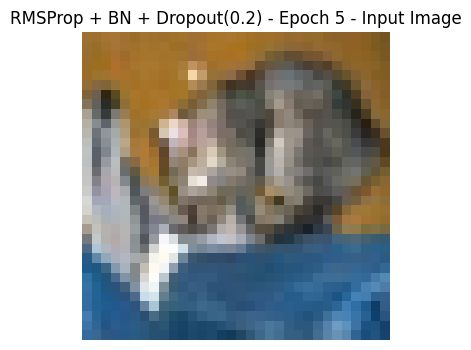

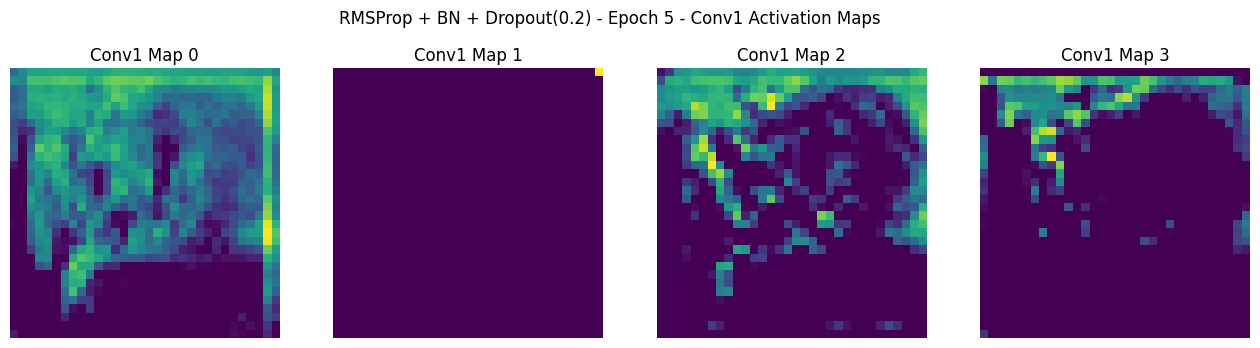

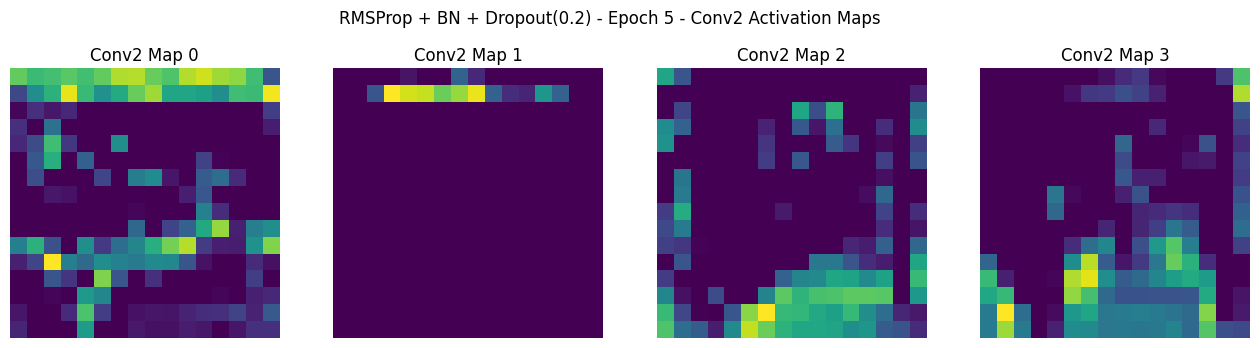

Epoch [6/15] | Train Loss: 1.6101 | Test Loss: 2.0716 | Train Acc: 0.4650 | Test Acc: 0.2700


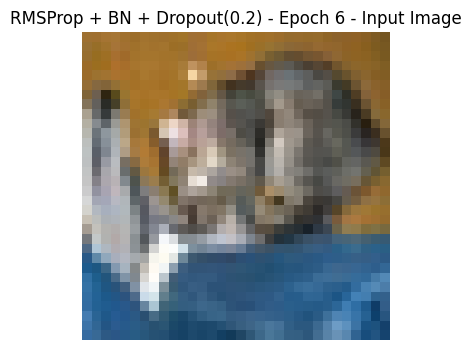

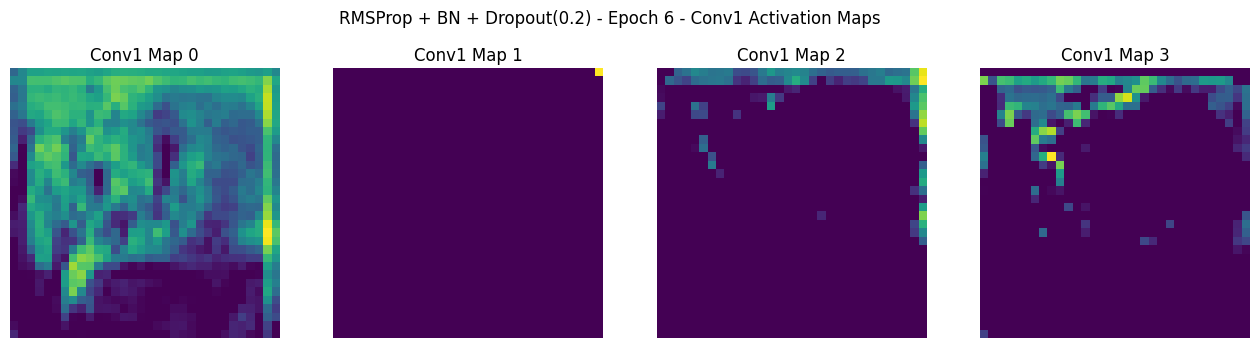

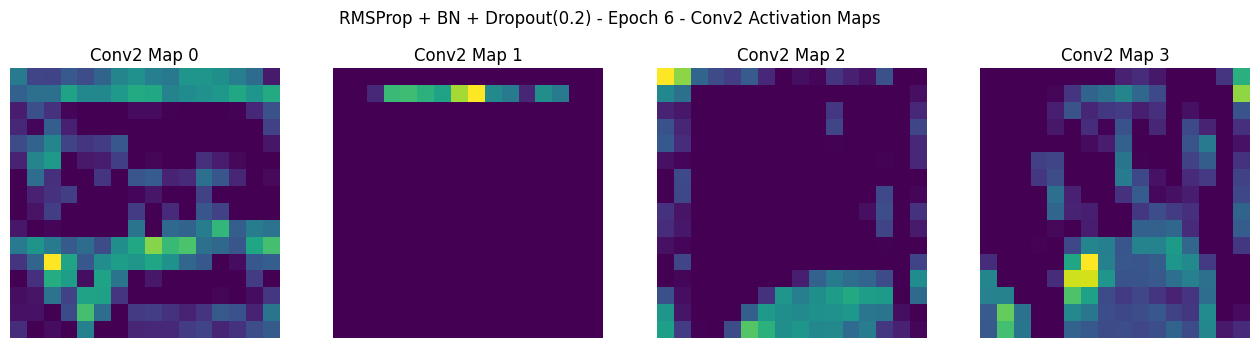

Epoch [7/15] | Train Loss: 1.5106 | Test Loss: 2.4642 | Train Acc: 0.5110 | Test Acc: 0.2400


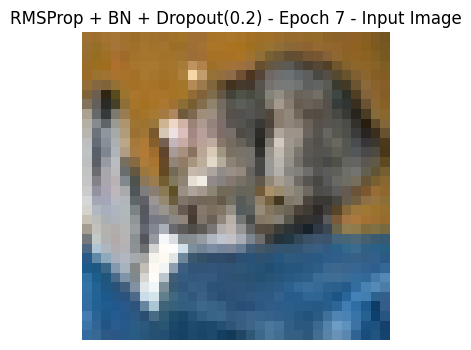

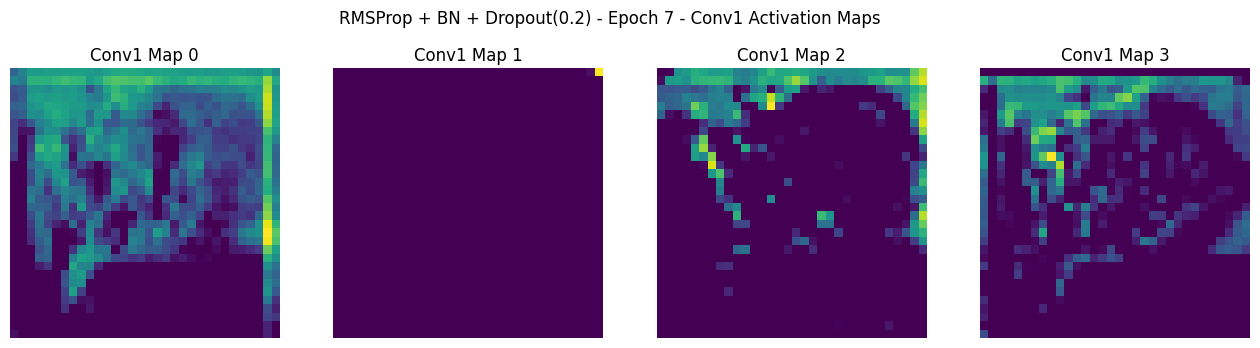

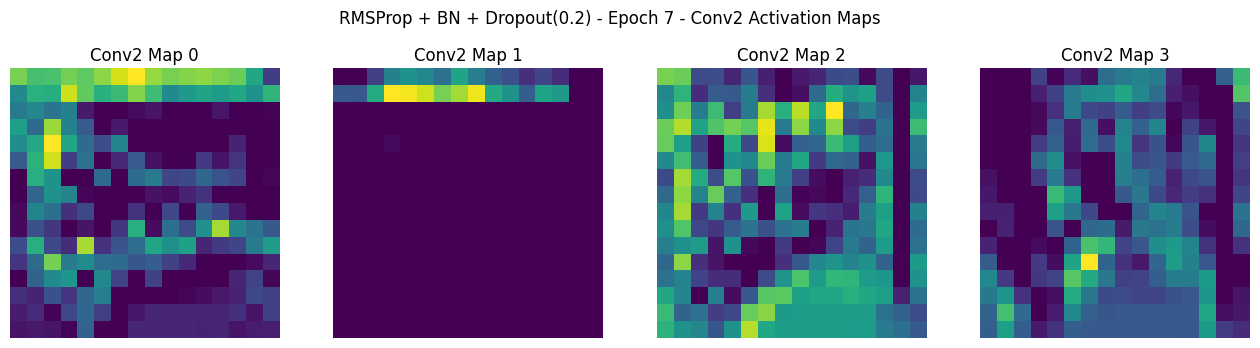

Epoch [8/15] | Train Loss: 1.4393 | Test Loss: 1.8626 | Train Acc: 0.5250 | Test Acc: 0.3600


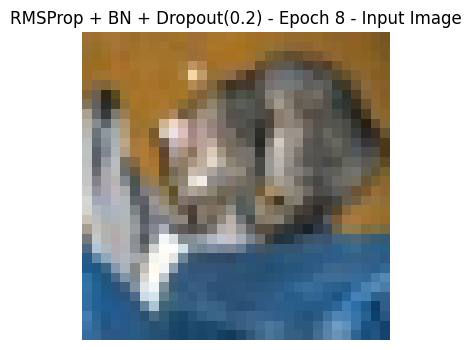

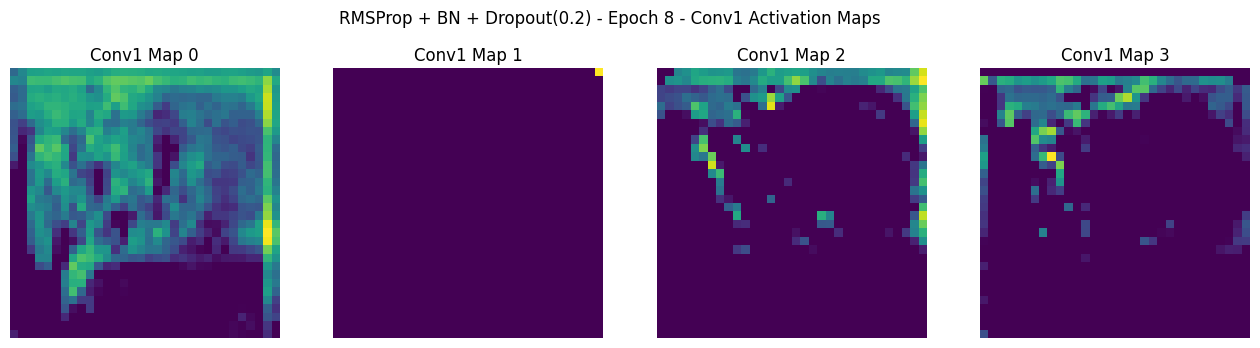

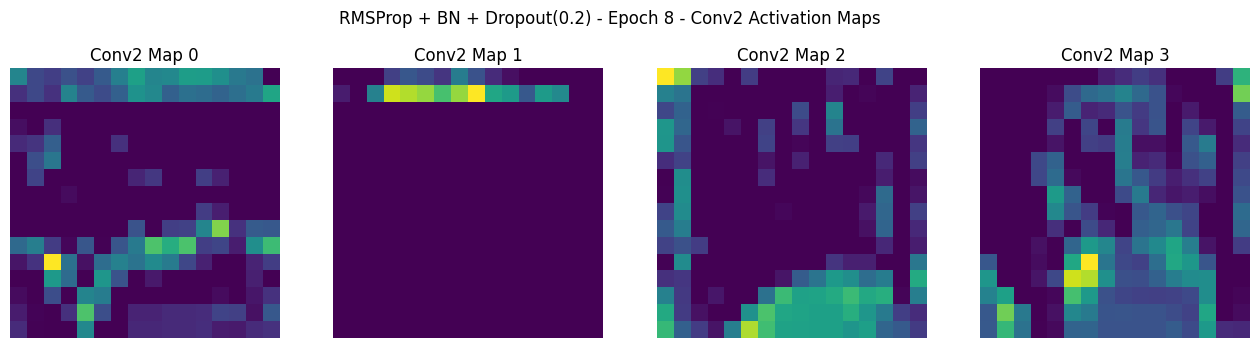

Epoch [9/15] | Train Loss: 1.3491 | Test Loss: 2.0649 | Train Acc: 0.5610 | Test Acc: 0.2500


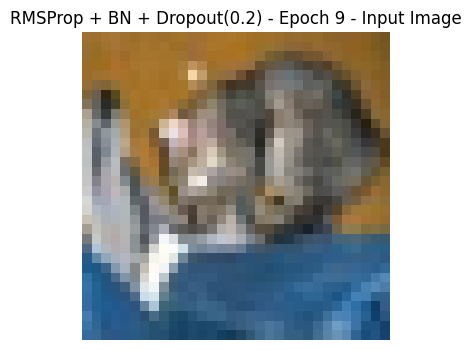

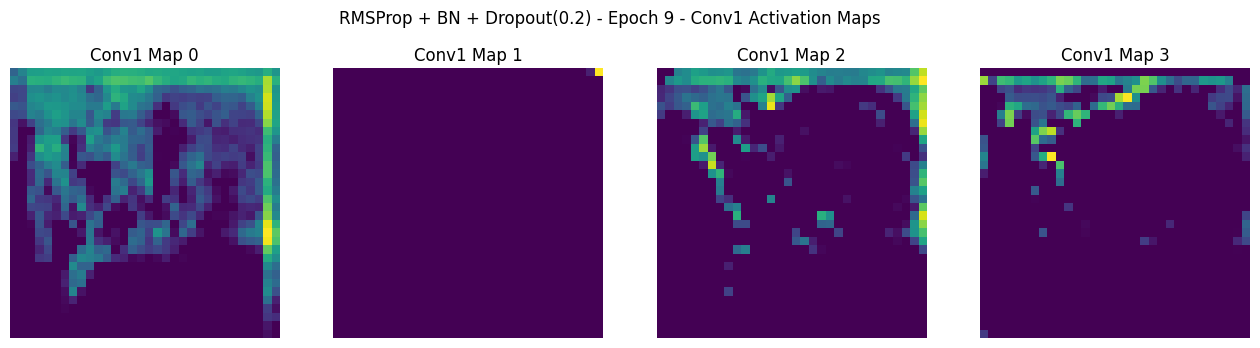

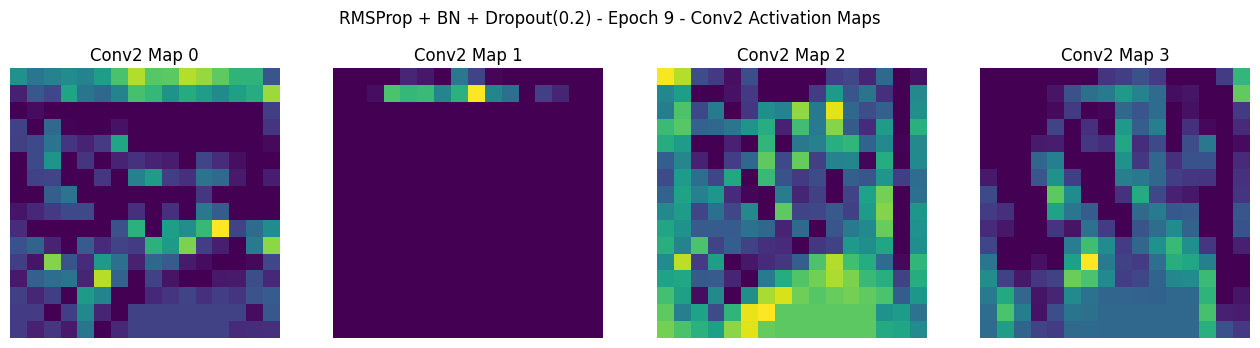

Epoch [10/15] | Train Loss: 1.3095 | Test Loss: 1.8965 | Train Acc: 0.5780 | Test Acc: 0.3600


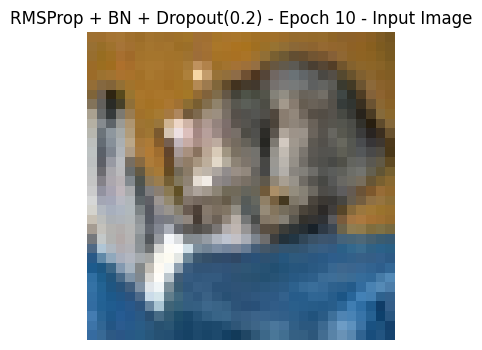

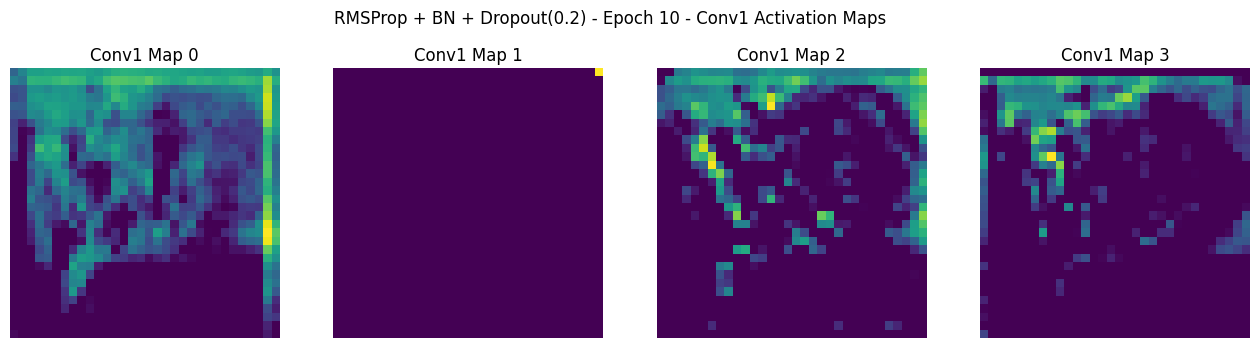

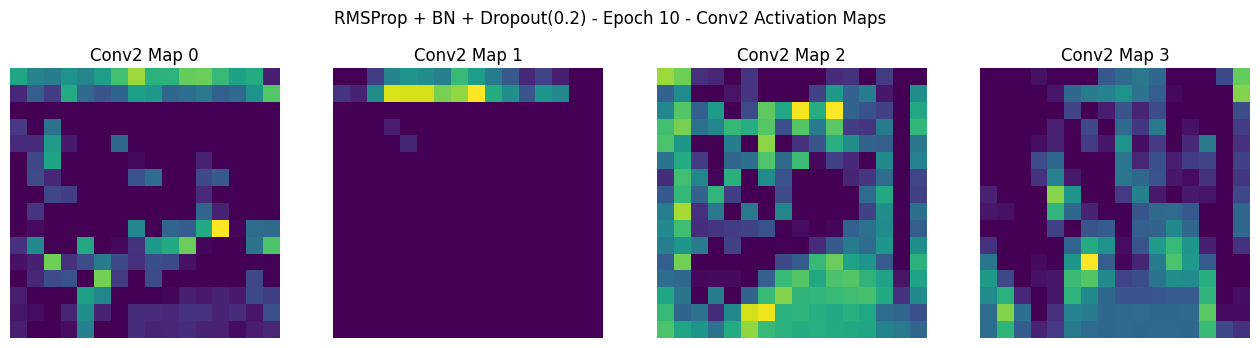

Epoch [11/15] | Train Loss: 1.2366 | Test Loss: 2.0108 | Train Acc: 0.6330 | Test Acc: 0.2800


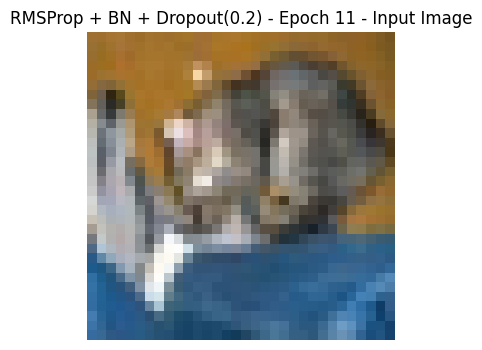

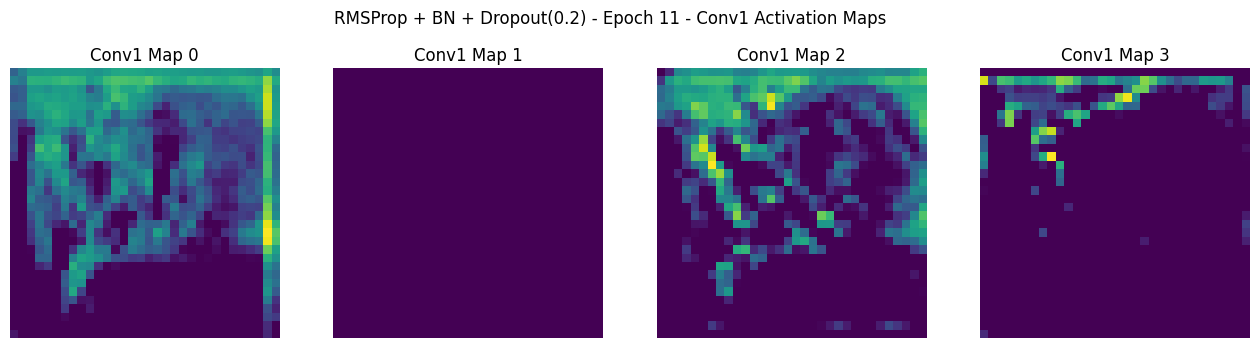

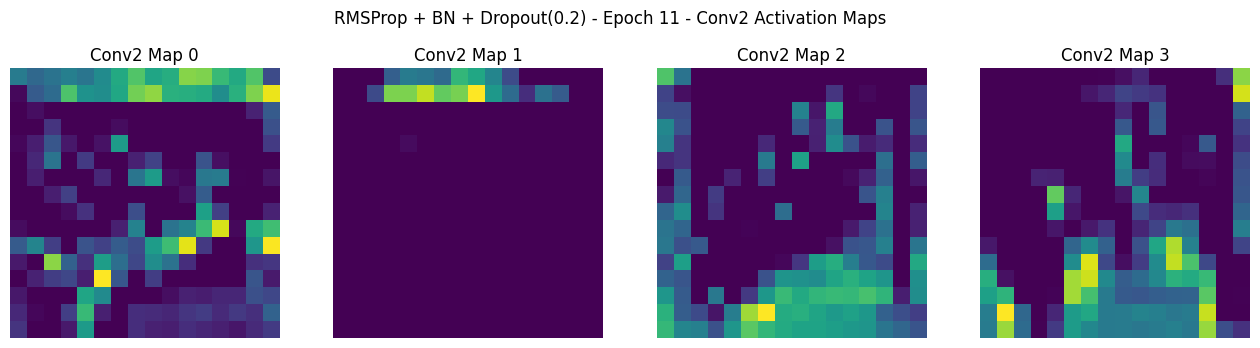

Epoch [12/15] | Train Loss: 1.1889 | Test Loss: 1.8556 | Train Acc: 0.6070 | Test Acc: 0.3500


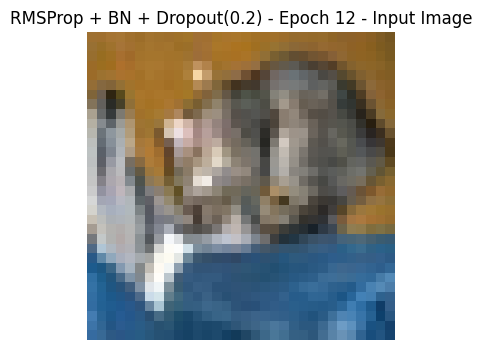

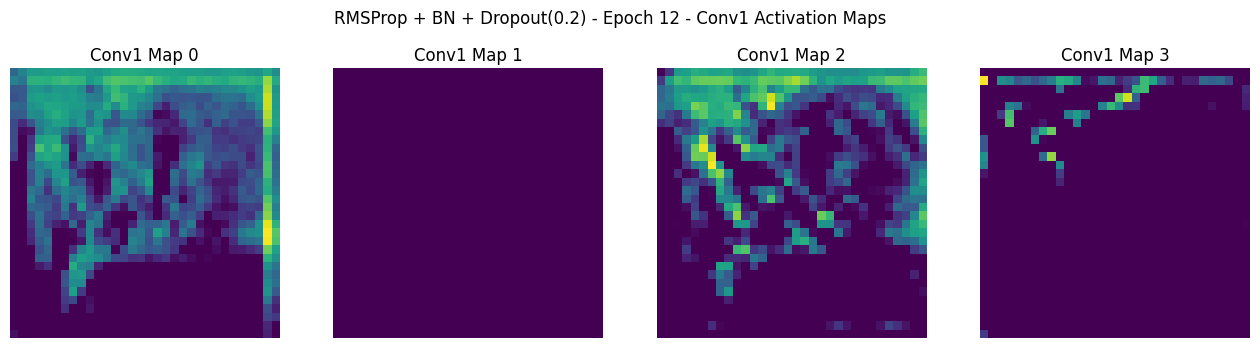

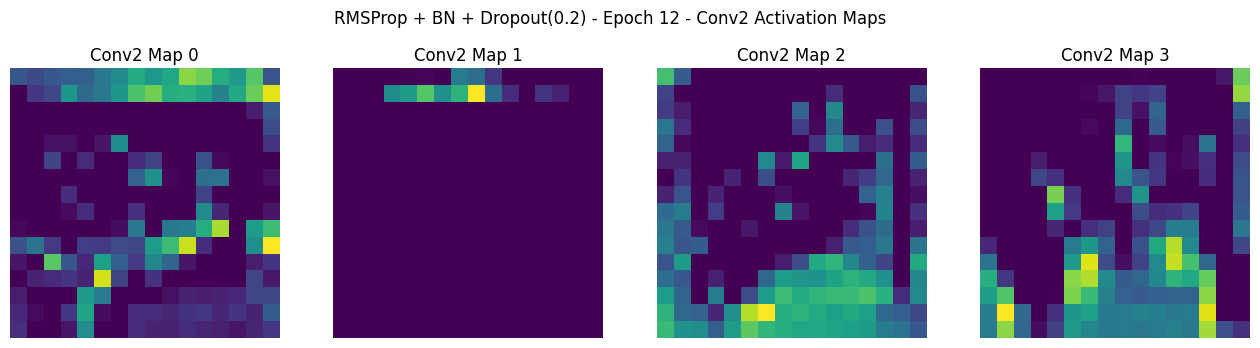

Epoch [13/15] | Train Loss: 1.1412 | Test Loss: 1.8244 | Train Acc: 0.6380 | Test Acc: 0.3800


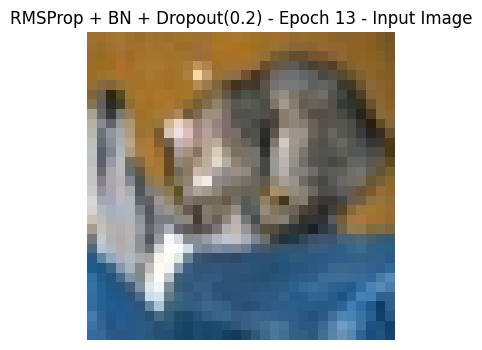

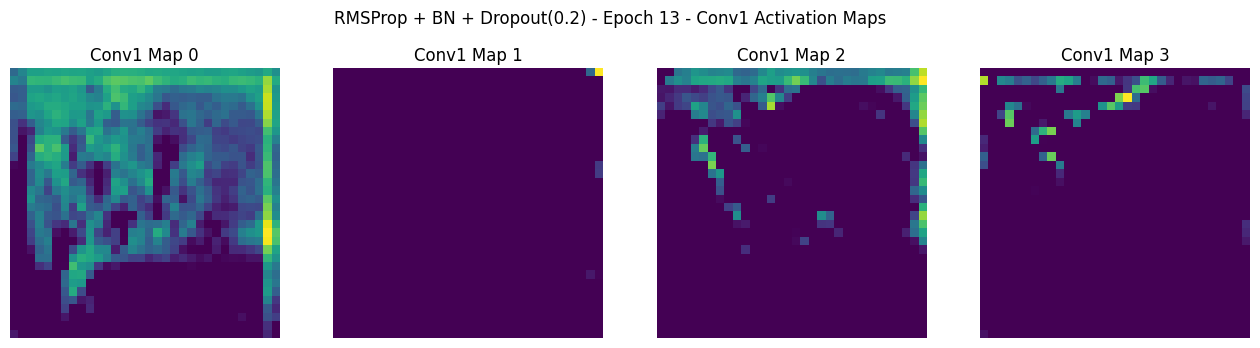

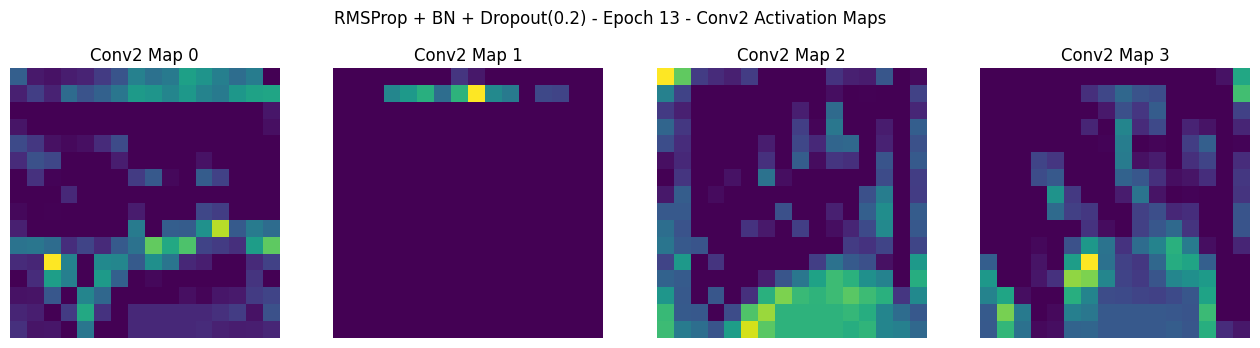

Epoch [14/15] | Train Loss: 1.0488 | Test Loss: 2.0040 | Train Acc: 0.6780 | Test Acc: 0.3100


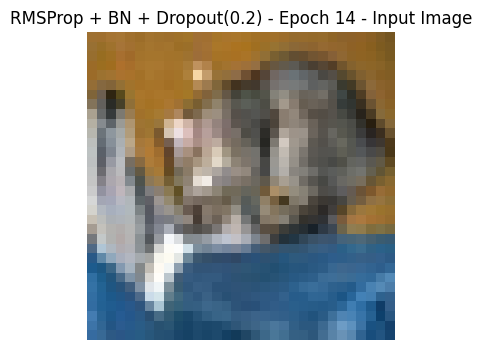

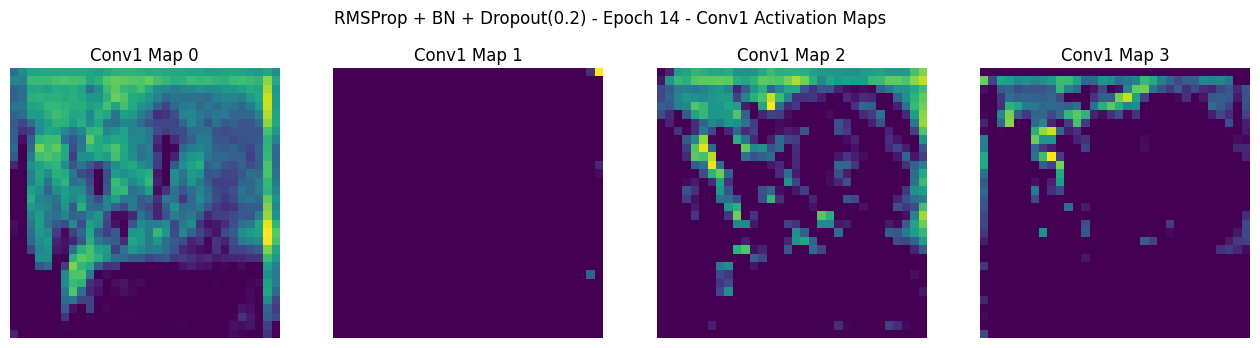

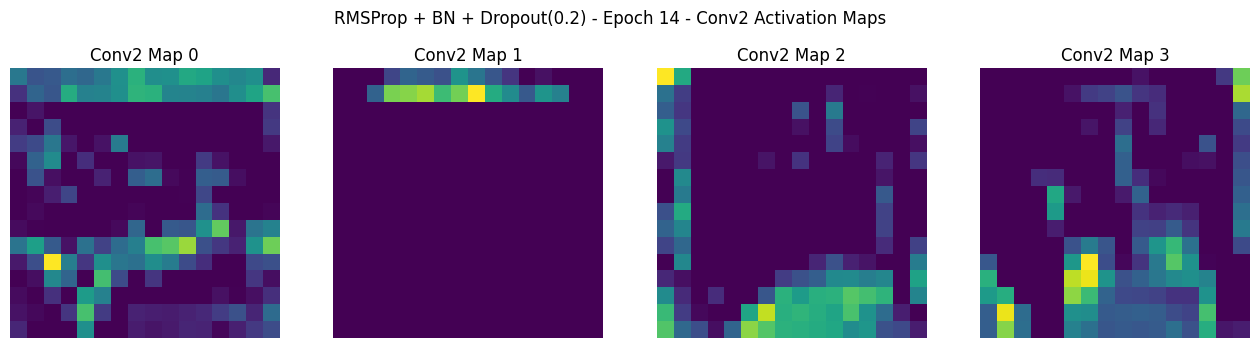

Epoch [15/15] | Train Loss: 1.0312 | Test Loss: 2.6044 | Train Acc: 0.6640 | Test Acc: 0.2300


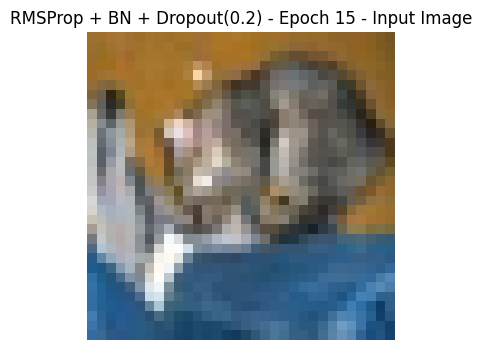

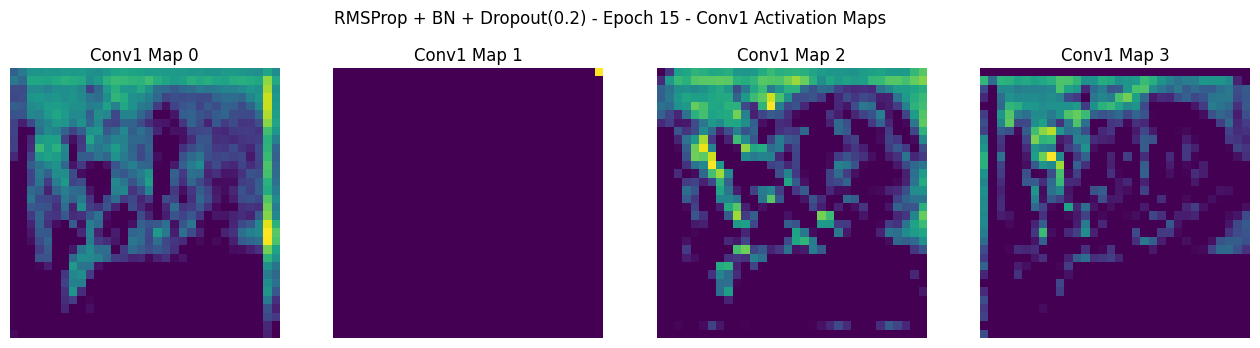

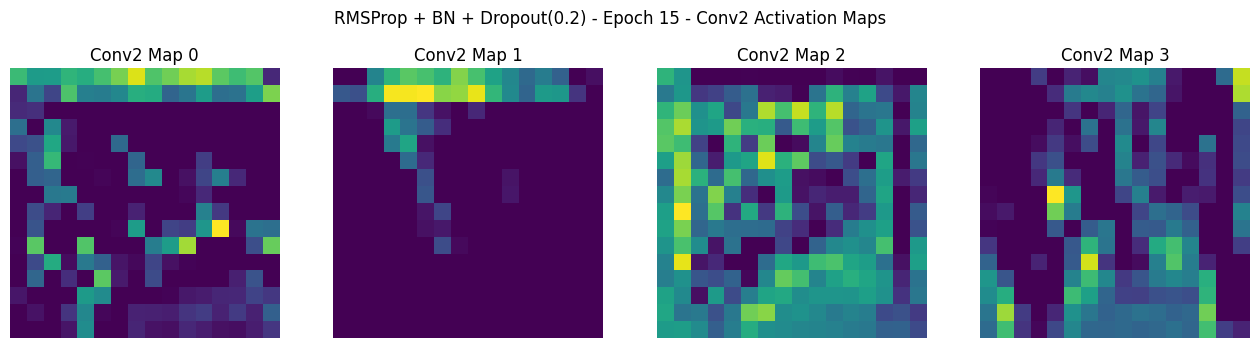

In [ ]:
torch.manual_seed(42)
model_bn_dropout = SimpleCNN(dropout_p=0.2, use_bn=True).to(device)
optimizer_bn_dropout = optim.RMSprop(model_bn_dropout.parameters(), lr=0.001, alpha=0.9)

history_bn_dropout = train_model(
    model_bn_dropout,
    train_loader,
    test_loader,
    optimizer_bn_dropout,
    epochs=15,
    model_name="RMSProp + BN + Dropout(0.2)"
)

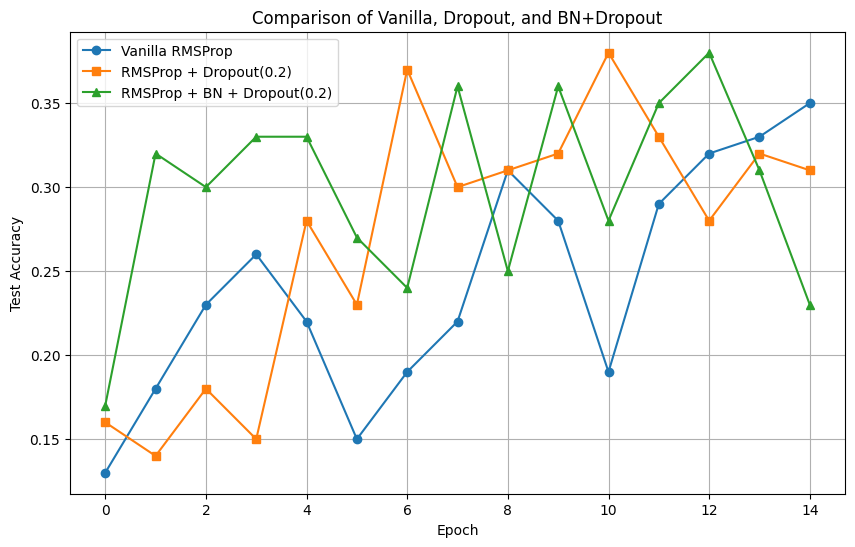

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_rmsprop["test_acc"], marker='o', label="Vanilla RMSProp")
plt.plot(dropout_histories[0.2]["test_acc"], marker='s', label="RMSProp + Dropout(0.2)")
plt.plot(history_bn_dropout["test_acc"], marker='^', label="RMSProp + BN + Dropout(0.2)")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Comparison of Vanilla, Dropout, and BN+Dropout")
plt.legend()
plt.grid(True)
plt.show()

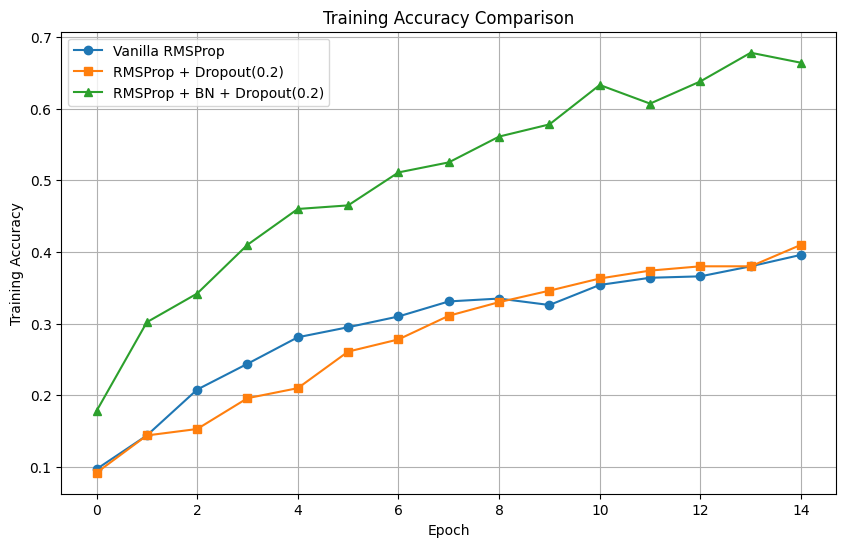

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_rmsprop["train_acc"], marker='o', label="Vanilla RMSProp")
plt.plot(dropout_histories[0.2]["train_acc"], marker='s', label="RMSProp + Dropout(0.2)")
plt.plot(history_bn_dropout["train_acc"], marker='^', label="RMSProp + BN + Dropout(0.2)")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def get_final_results(history, name):
    return {
        "Model": name,
        "Final Train Loss": history["train_loss"][-1],
        "Final Test Loss": history["test_loss"][-1],
        "Final Train Acc": history["train_acc"][-1],
        "Final Test Acc": history["test_acc"][-1]
    }

results = []
results.append(get_final_results(history_sgd, "Vanilla SGD"))
results.append(get_final_results(history_momentum, "Momentum"))
results.append(get_final_results(history_rmsprop, "RMSProp"))
results.append(get_final_results(dropout_histories[0.2], "RMSProp + Dropout(0.2)"))
results.append(get_final_results(dropout_histories[0.5], "RMSProp + Dropout(0.5)"))
results.append(get_final_results(dropout_histories[0.8], "RMSProp + Dropout(0.8)"))
results.append(get_final_results(history_bn_dropout, "RMSProp + BN + Dropout(0.2)"))

for r in results:
    print(r)

{'Model': 'Vanilla SGD', 'Final Train Loss': 2.304874013900757, 'Final Test Loss': 2.304941349029541, 'Final Train Acc': 0.102, 'Final Test Acc': 0.1}
{'Model': 'Momentum', 'Final Train Loss': 2.302574335098267, 'Final Test Loss': 2.3024698066711426, 'Final Train Acc': 0.1, 'Final Test Acc': 0.13}
{'Model': 'RMSProp', 'Final Train Loss': 1.7100114183425903, 'Final Test Loss': 2.1156249237060547, 'Final Train Acc': 0.396, 'Final Test Acc': 0.35}
{'Model': 'RMSProp + Dropout(0.2)', 'Final Train Loss': 1.710984661102295, 'Final Test Loss': 2.0144275665283202, 'Final Train Acc': 0.41, 'Final Test Acc': 0.31}
{'Model': 'RMSProp + Dropout(0.5)', 'Final Train Loss': 1.905791633605957, 'Final Test Loss': 2.013507995605469, 'Final Train Acc': 0.309, 'Final Test Acc': 0.28}
{'Model': 'RMSProp + Dropout(0.8)', 'Final Train Loss': 2.1330014991760256, 'Final Test Loss': 2.171826343536377, 'Final Train Acc': 0.201, 'Final Test Acc': 0.24}
{'Model': 'RMSProp + BN + Dropout(0.2)', 'Final Train Loss': 

1. Optimizer Comparison
Vanilla SGD generally converges slowly.\
Momentum improves convergence by smoothing updates and accelerating movement in useful directions.\
RMSProp usually performs better than plain SGD on this small CNN because it adapts learning rates per parameter.\
2. Error and Accuracy Trends\
Training error generally decreases with epochs.\
Test error may decrease initially and then fluctuate due to small dataset size.\
Training accuracy is usually higher than testing accuracy because the model learns the sampled training subset more strongly.
3. Activation Maps\
In the first convolution layer, activation maps often capture low-level patterns such as edges, contrasts, and simple textures.\
In the second convolution layer, activation maps are more abstract and correspond to combinations of earlier features.\
4. t-SNE Visualization\
At epoch 1, bottleneck features may appear more mixed and less class-separable.\
At the last epoch, clusters are expected to become more structured, indicating that the network has learned a better internal representation.
5. Dropout\
Moderate dropout such as p = 0.2 can improve generalization.
Larger dropout such as p = 0.8 may make learning too difficult and reduce training accuracy significantly.\
Dropout usually lowers training accuracy somewhat but may improve test performance if overfitting exists.
6. Batch Normalization + Dropout\
Batch normalization often stabilizes training.
BN before ReLU makes hidden activations better scaled.\
Combining BN with dropout may improve testing performance compared to vanilla training and sometimes also compared to dropout alone.

During training, the training error gradually decreases across epochs, indicating that the model is successfully learning patterns from the training dataset. The training accuracy correspondingly increases, which shows that the optimization process is effectively adjusting the model parameters.

The test error also shows a decreasing trend, although it is slightly higher than the training error. This behavior is expected because the model is optimized on the training data and may not perfectly generalize to unseen data.

The gap between training and testing performance is relatively small, which suggests that the model is not severely overfitting despite the limited dataset (100 images per class). However, since the dataset used for training is small (1000 images), the model's overall accuracy remains moderate.

When comparing different optimizers:

Vanilla SGD shows slower convergence.\
Momentum improves convergence speed by smoothing parameter updates.\
RMSProp generally provides more stable and faster training due to adaptive learning rates.

When dropout is applied, training accuracy typically decreases slightly because dropout regularizes the network by randomly disabling neurons. However, dropout can help improve generalization on the test dataset by reducing overfitting.

When batch normalization is introduced, the training becomes more stable and convergence is faster because the activations are normalized during training. Combining batch normalization with dropout often improves both training stability and test performance compared to the vanilla model.

Overall, the experiments demonstrate that optimization techniques and regularization methods significantly affect both training convergence and generalization performance.

#Question-3

###3 Backpropagation in CNN (Theory)

## Network Description

Consider the following CNN architecture.

Input: $8 \times 8$ grayscale image $X$.

1. $3\times3$ convolution filter, stride $=1$, padding $=1$ → $Z_1$
2. ReLU activation → $A_1$
3. $2\times2$ max pooling, stride $=2$ → $P_1$
4. Second convolution layer ($3\times3$, 2 filters, stride=1, no padding) → $Z_2$
5. ReLU → $A_2$
6. Flatten → $F$
7. Fully connected layer → $Z_3$
8. Sigmoid activation → $\hat{y}$

Loss function: Binary Cross Entropy (BCE)

## (i) Flow Diagram of the Network

$$
X(8\times8)
\rightarrow
Z_1
\rightarrow
A_1
\rightarrow
P_1
\rightarrow
Z_2
\rightarrow
A_2
\rightarrow
F
\rightarrow
Z_3
\rightarrow
\hat{y}
$$

Dimension flow:

$$
8\times8\times1
\rightarrow
8\times8\times1
\rightarrow
8\times8\times1
\rightarrow
4\times4\times1
\rightarrow
2\times2\times2
\rightarrow
2\times2\times2
\rightarrow
8
\rightarrow
1
\rightarrow
1
$$


## (ii) Dimensions of Layers

### Input

$$
X \in \mathbb{R}^{8\times8\times1}
$$

### First Convolution Layer

Output size formula:

$$
\frac{N-F+2P}{S}+1
$$

where

$$
N=8,\quad F=3,\quad P=1,\quad S=1
$$

$$
\frac{8-3+2(1)}{1}+1=8
$$

Therefore

$$
Z_1 \in \mathbb{R}^{8\times8\times1}
$$

### ReLU

$$
A_1 \in \mathbb{R}^{8\times8\times1}
$$

### Max Pooling

$$
\frac{8-2}{2}+1=4
$$

$$
P_1 \in \mathbb{R}^{4\times4\times1}
$$

### Second Convolution Layer

Input size $4\times4$

$$
\frac{4-3}{1}+1=2
$$

Since there are 2 filters:

$$
Z_2 \in \mathbb{R}^{2\times2\times2}
$$

### ReLU

$$
A_2 \in \mathbb{R}^{2\times2\times2}
$$

### Flatten

$$
F = 2\times2\times2 = 8
$$

$$
F \in \mathbb{R}^{8}
$$

### Fully Connected

$$
Z_3 \in \mathbb{R}
$$

### Output

$$
\hat{y} = \sigma(Z_3)
$$

## (iii) Number of Trainable Parameters

### First Convolution Layer

Filter weights:

$$
3\times3\times1 = 9
$$

Bias:

$$
1
$$

Total:

$$
10
$$

---

### Second Convolution Layer

Each filter:

$$
3\times3\times1 = 9
$$

Bias:

$$
1
$$

Total per filter:

$$
10
$$

Two filters:

$$
2\times10 = 20
$$

---

### Fully Connected Layer

Weights:

$$
8 \times 1 = 8
$$

Bias:

$$
1
$$

Total:

$$
9
$$

---

### Total Trainable Parameters

$$
10 + 20 + 9 = 39
$$

$$
\boxed{39}
$$

## (iv) Backpropagation Derivation

### Binary Cross Entropy Loss

$$
L = -[y\log(\hat y) + (1-y)\log(1-\hat y)]
$$

$$
\hat y = \sigma(Z_3)
$$

Derivative:

$$
\frac{\partial L}{\partial Z_3} = \hat y - y
$$

Let

$$
\delta_3 = \hat y - y
$$

### Gradients for Fully Connected Layer

Forward equation:

$$
Z_3 = WF + b
$$

Weight gradient:

$$
\frac{\partial L}{\partial W} = \delta_3 F^T
$$

Bias gradient:

$$
\frac{\partial L}{\partial b} = \delta_3
$$

Gradient to flatten vector:

$$
\frac{\partial L}{\partial F} = W^T \delta_3
$$

### ReLU Backpropagation

ReLU derivative:

$$
\frac{d}{dz}ReLU(z)=
\begin{cases}
1 & z>0 \\
0 & z\le0
\end{cases}
$$

### Second Convolution Layer Gradient

Forward equation:

$$
Z_2^{(k)}(i,j)=
\sum_{u=0}^{2}\sum_{v=0}^{2}
K^{(k)}(u,v)P_1(i+u,j+v)+b_2^{(k)}
$$

Weight gradient:

$$
\frac{\partial L}{\partial K^{(k)}(u,v)}=
\sum_{i=0}^{1}\sum_{j=0}^{1}
\delta_2^{(k)}(i,j)P_1(i+u,j+v)
$$

Bias gradient:

$$
\frac{\partial L}{\partial b_2^{(k)}}=
\sum_{i=0}^{1}\sum_{j=0}^{1}
\delta_2^{(k)}(i,j)
$$

### First Convolution Layer Gradient

Forward equation:

$$
Z_1(i,j)=
\sum_{u=0}^{2}\sum_{v=0}^{2}
K_1(u,v)X_{pad}(i+u,j+v)+b_1
$$

Weight gradient:

$$
\frac{\partial L}{\partial K_1(u,v)}=
\sum_{i=0}^{7}\sum_{j=0}^{7}
\delta_1(i,j)X_{pad}(i+u,j+v)
$$

Bias gradient:

$$
\frac{\partial L}{\partial b_1}=
\sum_{i=0}^{7}\sum_{j=0}^{7}
\delta_1(i,j)
$$